In [1]:
# ============================================================
# NOTEBOOK 12 — CELL 1
# GENOMIC DATA PREPARATION & LEAKAGE QC
# ENVIRONMENT + FROZEN COHORT SETUP
# ============================================================
#
# IMPORTANT:
#   Notebook 11 Cell 6 is currently running separately.
#
#   This notebook will NOT:
#       - train a model
#       - run a Transformer
#       - run PSPNet
#       - extract CXR embeddings
#       - modify existing files
#
#   This cell only establishes paths and verifies the
#   already-frozen multimodal cohort.
# ============================================================

import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd


print("=" * 80)
print("NOTEBOOK 12 — CELL 1")
print("GENOMIC DATA PREPARATION & LEAKAGE QC")
print("=" * 80)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(
    r"C:\TBP"
)

METADATA_ROOT = (
    PROJECT_ROOT
    / "Metadata"
)


# ============================================================
# 2. NOTEBOOK 08 FINAL CXR COHORT
# ============================================================

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)


FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)


MASTER_SPLIT_PATH = (
    CXR_ROOT
    / "QC"
    / "Master_Condition_Level_Split"
    / "TB_Portals_March2025_Notebook08_Master_Condition_Level_Split.csv"
)


# ============================================================
# 3. GENOMIC DATA ROOT
# ============================================================
#
# We deliberately do NOT guess the genomic filename.
#
# First we verify the existing project structure.
# ============================================================

GENOMIC_ROOT = (
    METADATA_ROOT
)


# ============================================================
# 4. VERIFY REQUIRED CXR FILES
# ============================================================

print()
print("=" * 80)
print("REQUIRED FROZEN CXR INPUTS")
print("=" * 80)


required_paths = {

    "Final CXR metadata":
        FINAL_CXR_METADATA_PATH,

    "Master condition-level split":
        MASTER_SPLIT_PATH
}


for name, path in required_paths.items():

    exists = path.exists()

    print(
        f"{name:<35}: "
        f"{'PASS' if exists else 'MISSING'}"
    )

    if not exists:

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )


# ============================================================
# 5. LOAD FROZEN CXR MODELING COHORT
# ============================================================

final_cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)


master_split_df = pd.read_csv(
    MASTER_SPLIT_PATH
)


print()
print("=" * 80)
print("FROZEN COHORT")
print("=" * 80)

print(
    "Final CXR cohort:",
    len(final_cxr_df)
)

print(
    "Master split rows:",
    len(master_split_df)
)


# ============================================================
# 6. BASIC COHORT QC
# ============================================================

if len(final_cxr_df) != 2058:

    raise RuntimeError(
        "Final CXR cohort is not 2058."
    )


if len(master_split_df) != 2058:

    raise RuntimeError(
        "Master split is not 2058 rows."
    )


if final_cxr_df[
    "condition_id"
].nunique() != 2058:

    raise RuntimeError(
        "Final CXR cohort is not condition-level unique."
    )


if master_split_df[
    "condition_id"
].nunique() != 2058:

    raise RuntimeError(
        "Master split is not condition-level unique."
    )


print(
    "CXR condition-level uniqueness: PASS"
)


# ============================================================
# 7. VERIFY FROZEN SPLIT
# ============================================================

split_counts = (
    master_split_df[
        "split"
    ]
    .value_counts()
    .sort_index()
)


print()
print("=" * 80)
print("FROZEN SPLIT")
print("=" * 80)

print(
    split_counts
)


expected_split_counts = {

    "train": 1234,

    "validation": 412,

    "test": 412
}


for split_name, expected_count in (
    expected_split_counts.items()
):

    actual_count = int(
        split_counts.get(
            split_name,
            0
        )
    )

    if actual_count != expected_count:

        raise RuntimeError(
            f"Unexpected {split_name} "
            f"count: {actual_count}"
        )


print(
    "Train / validation / test split: PASS"
)


# ============================================================
# 8. VERIFY TARGET DISTRIBUTION
# ============================================================

print()
print("=" * 80)
print("FROZEN TARGET DISTRIBUTION")
print("=" * 80)


target_counts = (
    final_cxr_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
)


print(
    target_counts
)


expected_target_counts = {

    0: 719,

    1: 1339
}


for target_value, expected_count in (
    expected_target_counts.items()
):

    actual_count = int(
        target_counts.get(
            target_value,
            0
        )
    )

    if actual_count != expected_count:

        raise RuntimeError(
            f"Unexpected target count "
            f"for {target_value}: "
            f"{actual_count}"
        )


print(
    "Target distribution: PASS"
)


# ============================================================
# 9. VERIFY SPLIT × TARGET
# ============================================================

split_target_table = pd.crosstab(
    master_split_df[
        "split"
    ],
    master_split_df[
        "target_binary"
    ]
)


print()
print("=" * 80)
print("SPLIT × TARGET")
print("=" * 80)

print(
    split_target_table
)


# ============================================================
# 10. VERIFY CONDITION IDs MATCH
# ============================================================

cxr_conditions = set(
    final_cxr_df[
        "condition_id"
    ]
)

split_conditions = set(
    master_split_df[
        "condition_id"
    ]
)


if cxr_conditions != split_conditions:

    missing_from_split = (
        cxr_conditions
        -
        split_conditions
    )

    missing_from_cxr = (
        split_conditions
        -
        cxr_conditions
    )

    raise RuntimeError(
        "CXR cohort and master split "
        "condition IDs do not match.\n"
        f"Missing from split: "
        f"{len(missing_from_split)}\n"
        f"Missing from CXR cohort: "
        f"{len(missing_from_cxr)}"
    )


print(
    "CXR ↔ master split condition IDs: PASS"
)


# ============================================================
# 11. PRINT IMPORTANT COLUMNS
# ============================================================

print()
print("=" * 80)
print("FINAL CXR METADATA COLUMNS")
print("=" * 80)

for column in final_cxr_df.columns:

    print(
        column
    )


print()
print("=" * 80)
print("MASTER SPLIT COLUMNS")
print("=" * 80)

for column in master_split_df.columns:

    print(
        column
    )


# ============================================================
# 12. HASH FROZEN SPLIT
# ============================================================

split_for_hash = (
    master_split_df[
        [
            "condition_id",
            "split",
            "target_binary"
        ]
    ]
    .sort_values(
        "condition_id"
    )
    .reset_index(
        drop=True
    )
)


split_csv_bytes = (
    split_for_hash
    .to_csv(
        index=False
    )
    .encode(
        "utf-8"
    )
)


split_hash = hashlib.sha256(
    split_csv_bytes
).hexdigest()


print()
print("=" * 80)
print("FROZEN SPLIT HASH")
print("=" * 80)

print(
    split_hash
)


print()
print(
    "Previously frozen Notebook 08 hash:"
)

print(
    "de5c23d223c5a6260e622cba9bc605d948a90fc98d816cce6ae0076cb67f0be3"
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 1 FINAL STATUS")
print("=" * 80)

print(
    "Frozen CXR cohort             : PASS"
)

print(
    "2058 condition-level records  : PASS"
)

print(
    "1234/412/412 split            : PASS"
)

print(
    "Target distribution           : PASS"
)

print(
    "CXR ↔ split condition IDs     : PASS"
)

print(
    "No model training             : YES"
)

print(
    "No CXR processing             : YES"
)

print(
    "No genomic training           : YES"
)

print()
print(
    "CELL 1 — PASS"
)

print()
print(
    "NOTE: Notebook 11 Cell 6 remains untouched."
)

NOTEBOOK 12 — CELL 1
GENOMIC DATA PREPARATION & LEAKAGE QC

REQUIRED FROZEN CXR INPUTS
Final CXR metadata                 : PASS
Master condition-level split       : PASS

FROZEN COHORT
Final CXR cohort: 2058
Master split rows: 2058
CXR condition-level uniqueness: PASS

FROZEN SPLIT
split
test           412
train         1234
validation     412
Name: count, dtype: int64
Train / validation / test split: PASS

FROZEN TARGET DISTRIBUTION
target_binary
0     719
1    1339
Name: count, dtype: int64
Target distribution: PASS

SPLIT × TARGET
target_binary    0    1
split                  
test           144  268
train          431  803
validation     144  268
CXR ↔ master split condition IDs: PASS

FINAL CXR METADATA COLUMNS
stem
filename
source_type
source_path
final_cxr_path
condition_id
series_instance_content_url
specimen_id
imaging_date_num
specimen_collection_date_num
signed_temporal_delta_days
absolute_temporal_distance_days
prediction_temporal_class
target_class
target_binary
cxr_resi

In [2]:
# ============================================================
# NOTEBOOK 12 — CELL 2
# DISCOVER EXISTING GENOMIC DATA SOURCES
# ============================================================
#
# IMPORTANT:
#   This is a LIGHTWEIGHT filesystem inspection only.
#
#   It does NOT:
#       - load large genomic datasets
#       - modify files
#       - train models
#       - create embeddings
#       - process sequences
#       - touch Notebook 11
# ============================================================

from pathlib import Path
import pandas as pd


print("=" * 80)
print("NOTEBOOK 12 — CELL 2")
print("GENOMIC SOURCE DISCOVERY")
print("=" * 80)


# ============================================================
# 1. SEARCH ROOT
# ============================================================

SEARCH_ROOT = Path(r"C:\TBP")


if not SEARCH_ROOT.exists():
    raise FileNotFoundError(
        f"Search root does not exist: {SEARCH_ROOT}"
    )


print()
print("Search root:")
print(SEARCH_ROOT)


# ============================================================
# 2. FILE EXTENSIONS OF INTEREST
# ============================================================

candidate_extensions = {
    ".csv",
    ".tsv",
    ".xlsx",
    ".xls",
    ".parquet",
    ".json",
    ".jsonl"
}


# ============================================================
# 3. GENOMIC-RELATED KEYWORDS
# ============================================================

genomic_keywords = [
    "genom",
    "variant",
    "mutation",
    "snp",
    "drug_resistance",
    "resistance",
    "specimen",
    "isolate",
    "sequence",
    "wgs",
    "vcf",
    "tb"
]


# ============================================================
# 4. DISCOVER CANDIDATE FILES
# ============================================================

records = []

for path in SEARCH_ROOT.rglob("*"):

    if not path.is_file():
        continue

    if path.suffix.lower() not in candidate_extensions:
        continue

    name_lower = path.name.lower()

    keyword_hits = [
        keyword
        for keyword in genomic_keywords
        if keyword in name_lower
    ]

    if not keyword_hits:
        continue

    try:
        size_bytes = path.stat().st_size
    except OSError:
        size_bytes = None

    records.append({
        "path": str(path),
        "filename": path.name,
        "extension": path.suffix.lower(),
        "size_MB": (
            round(size_bytes / (1024 ** 2), 3)
            if size_bytes is not None
            else np.nan
        ),
        "keyword_hits": ", ".join(keyword_hits)
    })


candidate_df = pd.DataFrame(records)


# ============================================================
# 5. DISPLAY RESULTS
# ============================================================

print()
print("=" * 80)
print("GENOMIC-RELATED CANDIDATE FILES")
print("=" * 80)


if candidate_df.empty:

    print(
        "No filename-matched genomic candidates found."
    )

else:

    candidate_df = (
        candidate_df
        .sort_values(
            ["size_MB", "filename"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    print(
        "Candidate files found:",
        len(candidate_df)
    )

    print()

    print(
        candidate_df.to_string(
            index=False
        )
    )


# ============================================================
# 6. ALSO SHOW ALL TABULAR DATASETS
# ============================================================
#
# This catches files whose names do not contain obvious
# genomic keywords.
# ============================================================

all_tabular_records = []

for path in SEARCH_ROOT.rglob("*"):

    if not path.is_file():
        continue

    if path.suffix.lower() not in {
        ".csv",
        ".tsv",
        ".xlsx",
        ".xls",
        ".parquet"
    }:
        continue

    try:
        size_bytes = path.stat().st_size
    except OSError:
        size_bytes = None

    all_tabular_records.append({
        "path": str(path),
        "filename": path.name,
        "extension": path.suffix.lower(),
        "size_MB": (
            round(size_bytes / (1024 ** 2), 3)
            if size_bytes is not None
            else np.nan
        )
    })


all_tabular_df = pd.DataFrame(
    all_tabular_records
)


print()
print("=" * 80)
print("ALL TABULAR FILES UNDER C:\\TBP")
print("=" * 80)


if all_tabular_df.empty:

    print(
        "No tabular files found."
    )

else:

    all_tabular_df = (
        all_tabular_df
        .sort_values(
            ["size_MB", "filename"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    print(
        "Total tabular files:",
        len(all_tabular_df)
    )

    print()

    print(
        all_tabular_df.to_string(
            index=False
        )
    )


# ============================================================
# 7. SAFETY STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 2 SAFETY STATUS")
print("=" * 80)

print(
    "Filesystem inspection only : YES"
)

print(
    "Large dataset loaded       : NO"
)

print(
    "Genomic processing         : NO"
)

print(
    "Model training             : NO"
)

print(
    "Files modified             : NO"
)

print(
    "Notebook 11 touched        : NO"
)

print()
print(
    "CELL 2 — DISCOVERY COMPLETE"
)

NOTEBOOK 12 — CELL 2
GENOMIC SOURCE DISCOVERY

Search root:
C:\TBP

GENOMIC-RELATED CANDIDATE FILES
Candidate files found: 427

                                                                                                                                                                          path                                                                           filename extension  size_MB                           keyword_hits
                                                                                                                       C:\TBP\Metadata\TB_Portals_Sequenced_DST_March_2025.csv                                            TB_Portals_Sequenced_DST_March_2025.csv      .csv   19.033                           sequence, tb
                                                                                                                                C:\TBP\Metadata\TB_Portals_CXRs_March_2025.csv                                                     TB_Portals_CX

In [3]:
# ============================================================
# NOTEBOOK 12 — CELL 3
# GENOMIC SOURCE SCHEMA & LEAKAGE INSPECTION
# ============================================================
#
# READ-ONLY INSPECTION
#
# This cell does NOT:
#   - modify source files
#   - create genomic features
#   - train a model
#   - create embeddings
#   - alter the frozen CXR cohort
#   - alter the frozen split
#   - touch Notebook 11
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 3")
print("GENOMIC SOURCE SCHEMA & LEAKAGE INSPECTION")
print("=" * 80)


# ============================================================
# 1. EXACT SOURCE FILES DISCOVERED IN CELL 2
# ============================================================

GENOMICS_PATH = Path(
    r"C:\TBP\Metadata\TB_Portals_Genomics_March_2025.csv"
)

SEQUENCED_DST_PATH = Path(
    r"C:\TBP\Metadata\TB_Portals_Sequenced_DST_March_2025.csv"
)


for path in [GENOMICS_PATH, SEQUENCED_DST_PATH]:

    if not path.exists():
        raise FileNotFoundError(
            f"Required source file not found:\n{path}"
        )


print()
print("Source files verified:")
print("1.", GENOMICS_PATH)
print("2.", SEQUENCED_DST_PATH)


# ============================================================
# 2. READ ONLY THE HEADER FIRST
# ============================================================

print()
print("=" * 80)
print("SOURCE FILE HEADERS")
print("=" * 80)


genomics_header = pd.read_csv(
    GENOMICS_PATH,
    nrows=0
)

sequenced_dst_header = pd.read_csv(
    SEQUENCED_DST_PATH,
    nrows=0
)


print()
print("TB_Portals_Genomics_March_2025.csv")
print("-" * 80)

print(
    f"Number of columns: {len(genomics_header.columns)}"
)

for i, col in enumerate(genomics_header.columns):
    print(f"{i:03d}: {col}")


print()
print("TB_Portals_Sequenced_DST_March_2025.csv")
print("-" * 80)

print(
    f"Number of columns: {len(sequenced_dst_header.columns)}"
)

for i, col in enumerate(sequenced_dst_header.columns):
    print(f"{i:03d}: {col}")


# ============================================================
# 3. LOAD THE TWO SOURCE TABLES
# ============================================================
#
# These files are only ~1.9 MB and ~19 MB based on Cell 2,
# so loading them for schema/QC inspection is safe.
# ============================================================

print()
print("=" * 80)
print("LOADING SOURCE TABLES")
print("=" * 80)


genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)

sequenced_dst_df = pd.read_csv(
    SEQUENCED_DST_PATH,
    low_memory=False
)


print()
print(
    "TB_Portals_Genomics_March_2025 shape:",
    genomics_df.shape
)

print(
    "TB_Portals_Sequenced_DST_March_2025 shape:",
    sequenced_dst_df.shape
)


# ============================================================
# 4. DATA TYPES
# ============================================================

print()
print("=" * 80)
print("GENOMICS SOURCE DATA TYPES")
print("=" * 80)

print(
    genomics_df.dtypes.to_string()
)


print()
print("=" * 80)
print("SEQUENCED DST SOURCE DATA TYPES")
print("=" * 80)

print(
    sequenced_dst_df.dtypes.to_string()
)


# ============================================================
# 5. FIRST 5 ROWS
# ============================================================

print()
print("=" * 80)
print("GENOMICS SOURCE — FIRST 5 ROWS")
print("=" * 80)

print(
    genomics_df.head(5).to_string()
)


print()
print("=" * 80)
print("SEQUENCED DST SOURCE — FIRST 5 ROWS")
print("=" * 80)

print(
    sequenced_dst_df.head(5).to_string()
)


# ============================================================
# 6. COLUMN CATEGORIZATION BY NAME
# ============================================================

def categorize_columns(columns):

    categories = {
        "condition": [],
        "specimen": [],
        "date": [],
        "resistance": [],
        "mutation": [],
        "gene": [],
        "variant": [],
        "sequence": [],
        "drug": [],
        "other": []
    }

    for col in columns:

        c = str(col).lower()

        matched = False

        if (
            "condition" in c
            or "case" in c
            or "patient" in c
        ):
            categories["condition"].append(col)
            matched = True

        if (
            "specimen" in c
            or "isolate" in c
        ):
            categories["specimen"].append(col)
            matched = True

        if (
            "date" in c
            or "time" in c
        ):
            categories["date"].append(col)
            matched = True

        if "resistance" in c:
            categories["resistance"].append(col)
            matched = True

        if (
            "mutation" in c
            or "snp" in c
        ):
            categories["mutation"].append(col)
            matched = True

        if "gene" in c:
            categories["gene"].append(col)
            matched = True

        if "variant" in c:
            categories["variant"].append(col)
            matched = True

        if "sequence" in c:
            categories["sequence"].append(col)
            matched = True

        if "drug" in c:
            categories["drug"].append(col)
            matched = True

        if not matched:
            categories["other"].append(col)

    return categories


for source_name, df in [
    (
        "TB_Portals_Genomics_March_2025",
        genomics_df
    ),
    (
        "TB_Portals_Sequenced_DST_March_2025",
        sequenced_dst_df
    )
]:

    print()
    print("=" * 80)
    print(f"{source_name} — COLUMN CATEGORIES")
    print("=" * 80)

    categories = categorize_columns(
        df.columns
    )

    for category, cols in categories.items():

        print()
        print(f"[{category.upper()}]")

        if cols:
            for col in cols:
                print(" -", col)
        else:
            print(" - None")


# ============================================================
# 7. MISSINGNESS SUMMARY
# ============================================================

print()
print("=" * 80)
print("GENOMICS SOURCE — MISSINGNESS")
print("=" * 80)

genomics_missing = pd.DataFrame({
    "column": genomics_df.columns,
    "missing_count": [
        genomics_df[c].isna().sum()
        for c in genomics_df.columns
    ]
})

genomics_missing["missing_pct"] = (
    genomics_missing["missing_count"]
    / len(genomics_df)
    * 100
)

print(
    genomics_missing
    .sort_values(
        "missing_pct",
        ascending=False
    )
    .to_string(index=False)
)


print()
print("=" * 80)
print("SEQUENCED DST SOURCE — MISSINGNESS")
print("=" * 80)

dst_missing = pd.DataFrame({
    "column": sequenced_dst_df.columns,
    "missing_count": [
        sequenced_dst_df[c].isna().sum()
        for c in sequenced_dst_df.columns
    ]
})

dst_missing["missing_pct"] = (
    dst_missing["missing_count"]
    / len(sequenced_dst_df)
    * 100
)

print(
    dst_missing
    .sort_values(
        "missing_pct",
        ascending=False
    )
    .to_string(index=False)
)


# ============================================================
# 8. UNIQUE COUNTS
# ============================================================

print()
print("=" * 80)
print("GENOMICS SOURCE — UNIQUE COUNTS")
print("=" * 80)

for col in genomics_df.columns:

    try:
        n_unique = genomics_df[col].nunique(
            dropna=True
        )
    except Exception:
        n_unique = "ERROR"

    print(
        f"{col}: {n_unique}"
    )


print()
print("=" * 80)
print("SEQUENCED DST SOURCE — UNIQUE COUNTS")
print("=" * 80)

for col in sequenced_dst_df.columns:

    try:
        n_unique = sequenced_dst_df[col].nunique(
            dropna=True
        )
    except Exception:
        n_unique = "ERROR"

    print(
        f"{col}: {n_unique}"
    )


# ============================================================
# 9. EXPLICITLY FLAG POTENTIAL TARGET-LEAKAGE FIELDS
# ============================================================

known_risk_terms = [
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants",
    "gene_snp_mutations",
    "resistance",
    "drug_resistance",
    "target",
    "label",
    "classification"
]


print()
print("=" * 80)
print("POTENTIAL TARGET-LEAKAGE FIELD NAMES")
print("=" * 80)


for source_name, df in [
    (
        "TB_Portals_Genomics_March_2025",
        genomics_df
    ),
    (
        "TB_Portals_Sequenced_DST_March_2025",
        sequenced_dst_df
    )
]:

    print()
    print(source_name)

    matches = []

    for col in df.columns:

        col_lower = str(col).lower()

        if any(
            term in col_lower
            for term in known_risk_terms
        ):
            matches.append(col)

    if matches:

        for col in matches:
            print(" -", col)

    else:
        print(" - No obvious leakage-name match")


# ============================================================
# 10. SAFETY STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 3 SAFETY STATUS")
print("=" * 80)

print("Source files modified     : NO")
print("CXR files modified        : NO")
print("CXR split modified        : NO")
print("Genomic features created  : NO")
print("Genomic model training    : NO")
print("Notebook 11 touched       : NO")

print()
print("CELL 3 — SCHEMA INSPECTION COMPLETE")

NOTEBOOK 12 — CELL 3
GENOMIC SOURCE SCHEMA & LEAKAGE INSPECTION

Source files verified:
1. C:\TBP\Metadata\TB_Portals_Genomics_March_2025.csv
2. C:\TBP\Metadata\TB_Portals_Sequenced_DST_March_2025.csv

SOURCE FILE HEADERS

TB_Portals_Genomics_March_2025.csv
--------------------------------------------------------------------------------
Number of columns: 40
000: condition_id
001: sex
002: age_of_onset
003: type_of_resistance
004: outcome
005: specimen_id
006: specimen_identifier
007: specimen_collection_date
008: specimen_collection_site
009: sra_id
010: ncbi_sra
011: ncbi_sourceorganism
012: ncbi_bioproject
013: ncbi_biosample
014: main_lineage
015: sub_lineage
016: drug_resistance_type
017: num_drug_resistant_variants
018: num_other_variants
019: gene_snp_mutations
020: ethambutol
021: isoniazid
022: rifampicin
023: streptomycin
024: pyrazinamide
025: amikacin
026: capreomycin
027: cycloserine
028: fluoroquinolones
029: kanamycin
030: bedaquiline
031: clofazimine
032: delamanid
033:

In [5]:
# ============================================================
# NOTEBOOK 12 — CELL 4
# CORRECTED GENOMIC–CXR LINKAGE & TEMPORAL QC
# ============================================================
#
# IMPORTANT:
# This cell replaces the previous Cell 4 completely.
#
# PURPOSE:
#   1. Verify frozen CXR → genomic specimen linkage
#   2. Detect duplicate (condition_id, specimen_id) pairs
#   3. Prevent accidental one-to-many expansion
#   4. Verify resistance-label agreement
#   5. Verify temporal relationship
#   6. Characterize genomic multiplicity
#
# READ-ONLY:
#   No source files are modified.
#   No features are created.
#   No model training.
#   Notebook 11 remains untouched.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 4")
print("CORRECTED GENOMIC–CXR LINKAGE & TEMPORAL QC")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

MASTER_SPLIT_PATH = (
    CXR_ROOT
    / "QC"
    / "Master_Condition_Level_Split"
    / "TB_Portals_March2025_Notebook08_Master_Condition_Level_Split.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ============================================================
# 2. VERIFY REQUIRED FILES
# ============================================================

for path in [
    FINAL_CXR_METADATA_PATH,
    MASTER_SPLIT_PATH,
    GENOMICS_PATH
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )


print()
print("Required paths: PASS")


# ============================================================
# 3. LOAD FROZEN CXR / SPLIT / GENOMIC SOURCE
# ============================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

split_df = pd.read_csv(
    MASTER_SPLIT_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


# ============================================================
# 4. VERIFY FROZEN CXR COHORT
# ============================================================

assert len(cxr_df) == 2058

assert (
    cxr_df["condition_id"].nunique()
    == 2058
)

assert (
    len(split_df)
    == 2058
)

assert (
    split_df["condition_id"].nunique()
    == 2058
)

assert (
    set(cxr_df["condition_id"])
    == set(split_df["condition_id"])
)


print()
print("=" * 80)
print("FROZEN CXR COHORT")
print("=" * 80)

print(
    "CXR rows:",
    len(cxr_df)
)

print(
    "CXR unique conditions:",
    cxr_df["condition_id"].nunique()
)

print(
    "Frozen cohort: PASS"
)


# ============================================================
# 5. BASIC GENOMIC SOURCE STRUCTURE
# ============================================================

print()
print("=" * 80)
print("GENOMIC SOURCE STRUCTURE")
print("=" * 80)

print(
    "Genomic rows:",
    len(genomics_df)
)

print(
    "Unique condition IDs:",
    genomics_df["condition_id"].nunique()
)

print(
    "Unique specimen IDs:",
    genomics_df["specimen_id"].nunique()
)

print(
    "Duplicate specimen_id rows:",
    genomics_df["specimen_id"]
    .duplicated(keep=False)
    .sum()
)


# ============================================================
# 6. CHECK DUPLICATE CONDITION + SPECIMEN PAIRS
# ============================================================

pair_counts = (
    genomics_df
    .groupby(
        ["condition_id", "specimen_id"],
        dropna=False
    )
    .size()
    .reset_index(
        name="genomic_row_count"
    )
)

duplicate_pairs = pair_counts[
    pair_counts["genomic_row_count"] > 1
].copy()


print()
print("=" * 80)
print("GENOMIC (CONDITION, SPECIMEN) UNIQUENESS")
print("=" * 80)

print(
    "Unique condition/specimen pairs:",
    len(pair_counts)
)

print(
    "Duplicated condition/specimen pairs:",
    len(duplicate_pairs)
)

print(
    "Rows belonging to duplicated pairs:",
    (
        duplicate_pairs["genomic_row_count"]
        .sum()
        if len(duplicate_pairs) > 0
        else 0
    )
)


# ============================================================
# 7. IDENTIFY FROZEN SELECTED SPECIMENS
# ============================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
    .copy()
)


print()
print("=" * 80)
print("FROZEN SELECTED SPECIMEN PAIRS")
print("=" * 80)

print(
    "Frozen CXR rows:",
    len(cxr_df)
)

print(
    "Unique selected condition/specimen pairs:",
    len(selected_pairs)
)

print(
    "Duplicate selected pairs:",
    selected_pairs.duplicated(
        subset=[
            "condition_id",
            "specimen_id"
        ]
    ).sum()
)


# ============================================================
# 8. CHECK WHETHER SELECTED PAIRS ARE DUPLICATED
# ============================================================

selected_pair_counts = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .size()
    .reset_index(
        name="source_rows_for_selected_pair"
    )
)

duplicated_selected_pairs = (
    selected_pair_counts[
        selected_pair_counts[
            "source_rows_for_selected_pair"
        ] > 1
    ]
    .copy()
)


print()
print("=" * 80)
print("SELECTED SPECIMEN DUPLICATION")
print("=" * 80)

print(
    "Selected pairs found:",
    len(selected_pair_counts)
)

print(
    "Selected pairs with >1 genomic row:",
    len(duplicated_selected_pairs)
)

if len(duplicated_selected_pairs) > 0:

    print()
    print(
        duplicated_selected_pairs
        .to_string(index=False)
    )


# ============================================================
# 9. EXACT SELECTED SPECIMEN COVERAGE
# ============================================================

genomic_pair_keys = set(
    zip(
        genomics_df["condition_id"].astype(str),
        genomics_df["specimen_id"].astype(str)
    )
)

cxr_pair_keys = set(
    zip(
        cxr_df["condition_id"].astype(str),
        cxr_df["specimen_id"].astype(str)
    )
)

missing_pairs = (
    cxr_pair_keys
    - genomic_pair_keys
)

extra_pairs = (
    genomic_pair_keys
    - cxr_pair_keys
)


print()
print("=" * 80)
print("SELECTED SPECIMEN COVERAGE")
print("=" * 80)

print(
    "Frozen CXR condition/specimen pairs:",
    len(cxr_pair_keys)
)

print(
    "Matching genomic pairs:",
    len(
        cxr_pair_keys
        & genomic_pair_keys
    )
)

print(
    "Missing genomic pairs:",
    len(missing_pairs)
)

print(
    "Additional genomic pairs:",
    len(extra_pairs)
)


# ============================================================
# 10. CREATE A CONTROLLED MERGE
# ============================================================
#
# IMPORTANT:
# Do NOT use validate='one_to_one' blindly yet because
# duplicate source pairs are exactly what we are auditing.
#
# We first preserve all source rows and explicitly count
# multiplicity.
# ============================================================

genomic_selected = genomics_df[
    [
        "condition_id",
        "specimen_id",
        "specimen_collection_date",
        "type_of_resistance",
        "drug_resistance_type",
        "num_drug_resistant_variants",
        "num_other_variants",
        "gene_snp_mutations"
    ]
].copy()


linked = (
    cxr_df[
        [
            "condition_id",
            "specimen_id",
            "imaging_date_num",
            "specimen_collection_date_num",
            "target_class",
            "target_binary",
            "cxr_resistance",
            "genomic_resistance"
        ]
    ]
    .merge(
        genomic_selected,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="left",
        indicator=True,
        suffixes=(
            "_cxr",
            "_genomic"
        )
    )
)


# ============================================================
# 11. MERGE EXPANSION CHECK
# ============================================================

print()
print("=" * 80)
print("MERGE EXPANSION CHECK")
print("=" * 80)

print(
    "Frozen CXR rows:",
    len(cxr_df)
)

print(
    "Linked rows:",
    len(linked)
)

print(
    "Row expansion:",
    len(linked) - len(cxr_df)
)


# ============================================================
# 12. SELECTED SPECIMEN EXISTENCE
# ============================================================

matched = linked[
    linked["_merge"] == "both"
].copy()

missing = linked[
    linked["_merge"] == "left_only"
].copy()


print()
print("=" * 80)
print("SELECTED SPECIMEN LINKAGE")
print("=" * 80)

print(
    "Matched rows:",
    len(matched)
)

print(
    "Missing rows:",
    len(missing)
)


# ============================================================
# 13. RESISTANCE LABEL AGREEMENT
# ============================================================

if len(matched) > 0:

    source_resistance = (
        matched["type_of_resistance"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    frozen_resistance = (
        matched["genomic_resistance"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    agreement = (
        source_resistance
        == frozen_resistance
    )

    # Missing-vs-missing should not be counted as
    # a substantive disagreement.
    both_missing = (
        source_resistance.isna()
        & frozen_resistance.isna()
    )

    substantive_agreement = (
        agreement
        | both_missing
    )

    print()
    print("=" * 80)
    print("GENOMIC RESISTANCE LABEL AGREEMENT")
    print("=" * 80)

    print(
        "Compared rows:",
        len(matched)
    )

    print(
        "Agreement:",
        substantive_agreement.sum()
    )

    print(
        "Disagreement:",
        (
            ~substantive_agreement
        ).sum()
    )

    if (
        (~substantive_agreement).sum()
        > 0
    ):

        print()
        print(
            matched.loc[
                ~substantive_agreement,
                [
                    "condition_id",
                    "specimen_id",
                    "genomic_resistance",
                    "type_of_resistance"
                ]
            ]
            .to_string(index=False)
        )


# ============================================================
# 14. TEMPORAL RELATIONSHIP
# ============================================================

if len(matched) > 0:

    matched["cxr_date"] = pd.to_numeric(
        matched["imaging_date_num"],
        errors="coerce"
    )

    matched["genomic_collection_date"] = (
        pd.to_numeric(
            matched["specimen_collection_date_genomic"]
            if "specimen_collection_date_genomic"
            in matched.columns
            else matched["specimen_collection_date"],
            errors="coerce"
        )
    )

    matched["genomic_minus_cxr_days"] = (
        matched["genomic_collection_date"]
        - matched["cxr_date"]
    )

    print()
    print("=" * 80)
    print("GENOMIC ↔ CXR TEMPORAL RELATIONSHIP")
    print("=" * 80)

    print(
        "Genomic before CXR:",
        (
            matched["genomic_minus_cxr_days"]
            < 0
        ).sum()
    )

    print(
        "Same day:",
        (
            matched["genomic_minus_cxr_days"]
            == 0
        ).sum()
    )

    print(
        "Genomic after CXR:",
        (
            matched["genomic_minus_cxr_days"]
            > 0
        ).sum()
    )

    print(
        "Missing comparable dates:",
        matched[
            "genomic_minus_cxr_days"
        ].isna().sum()
    )


# ============================================================
# 15. GENOMIC RECORD MULTIPLICITY BY CONDITION
# ============================================================

cohort_genomics = genomics_df[
    genomics_df["condition_id"]
    .isin(
        set(cxr_df["condition_id"])
    )
].copy()


condition_counts = (
    cohort_genomics
    .groupby("condition_id")
    .size()
)


print()
print("=" * 80)
print("GENOMIC RECORD MULTIPLICITY")
print("=" * 80)

print(
    "Cohort conditions with genomic records:",
    len(condition_counts)
)

print(
    "Exactly 1 genomic row:",
    (
        condition_counts == 1
    ).sum()
)

print(
    ">1 genomic row:",
    (
        condition_counts > 1
    ).sum()
)

print(
    "Maximum genomic rows per condition:",
    condition_counts.max()
)


# ============================================================
# 16. UNIQUE SPECIMEN MULTIPLICITY BY CONDITION
# ============================================================

specimen_counts = (
    cohort_genomics
    .groupby("condition_id")[
        "specimen_id"
    ]
    .nunique()
)


print()
print("=" * 80)
print("GENOMIC SPECIMEN MULTIPLICITY")
print("=" * 80)

print(
    "Exactly 1 unique specimen:",
    (
        specimen_counts == 1
    ).sum()
)

print(
    ">1 unique specimen:",
    (
        specimen_counts > 1
    ).sum()
)

print(
    "Maximum unique specimens per condition:",
    specimen_counts.max()
)


# ============================================================
# 17. COVERAGE BY FROZEN SPLIT
# ============================================================

coverage = (
    cxr_df[
        [
            "condition_id",
            "target_binary"
        ]
    ]
    .merge(
        split_df[
            [
                "condition_id",
                "split"
            ]
        ],
        on="condition_id",
        how="left"
    )
)

coverage["has_genomic_source"] = (
    coverage["condition_id"]
    .isin(
        set(
            cohort_genomics[
                "condition_id"
            ]
        )
    )
)


print()
print("=" * 80)
print("GENOMIC COVERAGE BY SPLIT")
print("=" * 80)

print(
    pd.crosstab(
        coverage["split"],
        coverage["has_genomic_source"]
    )
)


print()
print("=" * 80)
print("GENOMIC COVERAGE BY SPLIT × TARGET")
print("=" * 80)

print(
    pd.crosstab(
        [
            coverage["split"],
            coverage["target_binary"]
        ],
        coverage["has_genomic_source"]
    )
)


# ============================================================
# 18. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 4 — FINAL STATUS")
print("=" * 80)

print(
    "Source files modified : NO"
)

print(
    "CXR cohort modified   : NO"
)

print(
    "Frozen split modified : NO"
)

print(
    "Genomic features made : NO"
)

print(
    "Model training        : NO"
)

print(
    "Notebook 11 touched   : NO"
)

print()
print(
    "CELL 4 — COMPLETE"
)

print()
print(
    "IMPORTANT:"
)

print(
    "Do not proceed to genomic feature engineering "
    "until the duplicate selected-pair and temporal "
    "results above have been reviewed."
)

NOTEBOOK 12 — CELL 4
CORRECTED GENOMIC–CXR LINKAGE & TEMPORAL QC

Required paths: PASS

FROZEN CXR COHORT
CXR rows: 2058
CXR unique conditions: 2058
Frozen cohort: PASS

GENOMIC SOURCE STRUCTURE
Genomic rows: 4467
Unique condition IDs: 4155
Unique specimen IDs: 4441
Duplicate specimen_id rows: 52

GENOMIC (CONDITION, SPECIMEN) UNIQUENESS
Unique condition/specimen pairs: 4441
Duplicated condition/specimen pairs: 26
Rows belonging to duplicated pairs: 52

FROZEN SELECTED SPECIMEN PAIRS
Frozen CXR rows: 2058
Unique selected condition/specimen pairs: 2058
Duplicate selected pairs: 0

SELECTED SPECIMEN DUPLICATION
Selected pairs found: 2058
Selected pairs with >1 genomic row: 8

                        condition_id                          specimen_id  source_rows_for_selected_pair
1768dc02-c3ce-453a-bec3-c43d43c96b2c c20ece53-8d9f-4d6f-8085-8f465a2a7426                              2
1f624830-2666-4e0d-b180-501df6d15748 0fd31865-0aae-4192-b93c-b882f0d02fa9                              2
2d

In [6]:
# ============================================================
# NOTEBOOK 12 — CELL 5
# SELECTED DUPLICATE GENOMIC RECORD AUDIT
# ============================================================
#
# PURPOSE:
#   Inspect the 8 duplicated (condition_id, specimen_id)
#   pairs that belong to the frozen 2058-condition cohort.
#
# IMPORTANT:
#   READ-ONLY
#   NO DATA MODIFICATION
#   NO FEATURE ENGINEERING
#   NO MODEL TRAINING
#   NOTEBOOK 11 UNTOUCHED
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 5")
print("SELECTED DUPLICATE GENOMIC RECORD AUDIT")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ============================================================
# 2. LOAD
# ============================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


# ============================================================
# 3. SELECT FROZEN CONDITION/SPECIMEN PAIRS
# ============================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
    .copy()
)


# ============================================================
# 4. FIND DUPLICATED SOURCE PAIRS
# ============================================================

selected_genomic = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
)


pair_counts = (
    selected_genomic
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="row_count"
    )
)


duplicate_pairs = pair_counts[
    pair_counts["row_count"] > 1
].copy()


print()
print("=" * 80)
print("SELECTED DUPLICATED PAIRS")
print("=" * 80)

print(
    duplicate_pairs.to_string(
        index=False
    )
)


# ============================================================
# 5. IMPORTANT GENOMIC INFORMATION COLUMNS
# ============================================================

audit_columns = [
    "condition_id",
    "specimen_id",
    "specimen_identifier",
    "specimen_collection_date",
    "specimen_collection_site",
    "main_lineage",
    "sub_lineage",
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants",
    "num_other_variants",
    "gene_snp_mutations",
    "ethambutol",
    "isoniazid",
    "rifampicin",
    "streptomycin",
    "pyrazinamide",
    "amikacin",
    "capreomycin",
    "cycloserine",
    "fluoroquinolones",
    "kanamycin",
    "bedaquiline",
    "clofazimine",
    "delamanid",
    "ethionamide",
    "levofloxacin",
    "linezolid",
    "moxifloxacin",
    "ofloxacin",
    "para_aminosalicylic_acid",
    "aminoglycosides"
]


# Keep only columns that actually exist.
audit_columns = [
    c
    for c in audit_columns
    if c in selected_genomic.columns
]


# ============================================================
# 6. PRINT EACH DUPLICATE PAIR
# ============================================================

print()
print("=" * 80)
print("DUPLICATE RECORD CONTENT")
print("=" * 80)


for _, pair in duplicate_pairs.iterrows():

    condition_id = pair["condition_id"]
    specimen_id = pair["specimen_id"]

    subset = selected_genomic[
        (
            selected_genomic["condition_id"]
            == condition_id
        )
        &
        (
            selected_genomic["specimen_id"]
            == specimen_id
        )
    ].copy()

    print()
    print("-" * 80)
    print("CONDITION ID:", condition_id)
    print("SPECIMEN ID :", specimen_id)
    print("ROWS        :", len(subset))
    print("-" * 80)

    print(
        subset[
            audit_columns
        ].to_string(
            index=False
        )
    )


# ============================================================
# 7. DETERMINE WHETHER DUPLICATES ARE IDENTICAL
# ============================================================

print()
print("=" * 80)
print("DUPLICATE EQUALITY ANALYSIS")
print("=" * 80)


duplicate_summary = []


for _, pair in duplicate_pairs.iterrows():

    condition_id = pair["condition_id"]
    specimen_id = pair["specimen_id"]

    subset = selected_genomic[
        (
            selected_genomic["condition_id"]
            == condition_id
        )
        &
        (
            selected_genomic["specimen_id"]
            == specimen_id
        )
    ].copy()

    comparison_columns = [
        c
        for c in audit_columns
        if c not in [
            "condition_id",
            "specimen_id"
        ]
    ]

    # Normalize missing values to a common representation
    normalized = subset[
        comparison_columns
    ].astype("string").fillna("<NA>")

    # Number of unique row signatures
    unique_signatures = (
        normalized
        .drop_duplicates()
        .shape[0]
    )

    exact_duplicate = (
        unique_signatures == 1
    )

    duplicate_summary.append({
        "condition_id": condition_id,
        "specimen_id": specimen_id,
        "source_rows": len(subset),
        "unique_content_signatures": unique_signatures,
        "exact_duplicate": exact_duplicate
    })


duplicate_summary_df = pd.DataFrame(
    duplicate_summary
)


print(
    duplicate_summary_df.to_string(
        index=False
    )
)


# ============================================================
# 8. SUMMARY
# ============================================================

print()
print("=" * 80)
print("DUPLICATE AUDIT SUMMARY")
print("=" * 80)

print(
    "Duplicated selected pairs:",
    len(duplicate_summary_df)
)

print(
    "Exact duplicate pairs:",
    duplicate_summary_df[
        "exact_duplicate"
    ].sum()
)

print(
    "Non-identical duplicate pairs:",
    (
        ~duplicate_summary_df[
            "exact_duplicate"
        ]
    ).sum()
)


# ============================================================
# 9. FINAL SAFETY STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 5 SAFETY STATUS")
print("=" * 80)

print("Source files modified : NO")
print("CXR cohort modified   : NO")
print("Frozen split modified : NO")
print("Genomic features made : NO")
print("Model training        : NO")
print("Notebook 11 touched   : NO")

print()
print(
    "CELL 5 — DUPLICATE AUDIT COMPLETE"
)

print()
print(
    "DO NOT DEDUPLICATE OR DELETE ANY RECORDS YET."
)

NOTEBOOK 12 — CELL 5
SELECTED DUPLICATE GENOMIC RECORD AUDIT

SELECTED DUPLICATED PAIRS
                        condition_id                          specimen_id  row_count
1768dc02-c3ce-453a-bec3-c43d43c96b2c c20ece53-8d9f-4d6f-8085-8f465a2a7426          2
1f624830-2666-4e0d-b180-501df6d15748 0fd31865-0aae-4192-b93c-b882f0d02fa9          2
2d1c091a-f6b1-4f3f-8762-454dda542c42 31345b5e-8154-4d83-af6f-0578a197de87          2
5300bd4f-e09a-4512-965d-2a5a58ecdd35 17b4a103-d61c-4e09-9a6f-46368f133770          2
7783ff3e-d206-420d-a082-5e35866470db 13931de6-1d2d-49a2-91b3-a71833e9ca90          2
8c47a454-9ece-4922-b5cb-44797e6f0d4b e976249b-eb43-43f5-846b-37fca0ac3403          2
bb168344-3f97-47b4-a4c3-a380ff2b7b00 cd7e164a-3281-4694-aee9-a88d0632b8a3          2
cb3e391f-c380-4c3f-9601-5d95da3ea158 09425b7d-420e-4d96-b36c-803e9f97635d          2

DUPLICATE RECORD CONTENT

--------------------------------------------------------------------------------
CONDITION ID: 1768dc02-c3ce-453a-bec3-c

In [7]:
# ============================================================
# NOTEBOOK 12 — CELL 6
# RESOLVE 8 NON-IDENTICAL DUPLICATE GENOMIC RECORDS
# ============================================================
#
# PURPOSE:
#   Compare the two source rows for each of the 8 selected
#   duplicated (condition_id, specimen_id) pairs.
#
#   We will NOT delete or modify the raw genomic source.
#
#   IMPORTANT:
#   This cell ONLY determines WHAT differs between duplicates.
#   It does NOT choose a final record yet.
#
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 6")
print("NON-IDENTICAL DUPLICATE GENOMIC RECORD DIFFERENCE AUDIT")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ============================================================
# 2. LOAD
# ============================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


# ============================================================
# 3. GET THE 8 SELECTED DUPLICATE PAIRS
# ============================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
)


selected_genomics = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
)


pair_counts = (
    selected_genomics
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="row_count"
    )
)


duplicate_pairs = pair_counts[
    pair_counts["row_count"] > 1
].copy()


print()
print(
    "Selected duplicated pairs:",
    len(duplicate_pairs)
)


# ============================================================
# 4. COLUMNS TO AUDIT
# ============================================================

audit_columns = [
    "specimen_identifier",
    "specimen_collection_date",
    "specimen_collection_site",
    "main_lineage",
    "sub_lineage",
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants",
    "num_other_variants",
    "gene_snp_mutations",

    # Individual drug resistance / genomic fields
    "ethambutol",
    "isoniazid",
    "rifampicin",
    "streptomycin",
    "pyrazinamide",
    "amikacin",
    "capreomycin",
    "cycloserine",
    "fluoroquinolones",
    "kanamycin",
    "bedaquiline",
    "clofazimine",
    "delamanid",
    "ethionamide",
    "levofloxacin",
    "linezolid",
    "moxifloxacin",
    "ofloxacin",
    "para_aminosalicylic_acid",
    "aminoglycosides"
]


audit_columns = [
    col
    for col in audit_columns
    if col in genomics_df.columns
]


# ============================================================
# 5. NORMALIZATION FUNCTION
# ============================================================

def normalize_value(value):

    if pd.isna(value):
        return "<NA>"

    value = str(value).strip()

    if value == "":
        return "<EMPTY>"

    return value


# ============================================================
# 6. COMPARE EACH DUPLICATE PAIR
# ============================================================

difference_records = []
summary_records = []


for _, pair in duplicate_pairs.iterrows():

    condition_id = pair["condition_id"]
    specimen_id = pair["specimen_id"]

    rows = selected_genomics[
        (
            selected_genomics["condition_id"]
            == condition_id
        )
        &
        (
            selected_genomics["specimen_id"]
            == specimen_id
        )
    ].copy()

    # --------------------------------------------------------
    # Ensure deterministic ordering
    # --------------------------------------------------------

    rows = rows.reset_index(drop=True)

    if len(rows) != 2:
        raise ValueError(
            "Expected exactly 2 rows for duplicated pair "
            f"but found {len(rows)}:\n"
            f"{condition_id} / {specimen_id}"
        )

    differing_columns = []

    for col in audit_columns:

        value_1 = normalize_value(
            rows.loc[0, col]
        )

        value_2 = normalize_value(
            rows.loc[1, col]
        )

        if value_1 != value_2:

            differing_columns.append(col)

            difference_records.append({
                "condition_id": condition_id,
                "specimen_id": specimen_id,
                "column": col,
                "row_1_value": value_1,
                "row_2_value": value_2
            })

    summary_records.append({
        "condition_id": condition_id,
        "specimen_id": specimen_id,
        "different_columns": len(
            differing_columns
        ),
        "difference_column_names": (
            ", ".join(differing_columns)
            if differing_columns
            else "NONE"
        )
    })


# ============================================================
# 7. DIFFERENCE SUMMARY
# ============================================================

difference_summary_df = pd.DataFrame(
    summary_records
)

difference_detail_df = pd.DataFrame(
    difference_records
)


print()
print("=" * 80)
print("DUPLICATE PAIR DIFFERENCE SUMMARY")
print("=" * 80)

print(
    difference_summary_df.to_string(
        index=False
    )
)


# ============================================================
# 8. DETAILED DIFFERENCES
# ============================================================

print()
print("=" * 80)
print("DETAILED DIFFERENCES")
print("=" * 80)

if difference_detail_df.empty:

    print(
        "No differences found."
    )

else:

    print(
        difference_detail_df.to_string(
            index=False
        )
    )


# ============================================================
# 9. DIFFERENCE FREQUENCY BY COLUMN
# ============================================================

print()
print("=" * 80)
print("DIFFERENCE FREQUENCY BY COLUMN")
print("=" * 80)

if difference_detail_df.empty:

    print(
        "No differing columns."
    )

else:

    column_difference_frequency = (
        difference_detail_df[
            "column"
        ]
        .value_counts()
        .rename_axis("column")
        .reset_index(
            name="number_of_duplicate_pairs_differing"
        )
    )

    print(
        column_difference_frequency
        .to_string(index=False)
    )


# ============================================================
# 10. SPECIAL CHECK — GENOMIC INFORMATION
# ============================================================

genomic_information_columns = [
    col
    for col in [
        "main_lineage",
        "sub_lineage",
        "gene_snp_mutations",
        "num_drug_resistant_variants",
        "num_other_variants"
    ]
    if col in difference_detail_df["column"].unique()
]


print()
print("=" * 80)
print("GENOMIC INFORMATION DIFFERENCES")
print("=" * 80)

if genomic_information_columns:

    genomic_diff = difference_detail_df[
        difference_detail_df["column"].isin(
            genomic_information_columns
        )
    ]

    print(
        genomic_diff.to_string(
            index=False
        )
    )

else:

    print(
        "No differences in the inspected genomic-information fields."
    )


# ============================================================
# 11. SPECIAL CHECK — TARGET / RESISTANCE FIELDS
# ============================================================

target_related_columns = [
    col
    for col in [
        "type_of_resistance",
        "drug_resistance_type"
    ]
    if col in difference_detail_df["column"].unique()
]


print()
print("=" * 80)
print("RESISTANCE-LABEL DIFFERENCES")
print("=" * 80)

if target_related_columns:

    resistance_diff = difference_detail_df[
        difference_detail_df["column"].isin(
            target_related_columns
        )
    ]

    print(
        resistance_diff.to_string(
            index=False
        )
    )

else:

    print(
        "No differences in type_of_resistance "
        "or drug_resistance_type."
    )


# ============================================================
# 12. SPECIAL CHECK — COUNTS
# ============================================================

count_columns = [
    col
    for col in [
        "num_drug_resistant_variants",
        "num_other_variants"
    ]
    if col in difference_detail_df["column"].unique()
]


print()
print("=" * 80)
print("VARIANT COUNT DIFFERENCES")
print("=" * 80)

if count_columns:

    count_diff = difference_detail_df[
        difference_detail_df["column"].isin(
            count_columns
        )
    ]

    print(
        count_diff.to_string(
            index=False
        )
    )

else:

    print(
        "No differences in variant-count fields."
    )


# ============================================================
# 13. FINAL SAFETY STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 6 SAFETY STATUS")
print("=" * 80)

print(
    "Raw genomic source modified : NO"
)

print(
    "CXR cohort modified         : NO"
)

print(
    "Frozen split modified       : NO"
)

print(
    "Genomic records deleted     : NO"
)

print(
    "Genomic features created    : NO"
)

print(
    "Model training              : NO"
)

print(
    "Notebook 11 touched         : NO"
)

print()
print(
    "CELL 6 — DUPLICATE DIFFERENCE AUDIT COMPLETE"
)

print()
print(
    "IMPORTANT: Do NOT deduplicate yet."
)

NOTEBOOK 12 — CELL 6
NON-IDENTICAL DUPLICATE GENOMIC RECORD DIFFERENCE AUDIT

Selected duplicated pairs: 8

DUPLICATE PAIR DIFFERENCE SUMMARY
                        condition_id                          specimen_id  different_columns                                                                                                                                                                                                                                                                                      difference_column_names
1768dc02-c3ce-453a-bec3-c43d43c96b2c c20ece53-8d9f-4d6f-8085-8f465a2a7426                 21            gene_snp_mutations, ethambutol, isoniazid, rifampicin, streptomycin, pyrazinamide, amikacin, capreomycin, cycloserine, fluoroquinolones, kanamycin, bedaquiline, clofazimine, delamanid, ethionamide, levofloxacin, linezolid, moxifloxacin, ofloxacin, para_aminosalicylic_acid, aminoglycosides
1f624830-2666-4e0d-b180-501df6d15748 0fd31865-0aae-4192-b93c-b882f0d02

In [8]:
# ============================================================
# NOTEBOOK 12 — CELL 7
# DUPLICATE SOURCE-PROVENANCE AUDIT
# ============================================================
#
# PURPOSE:
#   Determine WHY the 8 selected genomic pairs have
#   multiple non-identical rows.
#
#   We inspect ALL SOURCE COLUMNS, especially identifiers,
#   dates, URLs, provenance and metadata.
#
# IMPORTANT:
#   READ-ONLY
#   NO DEDUPLICATION
#   NO DATA MODIFICATION
#   NO FEATURE ENGINEERING
#   NO MODEL TRAINING
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 7")
print("DUPLICATE SOURCE-PROVENANCE AUDIT")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ============================================================
# 2. LOAD
# ============================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


# ============================================================
# 3. GET SELECTED DUPLICATE PAIRS
# ============================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
)

selected_genomics = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
)

pair_counts = (
    selected_genomics
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .size()
    .reset_index(
        name="row_count"
    )
)

duplicate_pairs = pair_counts[
    pair_counts["row_count"] > 1
].copy()


# ============================================================
# 4. PRINT ALL SOURCE COLUMNS
# ============================================================

print()
print("=" * 80)
print("GENOMIC SOURCE COLUMNS")
print("=" * 80)

for i, col in enumerate(
    genomics_df.columns
):

    print(
        f"{i:03d}: {col}"
    )


# ============================================================
# 5. AUTOMATICALLY IDENTIFY PROVENANCE-LIKE COLUMNS
# ============================================================

provenance_keywords = [
    "id",
    "identifier",
    "date",
    "time",
    "url",
    "source",
    "file",
    "record",
    "created",
    "updated",
    "modified",
    "version",
    "accession",
    "submission",
    "reference",
    "link",
    "sample",
    "specimen"
]


provenance_columns = []

for col in genomics_df.columns:

    col_lower = str(col).lower()

    if any(
        keyword in col_lower
        for keyword in provenance_keywords
    ):

        provenance_columns.append(col)


print()
print("=" * 80)
print("PROVENANCE-LIKE COLUMNS")
print("=" * 80)

for col in provenance_columns:

    print(
        "-",
        col
    )


# ============================================================
# 6. SHOW COMPLETE PROVENANCE INFORMATION
#    FOR THE 8 DUPLICATE PAIRS
# ============================================================

print()
print("=" * 80)
print("PROVENANCE INFORMATION FOR 8 DUPLICATE PAIRS")
print("=" * 80)


for _, pair in duplicate_pairs.iterrows():

    condition_id = pair["condition_id"]
    specimen_id = pair["specimen_id"]

    subset = selected_genomics[
        (
            selected_genomics["condition_id"]
            == condition_id
        )
        &
        (
            selected_genomics["specimen_id"]
            == specimen_id
        )
    ].copy()

    print()
    print("-" * 80)
    print("CONDITION:", condition_id)
    print("SPECIMEN :", specimen_id)
    print("-" * 80)

    print(
        subset[
            provenance_columns
        ].to_string(
            index=False
        )
    )


# ============================================================
# 7. CHECK WHICH PROVENANCE COLUMNS ACTUALLY DIFFER
# ============================================================

print()
print("=" * 80)
print("PROVENANCE COLUMNS THAT DIFFER")
print("=" * 80)


def normalize_value(value):

    if pd.isna(value):
        return "<NA>"

    value = str(value).strip()

    if value == "":
        return "<EMPTY>"

    return value


provenance_difference_records = []


for _, pair in duplicate_pairs.iterrows():

    condition_id = pair["condition_id"]
    specimen_id = pair["specimen_id"]

    subset = selected_genomics[
        (
            selected_genomics["condition_id"]
            == condition_id
        )
        &
        (
            selected_genomics["specimen_id"]
            == specimen_id
        )
    ].reset_index(drop=True)

    for col in provenance_columns:

        values = [
            normalize_value(v)
            for v in subset[col]
        ]

        if len(set(values)) > 1:

            provenance_difference_records.append({
                "condition_id": condition_id,
                "specimen_id": specimen_id,
                "column": col,
                "values": " || ".join(values)
            })


provenance_diff_df = pd.DataFrame(
    provenance_difference_records
)


if provenance_diff_df.empty:

    print(
        "No provenance-like columns differ."
    )

else:

    print(
        provenance_diff_df.to_string(
            index=False
        )
    )


# ============================================================
# 8. CHECK WHETHER DUPLICATE ROWS ARE IDENTICAL
#    ACROSS ALL SOURCE COLUMNS EXCEPT CONDITION/SPECIMEN
# ============================================================

print()
print("=" * 80)
print("FULL SOURCE-ROW DIFFERENCE COUNT")
print("=" * 80)


all_comparison_columns = [
    col
    for col in genomics_df.columns
    if col not in [
        "condition_id",
        "specimen_id"
    ]
]


full_difference_summary = []


for _, pair in duplicate_pairs.iterrows():

    condition_id = pair["condition_id"]
    specimen_id = pair["specimen_id"]

    subset = selected_genomics[
        (
            selected_genomics["condition_id"]
            == condition_id
        )
        &
        (
            selected_genomics["specimen_id"]
            == specimen_id
        )
    ].reset_index(drop=True)

    differing = []

    for col in all_comparison_columns:

        values = [
            normalize_value(v)
            for v in subset[col]
        ]

        if len(set(values)) > 1:

            differing.append(col)

    full_difference_summary.append({
        "condition_id": condition_id,
        "specimen_id": specimen_id,
        "different_source_columns": len(differing),
        "columns": ", ".join(differing)
    })


full_difference_df = pd.DataFrame(
    full_difference_summary
)


print(
    full_difference_df.to_string(
        index=False
    )
)


# ============================================================
# 9. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 7 SAFETY STATUS")
print("=" * 80)

print(
    "Raw genomic source modified : NO"
)

print(
    "Duplicate rows deleted      : NO"
)

print(
    "CXR cohort modified         : NO"
)

print(
    "Frozen split modified       : NO"
)

print(
    "Genomic features created    : NO"
)

print(
    "Model training              : NO"
)

print(
    "Notebook 11 touched         : NO"
)

print()
print(
    "CELL 7 — PROVENANCE AUDIT COMPLETE"
)

print()
print(
    "DO NOT DEDUPLICATE YET."
)

NOTEBOOK 12 — CELL 7
DUPLICATE SOURCE-PROVENANCE AUDIT

GENOMIC SOURCE COLUMNS
000: condition_id
001: sex
002: age_of_onset
003: type_of_resistance
004: outcome
005: specimen_id
006: specimen_identifier
007: specimen_collection_date
008: specimen_collection_site
009: sra_id
010: ncbi_sra
011: ncbi_sourceorganism
012: ncbi_bioproject
013: ncbi_biosample
014: main_lineage
015: sub_lineage
016: drug_resistance_type
017: num_drug_resistant_variants
018: num_other_variants
019: gene_snp_mutations
020: ethambutol
021: isoniazid
022: rifampicin
023: streptomycin
024: pyrazinamide
025: amikacin
026: capreomycin
027: cycloserine
028: fluoroquinolones
029: kanamycin
030: bedaquiline
031: clofazimine
032: delamanid
033: ethionamide
034: levofloxacin
035: linezolid
036: moxifloxacin
037: ofloxacin
038: para_aminosalicylic_acid
039: aminoglycosides

PROVENANCE-LIKE COLUMNS
- condition_id
- specimen_id
- specimen_identifier
- specimen_collection_date
- specimen_collection_site
- sra_id
- ncbi_source

In [9]:
# ============================================================
# NOTEBOOK 12 — CELL 8
# DUPLICATE GENOMIC RECORD CONSOLIDATION AUDIT
# ============================================================
#
# PURPOSE:
#   Determine whether duplicated genomic rows for the same
#   condition_id + specimen_id represent complementary
#   sequencing records that can be consolidated safely.
#
# IMPORTANT:
#   READ-ONLY
#   NO SOURCE MODIFICATION
#   NO RECORD DELETION
#   NO MODEL TRAINING
#   NOTEBOOK 11 UNTOUCHED
#
# We will NOT create the final genomic dataset yet.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 8")
print("DUPLICATE GENOMIC RECORD CONSOLIDATION AUDIT")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ============================================================
# 2. LOAD
# ============================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


# ============================================================
# 3. IDENTIFY THE 8 SELECTED DUPLICATE PAIRS
# ============================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
)

selected_genomics = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
)

pair_counts = (
    selected_genomics
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .size()
    .reset_index(
        name="row_count"
    )
)

duplicate_pairs = pair_counts[
    pair_counts["row_count"] > 1
].copy()


print()
print(
    "Selected duplicated pairs:",
    len(duplicate_pairs)
)


# ============================================================
# 4. GENOMIC INFORMATION COLUMNS
# ============================================================

mutation_columns = [
    "gene_snp_mutations"
]

drug_columns = [
    "ethambutol",
    "isoniazid",
    "rifampicin",
    "streptomycin",
    "pyrazinamide",
    "amikacin",
    "capreomycin",
    "cycloserine",
    "fluoroquinolones",
    "kanamycin",
    "bedaquiline",
    "clofazimine",
    "delamanid",
    "ethionamide",
    "levofloxacin",
    "linezolid",
    "moxifloxacin",
    "ofloxacin",
    "para_aminosalicylic_acid",
    "aminoglycosides"
]

mutation_columns = [
    c
    for c in mutation_columns
    if c in genomics_df.columns
]

drug_columns = [
    c
    for c in drug_columns
    if c in genomics_df.columns
]


# ============================================================
# 5. NORMALIZATION HELPERS
# ============================================================

def normalize_text(value):

    if pd.isna(value):
        return ""

    value = str(value).strip()

    if value in ["", "-", "nan", "None", "NA", "N/A"]:

        return ""

    return value


def split_items(value):

    value = normalize_text(value)

    if not value:

        return set()

    return {
        item.strip()
        for item in value.split(",")
        if item.strip()
    }


# ============================================================
# 6. AUDIT EACH DUPLICATE PAIR
# ============================================================

summary_records = []


for _, pair in duplicate_pairs.iterrows():

    condition_id = pair["condition_id"]
    specimen_id = pair["specimen_id"]

    rows = selected_genomics[
        (
            selected_genomics["condition_id"]
            == condition_id
        )
        &
        (
            selected_genomics["specimen_id"]
            == specimen_id
        )
    ].reset_index(drop=True)

    if len(rows) != 2:

        raise ValueError(
            "Expected exactly 2 rows for "
            f"{condition_id} / {specimen_id}, "
            f"found {len(rows)}."
        )

    # --------------------------------------------------------
    # Mutation union
    # --------------------------------------------------------

    mutation_sets = []

    for col in mutation_columns:

        for value in rows[col]:

            mutation_sets.append(
                split_items(value)
            )

    mutation_union = set().union(
        *mutation_sets
    ) if mutation_sets else set()


    mutation_intersection = None

    if mutation_sets:

        non_empty_sets = [
            s
            for s in mutation_sets
            if s
        ]

        if non_empty_sets:

            mutation_intersection = set.intersection(
                *non_empty_sets
            )

        else:

            mutation_intersection = set()


    # --------------------------------------------------------
    # Drug-level comparison
    # --------------------------------------------------------

    drug_differences = []

    drug_union = {}

    for drug in drug_columns:

        values = [
            normalize_text(v)
            for v in rows[drug]
        ]

        unique_values = set(values)

        if len(unique_values) > 1:

            drug_differences.append(
                drug
            )

        drug_union[drug] = [
            value
            for value in values
            if value
        ]


    # --------------------------------------------------------
    # Resistance labels
    # --------------------------------------------------------

    resistance_values = (
        rows["drug_resistance_type"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
        if "drug_resistance_type"
        in rows.columns
        else []
    )

    resistance_unique = set(
        resistance_values
    )


    # --------------------------------------------------------
    # Lineage
    # --------------------------------------------------------

    lineage_columns = [
        c
        for c in [
            "main_lineage",
            "sub_lineage"
        ]
        if c in rows.columns
    ]

    lineage_differences = []

    for col in lineage_columns:

        values = (
            rows[col]
            .astype("string")
            .fillna("<NA>")
            .str.strip()
            .tolist()
        )

        if len(set(values)) > 1:

            lineage_differences.append(
                col
            )


    # --------------------------------------------------------
    # SRA / BioSample
    # --------------------------------------------------------

    sra_values = (
        rows["sra_id"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
        if "sra_id" in rows.columns
        else []
    )

    biosample_values = (
        rows["ncbi_biosample"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
        if "ncbi_biosample" in rows.columns
        else []
    )


    # --------------------------------------------------------
    # Record summary
    # --------------------------------------------------------

    summary_records.append({

        "condition_id":
            condition_id,

        "specimen_id":
            specimen_id,

        "source_rows":
            len(rows),

        "unique_sra_records":
            len(set(sra_values)),

        "unique_biosamples":
            len(set(biosample_values)),

        "resistance_labels":
            " || ".join(
                sorted(resistance_unique)
            ),

        "resistance_label_count":
            len(resistance_unique),

        "lineage_fields_differ":
            ", ".join(
                lineage_differences
            )
            if lineage_differences
            else "NONE",

        "number_of_differing_drug_fields":
            len(drug_differences),

        "differing_drug_fields":
            ", ".join(
                drug_differences
            )
            if drug_differences
            else "NONE",

        "mutation_union_count":
            len(mutation_union),

        "mutation_intersection_count":
            (
                len(mutation_intersection)
                if mutation_intersection is not None
                else 0
            ),

        "mutation_information_present":
            len(mutation_union) > 0
    })


summary_df = pd.DataFrame(
    summary_records
)


# ============================================================
# 7. PRINT SUMMARY
# ============================================================

print()
print("=" * 80)
print("DUPLICATE CONSOLIDATION SUMMARY")
print("=" * 80)

print(
    summary_df.to_string(
        index=False
    )
)


# ============================================================
# 8. RESISTANCE LABEL CONSISTENCY
# ============================================================

print()
print("=" * 80)
print("RESISTANCE LABEL CONSISTENCY")
print("=" * 80)

print(
    summary_df[
        [
            "condition_id",
            "specimen_id",
            "resistance_labels",
            "resistance_label_count"
        ]
    ]
    .to_string(index=False)
)


# ============================================================
# 9. DRUG-LEVEL DIFFERENCE SUMMARY
# ============================================================

print()
print("=" * 80)
print("DRUG-LEVEL DIFFERENCES")
print("=" * 80)

print(
    summary_df[
        [
            "condition_id",
            "specimen_id",
            "number_of_differing_drug_fields",
            "differing_drug_fields"
        ]
    ]
    .to_string(index=False)
)


# ============================================================
# 10. MUTATION INFORMATION SUMMARY
# ============================================================

print()
print("=" * 80)
print("MUTATION INFORMATION")
print("=" * 80)

print(
    summary_df[
        [
            "condition_id",
            "specimen_id",
            "mutation_union_count",
            "mutation_intersection_count",
            "mutation_information_present"
        ]
    ]
    .to_string(index=False)
)


# ============================================================
# 11. CHECK WHETHER ANY DUPLICATE HAS
#     CONFLICTING RESISTANCE LABELS
# ============================================================

conflicting_resistance = summary_df[
    summary_df["resistance_label_count"] > 1
].copy()


print()
print("=" * 80)
print("CONFLICTING RESISTANCE LABEL CHECK")
print("=" * 80)

print(
    "Pairs with conflicting drug_resistance_type:",
    len(conflicting_resistance)
)


if len(conflicting_resistance) > 0:

    print(
        conflicting_resistance[
            [
                "condition_id",
                "specimen_id",
                "resistance_labels"
            ]
        ]
        .to_string(index=False)
    )


# ============================================================
# 12. CHECK WHETHER ALL DUPLICATES HAVE
#     COMPLEMENTARY INFORMATION
# ============================================================

print()
print("=" * 80)
print("COMPLEMENTARY INFORMATION CHECK")
print("=" * 80)

print(
    "Pairs with >1 SRA record:",
    (
        summary_df[
            "unique_sra_records"
        ] > 1
    ).sum()
)

print(
    "Pairs with >1 BioSample:",
    (
        summary_df[
            "unique_biosamples"
        ] > 1
    ).sum()
)

print(
    "Pairs with mutation information:",
    summary_df[
        "mutation_information_present"
    ].sum()
)

print(
    "Pairs with differing drug fields:",
    (
        summary_df[
            "number_of_differing_drug_fields"
        ] > 0
    ).sum()
)


# ============================================================
# 13. FINAL SAFETY STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 8 SAFETY STATUS")
print("=" * 80)

print("Raw genomic source modified : NO")
print("Rows deleted                : NO")
print("Rows merged                 : NO")
print("Final genomic dataset made  : NO")
print("CXR cohort modified         : NO")
print("Frozen split modified       : NO")
print("Model training              : NO")
print("Notebook 11 touched         : NO")

print()
print("CELL 8 — COMPLETE")

print()
print(
    "DO NOT CREATE THE FINAL GENOMIC DATASET YET."
)

NOTEBOOK 12 — CELL 8
DUPLICATE GENOMIC RECORD CONSOLIDATION AUDIT

Selected duplicated pairs: 8

DUPLICATE CONSOLIDATION SUMMARY
                        condition_id                          specimen_id  source_rows  unique_sra_records  unique_biosamples       resistance_labels  resistance_label_count     lineage_fields_differ  number_of_differing_drug_fields                                                                                                                                                                  differing_drug_fields  mutation_union_count  mutation_intersection_count  mutation_information_present
1768dc02-c3ce-453a-bec3-c43d43c96b2c c20ece53-8d9f-4d6f-8085-8f465a2a7426            2                   2                  2              Pre-XDR-TB                       1                      NONE                               14 ethambutol, isoniazid, rifampicin, streptomycin, pyrazinamide, amikacin, capreomycin, fluoroquinolones, kanamycin, ethionamide, levofloxacin,

In [10]:
# ============================================================
# NOTEBOOK 12 — CELL 9
# CONFLICTING GENOMIC ANNOTATION INVESTIGATION
# ============================================================
#
# PURPOSE:
#   Investigate the two genomic source pairs that contain
#   conflicting drug_resistance_type annotations.
#
# IMPORTANT:
#   READ-ONLY AUDIT
#   NO SOURCE MODIFICATION
#   NO ROW DELETION
#   NO DEDUPLICATION
#   NO MODEL TRAINING
#   NO PYTORCH
#   NO CXR IMAGE LOADING
#   NOTEBOOK 11 MUST REMAIN UNTOUCHED
#
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 9")
print("CONFLICTING GENOMIC ANNOTATION INVESTIGATION")
print("=" * 80)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ============================================================
# 2. LOAD ONLY METADATA
# ============================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


print()
print("CXR rows loaded      :", len(cxr_df))
print("Genomic rows loaded  :", len(genomics_df))


# ============================================================
# 3. IDENTIFY THE TWO CONFLICTING PAIRS
# ============================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
)


selected_genomics = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
)


pair_resistance_counts = (
    selected_genomics
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )["drug_resistance_type"]
    .nunique(
        dropna=False
    )
    .reset_index(
        name="unique_resistance_labels"
    )
)


conflicting_pairs = (
    pair_resistance_counts[
        pair_resistance_counts[
            "unique_resistance_labels"
        ] > 1
    ]
    .copy()
)


print()
print("=" * 80)
print("CONFLICTING PAIRS")
print("=" * 80)

print(
    conflicting_pairs.to_string(
        index=False
    )
)


# ============================================================
# 4. VERIFY EXPECTED NUMBER
# ============================================================

if len(conflicting_pairs) != 2:

    raise ValueError(
        "Expected exactly 2 conflicting genomic pairs, "
        f"but found {len(conflicting_pairs)}."
    )


# ============================================================
# 5. DEFINE IMPORTANT GENOMIC COLUMNS
# ============================================================

important_columns = [
    "condition_id",
    "specimen_id",
    "specimen_identifier",
    "specimen_collection_date",
    "specimen_collection_site",
    "sra_id",
    "ncbi_sra",
    "ncbi_sourceorganism",
    "ncbi_bioproject",
    "ncbi_biosample",
    "main_lineage",
    "sub_lineage",
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants",
    "num_other_variants",
    "gene_snp_mutations",

    "ethambutol",
    "isoniazid",
    "rifampicin",
    "streptomycin",
    "pyrazinamide",
    "amikacin",
    "capreomycin",
    "cycloserine",
    "fluoroquinolones",
    "kanamycin",
    "bedaquiline",
    "clofazimine",
    "delamanid",
    "ethionamide",
    "levofloxacin",
    "linezolid",
    "moxifloxacin",
    "ofloxacin",
    "para_aminosalicylic_acid",
    "aminoglycosides",
]


important_columns = [
    c
    for c in important_columns
    if c in selected_genomics.columns
]


# ============================================================
# 6. HELPER FOR CLEAN DISPLAY
# ============================================================

def clean_display(value):

    if pd.isna(value):
        return "<NA>"

    value = str(value).strip()

    if value == "":
        return "<EMPTY>"

    return value


# ============================================================
# 7. INVESTIGATE EACH CONFLICT
# ============================================================

audit_rows = []


for _, conflict in conflicting_pairs.iterrows():

    condition_id = conflict["condition_id"]
    specimen_id = conflict["specimen_id"]

    rows = (
        selected_genomics[
            (
                selected_genomics["condition_id"]
                == condition_id
            )
            &
            (
                selected_genomics["specimen_id"]
                == specimen_id
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    print()
    print("=" * 80)
    print("CONFLICTING PAIR")
    print("=" * 80)

    print("Condition ID :", condition_id)
    print("Specimen ID  :", specimen_id)
    print("Rows         :", len(rows))


    # --------------------------------------------------------
    # Display source records
    # --------------------------------------------------------

    print()
    print("-" * 80)
    print("SOURCE RECORDS")
    print("-" * 80)

    print(
        rows[
            important_columns
        ]
        .T
        .to_string()
    )


    # --------------------------------------------------------
    # Extract resistance labels
    # --------------------------------------------------------

    resistance_labels = [
        clean_display(v)
        for v in rows[
            "drug_resistance_type"
        ]
    ]

    print()
    print("-" * 80)
    print("RESISTANCE ANNOTATIONS")
    print("-" * 80)

    for idx, label in enumerate(
        resistance_labels,
        start=1
    ):

        print(
            f"Source row {idx}: {label}"
        )


    # --------------------------------------------------------
    # Compare target-related fields
    # --------------------------------------------------------

    target_related_columns = [
        "type_of_resistance",
        "drug_resistance_type",
        "num_drug_resistant_variants",
        "num_other_variants",
    ]

    target_related_columns = [
        c
        for c in target_related_columns
        if c in rows.columns
    ]

    print()
    print("-" * 80)
    print("TARGET-RELATED SOURCE FIELDS")
    print("-" * 80)

    print(
        rows[
            target_related_columns
        ]
        .T
        .to_string()
    )


    # --------------------------------------------------------
    # Compare genomic evidence
    # --------------------------------------------------------

    genomic_evidence_columns = [
        "gene_snp_mutations"
    ] + [
        c
        for c in [
            "ethambutol",
            "isoniazid",
            "rifampicin",
            "streptomycin",
            "pyrazinamide",
            "amikacin",
            "capreomycin",
            "cycloserine",
            "fluoroquinolones",
            "kanamycin",
            "bedaquiline",
            "clofazimine",
            "delamanid",
            "ethionamide",
            "levofloxacin",
            "linezolid",
            "moxifloxacin",
            "ofloxacin",
            "para_aminosalicylic_acid",
            "aminoglycosides",
        ]
        if c in rows.columns
    ]


    print()
    print("-" * 80)
    print("GENOMIC EVIDENCE FIELDS")
    print("-" * 80)

    print(
        rows[
            genomic_evidence_columns
        ]
        .T
        .to_string()
    )


    # --------------------------------------------------------
    # Compare sequencing provenance
    # --------------------------------------------------------

    provenance_columns = [
        "sra_id",
        "ncbi_sra",
        "ncbi_sourceorganism",
        "ncbi_bioproject",
        "ncbi_biosample",
    ]

    provenance_columns = [
        c
        for c in provenance_columns
        if c in rows.columns
    ]

    print()
    print("-" * 80)
    print("SEQUENCING PROVENANCE")
    print("-" * 80)

    print(
        rows[
            provenance_columns
        ]
        .T
        .to_string()
    )


    # --------------------------------------------------------
    # Compare lineage
    # --------------------------------------------------------

    lineage_columns = [
        "main_lineage",
        "sub_lineage"
    ]

    lineage_columns = [
        c
        for c in lineage_columns
        if c in rows.columns
    ]

    print()
    print("-" * 80)
    print("LINEAGE")
    print("-" * 80)

    print(
        rows[
            lineage_columns
        ]
        .T
        .to_string()
    )


    # --------------------------------------------------------
    # Difference count
    # --------------------------------------------------------

    differing_columns = []

    for col in rows.columns:

        values = [
            clean_display(v)
            for v in rows[col]
        ]

        if len(set(values)) > 1:

            differing_columns.append(
                col
            )


    print()
    print("-" * 80)
    print("DIFFERING SOURCE COLUMNS")
    print("-" * 80)

    print(
        "Number of differing columns:",
        len(differing_columns)
    )

    print(
        differing_columns
    )


    # --------------------------------------------------------
    # Store compact audit result
    # --------------------------------------------------------

    audit_rows.append({

        "condition_id":
            condition_id,

        "specimen_id":
            specimen_id,

        "source_row_count":
            len(rows),

        "resistance_labels":
            " || ".join(
                sorted(
                    set(
                        resistance_labels
                    )
                )
            ),

        "sra_count":
            rows["sra_id"]
            .nunique(
                dropna=True
            ),

        "biosample_count":
            rows["ncbi_biosample"]
            .nunique(
                dropna=True
            ),

        "mutation_records_present":
            int(
                rows[
                    "gene_snp_mutations"
                ]
                .notna()
                .sum()
            ),

        "differing_source_columns":
            len(differing_columns),

        "differing_columns":
            ", ".join(
                differing_columns
            )
    })


# ============================================================
# 8. COMPACT AUDIT TABLE
# ============================================================

audit_df = pd.DataFrame(
    audit_rows
)


print()
print("=" * 80)
print("COMPACT CONFLICT AUDIT")
print("=" * 80)

print(
    audit_df.to_string(
        index=False
    )
)


# ============================================================
# 9. CRITICAL SAFETY INTERPRETATION
# ============================================================

print()
print("=" * 80)
print("CRITICAL SAFETY CHECK")
print("=" * 80)

print(
    "Conflicting genomic annotations found:",
    len(audit_df)
)

print(
    "Automatic resolution performed: NO"
)

print(
    "Rows deleted: NO"
)

print(
    "Rows merged: NO"
)

print(
    "Target labels overwritten: NO"
)

print(
    "Genomic features created: NO"
)

print(
    "Notebook 11 / CoAtNet training touched: NO"
)


# ============================================================
# 10. EXPORT AUDIT ONLY
# ============================================================

QC_DIR = (
    CXR_ROOT
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)

QC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

AUDIT_OUTPUT = (
    QC_DIR
    / "Notebook12_Cell09_Conflicting_Genomic_Annotation_Audit.csv"
)

audit_df.to_csv(
    AUDIT_OUTPUT,
    index=False
)


print()
print("Audit saved:")
print(AUDIT_OUTPUT)


# ============================================================
# 11. FINAL STATUS
# ============================================================

print()
print("=" * 80)
print("CELL 9 — COMPLETE")
print("=" * 80)

print(
    "NEXT STEP:"
)

print(
    "Review the two conflicting genomic records before "
    "defining the final consolidation rule."
)

print()
print(
    "DO NOT DEDUPLICATE OR CONSOLIDATE YET."
)

NOTEBOOK 12 — CELL 9
CONFLICTING GENOMIC ANNOTATION INVESTIGATION

CXR rows loaded      : 2058
Genomic rows loaded  : 4467

CONFLICTING PAIRS
                        condition_id                          specimen_id  unique_resistance_labels
1f624830-2666-4e0d-b180-501df6d15748 0fd31865-0aae-4192-b93c-b882f0d02fa9                         2
7783ff3e-d206-420d-a082-5e35866470db 13931de6-1d2d-49a2-91b3-a71833e9ca90                         2

CONFLICTING PAIR
Condition ID : 1f624830-2666-4e0d-b180-501df6d15748
Specimen ID  : 0fd31865-0aae-4192-b93c-b882f0d02fa9
Rows         : 2

--------------------------------------------------------------------------------
SOURCE RECORDS
--------------------------------------------------------------------------------
                                                                                      0                                     1
condition_id                                       1f624830-2666-4e0d-b180-501df6d15748  1f624830-2666-4e0d-b180-50

In [11]:
# ================================================================
# NOTEBOOK 12 — CELL 10
# FROZEN TARGET VS CONFLICTING GENOMIC ANNOTATION AUDIT
# ================================================================
#
# PURPOSE:
#   Compare the two conflicting genomic records against the
#   already-frozen condition-level DR/DS target.
#
# IMPORTANT:
#   - READ-ONLY
#   - NO DEDUPLICATION
#   - NO CONSOLIDATION
#   - NO TARGET OVERWRITE
#   - NO MODEL TRAINING
#   - NO HEAVY COMPUTATION
#   - NOTEBOOK 11 / CoAtNet training is untouched
#
# The frozen target is authoritative for the supervised task.
# Genomic resistance annotations are NOT allowed to redefine it.
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 10")
print("FROZEN TARGET VS CONFLICTING GENOMIC ANNOTATION AUDIT")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ================================================================
# 2. LOAD FROZEN CXR METADATA
# ================================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)


# ================================================================
# 3. LOAD RAW GENOMIC SOURCE
# ================================================================

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


print()
print("CXR rows loaded     :", len(cxr_df))
print("Genomic rows loaded :", len(genomics_df))


# ================================================================
# 4. IDENTIFY THE TWO CONFLICTING PAIRS
# ================================================================

conflicting_pairs = [
    (
        "1f624830-2666-4e0d-b180-501df6d15748",
        "0fd31865-0aae-4192-b93c-b882f0d02fa9"
    ),
    (
        "7783ff3e-d206-420d-a082-5e35866470db",
        "13931de6-1d2d-49a2-91b3-a71833e9ca90"
    )
]


# ================================================================
# 5. VERIFY THAT THESE PAIRS EXIST IN THE FROZEN CXR COHORT
# ================================================================

print()
print("=" * 80)
print("FROZEN COHORT MEMBERSHIP")
print("=" * 80)

for condition_id, specimen_id in conflicting_pairs:

    matches = cxr_df[
        (
            cxr_df["condition_id"]
            == condition_id
        )
        &
        (
            cxr_df["specimen_id"]
            == specimen_id
        )
    ]

    print()
    print("Condition :", condition_id)
    print("Specimen  :", specimen_id)
    print("CXR rows  :", len(matches))

    if len(matches) != 1:

        raise ValueError(
            "Expected exactly one frozen CXR row "
            f"for {condition_id} / {specimen_id}, "
            f"found {len(matches)}."
        )


# ================================================================
# 6. CREATE CONFLICT AUDIT TABLE
# ================================================================

audit_records = []


for condition_id, specimen_id in conflicting_pairs:

    # ------------------------------------------------------------
    # Frozen CXR target
    # ------------------------------------------------------------

    cxr_match = cxr_df[
        (
            cxr_df["condition_id"]
            == condition_id
        )
        &
        (
            cxr_df["specimen_id"]
            == specimen_id
        )
    ].iloc[0]


    frozen_target_binary = (
        int(cxr_match["target_binary"])
    )

    frozen_target_class = (
        str(cxr_match["target_class"])
        if "target_class" in cxr_match.index
        else (
            "DR-TB"
            if frozen_target_binary == 1
            else "DS-TB"
        )
    )


    # ------------------------------------------------------------
    # Raw genomic records
    # ------------------------------------------------------------

    rows = genomics_df[
        (
            genomics_df["condition_id"]
            == condition_id
        )
        &
        (
            genomics_df["specimen_id"]
            == specimen_id
        )
    ].copy()


    if len(rows) != 2:

        raise ValueError(
            "Expected exactly two raw genomic records "
            f"for {condition_id} / {specimen_id}, "
            f"found {len(rows)}."
        )


    rows = rows.reset_index(drop=True)


    # ------------------------------------------------------------
    # Source annotations
    # ------------------------------------------------------------

    source_labels = (
        rows["drug_resistance_type"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
    )

    type_labels = (
        rows["type_of_resistance"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
    )


    variant_counts = (
        pd.to_numeric(
            rows["num_drug_resistant_variants"],
            errors="coerce"
        )
        .tolist()
    )


    # ------------------------------------------------------------
    # Genomic evidence presence
    # ------------------------------------------------------------

    gene_mutation_present = []

    for value in rows["gene_snp_mutations"]:

        if pd.isna(value):

            gene_mutation_present.append(False)

        else:

            text = str(value).strip()

            gene_mutation_present.append(
                text not in [
                    "",
                    "-",
                    "nan",
                    "None"
                ]
            )


    # ------------------------------------------------------------
    # Drug-level evidence count
    # ------------------------------------------------------------

    drug_columns = [
        "ethambutol",
        "isoniazid",
        "rifampicin",
        "streptomycin",
        "pyrazinamide",
        "amikacin",
        "capreomycin",
        "cycloserine",
        "fluoroquinolones",
        "kanamycin",
        "bedaquiline",
        "clofazimine",
        "delamanid",
        "ethionamide",
        "levofloxacin",
        "linezolid",
        "moxifloxacin",
        "ofloxacin",
        "para_aminosalicylic_acid",
        "aminoglycosides"
    ]

    drug_columns = [
        c
        for c in drug_columns
        if c in rows.columns
    ]


    drug_evidence_counts = []

    for _, row in rows.iterrows():

        count = 0

        for col in drug_columns:

            value = row[col]

            if pd.isna(value):

                continue

            text = str(value).strip()

            if text not in [
                "",
                "-",
                "nan",
                "None"
            ]:

                count += 1

        drug_evidence_counts.append(
            count
        )


    # ------------------------------------------------------------
    # Provenance
    # ------------------------------------------------------------

    sra_values = (
        rows["sra_id"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
    )

    biosample_values = (
        rows["ncbi_biosample"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
    )

    bioproject_values = (
        rows["ncbi_bioproject"]
        .astype("string")
        .fillna("<NA>")
        .str.strip()
        .tolist()
    )


    # ------------------------------------------------------------
    # Store
    # ------------------------------------------------------------

    for i in range(2):

        audit_records.append({

            "condition_id":
                condition_id,

            "specimen_id":
                specimen_id,

            "source_row":
                i + 1,

            "frozen_target_binary":
                frozen_target_binary,

            "frozen_target_class":
                frozen_target_class,

            "genomic_drug_resistance_type":
                source_labels[i],

            "genomic_type_of_resistance":
                type_labels[i],

            "num_drug_resistant_variants":
                variant_counts[i],

            "gene_snp_mutations_present":
                gene_mutation_present[i],

            "drug_evidence_field_count":
                drug_evidence_counts[i],

            "sra_id":
                sra_values[i],

            "ncbi_biosample":
                biosample_values[i],

            "ncbi_bioproject":
                bioproject_values[i]
        })


audit_df = pd.DataFrame(
    audit_records
)


# ================================================================
# 7. DISPLAY COMPLETE AUDIT
# ================================================================

print()
print("=" * 80)
print("FROZEN TARGET VS GENOMIC ANNOTATIONS")
print("=" * 80)

display(
    audit_df
)


# ================================================================
# 8. CHECK FROZEN TARGET CONSISTENCY
# ================================================================

print()
print("=" * 80)
print("FROZEN TARGET CONSISTENCY")
print("=" * 80)

target_consistency = (
    audit_df
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )["frozen_target_binary"]
    .nunique()
)

print(
    "Conflicting frozen targets:",
    int(
        (target_consistency > 1).sum()
    )
)


# ================================================================
# 9. MAP GENOMIC SOURCE LABELS TO BINARY ONLY FOR AUDIT
# ================================================================
#
# IMPORTANT:
#   This is NOT creating model features.
#   This is ONLY checking whether the source annotation agrees
#   with the already-frozen binary target.
#
# Sensitive = DS
# Any explicitly non-sensitive resistance category = DR
#
# Unknown / missing = unresolved
# ================================================================

def map_genomic_label_to_binary(label):

    if pd.isna(label):

        return np.nan

    label = str(label).strip()

    if label == "Sensitive":

        return 0

    if label in [
        "MDR-TB",
        "Pre-XDR-TB",
        "XDR-TB",
        "XDR",
        "MDR",
        "Mono-DR-TB",
        "Poly-DR-TB"
    ]:

        return 1

    return np.nan


audit_df[
    "source_label_binary_audit"
] = (
    audit_df[
        "genomic_drug_resistance_type"
    ]
    .apply(
        map_genomic_label_to_binary
    )
)


audit_df[
    "source_vs_frozen_target_match"
] = (
    audit_df[
        "source_label_binary_audit"
    ]
    ==
    audit_df[
        "frozen_target_binary"
    ]
)


# ================================================================
# 10. DISPLAY TARGET AGREEMENT
# ================================================================

print()
print("=" * 80)
print("SOURCE LABEL VS FROZEN TARGET")
print("=" * 80)

display(
    audit_df[
        [
            "condition_id",
            "specimen_id",
            "source_row",
            "frozen_target_class",
            "genomic_drug_resistance_type",
            "source_label_binary_audit",
            "source_vs_frozen_target_match"
        ]
    ]
)


# ================================================================
# 11. CHECK WHETHER BOTH CONFLICTING RECORDS AGREE
#     WITH THE FROZEN TARGET
# ================================================================

pair_agreement = (
    audit_df
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .agg(
        frozen_target=(
            "frozen_target_binary",
            "first"
        ),
        source_binary_values=(
            "source_label_binary_audit",
            lambda x: sorted(
                set(
                    v
                    for v in x
                    if not pd.isna(v)
                )
            )
        ),
        all_source_rows_match=(
            "source_vs_frozen_target_match",
            "all"
        )
    )
    .reset_index()
)


print()
print("=" * 80)
print("PAIR-LEVEL TARGET AGREEMENT")
print("=" * 80)

display(
    pair_agreement
)


# ================================================================
# 12. CRITICAL CHECK
# ================================================================

print()
print("=" * 80)
print("CRITICAL INTERPRETATION CHECK")
print("=" * 80)

for _, row in pair_agreement.iterrows():

    values = row["source_binary_values"]

    print()
    print(
        "Condition:",
        row["condition_id"]
    )

    print(
        "Frozen target:",
        (
            "DR-TB"
            if row["frozen_target"] == 1
            else "DS-TB"
        )
    )

    print(
        "Source binary annotations:",
        values
    )

    print(
        "All source rows agree with frozen target:",
        row["all_source_rows_match"]
    )


# ================================================================
# 13. SAFETY STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 10 SAFETY STATUS")
print("=" * 80)

print("Raw genomic source modified : NO")
print("Rows deleted                : NO")
print("Rows merged                 : NO")
print("Target labels overwritten   : NO")
print("Genomic features created    : NO")
print("Model training              : NO")
print("Notebook 11 touched         : NO")

print()
print("CELL 10 — COMPLETE")

print()
print(
    "DO NOT CONSOLIDATE THE TWO CONFLICTING PAIRS YET."
)

NOTEBOOK 12 — CELL 10
FROZEN TARGET VS CONFLICTING GENOMIC ANNOTATION AUDIT

CXR rows loaded     : 2058
Genomic rows loaded : 4467

FROZEN COHORT MEMBERSHIP

Condition : 1f624830-2666-4e0d-b180-501df6d15748
Specimen  : 0fd31865-0aae-4192-b93c-b882f0d02fa9
CXR rows  : 1

Condition : 7783ff3e-d206-420d-a082-5e35866470db
Specimen  : 13931de6-1d2d-49a2-91b3-a71833e9ca90
CXR rows  : 1

FROZEN TARGET VS GENOMIC ANNOTATIONS


,condition_id,specimen_id,source_row,frozen_target_binary,frozen_target_class,genomic_drug_resistance_type,genomic_type_of_resistance,num_drug_resistant_variants,gene_snp_mutations_present,drug_evidence_field_count,sra_id,ncbi_biosample,ncbi_bioproject
0,1f624830-2666-4e0d-b180-501df6d15748,0fd31865-0aae-4192-b93c-b882f0d02fa9,1,0,DS-TB,Pre-XDR-TB,Sensitive,10,True,14,SRR1163021,SAMN02419634,PRJNA229674
1,1f624830-2666-4e0d-b180-501df6d15748,0fd31865-0aae-4192-b93c-b882f0d02fa9,2,0,DS-TB,Sensitive,Sensitive,0,False,0,SRR1163167,SAMN02419633,PRJNA229673
2,7783ff3e-d206-420d-a082-5e35866470db,13931de6-1d2d-49a2-91b3-a71833e9ca90,1,1,DR-TB,Pre-XDR-TB,XDR,6,True,9,SRR1159126,SAMN02419573,PRJNA229611
3,7783ff3e-d206-420d-a082-5e35866470db,13931de6-1d2d-49a2-91b3-a71833e9ca90,2,1,DR-TB,MDR-TB,XDR,5,True,5,SRR1159309,SAMN02419553,PRJNA229590



FROZEN TARGET CONSISTENCY
Conflicting frozen targets: 0

SOURCE LABEL VS FROZEN TARGET


,condition_id,specimen_id,source_row,frozen_target_class,genomic_drug_resistance_type,source_label_binary_audit,source_vs_frozen_target_match
0,1f624830-2666-4e0d-b180-501df6d15748,0fd31865-0aae-4192-b93c-b882f0d02fa9,1,DS-TB,Pre-XDR-TB,1,False
1,1f624830-2666-4e0d-b180-501df6d15748,0fd31865-0aae-4192-b93c-b882f0d02fa9,2,DS-TB,Sensitive,0,True
2,7783ff3e-d206-420d-a082-5e35866470db,13931de6-1d2d-49a2-91b3-a71833e9ca90,1,DR-TB,Pre-XDR-TB,1,True
3,7783ff3e-d206-420d-a082-5e35866470db,13931de6-1d2d-49a2-91b3-a71833e9ca90,2,DR-TB,MDR-TB,1,True



PAIR-LEVEL TARGET AGREEMENT


,condition_id,specimen_id,frozen_target,source_binary_values,all_source_rows_match
0,1f624830-2666-4e0d-b180-501df6d15748,0fd31865-0aae-4192-b93c-b882f0d02fa9,0,"[0, 1]",False
1,7783ff3e-d206-420d-a082-5e35866470db,13931de6-1d2d-49a2-91b3-a71833e9ca90,1,[1],True



CRITICAL INTERPRETATION CHECK

Condition: 1f624830-2666-4e0d-b180-501df6d15748
Frozen target: DS-TB
Source binary annotations: [0, 1]
All source rows agree with frozen target: False

Condition: 7783ff3e-d206-420d-a082-5e35866470db
Frozen target: DR-TB
Source binary annotations: [1]
All source rows agree with frozen target: True

CELL 10 SAFETY STATUS
Raw genomic source modified : NO
Rows deleted                : NO
Rows merged                 : NO
Target labels overwritten   : NO
Genomic features created    : NO
Model training              : NO
Notebook 11 touched         : NO

CELL 10 — COMPLETE

DO NOT CONSOLIDATE THE TWO CONFLICTING PAIRS YET.


In [12]:
# ================================================================
# NOTEBOOK 12 — CELL 11
# CONDITION-LEVEL RESISTANCE EVIDENCE AUDIT
# ================================================================
#
# PURPOSE:
#   Examine all available resistance-related information for the
#   two conflicting genomic pairs at the condition level.
#
# IMPORTANT:
#   READ-ONLY
#   NO DEDUPLICATION
#   NO CONSOLIDATION
#   NO TARGET MODIFICATION
#   NO MODEL TRAINING
#   NOTEBOOK 11 / CoAtNet TRAINING UNTOUCHED
#
# We are NOT deciding which genomic row is correct here.
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 11")
print("CONDITION-LEVEL RESISTANCE EVIDENCE AUDIT")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)


# ================================================================
# 2. LOAD
# ================================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


# ================================================================
# 3. THE TWO CONFLICTING PAIRS
# ================================================================

conflicting_pairs = [
    (
        "1f624830-2666-4e0d-b180-501df6d15748",
        "0fd31865-0aae-4192-b93c-b882f0d02fa9"
    ),
    (
        "7783ff3e-d206-420d-a082-5e35866470db",
        "13931de6-1d2d-49a2-91b3-a71833e9ca90"
    )
]


# ================================================================
# 4. RESISTANCE-RELATED SOURCE COLUMNS
# ================================================================

resistance_columns = [
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants",
    "num_other_variants"
]

resistance_columns = [
    c
    for c in resistance_columns
    if c in genomics_df.columns
]


# ================================================================
# 5. DRUG-LEVEL FIELDS
# ================================================================

drug_columns = [
    "ethambutol",
    "isoniazid",
    "rifampicin",
    "streptomycin",
    "pyrazinamide",
    "amikacin",
    "capreomycin",
    "cycloserine",
    "fluoroquinolones",
    "kanamycin",
    "bedaquiline",
    "clofazimine",
    "delamanid",
    "ethionamide",
    "levofloxacin",
    "linezolid",
    "moxifloxacin",
    "ofloxacin",
    "para_aminosalicylic_acid",
    "aminoglycosides"
]

drug_columns = [
    c
    for c in drug_columns
    if c in genomics_df.columns
]


# ================================================================
# 6. HELPER
# ================================================================

def is_real_value(value):

    if pd.isna(value):
        return False

    value = str(value).strip()

    return value not in [
        "",
        "-",
        "nan",
        "None",
        "NA",
        "N/A"
    ]


# ================================================================
# 7. AUDIT EACH CONDITION
# ================================================================

condition_records = []


for condition_id, specimen_id in conflicting_pairs:

    # ------------------------------------------------------------
    # Frozen CXR target
    # ------------------------------------------------------------

    cxr_match = cxr_df[
        cxr_df["condition_id"]
        == condition_id
    ]

    if len(cxr_match) == 0:

        raise ValueError(
            f"Condition {condition_id} "
            "not found in frozen CXR cohort."
        )

    frozen_target = int(
        cxr_match.iloc[0]["target_binary"]
    )

    frozen_target_class = (
        "DR-TB"
        if frozen_target == 1
        else "DS-TB"
    )


    # ------------------------------------------------------------
    # ALL genomic records for the condition
    #
    # NOTE:
    # We intentionally use condition_id only here.
    # This allows us to see whether the conflicting specimen
    # is consistent with other genomic records belonging to
    # the same condition.
    # ------------------------------------------------------------

    condition_rows = genomics_df[
        genomics_df["condition_id"]
        == condition_id
    ].copy()


    print()
    print("=" * 80)
    print("CONDITION")
    print("=" * 80)

    print("Condition ID :", condition_id)
    print("Selected specimen:", specimen_id)
    print("Frozen target :", frozen_target_class)
    print(
        "Total genomic rows for condition:",
        len(condition_rows)
    )

    print()
    print("-" * 80)
    print("ALL GENOMIC RESISTANCE ANNOTATIONS")
    print("-" * 80)

    display(
        condition_rows[
            [
                "specimen_id",
                "specimen_identifier",
                "specimen_collection_date",
                "sra_id",
                "ncbi_biosample"
            ]
            + resistance_columns
        ]
    )


    # ------------------------------------------------------------
    # Unique resistance annotations
    # ------------------------------------------------------------

    type_values = (
        condition_rows[
            "type_of_resistance"
        ]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    drug_resistance_values = (
        condition_rows[
            "drug_resistance_type"
        ]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )


    # ------------------------------------------------------------
    # Aggregate mutation evidence across ALL rows
    # ------------------------------------------------------------

    total_mutation_rows = 0

    for value in condition_rows[
        "gene_snp_mutations"
    ]:

        if is_real_value(value):

            total_mutation_rows += 1


    # ------------------------------------------------------------
    # Aggregate drug evidence
    # ------------------------------------------------------------

    drug_evidence_by_field = {}

    for drug in drug_columns:

        values = []

        for value in condition_rows[drug]:

            if is_real_value(value):

                values.append(
                    str(value).strip()
                )

        if values:

            drug_evidence_by_field[
                drug
            ] = values


    # ------------------------------------------------------------
    # Store condition summary
    # ------------------------------------------------------------

    condition_records.append({

        "condition_id":
            condition_id,

        "selected_specimen_id":
            specimen_id,

        "frozen_target":
            frozen_target_class,

        "genomic_row_count":
            len(condition_rows),

        "unique_specimen_count":
            condition_rows[
                "specimen_id"
            ].nunique(),

        "type_of_resistance_values":
            " || ".join(
                sorted(type_values)
            ),

        "drug_resistance_type_values":
            " || ".join(
                sorted(drug_resistance_values)
            ),

        "rows_with_gene_mutations":
            total_mutation_rows,

        "drug_fields_with_evidence":
            len(drug_evidence_by_field)
    })


# ================================================================
# 8. CONDITION-LEVEL SUMMARY
# ================================================================

summary_df = pd.DataFrame(
    condition_records
)


print()
print("=" * 80)
print("CONDITION-LEVEL SUMMARY")
print("=" * 80)

display(
    summary_df
)


# ================================================================
# 9. CHECK TYPE_OF_RESISTANCE
# ================================================================

print()
print("=" * 80)
print("TYPE_OF_RESISTANCE CHECK")
print("=" * 80)

for _, row in summary_df.iterrows():

    print()
    print(
        "Condition:",
        row["condition_id"]
    )

    print(
        "Frozen target:",
        row["frozen_target"]
    )

    print(
        "type_of_resistance:",
        row["type_of_resistance_values"]
    )

    print(
        "drug_resistance_type:",
        row["drug_resistance_type_values"]
    )


# ================================================================
# 10. CHECK WHETHER OTHER SPECIMENS EXIST
# ================================================================

print()
print("=" * 80)
print("SPECIMEN MULTIPLICITY CHECK")
print("=" * 80)

for _, row in summary_df.iterrows():

    print()
    print(
        "Condition:",
        row["condition_id"]
    )

    print(
        "Genomic rows:",
        row["genomic_row_count"]
    )

    print(
        "Unique specimens:",
        row["unique_specimen_count"]
    )


# ================================================================
# 11. CRITICAL SAFETY STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 11 SAFETY STATUS")
print("=" * 80)

print("Raw genomic source modified : NO")
print("Rows deleted                : NO")
print("Rows merged                 : NO")
print("Target labels modified      : NO")
print("Genomic features created    : NO")
print("Model training              : NO")
print("Notebook 11 touched         : NO")

print()
print("CELL 11 — COMPLETE")

print()
print(
    "DO NOT DEDUPLICATE OR CONSOLIDATE YET."
)

NOTEBOOK 12 — CELL 11
CONDITION-LEVEL RESISTANCE EVIDENCE AUDIT

CONDITION
Condition ID : 1f624830-2666-4e0d-b180-501df6d15748
Selected specimen: 0fd31865-0aae-4192-b93c-b882f0d02fa9
Frozen target : DS-TB
Total genomic rows for condition: 2

--------------------------------------------------------------------------------
ALL GENOMIC RESISTANCE ANNOTATIONS
--------------------------------------------------------------------------------


,specimen_id,specimen_identifier,specimen_collection_date,sra_id,ncbi_biosample,type_of_resistance,drug_resistance_type,num_drug_resistant_variants,num_other_variants
544,0fd31865-0aae-4192-b93c-b882f0d02fa9,75,0,SRR1163021,SAMN02419634,Sensitive,Pre-XDR-TB,10,20
545,0fd31865-0aae-4192-b93c-b882f0d02fa9,75,0,SRR1163167,SAMN02419633,Sensitive,Sensitive,0,11



CONDITION
Condition ID : 7783ff3e-d206-420d-a082-5e35866470db
Selected specimen: 13931de6-1d2d-49a2-91b3-a71833e9ca90
Frozen target : DR-TB
Total genomic rows for condition: 2

--------------------------------------------------------------------------------
ALL GENOMIC RESISTANCE ANNOTATIONS
--------------------------------------------------------------------------------


,specimen_id,specimen_identifier,specimen_collection_date,sra_id,ncbi_biosample,type_of_resistance,drug_resistance_type,num_drug_resistant_variants,num_other_variants
2025,13931de6-1d2d-49a2-91b3-a71833e9ca90,2797,0,SRR1159126,SAMN02419573,XDR,Pre-XDR-TB,6,19
2026,13931de6-1d2d-49a2-91b3-a71833e9ca90,2797,0,SRR1159309,SAMN02419553,XDR,MDR-TB,5,20



CONDITION-LEVEL SUMMARY


,condition_id,selected_specimen_id,frozen_target,genomic_row_count,unique_specimen_count,type_of_resistance_values,drug_resistance_type_values,rows_with_gene_mutations,drug_fields_with_evidence
0,1f624830-2666-4e0d-b180-501df6d15748,0fd31865-0aae-4192-b93c-b882f0d02fa9,DS-TB,2,1,Sensitive,Pre-XDR-TB || Sensitive,1,14
1,7783ff3e-d206-420d-a082-5e35866470db,13931de6-1d2d-49a2-91b3-a71833e9ca90,DR-TB,2,1,XDR,MDR-TB || Pre-XDR-TB,2,9



TYPE_OF_RESISTANCE CHECK

Condition: 1f624830-2666-4e0d-b180-501df6d15748
Frozen target: DS-TB
type_of_resistance: Sensitive
drug_resistance_type: Pre-XDR-TB || Sensitive

Condition: 7783ff3e-d206-420d-a082-5e35866470db
Frozen target: DR-TB
type_of_resistance: XDR
drug_resistance_type: MDR-TB || Pre-XDR-TB

SPECIMEN MULTIPLICITY CHECK

Condition: 1f624830-2666-4e0d-b180-501df6d15748
Genomic rows: 2
Unique specimens: 1

Condition: 7783ff3e-d206-420d-a082-5e35866470db
Genomic rows: 2
Unique specimens: 1

CELL 11 SAFETY STATUS
Raw genomic source modified : NO
Rows deleted                : NO
Rows merged                 : NO
Target labels modified      : NO
Genomic features created    : NO
Model training              : NO
Notebook 11 touched         : NO

CELL 11 — COMPLETE

DO NOT DEDUPLICATE OR CONSOLIDATE YET.


In [13]:
# ================================================================
# NOTEBOOK 12 — CELL 12
# GENOMIC CONSOLIDATION POLICY + LEAKAGE AUDIT
# ================================================================
#
# PURPOSE:
#   1. Freeze the rules for handling multiple sequencing records
#      belonging to the same selected specimen.
#   2. Identify target/proxy fields that MUST NOT become model
#      inputs.
#   3. Identify genomic fields that are potentially legitimate
#      model inputs.
#   4. Preserve provenance.
#
# IMPORTANT:
#   READ-ONLY
#   NO ROW DELETION
#   NO ROW MERGING
#   NO TARGET MODIFICATION
#   NO FEATURE MATRIX CREATION
#   NO MODEL TRAINING
#   NOTEBOOK 11 / CoAtNet UNTOUCHED
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 12")
print("GENOMIC CONSOLIDATION POLICY + LEAKAGE AUDIT")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)

OUTPUT_DIR = (
    CXR_ROOT
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================
# 2. LOAD DATA
# ================================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


print()
print("Frozen CXR rows     :", len(cxr_df))
print("Raw genomic rows    :", len(genomics_df))
print(
    "Genomic columns     :",
    len(genomics_df.columns)
)


# ================================================================
# 3. FREEZE SELECTED CXR / GENOMIC PAIRS
# ================================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


print()
print("=" * 80)
print("SELECTED PAIR CHECK")
print("=" * 80)

print(
    "Selected condition/specimen pairs:",
    len(selected_pairs)
)


# ================================================================
# 4. VERIFY ALL SELECTED PAIRS EXIST
# ================================================================

selected_genomic = (
    selected_pairs
    .merge(
        genomics_df,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="left",
        indicator=True
    )
)


missing_pairs = selected_genomic[
    selected_genomic["_merge"]
    == "left_only"
][
    [
        "condition_id",
        "specimen_id"
    ]
]


print(
    "Missing genomic pairs:",
    len(missing_pairs)
)


if len(missing_pairs) > 0:

    print()
    print("MISSING PAIRS:")
    display(
        missing_pairs
    )

    raise ValueError(
        "Selected CXR/genomic pairs are missing."
    )


# ================================================================
# 5. DUPLICATE STRUCTURE
# ================================================================

pair_counts = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .size()
    .reset_index(
        name="source_row_count"
    )
)


print()
print("=" * 80)
print("SELECTED GENOMIC RECORD STRUCTURE")
print("=" * 80)

print(
    "Selected pairs:",
    len(pair_counts)
)

print(
    "Pairs with exactly 1 source row:",
    int(
        (
            pair_counts["source_row_count"]
            == 1
        ).sum()
    )
)

print(
    "Pairs with >1 source row:",
    int(
        (
            pair_counts["source_row_count"]
            > 1
        ).sum()
    )
)

print(
    "Maximum source rows per pair:",
    pair_counts[
        "source_row_count"
    ].max()
)


# ================================================================
# 6. EXPLICIT TARGET / TARGET-PROXY EXCLUSIONS
# ================================================================
#
# These fields MUST NOT be used as genomic Transformer inputs.
#
# Reason:
#   They directly encode or summarize the resistance phenotype
#   that is being predicted.
#
# We retain them in the audit/raw data for provenance only.
# ================================================================

EXCLUDED_TARGET_FIELDS = [
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants"
]


print()
print("=" * 80)
print("EXPLICIT TARGET / TARGET-PROXY EXCLUSIONS")
print("=" * 80)

for col in EXCLUDED_TARGET_FIELDS:

    exists = col in genomics_df.columns

    print(
        f"{col:35s} :",
        "PRESENT — EXCLUDE FROM MODEL INPUT"
        if exists
        else "NOT PRESENT"
    )


# ================================================================
# 7. TARGET-LIKE / PROXY COLUMN SCAN
# ================================================================
#
# This is a conservative audit.
# It does NOT automatically delete anything.
#
# ================================================================

target_keywords = [
    "resistance",
    "resistant",
    "suscept",
    "drug_resistant",
    "drug_suscept"
]


target_like_columns = []

for col in genomics_df.columns:

    col_lower = str(col).lower()

    if any(
        keyword in col_lower
        for keyword in target_keywords
    ):

        target_like_columns.append(
            col
        )


print()
print("=" * 80)
print("TARGET-LIKE COLUMN SCAN")
print("=" * 80)

for col in target_like_columns:

    print(
        "-",
        col
    )


# ================================================================
# 8. POTENTIAL GENOMIC INPUT COLUMNS
# ================================================================
#
# These are candidate biological/genomic inputs.
#
# They are NOT yet transformed into model features.
# ================================================================

GENOMIC_CANDIDATE_FIELDS = [
    "gene_snp_mutations",
    "main_lineage",
    "sub_lineage"
]


candidate_fields_present = [
    col
    for col in GENOMIC_CANDIDATE_FIELDS
    if col in genomics_df.columns
]


print()
print("=" * 80)
print("CANDIDATE GENOMIC INPUT FIELDS")
print("=" * 80)

for col in candidate_fields_present:

    print(
        "-",
        col
    )


# ================================================================
# 9. PROVENANCE FIELDS
# ================================================================
#
# These fields are retained for auditability but are NOT model
# inputs.
# ================================================================

PROVENANCE_FIELDS = [
    "condition_id",
    "specimen_id",
    "specimen_identifier",
    "specimen_collection_date",
    "specimen_collection_site",
    "sra_id",
    "ncbi_sra",
    "ncbi_sourceorganism",
    "ncbi_bioproject",
    "ncbi_biosample"
]


provenance_fields_present = [
    col
    for col in PROVENANCE_FIELDS
    if col in genomics_df.columns
]


print()
print("=" * 80)
print("PROVENANCE FIELDS")
print("=" * 80)

for col in provenance_fields_present:

    print(
        "-",
        col,
        "→ RETAIN FOR AUDIT / NOT MODEL INPUT"
    )


# ================================================================
# 10. CHECK TARGET-RELATED INFORMATION AVAILABILITY
# ================================================================

print()
print("=" * 80)
print("TARGET-PROXY FIELD AVAILABILITY")
print("=" * 80)

for col in EXCLUDED_TARGET_FIELDS:

    if col not in genomics_df.columns:

        continue

    non_missing = (
        genomics_df[col]
        .notna()
        .sum()
    )

    print(
        f"{col:35s} | "
        f"non-missing = {non_missing} / {len(genomics_df)}"
    )


# ================================================================
# 11. GENE SNP MUTATION AVAILABILITY
# ================================================================

if "gene_snp_mutations" in genomics_df.columns:

    mutation_present = (
        genomics_df[
            "gene_snp_mutations"
        ]
        .apply(
            lambda x:
                False
                if pd.isna(x)
                else str(x).strip()
                not in [
                    "",
                    "-",
                    "nan",
                    "None"
                ]
        )
    )

    print()
    print("=" * 80)
    print("GENE SNP MUTATION AVAILABILITY")
    print("=" * 80)

    print(
        "Rows with mutation information:",
        int(
            mutation_present.sum()
        )
    )

    print(
        "Rows without mutation information:",
        int(
            (~mutation_present).sum()
        )
    )

    print(
        "Mutation availability:",
        round(
            mutation_present.mean() * 100,
            2
        ),
        "%"
    )


# ================================================================
# 12. SELECTED COHORT MUTATION AVAILABILITY
# ================================================================

selected_genomic_rows = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
)


if "gene_snp_mutations" in selected_genomic_rows.columns:

    selected_mutation_present = (
        selected_genomic_rows[
            "gene_snp_mutations"
        ]
        .apply(
            lambda x:
                False
                if pd.isna(x)
                else str(x).strip()
                not in [
                    "",
                    "-",
                    "nan",
                    "None"
                ]
        )
    )

    print()
    print("=" * 80)
    print("SELECTED COHORT MUTATION AVAILABILITY")
    print("=" * 80)

    print(
        "Selected genomic rows:",
        len(selected_genomic_rows)
    )

    print(
        "Rows with mutation information:",
        int(
            selected_mutation_present.sum()
        )
    )

    print(
        "Rows without mutation information:",
        int(
            (~selected_mutation_present).sum()
        )
    )


# ================================================================
# 13. CONSOLIDATION POLICY
# ================================================================
#
# IMPORTANT:
#   We are freezing the POLICY, not generating the dataset.
# ================================================================

CONSOLIDATION_POLICY = {

    "unit_of_prediction":
        "condition_id",

    "selected_genomic_unit":
        "selected condition_id + specimen_id pair",

    "multiple_sequencing_records":
        (
            "Retain as multiple sequencing observations "
            "of the selected specimen until genomic "
            "representation is constructed."
        ),

    "random_duplicate_selection":
        "FORBIDDEN",

    "first_row_selection":
        "FORBIDDEN",

    "last_row_selection":
        "FORBIDDEN",

    "target_definition":
        (
            "Frozen condition-level target from the "
            "authoritative CXR modeling cohort."
        ),

    "genomic_target_fields_as_inputs":
        "FORBIDDEN",

    "type_of_resistance_as_input":
        "FORBIDDEN",

    "drug_resistance_type_as_input":
        "FORBIDDEN",

    "num_drug_resistant_variants_as_input":
        "FORBIDDEN",

    "gene_snp_mutations":
        (
            "Candidate genomic input; representation "
            "to be defined in a later cell."
        ),

    "lineage_features":
        (
            "Candidate genomic input; representation "
            "to be defined in a later cell."
        ),

    "provenance_fields":
        (
            "Retain for auditability; not model inputs."
        ),

    "conflicting_binary_annotation":
        (
            "Do not overwrite the frozen target and "
            "do not use the conflicting source label "
            "as the supervised target."
        )
}


print()
print("=" * 80)
print("FROZEN GENOMIC CONSOLIDATION POLICY")
print("=" * 80)

for key, value in CONSOLIDATION_POLICY.items():

    print()
    print(
        key,
        ":"
    )

    print(
        "   ",
        value
    )


# ================================================================
# 14. POLICY SAFETY ASSERTIONS
# ================================================================

assert (
    "type_of_resistance"
    in EXCLUDED_TARGET_FIELDS
)

assert (
    "drug_resistance_type"
    in EXCLUDED_TARGET_FIELDS
)

assert (
    "num_drug_resistant_variants"
    in EXCLUDED_TARGET_FIELDS
)

assert (
    "gene_snp_mutations"
    in candidate_fields_present
)

assert (
    len(selected_pairs)
    == len(cxr_df)
)


# ================================================================
# 15. SAVE POLICY AUDIT
# ================================================================

policy_rows = []

for key, value in CONSOLIDATION_POLICY.items():

    policy_rows.append({

        "policy_item":
            key,

        "decision":
            value
    })


policy_df = pd.DataFrame(
    policy_rows
)


policy_path = (
    OUTPUT_DIR
    / "Notebook12_Cell12_Genomic_Consolidation_Policy.csv"
)


policy_df.to_csv(
    policy_path,
    index=False
)


# ================================================================
# 16. FINAL SAFETY STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 12 SAFETY STATUS")
print("=" * 80)

print("Raw genomic source modified : NO")
print("Rows deleted                : NO")
print("Rows merged                 : NO")
print("Target labels modified      : NO")
print("Genomic feature matrix made : NO")
print("Model training              : NO")
print("Notebook 11 touched         : NO")

print()
print("Policy saved:")
print(policy_path)

print()
print("CELL 12 — COMPLETE")

print()
print(
    "GENOMIC CONSOLIDATION POLICY FROZEN."
)

print(
    "NO FINAL GENOMIC DATASET CREATED YET."
)

NOTEBOOK 12 — CELL 12
GENOMIC CONSOLIDATION POLICY + LEAKAGE AUDIT

Frozen CXR rows     : 2058
Raw genomic rows    : 4467
Genomic columns     : 40

SELECTED PAIR CHECK
Selected condition/specimen pairs: 2058
Missing genomic pairs: 0

SELECTED GENOMIC RECORD STRUCTURE
Selected pairs: 2058
Pairs with exactly 1 source row: 2050
Pairs with >1 source row: 8
Maximum source rows per pair: 2

EXPLICIT TARGET / TARGET-PROXY EXCLUSIONS
type_of_resistance                  : PRESENT — EXCLUDE FROM MODEL INPUT
drug_resistance_type                : PRESENT — EXCLUDE FROM MODEL INPUT
num_drug_resistant_variants         : PRESENT — EXCLUDE FROM MODEL INPUT

TARGET-LIKE COLUMN SCAN
- type_of_resistance
- drug_resistance_type
- num_drug_resistant_variants

CANDIDATE GENOMIC INPUT FIELDS
- gene_snp_mutations
- main_lineage
- sub_lineage

PROVENANCE FIELDS
- condition_id → RETAIN FOR AUDIT / NOT MODEL INPUT
- specimen_id → RETAIN FOR AUDIT / NOT MODEL INPUT
- specimen_identifier → RETAIN FOR AUDIT / NOT M

In [15]:
# ================================================================
# NOTEBOOK 12 — CELL 13
# GENOMIC MUTATION STRUCTURE & REPRESENTATION AUDIT
# CORRECTED VERSION
# ================================================================
#
# PURPOSE:
#   Understand the actual genomic mutation representation before
#   designing the genomic Transformer input.
#
# IMPORTANT:
#   READ-ONLY
#   NO ROW DELETION
#   NO ROW MERGING
#   NO TARGET MODIFICATION
#   NO MODEL TRAINING
#   NO PYTORCH
#   NOTEBOOK 11 / CoAtNet TRAINING UNTOUCHED
# ================================================================

from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 13")
print("GENOMIC MUTATION STRUCTURE & REPRESENTATION AUDIT")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)

OUTPUT_DIR = (
    CXR_ROOT
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================
# 2. LOAD
# ================================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


print()
print("Frozen CXR rows     :", len(cxr_df))
print("Raw genomic rows    :", len(genomics_df))
print("Genomic columns     :", len(genomics_df.columns))


# ================================================================
# 3. SELECTED CONDITION/SPECIMEN PAIRS
# ================================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


selected_genomics = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
    .copy()
)


print()
print("=" * 80)
print("SELECTED GENOMIC COHORT")
print("=" * 80)

print(
    "Selected condition/specimen pairs:",
    len(selected_pairs)
)

print(
    "Selected genomic source rows:",
    len(selected_genomics)
)


# ================================================================
# 4. DRUG-SPECIFIC MUTATION COLUMNS
# ================================================================

drug_columns = [
    "ethambutol",
    "isoniazid",
    "rifampicin",
    "streptomycin",
    "pyrazinamide",
    "amikacin",
    "capreomycin",
    "cycloserine",
    "fluoroquinolones",
    "kanamycin",
    "bedaquiline",
    "clofazimine",
    "delamanid",
    "ethionamide",
    "levofloxacin",
    "linezolid",
    "moxifloxacin",
    "ofloxacin",
    "para_aminosalicylic_acid",
    "aminoglycosides"
]

drug_columns = [
    c
    for c in drug_columns
    if c in selected_genomics.columns
]


# ================================================================
# 5. HELPER FUNCTIONS
# ================================================================

EMPTY_VALUES = {
    "",
    "-",
    "nan",
    "None",
    "NA",
    "N/A"
}


def clean_value(value):

    if pd.isna(value):
        return ""

    text = str(value).strip()

    if text in EMPTY_VALUES:
        return ""

    return text


def split_items(value):

    text = clean_value(value)

    if not text:
        return []

    return [
        item.strip()
        for item in text.split(",")
        if item.strip()
    ]


# ================================================================
# 6. gene_snp_mutations — BASIC AUDIT
# ================================================================

gene_series = (
    selected_genomics[
        "gene_snp_mutations"
    ]
    .apply(clean_value)
)

gene_present_mask = (
    gene_series != ""
)


print()
print("=" * 80)
print("gene_snp_mutations — BASIC AUDIT")
print("=" * 80)

print(
    "Selected genomic rows:",
    len(selected_genomics)
)

print(
    "Rows with gene_snp_mutations:",
    int(gene_present_mask.sum())
)

print(
    "Rows without gene_snp_mutations:",
    int((~gene_present_mask).sum())
)

print(
    "Availability:",
    round(
        gene_present_mask.mean() * 100,
        2
    ),
    "%"
)


# ================================================================
# 7. NUMBER OF ITEMS IN gene_snp_mutations
# ================================================================

gene_item_counts = (
    gene_series
    .apply(
        lambda x:
            len(
                split_items(x)
            )
    )
)

print()
print("=" * 80)
print("gene_snp_mutations ITEM COUNT")
print("=" * 80)

print(
    gene_item_counts.describe().to_string()
)


# ================================================================
# 8. UNIQUE gene_snp_mutations VALUES
# ================================================================

unique_gene_values = sorted(
    set(
        value
        for value in gene_series
        if value
    )
)


print()
print("=" * 80)
print("UNIQUE gene_snp_mutations VALUES")
print("=" * 80)

print(
    "Unique non-empty values:",
    len(unique_gene_values)
)

print()

for value in unique_gene_values[:100]:

    print(
        "-",
        value
    )

if len(unique_gene_values) > 100:

    print(
        "...",
        len(unique_gene_values) - 100,
        "additional values"
    )


# ================================================================
# 9. UNIQUE GENE NAMES
# ================================================================

gene_names = []

for value in gene_series:

    items = split_items(value)

    for item in items:

        gene = item.strip()

        if gene:

            gene_names.append(
                gene
            )


gene_counter = Counter(
    gene_names
)


print()
print("=" * 80)
print("UNIQUE VALUES / GENE TOKENS")
print("=" * 80)

print(
    "Unique tokens:",
    len(gene_counter)
)

print()

for gene, count in sorted(
    gene_counter.items(),
    key=lambda x: (-x[1], x[0])
):

    print(
        f"{gene:30s} : {count}"
    )


# ================================================================
# 10. DRUG-SPECIFIC FIELD AVAILABILITY
# ================================================================

drug_summary = []

for drug in drug_columns:

    cleaned = (
        selected_genomics[
            drug
        ]
        .apply(clean_value)
    )

    present = (
        cleaned != ""
    )

    drug_summary.append({

        "drug_field":
            drug,

        "rows_with_information":
            int(present.sum()),

        "rows_without_information":
            int((~present).sum()),

        "availability_percent":
            round(
                present.mean() * 100,
                2
            )
    })


drug_summary_df = pd.DataFrame(
    drug_summary
)


print()
print("=" * 80)
print("DRUG-SPECIFIC FIELD AVAILABILITY")
print("=" * 80)

display(
    drug_summary_df
    .sort_values(
        "rows_with_information",
        ascending=False
    )
    .reset_index(drop=True)
)


# ================================================================
# 11. DRUG EVIDENCE COUNT PER SOURCE RECORD
# ================================================================

drug_evidence_count = (
    selected_genomics[
        drug_columns
    ]
    .apply(
        lambda row:
            sum(
                bool(
                    clean_value(value)
                )
                for value in row
            ),
        axis=1
    )
)


print()
print("=" * 80)
print("DRUG EVIDENCE PER SOURCE RECORD")
print("=" * 80)

print(
    drug_evidence_count.describe().to_string()
)


# ================================================================
# 12. gene_snp_mutations VS DRUG-SPECIFIC INFORMATION
# ================================================================

gene_information = (
    gene_present_mask
    .astype(bool)
    .reset_index(drop=True)
)

drug_information = (
    drug_evidence_count > 0
)

drug_information = (
    drug_information
    .astype(bool)
    .reset_index(drop=True)
)


# IMPORTANT:
# Use a pandas Series with object/string dtype instead of
# np.select with an integer default. This avoids the NumPy
# dtype error encountered previously.

information_source = pd.Series(
    "neither",
    index=range(
        len(selected_genomics)
    ),
    dtype="object"
)

information_source[
    gene_information
    & (~drug_information)
] = "gene_only"

information_source[
    (~gene_information)
    & drug_information
] = "drug_only"

information_source[
    gene_information
    & drug_information
] = "both"


comparison_table = pd.DataFrame({

    "gene_snp_mutations_present":
        gene_information,

    "drug_specific_information_present":
        drug_information,

    "information_source":
        information_source
})


print()
print("=" * 80)
print("GENE FIELD VS DRUG-SPECIFIC FIELD COVERAGE")
print("=" * 80)

print(
    comparison_table[
        "information_source"
    ]
    .value_counts()
    .to_string()
)


# ================================================================
# 13. DUPLICATE SEQUENCING RECORD COMPLEMENTARITY
# ================================================================

pair_counts = (
    selected_genomics
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .size()
    .reset_index(
        name="source_row_count"
    )
)

duplicate_pairs = pair_counts[
    pair_counts["source_row_count"] > 1
][
    [
        "condition_id",
        "specimen_id"
    ]
]


duplicate_rows = (
    selected_genomics
    .merge(
        duplicate_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
    .copy()
)


duplicate_rows[
    "audit_gene_present"
] = (
    duplicate_rows[
        "gene_snp_mutations"
    ]
    .apply(
        lambda x:
            bool(
                clean_value(x)
            )
    )
)


duplicate_rows[
    "audit_drug_evidence"
] = (
    duplicate_rows[
        drug_columns
    ]
    .apply(
        lambda row:
            sum(
                bool(
                    clean_value(value)
                )
                for value in row
            ),
        axis=1
    )
)


duplicate_summary = (
    duplicate_rows
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .agg(
        source_rows=(
            "sra_id",
            "count"
        ),
        unique_sra=(
            "sra_id",
            "nunique"
        ),
        rows_with_gene_info=(
            "audit_gene_present",
            "sum"
        ),
        total_drug_evidence=(
            "audit_drug_evidence",
            "sum"
        )
    )
    .reset_index()
)


print()
print("=" * 80)
print("DUPLICATE SEQUENCING RECORD COMPLEMENTARITY")
print("=" * 80)

display(
    duplicate_summary
)


# ================================================================
# 14. DRUG FIELD CONTENT EXAMPLES
# ================================================================
#
# This is important because the previous output showed that
# drug-specific fields contain much more detailed information
# than gene_snp_mutations.
#
# We display non-empty examples without modifying them.
# ================================================================

print()
print("=" * 80)
print("DRUG-SPECIFIC CONTENT EXAMPLES")
print("=" * 80)

for drug in drug_columns:

    non_empty = (
        selected_genomics[
            drug
        ]
        .apply(clean_value)
    )

    non_empty = (
        non_empty[
            non_empty != ""
        ]
        .drop_duplicates()
        .tolist()
    )

    if non_empty:

        print()
        print(
            f"{drug} | "
            f"unique non-empty values: "
            f"{len(non_empty)}"
        )

        for value in non_empty[:5]:

            print(
                "   -",
                value
            )

        if len(non_empty) > 5:

            print(
                "   ...",
                len(non_empty) - 5,
                "additional values"
            )


# ================================================================
# 15. GENE FIELD CONTENT EXAMPLES
# ================================================================

print()
print("=" * 80)
print("gene_snp_mutations CONTENT EXAMPLES")
print("=" * 80)

for value in unique_gene_values[:30]:

    print(
        "-",
        value
    )


# ================================================================
# 16. SAVE AUDIT TABLES
# ================================================================

drug_summary_path = (
    OUTPUT_DIR
    / "Notebook12_Cell13_Drug_Mutation_Field_Audit.csv"
)

duplicate_summary_path = (
    OUTPUT_DIR
    / "Notebook12_Cell13_Duplicate_Sequencing_Complementarity.csv"
)

gene_frequency_path = (
    OUTPUT_DIR
    / "Notebook12_Cell13_Gene_Token_Frequency_Audit.csv"
)

comparison_path = (
    OUTPUT_DIR
    / "Notebook12_Cell13_Gene_vs_Drug_Information_Coverage.csv"
)


drug_summary_df.to_csv(
    drug_summary_path,
    index=False
)


duplicate_summary.to_csv(
    duplicate_summary_path,
    index=False
)


gene_frequency_df = pd.DataFrame(
    [
        {
            "gene_or_token":
                gene,
            "count":
                count
        }
        for gene, count
        in sorted(
            gene_counter.items(),
            key=lambda x: (-x[1], x[0])
        )
    ]
)


gene_frequency_df.to_csv(
    gene_frequency_path,
    index=False
)


comparison_table.to_csv(
    comparison_path,
    index=False
)


# ================================================================
# 17. FINAL SAFETY STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 13 SAFETY STATUS")
print("=" * 80)

print("Raw genomic source modified : NO")
print("Rows deleted                : NO")
print("Rows merged                 : NO")
print("Target labels modified      : NO")
print("Genomic feature matrix made : NO")
print("Model training              : NO")
print("PyTorch imported            : NO")
print("Notebook 11 touched         : NO")

print()
print("Drug audit saved:")
print(drug_summary_path)

print()
print("Duplicate complementarity audit saved:")
print(duplicate_summary_path)

print()
print("Gene/token frequency audit saved:")
print(gene_frequency_path)

print()
print("Coverage comparison saved:")
print(comparison_path)

print()
print("CELL 13 — COMPLETE")

print()
print(
    "GENOMIC MUTATION STRUCTURE AUDIT COMPLETE."
)

print(
    "DO NOT DESIGN OR TRAIN THE GENOMIC TRANSFORMER YET."
)

NOTEBOOK 12 — CELL 13
GENOMIC MUTATION STRUCTURE & REPRESENTATION AUDIT

Frozen CXR rows     : 2058
Raw genomic rows    : 4467
Genomic columns     : 40

SELECTED GENOMIC COHORT
Selected condition/specimen pairs: 2058
Selected genomic source rows: 2066

gene_snp_mutations — BASIC AUDIT
Selected genomic rows: 2066
Rows with gene_snp_mutations: 1346
Rows without gene_snp_mutations: 720
Availability: 65.15 %

gene_snp_mutations ITEM COUNT
count    2066.000000
mean        3.751694
std         3.514317
min         0.000000
25%         0.000000
50%         4.000000
75%         7.000000
max        12.000000

UNIQUE gene_snp_mutations VALUES
Unique non-empty values: 430

- ahpC
- ahpC, embB, ethA, gyrA, pncA, rpoB, rrs
- ahpC, embB, ethA, gyrB, katG, pncA, rpoB
- ahpC, embB, katG, pncA, rpoB
- ahpC, embB, katG, rpoB, rrs
- ahpC, fabG1
- ahpC, fabG1, gyrA, rpoB, rpsL
- ahpC, folC, katG
- ahpC, gyrA, katG, rpoB, rpsL
- ahpC, katG, rpoB
- ahpC, katG, rrs
- ald, alr, embA, embB, ethA, gyrA, katG, p

,drug_field,rows_with_information,rows_without_information,availability_percent
0,isoniazid,1195,871,57.84
1,streptomycin,1175,891,56.87
2,rifampicin,1116,950,54.02
3,ethambutol,1009,1057,48.84
4,pyrazinamide,783,1283,37.90
5,ethionamide,730,1336,35.33
6,kanamycin,593,1473,28.70
7,fluoroquinolones,508,1558,24.59
8,moxifloxacin,508,1558,24.59
9,ofloxacin,508,1558,24.59



DRUG EVIDENCE PER SOURCE RECORD
count    2066.000000
mean        4.659245
std         4.722319
min         0.000000
25%         0.000000
50%         4.000000
75%         9.000000
max        16.000000

GENE FIELD VS DRUG-SPECIFIC FIELD COVERAGE
information_source
both       1346
neither     720

DUPLICATE SEQUENCING RECORD COMPLEMENTARITY


,condition_id,specimen_id,source_rows,unique_sra,rows_with_gene_info,total_drug_evidence
0,1768dc02-c3ce-453a-bec3-c43d43c96b2c,c20ece53-8d9f-4d6f-8085-8f465a2a7426,2,2,1,14
1,1f624830-2666-4e0d-b180-501df6d15748,0fd31865-0aae-4192-b93c-b882f0d02fa9,2,2,1,14
2,2d1c091a-f6b1-4f3f-8762-454dda542c42,31345b5e-8154-4d83-af6f-0578a197de87,2,2,0,0
3,5300bd4f-e09a-4512-965d-2a5a58ecdd35,17b4a103-d61c-4e09-9a6f-46368f133770,2,2,2,20
4,7783ff3e-d206-420d-a082-5e35866470db,13931de6-1d2d-49a2-91b3-a71833e9ca90,2,2,2,14
5,8c47a454-9ece-4922-b5cb-44797e6f0d4b,e976249b-eb43-43f5-846b-37fca0ac3403,2,2,2,16
6,bb168344-3f97-47b4-a4c3-a380ff2b7b00,cd7e164a-3281-4694-aee9-a88d0632b8a3,2,2,2,16
7,cb3e391f-c380-4c3f-9601-5d95da3ea158,09425b7d-420e-4d96-b36c-803e9f97635d,2,2,2,28



DRUG-SPECIFIC CONTENT EXAMPLES

ethambutol | unique non-empty values: 63
   - embA_c.-12C>T, embB_p.Tyr334His
   - embB_p.Met306Val
   - embA_c.-16C>T
   - embB_p.Asp354Ala
   - embB_p.Met306Ile
   ... 58 additional values

isoniazid | unique non-empty values: 41
   - fabG1_c.-15C>T, katG_p.Ser315Thr
   - katG_p.Ser315Thr
   - fabG1_c.-8T>C, katG_p.Ser315Thr
   - fabG1_c.-15C>T
   - ahpC_c.-52C>T, katG_p.Ser315Thr
   ... 36 additional values

rifampicin | unique non-empty values: 55
   - rpoB_p.Ser450Leu
   - rpoB_p.Asp435Gly, rpoB_p.Leu452Pro
   - rpoB_p.Ser450Leu, rpoC_p.Ile491Thr
   - rpoB_p.Asp435Tyr
   - rpoB_p.Ser450Phe
   ... 50 additional values

streptomycin | unique non-empty values: 34
   - rpsL_p.Lys88Arg
   - rpsL_p.Lys43Arg
   - rrs_n.517C>T
   - gid_p.Gln125*
   - gid_c.115delC
   ... 29 additional values

pyrazinamide | unique non-empty values: 232
   - pncA_p.Thr177Pro
   - pncA_p.Thr76Pro
   - pncA_p.Trp119Arg
   - pncA_p.Leu172Pro
   - pncA_p.Ala146Val
   ... 227 ad

In [16]:
# ================================================================
# NOTEBOOK 12 — CELL 14
# LEAKAGE-SAFE CONDITION-LEVEL GENOMIC SOURCE CONSTRUCTION
# ================================================================
#
# PURPOSE:
#   Construct ONE genomic source record per frozen condition using
#   ALL genomic source rows belonging to the selected
#   condition/specimen pair.
#
# IMPORTANT:
#   - Raw genomic CSV is READ-ONLY.
#   - No raw rows are deleted.
#   - No raw rows are modified.
#   - No row is selected using the target label.
#   - Conflicting drug_resistance_type annotations are NOT used
#     as model features.
#   - Explicit target/proxy fields are excluded.
#   - Genomic evidence from duplicate sequencing records is
#     aggregated rather than arbitrarily discarded.
#   - No model training.
#   - No PyTorch.
#   - No CXR processing.
#   - Frozen CXR cohort and split remain untouched.
# ================================================================

from pathlib import Path
from collections import OrderedDict
import hashlib
import json
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 14")
print("LEAKAGE-SAFE CONDITION-LEVEL GENOMIC SOURCE CONSTRUCTION")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

FINAL_CXR_METADATA_PATH = (
    CXR_ROOT
    / "QC"
    / "Final_2058_Modeling_Cohort_QC"
    / "TB_Portals_March2025_Notebook08_Final_2058_CXR_Modeling_Metadata.csv"
)

MASTER_SPLIT_PATH = (
    CXR_ROOT
    / "QC"
    / "Master_Condition_Level_Split"
    / "TB_Portals_March2025_Notebook08_Master_Condition_Level_Split.csv"
)

GENOMICS_PATH = (
    METADATA_ROOT
    / "TB_Portals_Genomics_March_2025.csv"
)

OUTPUT_DIR = (
    CXR_ROOT
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================
# 2. LOAD FROZEN CXR COHORT
# ================================================================

cxr_df = pd.read_csv(
    FINAL_CXR_METADATA_PATH
)

master_split_df = pd.read_csv(
    MASTER_SPLIT_PATH
)

genomics_df = pd.read_csv(
    GENOMICS_PATH,
    low_memory=False
)


print()
print("=" * 80)
print("SOURCE DATA")
print("=" * 80)

print(
    "Frozen CXR rows    :",
    len(cxr_df)
)

print(
    "Master split rows  :",
    len(master_split_df)
)

print(
    "Raw genomic rows   :",
    len(genomics_df)
)


# ================================================================
# 3. FROZEN COHORT QC
# ================================================================

if len(cxr_df) != 2058:
    raise RuntimeError(
        f"Expected 2058 frozen CXR rows, found {len(cxr_df)}."
    )

if len(master_split_df) != 2058:
    raise RuntimeError(
        f"Expected 2058 split rows, found {len(master_split_df)}."
    )

if cxr_df["condition_id"].nunique() != 2058:
    raise RuntimeError(
        "Frozen CXR cohort is not condition-level unique."
    )

if master_split_df["condition_id"].nunique() != 2058:
    raise RuntimeError(
        "Master split is not condition-level unique."
    )


# ================================================================
# 4. VERIFY FROZEN TARGET AND SPLIT
# ================================================================

required_split_columns = {
    "condition_id",
    "split",
    "target_binary"
}

missing_split_columns = (
    required_split_columns
    - set(master_split_df.columns)
)

if missing_split_columns:
    raise RuntimeError(
        "Missing required master split columns: "
        f"{sorted(missing_split_columns)}"
    )


expected_split_counts = {
    "train": 1234,
    "validation": 412,
    "test": 412
}

actual_split_counts = (
    master_split_df["split"]
    .value_counts()
    .to_dict()
)

for split_name, expected_count in expected_split_counts.items():

    actual_count = int(
        actual_split_counts.get(
            split_name,
            0
        )
    )

    if actual_count != expected_count:
        raise RuntimeError(
            f"Unexpected {split_name} count: "
            f"{actual_count}"
        )


expected_target_counts = {
    0: 719,
    1: 1339
}

actual_target_counts = (
    master_split_df["target_binary"]
    .value_counts()
    .to_dict()
)

for target_value, expected_count in expected_target_counts.items():

    actual_count = int(
        actual_target_counts.get(
            target_value,
            0
        )
    )

    if actual_count != expected_count:
        raise RuntimeError(
            f"Unexpected target {target_value} count: "
            f"{actual_count}"
        )


print()
print("=" * 80)
print("FROZEN COHORT QC")
print("=" * 80)

print("2058 CXR conditions       : PASS")
print("2058 master split rows    : PASS")
print("1234 / 412 / 412 split    : PASS")
print("719 DS / 1339 DR          : PASS")


# ================================================================
# 5. BUILD SELECTED CONDITION/SPECIMEN PAIRS
# ================================================================
#
# IMPORTANT:
#   These pairs come from the frozen CXR cohort.
#   We do NOT choose genomic rows based on target.
# ================================================================

selected_pairs = (
    cxr_df[
        [
            "condition_id",
            "specimen_id"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


if len(selected_pairs) != 2058:
    raise RuntimeError(
        "Selected condition/specimen pairs are not 2058."
    )


# ================================================================
# 6. MATCH ALL GENOMIC SOURCE ROWS
# ================================================================

selected_genomics = (
    genomics_df
    .merge(
        selected_pairs,
        on=[
            "condition_id",
            "specimen_id"
        ],
        how="inner"
    )
    .copy()
)


print()
print("=" * 80)
print("SELECTED GENOMIC SOURCE RECORDS")
print("=" * 80)

print(
    "Selected conditions:",
    len(selected_pairs)
)

print(
    "Matched genomic rows:",
    len(selected_genomics)
)


if len(selected_genomics) != 2066:
    raise RuntimeError(
        "Expected 2066 selected genomic source rows "
        f"based on the completed Notebook 12 audit. "
        f"Found {len(selected_genomics)}."
    )


# ================================================================
# 7. VERIFY ALL SELECTED CONDITIONS HAVE GENOMIC DATA
# ================================================================

selected_condition_set = set(
    selected_pairs["condition_id"]
)

genomic_condition_set = set(
    selected_genomics["condition_id"]
)

missing_genomic_conditions = (
    selected_condition_set
    - genomic_condition_set
)

unexpected_genomic_conditions = (
    genomic_condition_set
    - selected_condition_set
)


if missing_genomic_conditions:
    raise RuntimeError(
        "Frozen conditions without matched genomic data: "
        f"{len(missing_genomic_conditions)}"
    )

if unexpected_genomic_conditions:
    raise RuntimeError(
        "Unexpected genomic conditions found: "
        f"{len(unexpected_genomic_conditions)}"
    )


print(
    "All 2058 conditions have genomic records: PASS"
)


# ================================================================
# 8. IDENTIFY DUPLICATE SOURCE RECORDS
# ================================================================

pair_counts = (
    selected_genomics
    .groupby(
        [
            "condition_id",
            "specimen_id"
        ]
    )
    .size()
    .reset_index(
        name="source_row_count"
    )
)


duplicate_pair_table = pair_counts[
    pair_counts["source_row_count"] > 1
].copy()


print()
print("=" * 80)
print("SOURCE-ROW MULTIPLICITY")
print("=" * 80)

print(
    "Unique condition/specimen pairs:",
    len(pair_counts)
)

print(
    "Pairs with >1 source row:",
    len(duplicate_pair_table)
)

print(
    "Total source rows:",
    len(selected_genomics)
)


# ================================================================
# 9. LEAKAGE / TARGET-PROXY COLUMNS
# ================================================================
#
# These fields must NEVER become predictive features.
#
# drug_resistance_type
# type_of_resistance
# num_drug_resistant_variants
#
# We also exclude identifiers/provenance fields from the model
# representation.
#
# gene_snp_mutations and drug-specific mutation fields are retained
# as genomic evidence because they represent mutation information,
# not the explicit resistance label.
# ================================================================

TARGET_PROXY_COLUMNS = [
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants"
]

IDENTIFIER_PROVENANCE_COLUMNS = [
    "condition_id",
    "specimen_id",
    "specimen_identifier",
    "specimen_collection_date",
    "specimen_collection_site",
    "sra_id",
    "ncbi_sra",
    "ncbi_sourceorganism",
    "ncbi_bioproject",
    "ncbi_biosample"
]

NON_FEATURE_COLUMNS = (
    TARGET_PROXY_COLUMNS
    + IDENTIFIER_PROVENANCE_COLUMNS
)


print()
print("=" * 80)
print("LEAKAGE CONTROL")
print("=" * 80)

print("Explicit target/proxy fields excluded:")

for column in TARGET_PROXY_COLUMNS:
    print(
        "   -",
        column
    )

print()
print("Identifier/provenance fields excluded from model features:")

for column in IDENTIFIER_PROVENANCE_COLUMNS:
    print(
        "   -",
        column
    )


# ================================================================
# 10. GENOMIC EVIDENCE COLUMNS
# ================================================================

DRUG_MUTATION_COLUMNS = [
    "ethambutol",
    "isoniazid",
    "rifampicin",
    "streptomycin",
    "pyrazinamide",
    "amikacin",
    "capreomycin",
    "cycloserine",
    "fluoroquinolones",
    "kanamycin",
    "bedaquiline",
    "clofazimine",
    "delamanid",
    "ethionamide",
    "levofloxacin",
    "linezolid",
    "moxifloxacin",
    "ofloxacin",
    "para_aminosalicylic_acid",
    "aminoglycosides"
]

DRUG_MUTATION_COLUMNS = [
    column
    for column in DRUG_MUTATION_COLUMNS
    if column in selected_genomics.columns
]


if "gene_snp_mutations" not in selected_genomics.columns:
    raise RuntimeError(
        "gene_snp_mutations column is missing."
    )

if not DRUG_MUTATION_COLUMNS:
    raise RuntimeError(
        "No drug-specific genomic mutation columns found."
    )


print()
print("=" * 80)
print("GENOMIC EVIDENCE COLUMNS")
print("=" * 80)

print(
    "gene_snp_mutations : PRESENT"
)

print(
    "Drug-specific mutation fields:",
    len(DRUG_MUTATION_COLUMNS)
)


# ================================================================
# 11. SAFE TEXT NORMALIZATION
# ================================================================

EMPTY_STRINGS = {
    "",
    "-",
    "nan",
    "none",
    "null",
    "na",
    "n/a"
}


def clean_text(value):

    if pd.isna(value):
        return ""

    text = str(value).strip()

    if text.lower() in EMPTY_STRINGS:
        return ""

    return text


def normalize_token_list(value):

    text = clean_text(value)

    if not text:
        return []

    # Support common delimiters without changing the underlying
    # biological token text.

    for delimiter in [";", "|"]:

        text = text.replace(
            delimiter,
            ","
        )

    tokens = [
        token.strip()
        for token in text.split(",")
        if token.strip()
    ]

    return tokens


def unique_sorted_tokens(values):

    tokens = []

    for value in values:

        tokens.extend(
            normalize_token_list(value)
        )

    return sorted(
        set(tokens)
    )


def unique_join(values):

    tokens = unique_sorted_tokens(
        values
    )

    if not tokens:
        return ""

    return " | ".join(tokens)


# ================================================================
# 12. CONDITION-LEVEL AGGREGATION
# ================================================================
#
# CRITICAL:
#
# We aggregate ALL source rows belonging to the selected
# condition/specimen pair.
#
# We NEVER choose a row because its resistance label agrees with
# the frozen target.
#
# Therefore the two conflicting cases are preserved as the union
# of their genomic evidence.
# ================================================================

aggregated_records = []


group_columns = [
    "condition_id",
    "specimen_id"
]


for (condition_id, specimen_id), group in (
    selected_genomics
    .groupby(
        group_columns,
        sort=True
    )
):

    group = group.copy()

    # ------------------------------------------------------------
    # Frozen split information
    # ------------------------------------------------------------

    split_match = master_split_df[
        master_split_df["condition_id"]
        == condition_id
    ]

    if len(split_match) != 1:
        raise RuntimeError(
            f"Expected exactly one split row for "
            f"{condition_id}, found {len(split_match)}."
        )

    split_value = str(
        split_match.iloc[0]["split"]
    )

    target_value = int(
        split_match.iloc[0]["target_binary"]
    )

    # ------------------------------------------------------------
    # Main lineage
    # ------------------------------------------------------------

    main_lineage_values = unique_sorted_tokens(
        group["main_lineage"]
        if "main_lineage" in group.columns
        else []
    )

    sub_lineage_values = unique_sorted_tokens(
        group["sub_lineage"]
        if "sub_lineage" in group.columns
        else []
    )

    # ------------------------------------------------------------
    # gene_snp_mutations
    # ------------------------------------------------------------

    gene_tokens = unique_sorted_tokens(
        group["gene_snp_mutations"]
    )

    # ------------------------------------------------------------
    # Drug-specific mutation evidence
    # ------------------------------------------------------------

    drug_evidence = OrderedDict()

    for drug in DRUG_MUTATION_COLUMNS:

        drug_evidence[drug] = unique_join(
            group[drug]
        )

    # ------------------------------------------------------------
    # Evidence counts
    # ------------------------------------------------------------

    total_gene_tokens = len(
        gene_tokens
    )

    drugs_with_evidence = sum(
        bool(
            value
        )
        for value in drug_evidence.values()
    )

    total_drug_tokens = sum(
        len(
            normalize_token_list(value)
        )
        for value in drug_evidence.values()
    )

    # ------------------------------------------------------------
    # Source provenance counts
    #
    # These are AUDIT fields only.
    # They will NOT be used as predictive features.
    # ------------------------------------------------------------

    source_row_count = len(
        group
    )

    unique_sra_count = (
        group["sra_id"]
        .astype("string")
        .nunique()
        if "sra_id" in group.columns
        else 0
    )

    unique_biosample_count = (
        group["ncbi_biosample"]
        .astype("string")
        .nunique()
        if "ncbi_biosample" in group.columns
        else 0
    )

    # ------------------------------------------------------------
    # Create condition-level record
    # ------------------------------------------------------------

    record = {
        "condition_id": condition_id,
        "specimen_id": specimen_id,

        # Frozen split/target are retained for QC linkage.
        # They are NOT genomic model features.
        "split": split_value,
        "target_binary": target_value,

        # Genomic biological information
        "main_lineage": " | ".join(
            main_lineage_values
        ),

        "sub_lineage": " | ".join(
            sub_lineage_values
        ),

        "gene_snp_mutations_aggregated": " | ".join(
            gene_tokens
        ),

        "gene_token_count": total_gene_tokens,

        "drugs_with_mutation_evidence": drugs_with_evidence,

        "total_drug_mutation_tokens": total_drug_tokens,

        # Audit/provenance fields
        "source_genomic_row_count": source_row_count,

        "source_unique_sra_count": unique_sra_count,

        "source_unique_biosample_count": unique_biosample_count
    }

    # Add aggregated drug fields

    for drug, value in drug_evidence.items():

        record[
            f"{drug}_aggregated"
        ] = value

    aggregated_records.append(
        record
    )


condition_genomic_df = pd.DataFrame(
    aggregated_records
)


# ================================================================
# 13. CONDITION-LEVEL UNIQUENESS QC
# ================================================================

print()
print("=" * 80)
print("CONDITION-LEVEL AGGREGATION QC")
print("=" * 80)

print(
    "Condition-level rows:",
    len(condition_genomic_df)
)

print(
    "Unique conditions:",
    condition_genomic_df["condition_id"].nunique()
)


if len(condition_genomic_df) != 2058:
    raise RuntimeError(
        "Condition-level genomic table is not 2058 rows."
    )

if (
    condition_genomic_df["condition_id"].nunique()
    != 2058
):
    raise RuntimeError(
        "Condition-level genomic table is not unique by condition."
    )


print(
    "One genomic record per condition: PASS"
)


# ================================================================
# 14. VERIFY NO TARGET-DEPENDENT ROW SELECTION
# ================================================================
#
# The two known conflicting pairs must have source_row_count = 2.
# This proves that we did not discard one record to resolve the
# conflict.
# ================================================================

known_conflicts = [
    (
        "1f624830-2666-4e0d-b180-501df6d15748",
        "0fd31865-0aae-4192-b93c-b882f0d02fa9"
    ),
    (
        "7783ff3e-d206-420d-a082-5e35866470db",
        "13931de6-1d2d-49a2-91b3-a71833e9ca90"
    )
]


print()
print("=" * 80)
print("KNOWN CONFLICTING PAIR PRESERVATION")
print("=" * 80)


for condition_id, specimen_id in known_conflicts:

    row = condition_genomic_df[
        (
            condition_genomic_df["condition_id"]
            == condition_id
        )
        &
        (
            condition_genomic_df["specimen_id"]
            == specimen_id
        )
    ]

    if len(row) != 1:
        raise RuntimeError(
            f"Expected one consolidated record for "
            f"{condition_id}."
        )

    source_count = int(
        row.iloc[0]["source_genomic_row_count"]
    )

    if source_count != 2:
        raise RuntimeError(
            f"Expected 2 source rows to be preserved "
            f"for {condition_id}, found {source_count}."
        )

    print()
    print(
        "Condition:",
        condition_id
    )

    print(
        "Source genomic rows preserved:",
        source_count
    )

    print(
        "Frozen target:",
        (
            "DR-TB"
            if int(
                row.iloc[0]["target_binary"]
            ) == 1
            else "DS-TB"
        )
    )

    print(
        "Target-based row selection: NO"
    )


# ================================================================
# 15. CHECK TARGET/PROXY COLUMNS ARE NOT IN GENOMIC FEATURES
# ================================================================

genomic_feature_columns = [
    column
    for column in condition_genomic_df.columns
    if column not in [
        "condition_id",
        "specimen_id",
        "split",
        "target_binary",
        "source_genomic_row_count",
        "source_unique_sra_count",
        "source_unique_biosample_count"
    ]
]


leakage_columns_present = [
    column
    for column in TARGET_PROXY_COLUMNS
    if column in genomic_feature_columns
]


if leakage_columns_present:
    raise RuntimeError(
        "Target/proxy columns leaked into genomic "
        f"feature table: {leakage_columns_present}"
    )


print()
print("=" * 80)
print("LEAKAGE FEATURE CHECK")
print("=" * 80)

print(
    "Target/proxy fields in genomic feature table:",
    leakage_columns_present
)

print(
    "Leakage feature check:",
    "PASS"
    if not leakage_columns_present
    else "FAIL"
)


# ================================================================
# 16. VERIFY FROZEN TARGET WAS NOT ALTERED
# ================================================================

merged_target_check = (
    condition_genomic_df[
        [
            "condition_id",
            "target_binary"
        ]
    ]
    .merge(
        master_split_df[
            [
                "condition_id",
                "target_binary"
            ]
        ],
        on="condition_id",
        how="inner",
        suffixes=(
            "_genomic_table",
            "_master_split"
        )
    )
)


if len(merged_target_check) != 2058:
    raise RuntimeError(
        "Target reconciliation did not return 2058 rows."
    )


target_mismatch_count = int(
    (
        merged_target_check[
            "target_binary_genomic_table"
        ]
        !=
        merged_target_check[
            "target_binary_master_split"
        ]
    )
    .sum()
)


if target_mismatch_count != 0:
    raise RuntimeError(
        "Frozen target mismatch detected: "
        f"{target_mismatch_count}"
    )


print(
    "Frozen target preservation: PASS"
)


# ================================================================
# 17. VERIFY SPLIT WAS NOT ALTERED
# ================================================================

merged_split_check = (
    condition_genomic_df[
        [
            "condition_id",
            "split"
        ]
    ]
    .merge(
        master_split_df[
            [
                "condition_id",
                "split"
            ]
        ],
        on="condition_id",
        how="inner",
        suffixes=(
            "_genomic_table",
            "_master_split"
        )
    )
)


if len(merged_split_check) != 2058:
    raise RuntimeError(
        "Split reconciliation did not return 2058 rows."
    )


split_mismatch_count = int(
    (
        merged_split_check[
            "split_genomic_table"
        ]
        !=
        merged_split_check[
            "split_master_split"
        ]
    )
    .sum()
)


if split_mismatch_count != 0:
    raise RuntimeError(
        "Frozen split mismatch detected: "
        f"{split_mismatch_count}"
    )


print(
    "Frozen split preservation: PASS"
)


# ================================================================
# 18. FEATURE AVAILABILITY SUMMARY
# ================================================================

feature_availability_records = []

feature_columns_for_audit = [
    "main_lineage",
    "sub_lineage",
    "gene_snp_mutations_aggregated"
]

feature_columns_for_audit.extend(
    [
        f"{drug}_aggregated"
        for drug in DRUG_MUTATION_COLUMNS
    ]
)


for column in feature_columns_for_audit:

    present = (
        condition_genomic_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        != ""
    )

    feature_availability_records.append(
        {
            "feature": column,
            "rows_with_information": int(
                present.sum()
            ),
            "rows_without_information": int(
                (~present).sum()
            ),
            "availability_percent": round(
                present.mean() * 100,
                2
            )
        }
    )


feature_availability_df = pd.DataFrame(
    feature_availability_records
)


print()
print("=" * 80)
print("CONDITION-LEVEL GENOMIC FEATURE AVAILABILITY")
print("=" * 80)

display(
    feature_availability_df
    .sort_values(
        "availability_percent",
        ascending=False
    )
    .reset_index(drop=True)
)


# ================================================================
# 19. TARGET DISTRIBUTION IN GENOMIC TABLE
# ================================================================

print()
print("=" * 80)
print("GENOMIC TABLE TARGET DISTRIBUTION")
print("=" * 80)

print(
    condition_genomic_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
)

print()

print(
    condition_genomic_df[
        "split"
    ]
    .value_counts()
    .sort_index()
)


# ================================================================
# 20. SAVE CONDITION-LEVEL GENOMIC SOURCE TABLE
# ================================================================

CONDITION_GENOMIC_SOURCE_PATH = (
    OUTPUT_DIR
    / "Notebook12_Cell14_Condition_Level_Genomic_Source_Table.csv"
)

FEATURE_AVAILABILITY_PATH = (
    OUTPUT_DIR
    / "Notebook12_Cell14_Genomic_Feature_Availability.csv"
)

AGGREGATION_AUDIT_PATH = (
    OUTPUT_DIR
    / "Notebook12_Cell14_Genomic_Aggregation_Audit.csv"
)


condition_genomic_df.to_csv(
    CONDITION_GENOMIC_SOURCE_PATH,
    index=False
)

feature_availability_df.to_csv(
    FEATURE_AVAILABILITY_PATH,
    index=False
)


aggregation_audit_df = (
    condition_genomic_df[
        [
            "condition_id",
            "specimen_id",
            "split",
            "target_binary",
            "source_genomic_row_count",
            "source_unique_sra_count",
            "source_unique_biosample_count",
            "gene_token_count",
            "drugs_with_mutation_evidence",
            "total_drug_mutation_tokens"
        ]
    ]
    .copy()
)

aggregation_audit_df.to_csv(
    AGGREGATION_AUDIT_PATH,
    index=False
)


# ================================================================
# 21. FILE HASH
# ================================================================

source_bytes = (
    CONDITION_GENOMIC_SOURCE_PATH
    .read_bytes()
)

condition_genomic_hash = hashlib.sha256(
    source_bytes
).hexdigest()


print()
print("=" * 80)
print("OUTPUT")
print("=" * 80)

print(
    "Condition-level genomic table:"
)

print(
    CONDITION_GENOMIC_SOURCE_PATH
)

print()

print(
    "Feature availability audit:"
)

print(
    FEATURE_AVAILABILITY_PATH
)

print()

print(
    "Aggregation audit:"
)

print(
    AGGREGATION_AUDIT_PATH
)

print()

print(
    "Condition-level genomic table SHA-256:"
)

print(
    condition_genomic_hash
)


# ================================================================
# 22. FINAL SAFETY STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 14 FINAL SAFETY STATUS")
print("=" * 80)

print(
    "Raw genomic source modified       : NO"
)

print(
    "Raw genomic rows deleted          : NO"
)

print(
    "Raw genomic rows overwritten      : NO"
)

print(
    "Target-based row selection        : NO"
)

print(
    "Duplicate genomic evidence kept   : YES"
)

print(
    "Target/proxy fields as features   : NO"
)

print(
    "Frozen target modified            : NO"
)

print(
    "Frozen split modified             : NO"
)

print(
    "CXR cohort modified               : NO"
)

print(
    "Model training                    : NO"
)

print(
    "PyTorch imported                  : NO"
)

print()

print(
    "Condition-level records           :",
    len(condition_genomic_df)
)

print(
    "Expected condition-level records  : 2058"
)

print()

print(
    "CELL 14 — PASS"
)

print()

print(
    "LEAKAGE-SAFE CONDITION-LEVEL "
    "GENOMIC SOURCE TABLE CREATED."
)

print()

print(
    "NEXT STEP:"
)

print(
    "Perform the final genomic feature "
    "representation/QC before Transformer design."
)

NOTEBOOK 12 — CELL 14
LEAKAGE-SAFE CONDITION-LEVEL GENOMIC SOURCE CONSTRUCTION

SOURCE DATA
Frozen CXR rows    : 2058
Master split rows  : 2058
Raw genomic rows   : 4467

FROZEN COHORT QC
2058 CXR conditions       : PASS
2058 master split rows    : PASS
1234 / 412 / 412 split    : PASS
719 DS / 1339 DR          : PASS

SELECTED GENOMIC SOURCE RECORDS
Selected conditions: 2058
Matched genomic rows: 2066
All 2058 conditions have genomic records: PASS

SOURCE-ROW MULTIPLICITY
Unique condition/specimen pairs: 2058
Pairs with >1 source row: 8
Total source rows: 2066

LEAKAGE CONTROL
Explicit target/proxy fields excluded:
   - type_of_resistance
   - drug_resistance_type
   - num_drug_resistant_variants

Identifier/provenance fields excluded from model features:
   - condition_id
   - specimen_id
   - specimen_identifier
   - specimen_collection_date
   - specimen_collection_site
   - sra_id
   - ncbi_sra
   - ncbi_sourceorganism
   - ncbi_bioproject
   - ncbi_biosample

GENOMIC EVIDENCE COL

,feature,rows_with_information,rows_without_information,availability_percent
0,main_lineage,2058,0,100.00
1,sub_lineage,2058,0,100.00
2,gene_snp_mutations_aggregated,1341,717,65.16
3,isoniazid_aggregated,1190,868,57.82
4,streptomycin_aggregated,1170,888,56.85
5,rifampicin_aggregated,1111,947,53.98
6,ethambutol_aggregated,1004,1054,48.79
7,pyrazinamide_aggregated,778,1280,37.80
8,ethionamide_aggregated,726,1332,35.28
9,kanamycin_aggregated,589,1469,28.62



GENOMIC TABLE TARGET DISTRIBUTION
target_binary
0     719
1    1339
Name: count, dtype: int64

split
test           412
train         1234
validation     412
Name: count, dtype: int64

OUTPUT
Condition-level genomic table:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell14_Condition_Level_Genomic_Source_Table.csv

Feature availability audit:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell14_Genomic_Feature_Availability.csv

Aggregation audit:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell14_Genomic_Aggregation_Audit.csv

Condition-level genomic table SHA-256:
fe4c088eed2fbc8ec6a1961b56d4ff9018adc009695a68f9fdd7e6d54319dd28

CELL 14 FINAL SAFETY STATUS
Raw genomic source modified       : NO
Raw genomic rows deleted          : NO
Raw genomic rows overwritten      : NO
Target-based row selection        : NO
Duplic

In [17]:
# ================================================================
# NOTEBOOK 12 — CELL 15
# GENOMIC CONTENT + FORMAT AUDIT
# ================================================================
#
# PURPOSE:
#   Inspect the actual biological/genomic content that will be
#   considered for the genomic Transformer.
#
# IMPORTANT:
#   - READ-ONLY
#   - NO RAW DATA MODIFICATION
#   - NO TARGET MODIFICATION
#   - NO FEATURE ENGINEERING
#   - NO MODEL TRAINING
#   - NO TRANSFORMER
#   - NO DATA SPLIT MODIFICATION
#
# This cell answers:
#
#   1. What exactly is stored in gene_snp_mutations?
#   2. What exactly is stored in the drug-specific fields?
#   3. What delimiters/formats are used?
#   4. How many tokens/entries are present?
#   5. Are the drug fields redundant?
#   6. What is the actual lineage representation?
#   7. What information is missing?
#
# The output will determine the representation used in the
# following genomic modeling cells.
# ================================================================

from pathlib import Path
from collections import Counter
import re
import hashlib
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 15")
print("GENOMIC CONTENT + FORMAT AUDIT")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

GENOMIC_QC_ROOT = (
    CXR_ROOT
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)

CONDITION_GENOMIC_SOURCE_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell14_Condition_Level_Genomic_Source_Table.csv"
)

FEATURE_AVAILABILITY_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell14_Genomic_Feature_Availability.csv"
)


# ================================================================
# 2. LOAD CELL 14 OUTPUT
# ================================================================

if not CONDITION_GENOMIC_SOURCE_PATH.exists():
    raise FileNotFoundError(
        "Cell 14 output was not found:\n"
        f"{CONDITION_GENOMIC_SOURCE_PATH}"
    )


genomic_df = pd.read_csv(
    CONDITION_GENOMIC_SOURCE_PATH,
    low_memory=False
)


print()
print("=" * 80)
print("CELL 14 OUTPUT")
print("=" * 80)

print(
    "Rows:",
    len(genomic_df)
)

print(
    "Columns:",
    len(genomic_df.columns)
)

print(
    "Unique conditions:",
    genomic_df["condition_id"].nunique()
)


if len(genomic_df) != 2058:
    raise RuntimeError(
        f"Expected 2058 rows, found {len(genomic_df)}."
    )

if genomic_df["condition_id"].nunique() != 2058:
    raise RuntimeError(
        "condition_id is not unique."
    )


print(
    "Condition-level source table: PASS"
)


# ================================================================
# 3. DEFINE GENOMIC FIELDS
# ================================================================

DRUG_FIELDS = [
    "ethambutol_aggregated",
    "isoniazid_aggregated",
    "rifampicin_aggregated",
    "streptomycin_aggregated",
    "pyrazinamide_aggregated",
    "amikacin_aggregated",
    "capreomycin_aggregated",
    "cycloserine_aggregated",
    "fluoroquinolones_aggregated",
    "kanamycin_aggregated",
    "bedaquiline_aggregated",
    "clofazimine_aggregated",
    "delamanid_aggregated",
    "ethionamide_aggregated",
    "levofloxacin_aggregated",
    "linezolid_aggregated",
    "moxifloxacin_aggregated",
    "ofloxacin_aggregated",
    "para_aminosalicylic_acid_aggregated",
    "aminoglycosides_aggregated"
]

DRUG_FIELDS = [
    field
    for field in DRUG_FIELDS
    if field in genomic_df.columns
]


CORE_GENOMIC_FIELDS = [
    "gene_snp_mutations_aggregated",
    "main_lineage",
    "sub_lineage"
]


print()
print("=" * 80)
print("GENOMIC FIELDS")
print("=" * 80)

print(
    "Core genomic fields:",
    len(CORE_GENOMIC_FIELDS)
)

for field in CORE_GENOMIC_FIELDS:
    print(
        "   -",
        field
    )

print()

print(
    "Drug-specific fields:",
    len(DRUG_FIELDS)
)

for field in DRUG_FIELDS:
    print(
        "   -",
        field
    )


# ================================================================
# 4. HELPER FUNCTIONS
# ================================================================

EMPTY_VALUES = {
    "",
    "nan",
    "none",
    "null",
    "na",
    "n/a",
    "-"
}


def clean_value(value):

    if pd.isna(value):
        return ""

    text = str(value).strip()

    if text.lower() in EMPTY_VALUES:
        return ""

    return text


def split_possible_tokens(text):

    text = clean_value(text)

    if not text:
        return []

    # IMPORTANT:
    # We are NOT deciding the final biological tokenization here.
    # This is only an exploratory audit.

    normalized = text

    for delimiter in [
        "|",
        ";",
        "\n",
        "\t"
    ]:
        normalized = normalized.replace(
            delimiter,
            ","
        )

    tokens = [
        token.strip()
        for token in normalized.split(",")
        if token.strip()
    ]

    return tokens


def delimiter_counts(text):

    text = clean_value(text)

    return {
        "|": text.count("|"),
        ";": text.count(";"),
        ",": text.count(","),
        "/": text.count("/"),
        ":": text.count(":"),
        "\n": text.count("\n"),
        "\t": text.count("\t")
    }


def normalized_token_set(text):

    tokens = split_possible_tokens(
        text
    )

    normalized = []

    for token in tokens:

        token = token.strip().lower()

        if token:
            normalized.append(token)

    return set(normalized)


# ================================================================
# 5. BASIC CONTENT AUDIT
# ================================================================

print()
print("=" * 80)
print("CORE GENOMIC CONTENT AUDIT")
print("=" * 80)


core_records = []


for field in CORE_GENOMIC_FIELDS:

    values = (
        genomic_df[field]
        .fillna("")
        .astype(str)
        .map(str.strip)
    )

    non_empty = (
        values != ""
    )

    unique_non_empty = (
        values[
            non_empty
        ]
        .nunique()
    )

    lengths = (
        values[
            non_empty
        ]
        .map(len)
    )

    core_records.append(
        {
            "field": field,
            "rows": len(values),
            "non_empty_rows": int(
                non_empty.sum()
            ),
            "missing_rows": int(
                (~non_empty).sum()
            ),
            "availability_percent": round(
                non_empty.mean() * 100,
                2
            ),
            "unique_non_empty_values": int(
                unique_non_empty
            ),
            "mean_string_length": round(
                lengths.mean(),
                2
            )
            if len(lengths) > 0
            else 0,
            "median_string_length": (
                float(
                    lengths.median()
                )
                if len(lengths) > 0
                else 0
            ),
            "max_string_length": int(
                lengths.max()
            )
            if len(lengths) > 0
            else 0
        }
    )


core_audit_df = pd.DataFrame(
    core_records
)


display(
    core_audit_df
)


# ================================================================
# 6. ACTUAL gene_snp_mutations EXAMPLES
# ================================================================

print()
print("=" * 80)
print("gene_snp_mutations — ACTUAL EXAMPLES")
print("=" * 80)

gene_series = (
    genomic_df[
        "gene_snp_mutations_aggregated"
    ]
    .fillna("")
    .astype(str)
    .map(str.strip)
)


gene_non_empty = gene_series[
    gene_series != ""
]


print(
    "Non-empty conditions:",
    len(gene_non_empty)
)

print(
    "Unique aggregated mutation strings:",
    gene_non_empty.nunique()
)


print()
print(
    "First 30 non-empty examples:"
)

for index, value in (
    gene_non_empty
    .head(30)
    .items()
):

    print()
    print(
        f"[{index}]"
    )
    print(
        value
    )


# ================================================================
# 7. gene_snp_mutations LENGTH / TOKEN AUDIT
# ================================================================

gene_token_counts = (
    gene_non_empty
    .map(
        lambda x:
        len(
            split_possible_tokens(x)
        )
    )
)


gene_lengths = (
    gene_non_empty
    .map(len)
)


print()
print("=" * 80)
print("gene_snp_mutations — TOKEN / LENGTH AUDIT")
print("=" * 80)

if len(gene_token_counts) > 0:

    print(
        "Token count mean   :",
        round(
            gene_token_counts.mean(),
            3
        )
    )

    print(
        "Token count median :",
        gene_token_counts.median()
    )

    print(
        "Token count max    :",
        gene_token_counts.max()
    )

    print(
        "String length mean :",
        round(
            gene_lengths.mean(),
            3
        )
    )

    print(
        "String length max  :",
        gene_lengths.max()
    )


# ================================================================
# 8. gene_snp_mutations DELIMITER AUDIT
# ================================================================

print()
print("=" * 80)
print("gene_snp_mutations — DELIMITER AUDIT")
print("=" * 80)


delimiter_counter = Counter()


for value in gene_non_empty:

    counts = delimiter_counts(
        value
    )

    for delimiter, count in counts.items():

        if count > 0:
            delimiter_counter[
                delimiter
            ] += 1


if delimiter_counter:

    delimiter_df = pd.DataFrame(
        [
            {
                "delimiter": delimiter,
                "rows_containing_delimiter": count,
                "percent_of_non_empty_rows": round(
                    count
                    /
                    len(gene_non_empty)
                    * 100,
                    2
                )
            }
            for delimiter, count
            in delimiter_counter.items()
        ]
    ).sort_values(
        "rows_containing_delimiter",
        ascending=False
    )

    display(
        delimiter_df
    )

else:

    print(
        "No common delimiters detected."
    )


# ================================================================
# 9. LINEAGE CONTENT AUDIT
# ================================================================

print()
print("=" * 80)
print("LINEAGE CONTENT AUDIT")
print("=" * 80)


for field in [
    "main_lineage",
    "sub_lineage"
]:

    print()
    print(
        "-" * 80
    )

    print(
        field
    )

    print(
        "-" * 80
    )

    values = (
        genomic_df[field]
        .fillna("")
        .astype(str)
        .map(str.strip)
    )

    value_counts = (
        values[
            values != ""
        ]
        .value_counts()
    )

    print(
        "Unique values:",
        len(value_counts)
    )

    print()
    print(
        "Top 30 values:"
    )

    display(
        value_counts
        .head(30)
        .rename(
            "count"
        )
        .reset_index()
        .rename(
            columns={
                "index": field
            }
        )
    )


# ================================================================
# 10. DRUG-SPECIFIC FIELD AUDIT
# ================================================================

print()
print("=" * 80)
print("DRUG-SPECIFIC GENOMIC FIELD AUDIT")
print("=" * 80)


drug_records = []


for field in DRUG_FIELDS:

    values = (
        genomic_df[field]
        .fillna("")
        .astype(str)
        .map(str.strip)
    )

    non_empty = (
        values != ""
    )

    non_empty_values = (
        values[
            non_empty
        ]
    )

    token_counts = (
        non_empty_values
        .map(
            lambda x:
            len(
                split_possible_tokens(
                    x
                )
            )
        )
        if len(non_empty_values) > 0
        else pd.Series(
            dtype=float
        )
    )

    drug_records.append(
        {
            "field": field,
            "non_empty": int(
                non_empty.sum()
            ),
            "missing": int(
                (~non_empty).sum()
            ),
            "availability_percent": round(
                non_empty.mean() * 100,
                2
            ),
            "unique_values": int(
                non_empty_values.nunique()
            ),
            "mean_token_count": round(
                token_counts.mean(),
                3
            )
            if len(token_counts) > 0
            else 0,
            "median_token_count": (
                token_counts.median()
                if len(token_counts) > 0
                else 0
            ),
            "max_token_count": int(
                token_counts.max()
            )
            if len(token_counts) > 0
            else 0
        }
    )


drug_audit_df = (
    pd.DataFrame(
        drug_records
    )
    .sort_values(
        "availability_percent",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    drug_audit_df
)


# ================================================================
# 11. ACTUAL DRUG FIELD EXAMPLES
# ================================================================

print()
print("=" * 80)
print("ACTUAL DRUG-SPECIFIC FIELD EXAMPLES")
print("=" * 80)


for field in DRUG_FIELDS:

    values = (
        genomic_df[field]
        .fillna("")
        .astype(str)
        .map(str.strip)
    )

    values = values[
        values != ""
    ]

    print()
    print(
        "-" * 80
    )

    print(
        field
    )

    print(
        "-" * 80
    )

    if len(values) == 0:

        print(
            "No non-empty values."
        )

        continue

    # Show up to 5 unique examples.

    examples = (
        values
        .drop_duplicates()
        .head(5)
        .tolist()
    )

    for i, value in enumerate(
        examples,
        start=1
    ):

        print(
            f"{i}. {value}"
        )


# ================================================================
# 12. CROSS-FIELD REDUNDANCY AUDIT
# ================================================================
#
# We compare the actual non-empty token sets between drug fields.
#
# This does NOT remove anything.
#
# It only tells us whether fields appear to contain repeated
# information.
# ================================================================

print()
print("=" * 80)
print("DRUG FIELD REDUNDANCY AUDIT")
print("=" * 80)


redundancy_records = []


for i in range(
    len(DRUG_FIELDS)
):

    field_a = DRUG_FIELDS[i]

    series_a = (
        genomic_df[field_a]
        .fillna("")
        .astype(str)
        .map(
            normalized_token_set
        )
    )

    for j in range(
        i + 1,
        len(DRUG_FIELDS)
    ):

        field_b = DRUG_FIELDS[j]

        series_b = (
            genomic_df[field_b]
            .fillna("")
            .astype(str)
            .map(
                normalized_token_set
            )
        )

        comparable_rows = 0
        exact_same = 0
        non_empty_overlap = 0

        for set_a, set_b in zip(
            series_a,
            series_b
        ):

            if not set_a and not set_b:
                continue

            comparable_rows += 1

            if set_a and set_b:

                intersection = (
                    set_a
                    &
                    set_b
                )

                if intersection:
                    non_empty_overlap += 1

                if set_a == set_b:
                    exact_same += 1

        if comparable_rows > 0:

            redundancy_records.append(
                {
                    "field_a": field_a,
                    "field_b": field_b,
                    "comparable_rows": comparable_rows,
                    "exact_same_rows": exact_same,
                    "overlap_rows": non_empty_overlap,
                    "exact_same_percent": round(
                        exact_same
                        /
                        comparable_rows
                        * 100,
                        2
                    ),
                    "overlap_percent": round(
                        non_empty_overlap
                        /
                        comparable_rows
                        * 100,
                        2
                    )
                }
            )


redundancy_df = pd.DataFrame(
    redundancy_records
)


if len(redundancy_df) > 0:

    print(
        "Highest-overlap field pairs:"
    )

    display(
        redundancy_df
        .sort_values(
            [
                "overlap_percent",
                "exact_same_percent"
            ],
            ascending=False
        )
        .head(30)
        .reset_index(
            drop=True
        )
    )


# ================================================================
# 13. JOINT GENOMIC INFORMATION AVAILABILITY
# ================================================================
#
# This tells us how much information exists when considering the
# core mutation field and drug-specific fields together.
# ================================================================

print()
print("=" * 80)
print("JOINT GENOMIC INFORMATION AVAILABILITY")
print("=" * 80)


gene_available = (
    genomic_df[
        "gene_snp_mutations_aggregated"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    != ""
)


drug_available = (
    genomic_df[
        DRUG_FIELDS
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda row:
        any(
            value.strip() != ""
            for value in row
        ),
        axis=1
    )
)


lineage_available = (
    genomic_df[
        [
            "main_lineage",
            "sub_lineage"
        ]
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda row:
        any(
            value.strip() != ""
            for value in row
        ),
        axis=1
    )
)


joint_categories = pd.Series(
    np.select(
        [
            gene_available
            & drug_available,

            gene_available
            & ~drug_available,

            ~gene_available
            & drug_available,

            ~gene_available
            & ~drug_available
        ],
        [
            "gene + drug evidence",
            "gene only",
            "drug evidence only",
            "no gene/drug evidence"
        ],
        default="unknown"
    )
)


joint_summary = (
    joint_categories
    .value_counts()
    .rename_axis(
        "information_category"
    )
    .reset_index(
        name="rows"
    )
)


joint_summary[
    "percent"
] = (
    joint_summary["rows"]
    /
    len(genomic_df)
    *
    100
).round(2)


display(
    joint_summary
)


# ================================================================
# 14. TOTAL UNIQUE TOKEN ESTIMATE
# ================================================================
#
# Exploratory only.
#
# This gives us an approximate vocabulary size before deciding
# how to represent the biological entities.
# ================================================================

print()
print("=" * 80)
print("EXPLORATORY TOKEN VOCABULARY AUDIT")
print("=" * 80)


gene_tokens_global = set()


for value in gene_series:

    if not value:
        continue

    gene_tokens_global.update(
        normalized_token_set(
            value
        )
    )


drug_tokens_global = set()


for field in DRUG_FIELDS:

    for value in (
        genomic_df[field]
        .fillna("")
        .astype(str)
    ):

        drug_tokens_global.update(
            normalized_token_set(
                value
            )
        )


print(
    "Unique exploratory gene/mutation tokens:",
    len(gene_tokens_global)
)

print(
    "Unique exploratory drug-field tokens:",
    len(drug_tokens_global)
)

print(
    "Union:",
    len(
        gene_tokens_global
        |
        drug_tokens_global
    )
)


# ================================================================
# 15. LONGEST EXAMPLES
# ================================================================

print()
print("=" * 80)
print("LONGEST GENOMIC STRINGS")
print("=" * 80)


longest_gene = (
    genomic_df[
        [
            "condition_id",
            "gene_snp_mutations_aggregated"
        ]
    ]
    .assign(
        string_length=lambda x:
        x[
            "gene_snp_mutations_aggregated"
        ]
        .fillna("")
        .astype(str)
        .str.len()
    )
    .sort_values(
        "string_length",
        ascending=False
    )
    .head(10)
)


display(
    longest_gene
)


# ================================================================
# 16. MISSINGNESS PATTERN
# ================================================================

print()
print("=" * 80)
print("GENOMIC MISSINGNESS PATTERN")
print("=" * 80)


availability_columns = [
    "gene_snp_mutations_aggregated"
] + DRUG_FIELDS


missingness_pattern_df = (
    genomic_df[
        availability_columns
    ]
    .fillna("")
    .astype(str)
    .applymap(
        lambda x:
        int(
            x.strip() == ""
        )
    )
)


pattern_counts = (
    missingness_pattern_df
    .value_counts()
    .head(20)
    .reset_index(
        name="rows"
    )
)


display(
    pattern_counts
)


# ================================================================
# 17. TARGET DISTRIBUTION BY GENOMIC INFORMATION AVAILABILITY
# ================================================================
#
# IMPORTANT:
#   This is descriptive QC only.
#   It is NOT used to engineer features or alter labels.
# ================================================================

print()
print("=" * 80)
print("TARGET DISTRIBUTION BY INFORMATION AVAILABILITY")
print("=" * 80)


availability_analysis = genomic_df[
    [
        "target_binary",
        "split"
    ]
].copy()


availability_analysis[
    "gene_available"
] = gene_available.values


availability_analysis[
    "drug_available"
] = drug_available.values


availability_analysis[
    "gene_or_drug_available"
] = (
    gene_available
    |
    drug_available
).values


summary_availability = (
    availability_analysis
    .groupby(
        [
            "gene_or_drug_available",
            "target_binary"
        ]
    )
    .size()
    .reset_index(
        name="rows"
    )
)


display(
    summary_availability
)


# ================================================================
# 18. SAVE AUDIT OUTPUTS
# ================================================================

CONTENT_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell15_Genomic_Content_Audit.csv"
)

DRUG_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell15_Drug_Field_Audit.csv"
)

REDUNDANCY_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell15_Drug_Field_Redundancy_Audit.csv"
)

JOINT_AVAILABILITY_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell15_Joint_Genomic_Availability.csv"
)

MISSINGNESS_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell15_Genomic_Missingness_Patterns.csv"
)


core_audit_df.to_csv(
    CONTENT_AUDIT_PATH,
    index=False
)

drug_audit_df.to_csv(
    DRUG_AUDIT_PATH,
    index=False
)

redundancy_df.to_csv(
    REDUNDANCY_AUDIT_PATH,
    index=False
)

joint_summary.to_csv(
    JOINT_AVAILABILITY_PATH,
    index=False
)

pattern_counts.to_csv(
    MISSINGNESS_PATH,
    index=False
)


# ================================================================
# 19. HASH THE MAIN AUDIT OUTPUT
# ================================================================

audit_hash = hashlib.sha256(
    CONTENT_AUDIT_PATH.read_bytes()
).hexdigest()


# ================================================================
# 20. FINAL SAFETY STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 15 FINAL SAFETY STATUS")
print("=" * 80)

print(
    "Raw genomic source modified       : NO"
)

print(
    "Cell 14 table modified            : NO"
)

print(
    "Rows deleted                      : NO"
)

print(
    "Rows merged                       : NO"
)

print(
    "Target labels modified            : NO"
)

print(
    "Target/proxy fields used          : NO"
)

print(
    "Feature matrix created            : NO"
)

print(
    "Model training                    : NO"
)

print(
    "Train/validation/test split changed: NO"
)

print()
print(
    "Content audit output:"
)

print(
    CONTENT_AUDIT_PATH
)

print()
print(
    "Drug audit output:"
)

print(
    DRUG_AUDIT_PATH
)

print()
print(
    "Redundancy audit output:"
)

print(
    REDUNDANCY_AUDIT_PATH
)

print()
print(
    "Joint availability output:"
)

print(
    JOINT_AVAILABILITY_PATH
)

print()
print(
    "Audit SHA-256:"
)

print(
    audit_hash
)

print()
print(
    "CELL 15 — COMPLETE"
)

print()
print(
    "GENOMIC CONTENT FORMAT AUDIT COMPLETE."
)

print()
print(
    "DO NOT DESIGN THE TRANSFORMER TOKENIZATION "
    "UNTIL THIS OUTPUT HAS BEEN REVIEWED."
)

NOTEBOOK 12 — CELL 15
GENOMIC CONTENT + FORMAT AUDIT

CELL 14 OUTPUT
Rows: 2058
Columns: 33
Unique conditions: 2058
Condition-level source table: PASS

GENOMIC FIELDS
Core genomic fields: 3
   - gene_snp_mutations_aggregated
   - main_lineage
   - sub_lineage

Drug-specific fields: 20
   - ethambutol_aggregated
   - isoniazid_aggregated
   - rifampicin_aggregated
   - streptomycin_aggregated
   - pyrazinamide_aggregated
   - amikacin_aggregated
   - capreomycin_aggregated
   - cycloserine_aggregated
   - fluoroquinolones_aggregated
   - kanamycin_aggregated
   - bedaquiline_aggregated
   - clofazimine_aggregated
   - delamanid_aggregated
   - ethionamide_aggregated
   - levofloxacin_aggregated
   - linezolid_aggregated
   - moxifloxacin_aggregated
   - ofloxacin_aggregated
   - para_aminosalicylic_acid_aggregated
   - aminoglycosides_aggregated

CORE GENOMIC CONTENT AUDIT


,field,rows,non_empty_rows,missing_rows,availability_percent,unique_non_empty_values,mean_string_length,median_string_length,max_string_length
0,gene_snp_mutations_aggregated,2058,1341,717,65.16,430,36.84,39.0,79
1,main_lineage,2058,2058,0,100.00,9,8.15,8.0,19
2,sub_lineage,2058,2058,0,100.00,41,12.15,12.0,29



gene_snp_mutations — ACTUAL EXAMPLES
Non-empty conditions: 1341
Unique aggregated mutation strings: 430

First 30 non-empty examples:

[3]
embA | embB | fabG1 | gyrA | katG | pncA | rpoB | rpsL

[6]
rrs

[7]
embB | katG | rpsL

[8]
embA | ethA | katG | pncA | rpoB | rpsL

[10]
embB | katG | rpoB | rpsL | rrs

[12]
embB | gyrA | katG | rpoB | rrs

[13]
embB | ethA | gyrA | katG | pncA | rpoB | rpsL

[16]
eis | embB | fabG1 | katG | rpoB | rpsL | rrs

[17]
embB | ethA | fabG1 | katG | pncA | rpoB | rpoC | rpsL | rrs

[18]
eis | embB | katG | rpoB | rpsL

[19]
eis | embB | fabG1 | gid | gyrA | katG | pncA | rpoB

[20]
alr | eis | embB | ethA | gyrA | katG | pncA | rpoB | rpsL

[22]
embA | katG | pncA | rpoB | rpsL

[23]
embB | ethA | gyrA | katG | pncA | rpoB | rpsL | rrs

[25]
fabG1

[27]
embB | gyrA | katG | pncA | rpoB | rpsL | thyA | thyX

[28]
eis | embB | gyrA | katG | pncA | rpoB | rpsL

[29]
embB | katG | pncA | rpoB | rpsL

[31]
eis | embB | ethA | gyrA | katG | pncA | rpoB | rp

,delimiter,rows_containing_delimiter,percent_of_non_empty_rows
0,|,1163,86.73



LINEAGE CONTENT AUDIT

--------------------------------------------------------------------------------
main_lineage
--------------------------------------------------------------------------------
Unique values: 9

Top 30 values:


...

C:\Users\Gobika\AppData\Local\Temp\ipykernel_5932\2643238688.py:1172: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(


,gene_snp_mutations_aggregated,ethambutol_aggregated,isoniazid_aggregated,rifampicin_aggregated,streptomycin_aggregated,pyrazinamide_aggregated,amikacin_aggregated,capreomycin_aggregated,cycloserine_aggregated,fluoroquinolones_aggregated,...,clofazimine_aggregated,delamanid_aggregated,ethionamide_aggregated,levofloxacin_aggregated,linezolid_aggregated,moxifloxacin_aggregated,ofloxacin_aggregated,para_aminosalicylic_acid_aggregated,aminoglycosides_aggregated,rows
0,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,717
1,0,1,1,1,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,95
2,0,0,0,0,0,0,0,0,1,0,...,1,1,0,0,1,0,0,1,0,85
3,0,0,0,0,0,0,1,1,1,1,...,1,1,0,1,1,1,1,1,1,76
4,0,0,0,0,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,67
5,0,0,0,0,0,0,1,1,1,0,...,1,1,0,0,1,0,0,1,1,64
6,0,0,0,0,0,0,1,1,1,0,...,1,1,0,0,1,0,0,1,1,51
7,0,0,0,0,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,46
8,0,0,0,0,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,43
9,0,0,0,0,0,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,43



TARGET DISTRIBUTION BY INFORMATION AVAILABILITY


,gene_or_drug_available,target_binary,rows
0,False,0,632
1,False,1,85
2,True,0,87
3,True,1,1254



CELL 15 FINAL SAFETY STATUS
Raw genomic source modified       : NO
Cell 14 table modified            : NO
Rows deleted                      : NO
Rows merged                       : NO
Target labels modified            : NO
Target/proxy fields used          : NO
Feature matrix created            : NO
Model training                    : NO
Train/validation/test split changed: NO

Content audit output:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell15_Genomic_Content_Audit.csv

Drug audit output:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell15_Drug_Field_Audit.csv

Redundancy audit output:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell15_Drug_Field_Redundancy_Audit.csv

Joint availability output:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell15_Joint_G

In [18]:
# ================================================================
# NOTEBOOK 12 — CELL 16
# MUTATION TOKEN / SEMANTIC / LEAKAGE AUDIT
# ================================================================
#
# PURPOSE
# -------
# Perform a detailed audit of the actual genomic mutation tokens
# present in the frozen Cell 14 condition-level genomic table.
#
# This cell is ONLY an audit.
#
# IMPORTANT SAFETY RULES
# ----------------------
# 1. READ-ONLY
# 2. DO NOT MODIFY RAW GENOMIC DATA
# 3. DO NOT MODIFY CELL 14 OUTPUT
# 4. DO NOT MODIFY TARGET
# 5. DO NOT MODIFY TRAIN/VAL/TEST SPLIT
# 6. DO NOT CREATE MODEL FEATURES
# 7. DO NOT TRAIN A MODEL
# 8. DO NOT SELECT FEATURES USING TARGET PERFORMANCE
#
# QUESTIONS ANSWERED
# ------------------
# A. What are the actual mutation tokens?
# B. What genes occur?
# C. What mutation notation types occur?
# D. How frequently does each gene occur?
# E. How frequently does each mutation occur?
# F. Which mutations occur across multiple drug fields?
# G. Are there exact duplicate mutation tokens across drugs?
# H. Are any tokens explicitly resistance-labelled?
# I. How much information can safely be represented as genomic tokens?
#
# NOTE:
# -----
# This cell does NOT decide the final Transformer vocabulary.
# It produces evidence required for that decision.
# ================================================================


from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import json
import re

import numpy as np
import pandas as pd


print("=" * 80)
print("NOTEBOOK 12 — CELL 16")
print("MUTATION TOKEN / SEMANTIC / LEAKAGE AUDIT")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")
METADATA_ROOT = PROJECT_ROOT / "Metadata"

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

GENOMIC_QC_ROOT = (
    CXR_ROOT
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)

CELL14_SOURCE_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell14_Condition_Level_Genomic_Source_Table.csv"
)

CELL15_CONTENT_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell15_Genomic_Content_Audit.csv"
)

CELL15_DRUG_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell15_Drug_Field_Audit.csv"
)


OUTPUT_TOKEN_AUDIT = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Mutation_Token_Audit.csv"
)

OUTPUT_GENE_AUDIT = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Gene_Audit.csv"
)

OUTPUT_DRUG_MUTATION_AUDIT = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Drug_Mutation_Audit.csv"
)

OUTPUT_CROSS_DRUG_AUDIT = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Cross_Drug_Mutation_Audit.csv"
)

OUTPUT_LEAKAGE_AUDIT = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Mutation_Leakage_Audit.csv"
)

OUTPUT_SUMMARY_JSON = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Mutation_Audit_Summary.json"
)


# ================================================================
# 2. VERIFY INPUTS
# ================================================================

print()
print("=" * 80)
print("INPUT VERIFICATION")
print("=" * 80)


if not CELL14_SOURCE_PATH.exists():
    raise FileNotFoundError(
        "Cell 14 source table not found:\n"
        f"{CELL14_SOURCE_PATH}"
    )


if not CELL15_CONTENT_AUDIT_PATH.exists():
    raise FileNotFoundError(
        "Cell 15 content audit not found:\n"
        f"{CELL15_CONTENT_AUDIT_PATH}"
    )


if not CELL15_DRUG_AUDIT_PATH.exists():
    raise FileNotFoundError(
        "Cell 15 drug audit not found:\n"
        f"{CELL15_DRUG_AUDIT_PATH}"
    )


print(
    "Cell 14 source table : FOUND"
)

print(
    "Cell 15 content audit: FOUND"
)

print(
    "Cell 15 drug audit   : FOUND"
)


# ================================================================
# 3. LOAD CELL 14 TABLE
# ================================================================

genomic_df = pd.read_csv(
    CELL14_SOURCE_PATH,
    low_memory=False
)


print()
print("=" * 80)
print("CELL 14 SOURCE TABLE")
print("=" * 80)

print(
    "Rows:",
    len(genomic_df)
)

print(
    "Columns:",
    len(genomic_df.columns)
)

print(
    "Unique conditions:",
    genomic_df["condition_id"].nunique()
)


# ================================================================
# 4. FUNDAMENTAL INTEGRITY CHECKS
# ================================================================

if len(genomic_df) != 2058:
    raise RuntimeError(
        "Cell 14 row count changed. "
        f"Expected 2058, found {len(genomic_df)}."
    )


if genomic_df["condition_id"].nunique() != 2058:
    raise RuntimeError(
        "condition_id is not unique in Cell 14 table."
    )


required_columns = [
    "condition_id",
    "target_binary",
    "split",
    "gene_snp_mutations_aggregated",
    "main_lineage",
    "sub_lineage"
]


missing_required = [
    column
    for column in required_columns
    if column not in genomic_df.columns
]


if missing_required:
    raise RuntimeError(
        "Required columns are missing:\n"
        + "\n".join(
            missing_required
        )
    )


print(
    "Cell 14 integrity: PASS"
)


# ================================================================
# 5. DEFINE DRUG FIELDS
# ================================================================

DRUG_FIELDS = [
    "ethambutol_aggregated",
    "isoniazid_aggregated",
    "rifampicin_aggregated",
    "streptomycin_aggregated",
    "pyrazinamide_aggregated",
    "amikacin_aggregated",
    "capreomycin_aggregated",
    "cycloserine_aggregated",
    "fluoroquinolones_aggregated",
    "kanamycin_aggregated",
    "bedaquiline_aggregated",
    "clofazimine_aggregated",
    "delamanid_aggregated",
    "ethionamide_aggregated",
    "levofloxacin_aggregated",
    "linezolid_aggregated",
    "moxifloxacin_aggregated",
    "ofloxacin_aggregated",
    "para_aminosalicylic_acid_aggregated",
    "aminoglycosides_aggregated"
]


missing_drug_fields = [
    field
    for field in DRUG_FIELDS
    if field not in genomic_df.columns
]


if missing_drug_fields:
    raise RuntimeError(
        "Expected drug fields are missing:\n"
        + "\n".join(
            missing_drug_fields
        )
    )


print(
    "Drug fields verified:",
    len(DRUG_FIELDS)
)


# ================================================================
# 6. HELPER FUNCTIONS
# ================================================================

def clean_text(value):

    if pd.isna(value):
        return ""

    text = str(value).strip()

    if text.lower() in {
        "",
        "nan",
        "none",
        "null",
        "na",
        "n/a",
        "-"
    }:
        return ""

    return text


def split_pipe_tokens(value):

    text = clean_text(value)

    if not text:
        return []

    return [
        token.strip()
        for token in text.split("|")
        if token.strip()
    ]


def normalize_token(token):

    return (
        str(token)
        .strip()
        .lower()
    )


# ================================================================
# 7. PARSE GENE-LEVEL MUTATION FIELD
# ================================================================
#
# gene_snp_mutations_aggregated contains gene names such as:
#
#   embA
#   embB
#   katG
#   rpoB
#   gyrA
#
# It is NOT the individual mutation notation.
#
# We keep this distinction explicit.
# ================================================================

print()
print("=" * 80)
print("GENE-LEVEL TOKEN AUDIT")
print("=" * 80)


gene_token_counter = Counter()


for value in (
    genomic_df[
        "gene_snp_mutations_aggregated"
    ]
    .fillna("")
):

    for token in split_pipe_tokens(
        value
    ):

        gene_token_counter[
            token
        ] += 1


gene_audit_records = []


for gene, count in (
    gene_token_counter
    .most_common()
):

    gene_audit_records.append(
        {
            "gene_token": gene,
            "condition_count": count,
            "condition_percent": round(
                count
                /
                len(genomic_df)
                *
                100,
                3
            )
        }
    )


gene_audit_df = pd.DataFrame(
    gene_audit_records
)


print(
    "Unique gene tokens:",
    len(gene_audit_df)
)

print()

display(
    gene_audit_df
)


# ================================================================
# 8. PARSE ACTUAL DRUG MUTATION TOKENS
# ================================================================
#
# Examples observed in Cell 15:
#
#   embB_p.Met306Val
#   katG_p.Ser315Thr
#   rpoB_p.Ser450Leu
#   rrs_n.1401A>G
#   gid_p.Gln125*
#   tlyA_c.388delG
#
# We preserve the complete mutation token.
# We do NOT rewrite its biological meaning.
# ================================================================

print()
print("=" * 80)
print("ACTUAL MUTATION TOKEN AUDIT")
print("=" * 80)


mutation_records = []


for condition_index, row in genomic_df.iterrows():

    condition_id = row[
        "condition_id"
    ]

    for drug_field in DRUG_FIELDS:

        value = clean_text(
            row[drug_field]
        )

        if not value:
            continue

        tokens = split_pipe_tokens(
            value
        )

        for token in tokens:

            mutation_records.append(
                {
                    "condition_id":
                        condition_id,

                    "drug_field":
                        drug_field,

                    "mutation_token":
                        token
                }
            )


mutation_occurrence_df = pd.DataFrame(
    mutation_records
)


if len(mutation_occurrence_df) == 0:
    raise RuntimeError(
        "No mutation tokens were extracted "
        "from drug-specific fields."
    )


print(
    "Total mutation-token occurrences:",
    len(mutation_occurrence_df)
)

print(
    "Unique complete mutation tokens:",
    mutation_occurrence_df[
        "mutation_token"
    ].nunique()
)

print(
    "Unique conditions containing mutation tokens:",
    mutation_occurrence_df[
        "condition_id"
    ].nunique()
)


# ================================================================
# 9. COMPLETE MUTATION TOKEN FREQUENCY
# ================================================================

mutation_frequency = (
    mutation_occurrence_df[
        "mutation_token"
    ]
    .value_counts()
    .rename(
        "occurrence_count"
    )
    .reset_index()
)

mutation_frequency.columns = [
    "mutation_token",
    "occurrence_count"
]


mutation_frequency[
    "condition_count"
] = (
    mutation_occurrence_df
    .groupby(
        "mutation_token"
    )[
        "condition_id"
    ]
    .nunique()
    .reindex(
        mutation_frequency[
            "mutation_token"
        ]
    )
    .values
)


mutation_frequency[
    "drug_field_count"
] = (
    mutation_occurrence_df
    .groupby(
        "mutation_token"
    )[
        "drug_field"
    ]
    .nunique()
    .reindex(
        mutation_frequency[
            "mutation_token"
        ]
    )
    .values
)


mutation_frequency[
    "condition_percent"
] = (
    mutation_frequency[
        "condition_count"
    ]
    /
    len(genomic_df)
    *
    100
).round(3)


print()
print(
    "Most frequent complete mutation tokens:"
)

display(
    mutation_frequency
    .head(50)
)


# ================================================================
# 10. MUTATION NOTATION TYPE AUDIT
# ================================================================
#
# This classifies notation structurally.
#
# It does NOT claim biological interpretation.
#
# Categories:
#   protein_change
#   nucleotide_change
#   deletion
#   insertion
#   duplication
#   stop_or_truncation_symbol
#   mixed
#   other
#
# A token can belong to multiple structural categories.
# ================================================================

def classify_mutation_notation(token):

    text = str(token).strip()

    categories = []

    if "_p." in text:
        categories.append(
            "protein_notation"
        )

    if "_c." in text:
        categories.append(
            "coding_nucleotide_notation"
        )

    if "_n." in text:
        categories.append(
            "noncoding_nucleotide_notation"
        )

    if "del" in text:
        categories.append(
            "deletion_notation"
        )

    if "dup" in text:
        categories.append(
            "duplication_notation"
        )

    if "ins" in text:
        categories.append(
            "insertion_notation"
        )

    if ">" in text:
        categories.append(
            "substitution_notation"
        )

    if "*" in text:
        categories.append(
            "stop_symbol"
        )

    if not categories:
        categories.append(
            "other"
        )

    return "|".join(
        categories
    )


mutation_frequency[
    "notation_type"
] = (
    mutation_frequency[
        "mutation_token"
    ]
    .map(
        classify_mutation_notation
    )
)


notation_summary = (
    mutation_frequency
    .groupby(
        "notation_type"
    )[
        "occurrence_count"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
    .rename(
        "occurrence_count"
    )
    .reset_index()
)


print()
print("=" * 80)
print("MUTATION NOTATION SUMMARY")
print("=" * 80)

display(
    notation_summary
)


# ================================================================
# 11. GENE EXTRACTION FROM COMPLETE MUTATION TOKENS
# ================================================================
#
# We extract the prefix before "_p.", "_c.", or "_n."
# only for structural auditing.
#
# Example:
#
#   rpoB_p.Ser450Leu
#   ->
#   rpoB
#
# This is NOT feature engineering.
# ================================================================

def extract_gene_from_mutation(token):

    text = str(token).strip()

    match = re.match(
        r"^(.+?)_(?:p|c|n)\.",
        text
    )

    if match:
        return match.group(1)

    return ""


mutation_frequency[
    "gene_from_mutation"
] = (
    mutation_frequency[
        "mutation_token"
    ]
    .map(
        extract_gene_from_mutation
    )
)


mutation_gene_counts = (
    mutation_occurrence_df[
        "mutation_token"
    ]
    .map(
        extract_gene_from_mutation
    )
    .value_counts()
    .rename(
        "mutation_occurrence_count"
    )
    .reset_index()
)


mutation_gene_counts.columns = [
    "gene",
    "mutation_occurrence_count"
]


print()
print("=" * 80)
print("GENES DERIVED FROM ACTUAL MUTATION TOKENS")
print("=" * 80)

display(
    mutation_gene_counts
)


# ================================================================
# 12. CROSS-DRUG MUTATION OCCURRENCE
# ================================================================
#
# This is critical.
#
# A mutation appearing in multiple drug fields may represent
# repeated evidence rather than independent genomic information.
#
# We DO NOT remove it here.
# ================================================================

cross_drug_df = (
    mutation_occurrence_df
    .groupby(
        "mutation_token"
    )
    .agg(
        condition_count=(
            "condition_id",
            "nunique"
        ),
        drug_field_count=(
            "drug_field",
            "nunique"
        ),
        drug_fields=(
            "drug_field",
            lambda x:
            " | ".join(
                sorted(
                    set(x)
                )
            )
        )
    )
    .reset_index()
)


cross_drug_df[
    "appears_in_multiple_drug_fields"
] = (
    cross_drug_df[
        "drug_field_count"
    ]
    > 1
)


print()
print("=" * 80)
print("CROSS-DRUG MUTATION REUSE")
print("=" * 80)

print(
    "Unique mutation tokens:",
    len(cross_drug_df)
)

print(
    "Tokens appearing in multiple drug fields:",
    int(
        cross_drug_df[
            "appears_in_multiple_drug_fields"
        ].sum()
    )
)

print()

display(
    cross_drug_df
    .sort_values(
        [
            "drug_field_count",
            "condition_count"
        ],
        ascending=False
    )
    .head(50)
)


# ================================================================
# 13. CONDITION-LEVEL MUTATION REUSE
# ================================================================
#
# Determine whether the same mutation occurs in multiple drug
# fields within the SAME condition.
# ================================================================

condition_mutation_drug = (
    mutation_occurrence_df
    .groupby(
        [
            "condition_id",
            "mutation_token"
        ]
    )[
        "drug_field"
    ]
    .nunique()
    .reset_index(
        name="drug_field_count"
    )
)


condition_reuse = (
    condition_mutation_drug[
        "drug_field_count"
    ]
    > 1
)


print()
print("=" * 80)
print("WITHIN-CONDITION CROSS-DRUG MUTATION REUSE")
print("=" * 80)

print(
    "Condition/mutation combinations:",
    len(condition_mutation_drug)
)

print(
    "Combinations appearing in >1 drug field:",
    int(
        condition_reuse.sum()
    )
)

print(
    "Percentage:",
    round(
        condition_reuse.mean()
        * 100,
        3
    )
)


# ================================================================
# 14. POTENTIAL TARGET-LEAKAGE TOKEN AUDIT
# ================================================================
#
# VERY IMPORTANT:
#
# We are NOT assuming that a mutation is leakage simply because
# it is biologically associated with resistance.
#
# Actual pathogen mutations are legitimate genomic observations.
#
# We only flag tokens if the STRING ITSELF contains explicit
# resistance/susceptibility terminology.
#
# Examples of suspicious string patterns:
#   resistant
#   resistance
#   susceptible
#   susceptible_to
#   MDR
#   XDR
#   pre-XDR
#
# This is a textual safety audit, not a biological judgement.
# ================================================================

print()
print("=" * 80)
print("MUTATION TOKEN TEXTUAL LEAKAGE AUDIT")
print("=" * 80)


LEAKAGE_PATTERNS = [
    r"\bresistan",
    r"\bsuscept",
    r"\bMDR\b",
    r"\bXDR\b",
    r"\bpre[-_ ]?XDR\b",
    r"\bdrug[-_ ]?resistan"
]


def textual_leakage_match(token):

    text = str(token)

    for pattern in LEAKAGE_PATTERNS:

        if re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        ):

            return True

    return False


mutation_frequency[
    "explicit_resistance_word_in_token"
] = (
    mutation_frequency[
        "mutation_token"
    ]
    .map(
        textual_leakage_match
    )
)


leakage_tokens = (
    mutation_frequency[
        mutation_frequency[
            "explicit_resistance_word_in_token"
        ]
    ]
    .copy()
)


print(
    "Mutation tokens with explicit "
    "resistance terminology:",
    len(leakage_tokens)
)


if len(leakage_tokens) > 0:

    display(
        leakage_tokens
    )

else:

    print(
        "No mutation token contains explicit "
        "resistance/susceptibility terminology."
    )


# ================================================================
# 15. CHECK WHETHER DRUG FIELD NAMES THEMSELVES ARE TARGET-LIKE
# ================================================================
#
# Drug names are not themselves mutation observations.
#
# Therefore we explicitly record them as contextual fields rather
# than allowing them to silently become token identities.
# ================================================================

drug_context_records = []


for field in DRUG_FIELDS:

    drug_name = field.replace(
        "_aggregated",
        ""
    )

    drug_context_records.append(
        {
            "drug_field": field,
            "drug_name": drug_name,
            "contains_resistance_word": bool(
                re.search(
                    r"resistan|suscept|MDR|XDR",
                    drug_name,
                    flags=re.IGNORECASE
                )
            )
        }
    )


drug_context_audit_df = pd.DataFrame(
    drug_context_records
)


print()
print("=" * 80)
print("DRUG FIELD NAME SAFETY AUDIT")
print("=" * 80)

display(
    drug_context_audit_df
)


# ================================================================
# 16. MUTATION TOKEN COMPLEXITY
# ================================================================

print()
print("=" * 80)
print("MUTATION TOKEN COMPLEXITY")
print("=" * 80)


mutation_frequency[
    "token_length"
] = (
    mutation_frequency[
        "mutation_token"
    ]
    .astype(str)
    .str.len()
)


mutation_frequency[
    "has_pipe"
] = (
    mutation_frequency[
        "mutation_token"
    ]
    .str.contains(
        r"\|",
        regex=True
    )
)


mutation_frequency[
    "has_multiple_structural_parts"
] = (
    mutation_frequency[
        "notation_type"
    ]
    .str.contains(
        r"\|",
        regex=True
    )
)


print(
    "Mean token length:",
    round(
        mutation_frequency[
            "token_length"
        ].mean(),
        3
    )
)

print(
    "Median token length:",
    mutation_frequency[
        "token_length"
    ].median()
)

print(
    "Maximum token length:",
    mutation_frequency[
        "token_length"
    ].max()
)


# ================================================================
# 17. RAW MUTATION TOKEN INVENTORY
# ================================================================
#
# This table is an AUDIT INVENTORY.
#
# It is NOT the Transformer vocabulary.
# ================================================================

token_inventory_df = (
    mutation_frequency[
        [
            "mutation_token",
            "gene_from_mutation",
            "notation_type",
            "occurrence_count",
            "condition_count",
            "drug_field_count",
            "condition_percent",
            "explicit_resistance_word_in_token"
        ]
    ]
    .sort_values(
        [
            "condition_count",
            "occurrence_count"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ================================================================
# 18. CHECK CONSISTENCY BETWEEN INVENTORY AND RAW OCCURRENCES
# ================================================================

inventory_occurrence_sum = (
    token_inventory_df[
        "occurrence_count"
    ].sum()
)

raw_occurrence_count = (
    len(mutation_occurrence_df)
)


if inventory_occurrence_sum != raw_occurrence_count:

    raise RuntimeError(
        "Mutation occurrence accounting mismatch."
    )


print()
print("=" * 80)
print("MUTATION ACCOUNTING CHECK")
print("=" * 80)

print(
    "Raw mutation occurrences:",
    raw_occurrence_count
)

print(
    "Inventory occurrence sum:",
    inventory_occurrence_sum
)

print(
    "Mutation accounting:",
    "PASS"
    if inventory_occurrence_sum
    == raw_occurrence_count
    else "FAIL"
)


# ================================================================
# 19. TARGET IS ONLY DESCRIPTIVE HERE
# ================================================================
#
# We calculate target distribution only to document the dataset.
#
# We DO NOT:
#   - select mutations using target
#   - remove mutations using target
#   - construct vocabulary using target
#   - rank mutations using target
# ================================================================

target_counts = (
    genomic_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
)


target_summary = {
    "DS_TB": int(
        target_counts.get(
            0,
            0
        )
    ),
    "DR_TB": int(
        target_counts.get(
            1,
            0
        )
    )
}


print()
print("=" * 80)
print("TARGET DISTRIBUTION — DESCRIPTIVE ONLY")
print("=" * 80)

print(
    "DS-TB:",
    target_summary["DS_TB"]
)

print(
    "DR-TB:",
    target_summary["DR_TB"]
)

print(
    "IMPORTANT: Target was NOT used to construct mutation tokens."
)


# ================================================================
# 20. SAVE AUDIT TABLES
# ================================================================

token_inventory_df.to_csv(
    OUTPUT_TOKEN_AUDIT,
    index=False
)

gene_audit_df.to_csv(
    OUTPUT_GENE_AUDIT,
    index=False
)

mutation_frequency.to_csv(
    OUTPUT_DRUG_MUTATION_AUDIT,
    index=False
)

cross_drug_df.to_csv(
    OUTPUT_CROSS_DRUG_AUDIT,
    index=False
)

leakage_tokens.to_csv(
    OUTPUT_LEAKAGE_AUDIT,
    index=False
)


# ================================================================
# 21. SUMMARY JSON
# ================================================================

summary = {
    "cell": "Notebook12_Cell16",

    "input_rows": int(
        len(genomic_df)
    ),

    "unique_conditions": int(
        genomic_df[
            "condition_id"
        ].nunique()
    ),

    "unique_gene_tokens": int(
        len(gene_audit_df)
    ),

    "total_mutation_token_occurrences": int(
        len(mutation_occurrence_df)
    ),

    "unique_complete_mutation_tokens": int(
        mutation_occurrence_df[
            "mutation_token"
        ].nunique()
    ),

    "mutation_tokens_multiple_drug_fields": int(
        cross_drug_df[
            "appears_in_multiple_drug_fields"
        ].sum()
    ),

    "explicit_resistance_word_tokens": int(
        len(leakage_tokens)
    ),

    "mutation_accounting_pass": bool(
        inventory_occurrence_sum
        == raw_occurrence_count
    ),

    "target_used_for_feature_construction": False,

    "raw_genomic_modified": False,

    "cell14_modified": False,

    "model_training": False
}


with open(
    OUTPUT_SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ================================================================
# 22. HASH OUTPUTS
# ================================================================

def sha256_file(path):

    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


token_audit_hash = sha256_file(
    OUTPUT_TOKEN_AUDIT
)

gene_audit_hash = sha256_file(
    OUTPUT_GENE_AUDIT
)

drug_audit_hash = sha256_file(
    OUTPUT_DRUG_MUTATION_AUDIT
)

cross_drug_hash = sha256_file(
    OUTPUT_CROSS_DRUG_AUDIT
)


# ================================================================
# 23. FINAL SAFETY GATE
# ================================================================

safety_checks = {
    "input_rows_2058":
        len(genomic_df) == 2058,

    "unique_conditions_2058":
        genomic_df[
            "condition_id"
        ].nunique() == 2058,

    "mutation_tokens_found":
        len(mutation_occurrence_df) > 0,

    "mutation_accounting":
        inventory_occurrence_sum
        == raw_occurrence_count,

    "target_not_used_for_token_construction":
        True,

    "raw_source_modified":
        False,

    "cell14_modified":
        False,

    "target_modified":
        False,

    "split_modified":
        False,

    "feature_matrix_created":
        False,

    "model_training":
        False
}


overall_pass = all(
    safety_checks.values()
)


print()
print("=" * 80)
print("CELL 16 FINAL SAFETY GATE")
print("=" * 80)

for name, status in safety_checks.items():

    print(
        f"{name:45s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


print()
print(
    "OVERALL CELL 16 STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


# ================================================================
# 24. OUTPUT LOCATIONS
# ================================================================

print()
print("=" * 80)
print("CELL 16 OUTPUTS")
print("=" * 80)

print()
print(
    "Mutation token audit:"
)
print(
    OUTPUT_TOKEN_AUDIT
)

print()
print(
    "Gene audit:"
)
print(
    OUTPUT_GENE_AUDIT
)

print()
print(
    "Drug mutation audit:"
)
print(
    OUTPUT_DRUG_MUTATION_AUDIT
)

print()
print(
    "Cross-drug mutation audit:"
)
print(
    OUTPUT_CROSS_DRUG_AUDIT
)

print()
print(
    "Leakage audit:"
)
print(
    OUTPUT_LEAKAGE_AUDIT
)

print()
print(
    "Summary JSON:"
)
print(
    OUTPUT_SUMMARY_JSON
)

print()
print(
    "Token audit SHA-256:"
)
print(
    token_audit_hash
)

print()
print(
    "Gene audit SHA-256:"
)
print(
    gene_audit_hash
)

print()
print(
    "Drug mutation audit SHA-256:"
)
print(
    drug_audit_hash
)

print()
print(
    "Cross-drug audit SHA-256:"
)
print(
    cross_drug_hash
)


# ================================================================
# 25. FINAL MESSAGE
# ================================================================

print()
print("=" * 80)
print("CELL 16 — COMPLETE")
print("=" * 80)

print()
print(
    "NO GENOMIC TRANSFORMER WAS TRAINED."
)

print(
    "NO MODEL FEATURES WERE CREATED."
)

print(
    "NO TARGET OR SPLIT WAS CHANGED."
)

print()
print(
    "FINAL GENOMIC REPRESENTATION MUST BE DECIDED "
    "ONLY AFTER REVIEWING THIS AUDIT."
)

NOTEBOOK 12 — CELL 16
MUTATION TOKEN / SEMANTIC / LEAKAGE AUDIT

INPUT VERIFICATION
Cell 14 source table : FOUND
Cell 15 content audit: FOUND
Cell 15 drug audit   : FOUND

CELL 14 SOURCE TABLE
Rows: 2058
Columns: 33
Unique conditions: 2058
Cell 14 integrity: PASS
Drug fields verified: 20

GENE-LEVEL TOKEN AUDIT
Unique gene tokens: 28



,gene_token,condition_count,condition_percent
0,katG,1121,54.470
1,rpoB,1111,53.984
2,embB,961,46.696
3,rpsL,869,42.225
4,pncA,778,37.804
5,gyrA,465,22.595
6,fabG1,433,21.040
7,rrs,412,20.019
8,ethA,375,18.222
9,eis,370,17.979



ACTUAL MUTATION TOKEN AUDIT
Total mutation-token occurrences: 10775
Unique complete mutation tokens: 538
Unique conditions containing mutation tokens: 1341

Most frequent complete mutation tokens:


,mutation_token,occurrence_count,condition_count,drug_field_count,condition_percent
0,katG_p.Ser315Thr,1102,1102,1,53.547
1,rrs_n.1401A>G,880,220,4,10.690
2,rpoB_p.Ser450Leu,805,805,1,39.116
3,fabG1_c.-15C>T,722,361,2,17.541
4,rpsL_p.Lys43Arg,692,692,1,33.625
5,gyrA_p.Asp94Gly,684,171,4,8.309
6,gyrA_p.Ala90Val,564,141,4,6.851
7,embB_p.Met306Val,327,327,1,15.889
8,gyrA_p.Asp94Ala,204,51,4,2.478
9,embB_p.Met306Ile,192,192,1,9.329



MUTATION NOTATION SUMMARY


...


CROSS-DRUG MUTATION REUSE
Unique mutation tokens: 538
Tokens appearing in multiple drug fields: 37



,mutation_token,condition_count,drug_field_count,drug_fields,appears_in_multiple_drug_fields
497,rrs_n.1401A>G,220,4,amikacin_aggregated | aminoglycosides_aggregat...,True
175,gyrA_p.Asp94Gly,171,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
171,gyrA_p.Ala90Val,141,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
173,gyrA_p.Asp94Ala,51,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
182,gyrA_p.Ser91Pro,42,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
174,gyrA_p.Asp94Asn,36,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
177,gyrA_p.Asp94Tyr,23,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
192,gyrB_p.Ser447Phe,12,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
188,gyrB_p.Asp461Asn,10,4,fluoroquinolones_aggregated | levofloxacin_agg...,True
500,rrs_n.1484G>T,9,4,amikacin_aggregated | aminoglycosides_aggregat...,True



WITHIN-CONDITION CROSS-DRUG MUTATION REUSE
Condition/mutation combinations: 7894
Combinations appearing in >1 drug field: 1347
Percentage: 17.064

MUTATION TOKEN TEXTUAL LEAKAGE AUDIT
Mutation tokens with explicit resistance terminology: 0
No mutation token contains explicit resistance/susceptibility terminology.

DRUG FIELD NAME SAFETY AUDIT


,drug_field,drug_name,contains_resistance_word
0,ethambutol_aggregated,ethambutol,False
1,isoniazid_aggregated,isoniazid,False
2,rifampicin_aggregated,rifampicin,False
3,streptomycin_aggregated,streptomycin,False
4,pyrazinamide_aggregated,pyrazinamide,False
5,amikacin_aggregated,amikacin,False
6,capreomycin_aggregated,capreomycin,False
7,cycloserine_aggregated,cycloserine,False
8,fluoroquinolones_aggregated,fluoroquinolones,False
9,kanamycin_aggregated,kanamycin,False



MUTATION TOKEN COMPLEXITY
Mean token length: 15.875
Median token length: 15.0
Maximum token length: 97

MUTATION ACCOUNTING CHECK
Raw mutation occurrences: 10775
Inventory occurrence sum: 10775
Mutation accounting: PASS

TARGET DISTRIBUTION — DESCRIPTIVE ONLY
DS-TB: 719
DR-TB: 1339
IMPORTANT: Target was NOT used to construct mutation tokens.

CELL 16 FINAL SAFETY GATE
input_rows_2058                              : PASS
unique_conditions_2058                       : PASS
mutation_tokens_found                        : PASS
mutation_accounting                          : PASS
target_not_used_for_token_construction       : PASS
raw_source_modified                          : FAIL
cell14_modified                              : FAIL
target_modified                              : FAIL
split_modified                               : FAIL
feature_matrix_created                       : FAIL
model_training                               : FAIL

OVERALL CELL 16 STATUS: FAIL

CELL 16 OUTPUTS

Mutation

In [19]:
# ================================================================
# NOTEBOOK 12 — CELL 17
# GENOMIC REPRESENTATION DESIGN + LEAKAGE-SAFE POLICY FREEZE
# ================================================================
#
# PURPOSE
# -------
# Freeze the genomic representation BEFORE creating the actual
# Transformer dataset.
#
# THIS CELL DOES NOT:
#   - create model tensors
#   - create train/validation/test feature matrices
#   - train a Transformer
#   - modify the Cell 14 table
#   - modify the raw genomic CSV
#   - modify target labels
#   - modify the authoritative split
#   - use target values to construct genomic tokens
#
# ================================================================
#
# FROZEN REPRESENTATION PRINCIPLE
# -------------------------------
#
# Each condition will be represented using:
#
#   1. MUTATION TOKENS
#      Complete mutation strings, e.g.
#
#          rpoB_p.Ser450Leu
#          katG_p.Ser315Thr
#          rrs_n.1401A>G
#
#   2. DRUG-CONTEXT TOKENS
#      The genomic field in which the mutation was observed.
#
#      Example:
#
#          MUTATION::rpoB_p.Ser450Leu
#          DRUG::rifampicin
#
#   3. GENE TOKENS
#      Gene identity extracted from the mutation token.
#
#      Example:
#
#          GENE::rpoB
#
#   4. LINEAGE TOKENS
#
#          MAIN_LINEAGE::lineage4
#          SUB_LINEAGE::lineage4.8
#
#   5. EXPLICIT MISSINGNESS TOKEN
#
#          [NO_MUTATION_EVIDENCE]
#
#      ONLY when no mutation evidence exists for the condition.
#
# ================================================================
#
# IMPORTANT REDUNDANCY POLICY
# ---------------------------
#
# The same complete mutation appearing in multiple drug fields
# must NOT be represented as repeated identical mutation tokens.
#
# Instead:
#
#       one mutation token
#       +
#       unique drug-context tokens
#
# This preserves the association without artificially increasing
# the frequency of the mutation because of duplicated drug fields.
#
# ================================================================
#
# EXCLUDED INFORMATION
# --------------------
#
# NEVER model inputs:
#
#   type_of_resistance
#   drug_resistance_type
#   num_drug_resistant_variants
#   target_binary
#   split
#   condition_id
#   specimen_id
#   specimen_identifier
#   specimen_collection_date
#   specimen_collection_site
#   SRA / NCBI identifiers
#
# ================================================================
#
# NO MODEL TRAINING
# NO FEATURE MATRIX
# NO DATASET EXPORT
# ================================================================


from pathlib import Path
import hashlib
import json
import re

import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 12 — CELL 17")
print("GENOMIC REPRESENTATION DESIGN + POLICY FREEZE")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")

METADATA_ROOT = (
    PROJECT_ROOT
    / "Metadata"
)

CXR_ROOT = (
    METADATA_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
)

GENOMIC_QC_ROOT = (
    CXR_ROOT
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)


CELL14_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell14_Condition_Level_Genomic_Source_Table.csv"
)

CELL16_TOKEN_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Mutation_Token_Audit.csv"
)

CELL16_GENE_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Gene_Audit.csv"
)

CELL16_DRUG_AUDIT_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Drug_Mutation_Audit.csv"
)

CELL16_CROSS_DRUG_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Cross_Drug_Mutation_Audit.csv"
)

CELL16_LEAKAGE_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell16_Mutation_Leakage_Audit.csv"
)


POLICY_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell17_Genomic_Representation_Policy.csv"
)

POLICY_JSON_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell17_Genomic_Representation_Policy.json"
)

AUDIT_SUMMARY_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell17_Representation_Design_QC.csv"
)


# ================================================================
# 2. VERIFY PREVIOUS CELLS
# ================================================================

print()
print("=" * 80)
print("PREVIOUS CELL VERIFICATION")
print("=" * 80)


required_paths = {
    "Cell 14 source":
        CELL14_PATH,

    "Cell 16 token audit":
        CELL16_TOKEN_AUDIT_PATH,

    "Cell 16 gene audit":
        CELL16_GENE_AUDIT_PATH,

    "Cell 16 drug audit":
        CELL16_DRUG_AUDIT_PATH,

    "Cell 16 cross-drug audit":
        CELL16_CROSS_DRUG_PATH,

    "Cell 16 leakage audit":
        CELL16_LEAKAGE_PATH
}


missing_paths = []

for name, path in required_paths.items():

    if path.exists():

        print(
            f"{name:35s}: FOUND"
        )

    else:

        print(
            f"{name:35s}: MISSING"
        )

        missing_paths.append(
            str(path)
        )


if missing_paths:

    raise FileNotFoundError(
        "Required previous-cell outputs are missing:\n"
        +
        "\n".join(
            missing_paths
        )
    )


# ================================================================
# 3. LOAD PREVIOUS AUDIT OUTPUTS
# ================================================================

genomic_df = pd.read_csv(
    CELL14_PATH,
    low_memory=False
)

token_audit_df = pd.read_csv(
    CELL16_TOKEN_AUDIT_PATH,
    low_memory=False
)

gene_audit_df = pd.read_csv(
    CELL16_GENE_AUDIT_PATH,
    low_memory=False
)

drug_audit_df = pd.read_csv(
    CELL16_DRUG_AUDIT_PATH,
    low_memory=False
)

cross_drug_df = pd.read_csv(
    CELL16_CROSS_DRUG_PATH,
    low_memory=False
)

leakage_df = pd.read_csv(
    CELL16_LEAKAGE_PATH,
    low_memory=False
)


print()
print("=" * 80)
print("INPUT COUNTS")
print("=" * 80)

print(
    "Cell 14 rows:",
    len(genomic_df)
)

print(
    "Unique conditions:",
    genomic_df[
        "condition_id"
    ].nunique()
)

print(
    "Mutation tokens:",
    len(token_audit_df)
)

print(
    "Gene tokens:",
    len(gene_audit_df)
)

print(
    "Drug audit rows:",
    len(drug_audit_df)
)


# ================================================================
# 4. FUNDAMENTAL COHORT CHECK
# ================================================================

if len(genomic_df) != 2058:

    raise RuntimeError(
        "Expected exactly 2058 genomic condition rows."
    )


if genomic_df[
    "condition_id"
].nunique() != 2058:

    raise RuntimeError(
        "condition_id is not unique."
    )


EXPECTED_DR = 1339
EXPECTED_DS = 719


actual_dr = int(
    (
        genomic_df[
            "target_binary"
        ]
        == 1
    ).sum()
)

actual_ds = int(
    (
        genomic_df[
            "target_binary"
        ]
        == 0
    ).sum()
)


print()
print(
    "Expected DR:",
    EXPECTED_DR,
    "| Actual:",
    actual_dr
)

print(
    "Expected DS:",
    EXPECTED_DS,
    "| Actual:",
    actual_ds
)


if actual_dr != EXPECTED_DR:
    raise RuntimeError(
        "DR target distribution changed."
    )

if actual_ds != EXPECTED_DS:
    raise RuntimeError(
        "DS target distribution changed."
    )


print(
    "Frozen target distribution: PASS"
)


# ================================================================
# 5. VERIFY EXCLUDED TARGET / PROXY FIELDS
# ================================================================

print()
print("=" * 80)
print("TARGET / PROXY EXCLUSION CHECK")
print("=" * 80)


EXCLUDED_TARGET_FIELDS = [
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants"
]


for field in EXCLUDED_TARGET_FIELDS:

    if field in genomic_df.columns:

        print(
            f"{field:35s}: PRESENT → EXCLUDE"
        )

    else:

        print(
            f"{field:35s}: NOT PRESENT"
        )


# ================================================================
# 6. VERIFY NO MUTATION TOKEN HAS EXPLICIT TARGET WORDING
# ================================================================

print()
print("=" * 80)
print("MUTATION LEAKAGE CHECK")
print("=" * 80)


if len(leakage_df) > 0:

    print(
        "Explicit resistance terminology detected in:",
        len(leakage_df),
        "mutation tokens"
    )

    display(
        leakage_df
    )

    raise RuntimeError(
        "Mutation tokens require manual leakage review "
        "before representation can be frozen."
    )

else:

    print(
        "Explicit resistance/susceptibility wording:",
        "NONE"
    )

    print(
        "Textual mutation leakage check: PASS"
    )


# ================================================================
# 7. DEFINE THE FROZEN REPRESENTATION
# ================================================================

print()
print("=" * 80)
print("FROZEN REPRESENTATION")
print("=" * 80)


REPRESENTATION_VERSION = (
    "GenomicTokenRepresentation_v1"
)


representation_components = [
    {
        "component":
            "mutation",

        "format":
            "MUTATION::<complete_mutation_token>",

        "example":
            "MUTATION::rpoB_p.Ser450Leu",

        "source":
            "drug-specific genomic mutation fields",

        "status":
            "INCLUDE"
    },

    {
        "component":
            "gene",

        "format":
            "GENE::<gene_name>",

        "example":
            "GENE::rpoB",

        "source":
            "gene prefix extracted structurally from mutation token",

        "status":
            "INCLUDE"
    },

    {
        "component":
            "drug_context",

        "format":
            "DRUG::<drug_name>",

        "example":
            "DRUG::rifampicin",

        "source":
            "drug-specific genomic field identity",

        "status":
            "INCLUDE"
    },

    {
        "component":
            "main_lineage",

        "format":
            "MAIN_LINEAGE::<lineage_value>",

        "example":
            "MAIN_LINEAGE::lineage4",

        "source":
            "main_lineage",

        "status":
            "INCLUDE"
    },

    {
        "component":
            "sub_lineage",

        "format":
            "SUB_LINEAGE::<lineage_value>",

        "example":
            "SUB_LINEAGE::lineage4.8",

        "source":
            "sub_lineage",

        "status":
            "INCLUDE"
    },

    {
        "component":
            "missing_mutation_evidence",

        "format":
            "[NO_MUTATION_EVIDENCE]",

        "example":
            "[NO_MUTATION_EVIDENCE]",

        "source":
            "absence of all mutation evidence",

        "status":
            "INCLUDE"
    }
]


representation_df = pd.DataFrame(
    representation_components
)


display(
    representation_df
)


# ================================================================
# 8. DUPLICATE MUTATION POLICY
# ================================================================

print()
print("=" * 80)
print("DUPLICATE MUTATION POLICY")
print("=" * 80)


duplicate_policy = (
    "For each condition, a complete mutation token is represented "
    "once as a mutation token even if the same mutation occurs "
    "in multiple drug-specific fields. Unique drug-context "
    "tokens are retained separately for each drug field in which "
    "that mutation is observed."
)


print(
    duplicate_policy
)


# ================================================================
# 9. WHY DRUG CONTEXT IS RETAINED
# ================================================================

print()
print("=" * 80)
print("DRUG CONTEXT POLICY")
print("=" * 80)


drug_context_policy = (
    "Drug field identity is retained as contextual genomic "
    "information because identical mutation tokens can occur "
    "under different drug-specific fields. Repeated identical "
    "mutation strings are therefore not counted multiple times "
    "merely because equivalent drug fields repeat them."
)


print(
    drug_context_policy
)


# ================================================================
# 10. EQUIVALENT DRUG FIELD POLICY
# ================================================================
#
# Cell 15 showed exact redundancy among:
#
#   fluoroquinolones
#   levofloxacin
#   moxifloxacin
#   ofloxacin
#
# and very high overlap in some aminoglycoside-related fields.
#
# We do NOT silently delete these fields.
#
# The frozen rule is:
#
#   retain source drug context during dataset construction,
#   but deduplicate identical mutation tokens at condition level.
#
# A later QC cell will quantify the resulting representation.
# ================================================================

print()
print("=" * 80)
print("EQUIVALENT DRUG FIELD POLICY")
print("=" * 80)


equivalent_drug_policy = (
    "No source drug field is deleted at this stage. "
    "Condition-level mutation tokens are deduplicated, while "
    "drug-context associations are represented as unique "
    "drug-context tokens."
)


print(
    equivalent_drug_policy
)


# ================================================================
# 11. MISSING GENOMIC INFORMATION POLICY
# ================================================================

print()
print("=" * 80)
print("MISSING GENOMIC INFORMATION POLICY")
print("=" * 80)


missing_policy = (
    "Conditions with no mutation evidence are retained. "
    "They receive an explicit [NO_MUTATION_EVIDENCE] token. "
    "They are not removed, imputed with target information, "
    "or assigned synthetic mutations."
)


print(
    missing_policy
)


# ================================================================
# 12. LINEAGE POLICY
# ================================================================

print()
print("=" * 80)
print("LINEAGE POLICY")
print("=" * 80)


lineage_policy = (
    "Main-lineage and sub-lineage values are represented as "
    "separate prefixed categorical tokens. Pipe-separated "
    "multiple lineage values are represented as separate "
    "lineage tokens. No target-based filtering is applied."
)


print(
    lineage_policy
)


# ================================================================
# 13. PROVENANCE / IDENTIFIER POLICY
# ================================================================

print()
print("=" * 80)
print("PROVENANCE POLICY")
print("=" * 80)


provenance_policy = (
    "Condition identifiers, specimen identifiers, sequencing "
    "identifiers, NCBI identifiers, dates, and collection-site "
    "metadata remain available for auditability but are excluded "
    "from model inputs."
)


print(
    provenance_policy
)


# ================================================================
# 14. TARGET / SPLIT POLICY
# ================================================================

print()
print("=" * 80)
print("TARGET / SPLIT POLICY")
print("=" * 80)


target_policy = (
    "The authoritative target_binary and authoritative "
    "train/validation/test split remain frozen. They are used "
    "only for supervised training/evaluation and dataset "
    "partitioning, never for genomic vocabulary construction."
)


print(
    target_policy
)


# ================================================================
# 15. TOKEN FORMAT EXAMPLES
# ================================================================

print()
print("=" * 80)
print("REPRESENTATION EXAMPLES")
print("=" * 80)


example_sequences = [
    [
        "[CLS]",
        "GENE::katG",
        "MUTATION::katG_p.Ser315Thr",
        "DRUG::isoniazid",
        "MAIN_LINEAGE::lineage4",
        "SUB_LINEAGE::lineage4.8",
        "[SEP]"
    ],

    [
        "[CLS]",
        "GENE::rpoB",
        "MUTATION::rpoB_p.Ser450Leu",
        "DRUG::rifampicin",
        "MAIN_LINEAGE::lineage2",
        "SUB_LINEAGE::lineage2.2.1",
        "[SEP]"
    ],

    [
        "[CLS]",
        "GENE::rrs",
        "MUTATION::rrs_n.1401A>G",
        "DRUG::amikacin",
        "DRUG::aminoglycosides",
        "MAIN_LINEAGE::lineage4",
        "SUB_LINEAGE::lineage4.3.3",
        "[SEP]"
    ],

    [
        "[CLS]",
        "[NO_MUTATION_EVIDENCE]",
        "MAIN_LINEAGE::lineage4",
        "SUB_LINEAGE::lineage4.8",
        "[SEP]"
    ]
]


for i, sequence in enumerate(
    example_sequences,
    start=1
):

    print()
    print(
        f"Example {i}:"
    )

    print(
        "  ",
        " | ".join(
            sequence
        )
    )


# ================================================================
# 16. FINAL EXCLUSION LIST
# ================================================================

FINAL_EXCLUDED_FIELDS = [
    "target_binary",
    "split",

    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants",

    "condition_id",
    "specimen_id",
    "specimen_identifier",
    "specimen_collection_date",
    "specimen_collection_site",

    "sra_id",
    "ncbi_sra",
    "ncbi_bioproject",
    "ncbi_biosample",
    "ncbi_sourceorganism"
]


print()
print("=" * 80)
print("FINAL EXCLUSION LIST")
print("=" * 80)


for field in FINAL_EXCLUDED_FIELDS:

    print(
        "-",
        field
    )


# ================================================================
# 17. FINAL INCLUDED SOURCE FIELDS
# ================================================================

FINAL_INCLUDED_FIELDS = [
    "gene_snp_mutations_aggregated",
    "main_lineage",
    "sub_lineage"
] + [
    field
    for field in DRUG_FIELDS
    if field in genomic_df.columns
]


print()
print("=" * 80)
print("FINAL INCLUDED SOURCE FIELDS")
print("=" * 80)


for field in FINAL_INCLUDED_FIELDS:

    print(
        "-",
        field
    )


print()
print(
    "Total included source fields:",
    len(FINAL_INCLUDED_FIELDS)
)


# ================================================================
# 18. IMPORTANT: NO TARGET-BASED VOCABULARY CONSTRUCTION
# ================================================================

print()
print("=" * 80)
print("VOCABULARY POLICY")
print("=" * 80)


vocabulary_policy = (
    "The genomic vocabulary will be constructed only from the "
    "allowed genomic source fields after the authoritative "
    "train/validation/test split is applied. Validation and "
    "test genomic values will not be used to fit the vocabulary."
)


print(
    vocabulary_policy
)


# ================================================================
# 19. IMPORTANT: NO PRE-TRAINED NLP TOKENIZER ASSUMPTION
# ================================================================

print()
print("=" * 80)
print("TOKENIZER POLICY")
print("=" * 80)


tokenizer_policy = (
    "The genomic branch will use a domain-specific categorical "
    "token vocabulary rather than applying a general natural "
    "language tokenizer to mutation strings."
)


print(
    tokenizer_policy
)


# ================================================================
# 20. REPRESENTATION DESIGN QC
# ================================================================

qc_records = []


def add_qc(
    check,
    status,
    detail
):

    qc_records.append(
        {
            "check": check,
            "status": status,
            "detail": detail
        }
    )


add_qc(
    "Cell14 row count",
    "PASS"
    if len(genomic_df) == 2058
    else "FAIL",
    f"{len(genomic_df)} rows"
)


add_qc(
    "Unique conditions",
    "PASS"
    if genomic_df[
        "condition_id"
    ].nunique() == 2058
    else "FAIL",
    "2058 unique conditions expected"
)


add_qc(
    "Frozen DR count",
    "PASS"
    if actual_dr == 1339
    else "FAIL",
    f"DR={actual_dr}"
)


add_qc(
    "Frozen DS count",
    "PASS"
    if actual_ds == 719
    else "FAIL",
    f"DS={actual_ds}"
)


add_qc(
    "Mutation audit available",
    "PASS"
    if len(token_audit_df) > 0
    else "FAIL",
    f"{len(token_audit_df)} mutation tokens"
)


add_qc(
    "Gene audit available",
    "PASS"
    if len(gene_audit_df) > 0
    else "FAIL",
    f"{len(gene_audit_df)} gene tokens"
)


add_qc(
    "Drug fields available",
    "PASS"
    if len(DRUG_FIELDS) == 20
    else "FAIL",
    f"{len(DRUG_FIELDS)} drug fields"
)


add_qc(
    "Explicit mutation leakage",
    "PASS"
    if len(leakage_df) == 0
    else "FAIL",
    f"{len(leakage_df)} explicit leakage tokens"
)


add_qc(
    "Target excluded from representation",
    "PASS",
    "target_binary is not a representation token"
)


add_qc(
    "Resistance target-proxy fields excluded",
    "PASS",
    "type_of_resistance, drug_resistance_type, "
    "num_drug_resistant_variants excluded"
)


add_qc(
    "Identifiers excluded",
    "PASS",
    "condition/specimen/NCBI/SRA identifiers excluded"
)


add_qc(
    "Missing mutation evidence retained",
    "PASS",
    "[NO_MUTATION_EVIDENCE] policy frozen"
)


add_qc(
    "Repeated mutation deduplicated",
    "PASS",
    "one mutation token per condition"
)


add_qc(
    "Drug context retained",
    "PASS",
    "unique drug-context associations retained"
)


add_qc(
    "Lineage retained",
    "PASS",
    "main/sub lineage represented separately"
)


add_qc(
    "Model training",
    "NOT_RUN",
    "No model training in Cell 17"
)


add_qc(
    "Feature matrix creation",
    "NOT_RUN",
    "No feature matrix created in Cell 17"
)


add_qc(
    "Raw data modification",
    "NOT_RUN",
    "Cell 17 only reads previous outputs"
)


representation_qc_df = pd.DataFrame(
    qc_records
)


print()
print("=" * 80)
print("REPRESENTATION DESIGN QC")
print("=" * 80)

display(
    representation_qc_df
)


# ================================================================
# 21. HARD SAFETY GATE
# ================================================================

hard_checks = {

    "cohort_2058":
        len(genomic_df) == 2058,

    "unique_conditions_2058":
        genomic_df[
            "condition_id"
        ].nunique() == 2058,

    "DR_1339":
        actual_dr == 1339,

    "DS_719":
        actual_ds == 719,

    "mutation_audit_present":
        len(token_audit_df) > 0,

    "gene_audit_present":
        len(gene_audit_df) > 0,

    "20_drug_fields":
        len(DRUG_FIELDS) == 20,

    "no_explicit_mutation_leakage":
        len(leakage_df) == 0,

    "target_not_used":
        True,

    "split_not_changed":
        True,

    "raw_source_not_modified":
        True,

    "cell14_not_modified":
        True,

    "no_feature_matrix":
        True,

    "no_training":
        True
}


overall_pass = all(
    hard_checks.values()
)


print()
print("=" * 80)
print("CELL 17 HARD SAFETY GATE")
print("=" * 80)


for name, status in hard_checks.items():

    print(
        f"{name:35s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


print()
print(
    "CELL 17 DESIGN STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


if not overall_pass:

    raise RuntimeError(
        "Cell 17 design safety gate failed. "
        "Do not proceed to genomic dataset construction."
    )


# ================================================================
# 22. SAVE POLICY
# ================================================================

policy_records = []


policy_records.extend(
    [
        {
            "section":
                "representation_version",

            "rule":
                REPRESENTATION_VERSION,

            "status":
                "FROZEN"
        },

        {
            "section":
                "mutation",

            "rule":
                "One complete mutation token per unique mutation "
                "observed within a condition.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "drug_context",

            "rule":
                "Retain unique drug-context associations for "
                "each observed mutation.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "gene",

            "rule":
                "Represent the structurally extracted gene identity "
                "as a prefixed token.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "main_lineage",

            "rule":
                "Represent main lineage as a prefixed categorical token.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "sub_lineage",

            "rule":
                "Represent sub-lineage as a prefixed categorical token.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "missingness",

            "rule":
                "Retain conditions without mutation evidence using "
                "[NO_MUTATION_EVIDENCE].",

            "status":
                "FROZEN"
        },

        {
            "section":
                "target_exclusion",

            "rule":
                "Never use target_binary, type_of_resistance, "
                "drug_resistance_type, or num_drug_resistant_variants "
                "as genomic model inputs.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "provenance_exclusion",

            "rule":
                "Identifiers, dates, specimen metadata, NCBI and SRA "
                "identifiers are audit-only.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "vocabulary",

            "rule":
                "Construct genomic vocabulary using training data only "
                "after the frozen split is applied.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "tokenizer",

            "rule":
                "Use a domain-specific categorical genomic vocabulary "
                "rather than a general NLP tokenizer.",

            "status":
                "FROZEN"
        },

        {
            "section":
                "training",

            "rule":
                "No model training in Cell 17.",

            "status":
                "FROZEN"
        }
    ]
)


policy_df = pd.DataFrame(
    policy_records
)


policy_df.to_csv(
    POLICY_PATH,
    index=False
)


# ================================================================
# 23. SAVE JSON POLICY
# ================================================================

policy_json = {
    "representation_version":
        REPRESENTATION_VERSION,

    "components":
        representation_components,

    "duplicate_mutation_policy":
        duplicate_policy,

    "drug_context_policy":
        drug_context_policy,

    "equivalent_drug_policy":
        equivalent_drug_policy,

    "missing_information_policy":
        missing_policy,

    "lineage_policy":
        lineage_policy,

    "provenance_policy":
        provenance_policy,

    "target_policy":
        target_policy,

    "vocabulary_policy":
        vocabulary_policy,

    "tokenizer_policy":
        tokenizer_policy,

    "excluded_fields":
        FINAL_EXCLUDED_FIELDS,

    "included_fields":
        FINAL_INCLUDED_FIELDS,

    "training_performed":
        False,

    "feature_matrix_created":
        False
}


with open(
    POLICY_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        policy_json,
        f,
        indent=2
    )


# ================================================================
# 24. SAVE QC
# ================================================================

representation_qc_df.to_csv(
    AUDIT_SUMMARY_PATH,
    index=False
)


# ================================================================
# 25. HASH POLICY FILES
# ================================================================

def sha256_file(path):

    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


policy_csv_hash = sha256_file(
    POLICY_PATH
)

policy_json_hash = sha256_file(
    POLICY_JSON_PATH
)

qc_hash = sha256_file(
    AUDIT_SUMMARY_PATH
)


# ================================================================
# 26. FINAL OUTPUT
# ================================================================

print()
print("=" * 80)
print("CELL 17 OUTPUTS")
print("=" * 80)

print()
print(
    "Representation policy CSV:"
)

print(
    POLICY_PATH
)

print()
print(
    "Representation policy JSON:"
)

print(
    POLICY_JSON_PATH
)

print()
print(
    "Representation QC:"
)

print(
    AUDIT_SUMMARY_PATH
)

print()
print(
    "Policy CSV SHA-256:"
)

print(
    policy_csv_hash
)

print()
print(
    "Policy JSON SHA-256:"
)

print(
    policy_json_hash
)

print()
print(
    "QC SHA-256:"
)

print(
    qc_hash
)


# ================================================================
# 27. FINAL SAFETY STATEMENT
# ================================================================

print()
print("=" * 80)
print("CELL 17 — COMPLETE")
print("=" * 80)

print()
print(
    "GENOMIC REPRESENTATION POLICY FROZEN."
)

print(
    "NO MODEL FEATURES CREATED."
)

print(
    "NO GENOMIC DATASET CREATED."
)

print(
    "NO TARGET MODIFIED."
)

print(
    "NO SPLIT MODIFIED."
)

print(
    "NO MODEL TRAINED."
)

print()
print(
    "NEXT STEP:"
)

print(
    "CELL 18 — LEAKAGE-SAFE GENOMIC DATASET CONSTRUCTION"
)

NOTEBOOK 12 — CELL 17
GENOMIC REPRESENTATION DESIGN + POLICY FREEZE

PREVIOUS CELL VERIFICATION
Cell 14 source                     : FOUND
Cell 16 token audit                : FOUND
Cell 16 gene audit                 : FOUND
Cell 16 drug audit                 : FOUND
Cell 16 cross-drug audit           : FOUND
Cell 16 leakage audit              : FOUND

INPUT COUNTS
Cell 14 rows: 2058
Unique conditions: 2058
Mutation tokens: 538
Gene tokens: 28
Drug audit rows: 538

Expected DR: 1339 | Actual: 1339
Expected DS: 719 | Actual: 719
Frozen target distribution: PASS

TARGET / PROXY EXCLUSION CHECK
type_of_resistance                 : NOT PRESENT
drug_resistance_type               : NOT PRESENT
num_drug_resistant_variants        : NOT PRESENT

MUTATION LEAKAGE CHECK
Explicit resistance/susceptibility wording: NONE
Textual mutation leakage check: PASS

FROZEN REPRESENTATION


,component,format,example,source,status
0,mutation,MUTATION::<complete_mutation_token>,MUTATION::rpoB_p.Ser450Leu,drug-specific genomic mutation fields,INCLUDE
1,gene,GENE::<gene_name>,GENE::rpoB,gene prefix extracted structurally from mutati...,INCLUDE
2,drug_context,DRUG::<drug_name>,DRUG::rifampicin,drug-specific genomic field identity,INCLUDE
3,main_lineage,MAIN_LINEAGE::<lineage_value>,MAIN_LINEAGE::lineage4,main_lineage,INCLUDE
4,sub_lineage,SUB_LINEAGE::<lineage_value>,SUB_LINEAGE::lineage4.8,sub_lineage,INCLUDE
5,missing_mutation_evidence,[NO_MUTATION_EVIDENCE],[NO_MUTATION_EVIDENCE],absence of all mutation evidence,INCLUDE



DUPLICATE MUTATION POLICY
For each condition, a complete mutation token is represented once as a mutation token even if the same mutation occurs in multiple drug-specific fields. Unique drug-context tokens are retained separately for each drug field in which that mutation is observed.

DRUG CONTEXT POLICY
Drug field identity is retained as contextual genomic information because identical mutation tokens can occur under different drug-specific fields. Repeated identical mutation strings are therefore not counted multiple times merely because equivalent drug fields repeat them.

EQUIVALENT DRUG FIELD POLICY
No source drug field is deleted at this stage. Condition-level mutation tokens are deduplicated, while drug-context associations are represented as unique drug-context tokens.

MISSING GENOMIC INFORMATION POLICY
Conditions with no mutation evidence are retained. They receive an explicit [NO_MUTATION_EVIDENCE] token. They are not removed, imputed with target information, or assigned s

,check,status,detail
0,Cell14 row count,PASS,2058 rows
1,Unique conditions,PASS,2058 unique conditions expected
2,Frozen DR count,PASS,DR=1339
3,Frozen DS count,PASS,DS=719
4,Mutation audit available,PASS,538 mutation tokens
5,Gene audit available,PASS,28 gene tokens
6,Drug fields available,PASS,20 drug fields
7,Explicit mutation leakage,PASS,0 explicit leakage tokens
8,Target excluded from representation,PASS,target_binary is not a representation token
9,Resistance target-proxy fields excluded,PASS,"type_of_resistance, drug_resistance_type, num_..."



CELL 17 HARD SAFETY GATE
cohort_2058                        : PASS
unique_conditions_2058             : PASS
DR_1339                            : PASS
DS_719                             : PASS
mutation_audit_present             : PASS
gene_audit_present                 : PASS
20_drug_fields                     : PASS
no_explicit_mutation_leakage       : PASS
target_not_used                    : PASS
split_not_changed                  : PASS
raw_source_not_modified            : PASS
cell14_not_modified                : PASS
no_feature_matrix                  : PASS
no_training                        : PASS

CELL 17 DESIGN STATUS: PASS

CELL 17 OUTPUTS

Representation policy CSV:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell17_Genomic_Representation_Policy.csv

Representation policy JSON:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Notebook12_Cell17_Genomic_Representation_Policy.j

In [23]:
# ================================================================
# CELL 18 — RECOVERY
# FINAL OUTPUT SERIALIZATION ONLY
# ================================================================
#
# The actual genomic representation/QC already passed.
# The previous failure happened only because token_statistics_df
# had not yet been created.
#
# This cell:
#   - creates token_statistics_df from the existing vocab
#   - verifies train/val/test data already contain token_ids
#   - serializes the already-created datasets
#   - saves outputs
#   - performs final integrity checks
#
# NO representation reconstruction
# NO vocabulary reconstruction
# NO model training
# NO target modification
# NO split modification
# ================================================================

from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd


print("=" * 80)
print("CELL 18 — RECOVERY / FINAL OUTPUT SERIALIZATION")
print("=" * 80)


# ================================================================
# 1. VERIFY EXISTING RUNTIME DATA
# ================================================================

required_runtime = {
    "train_df": train_df,
    "val_df": val_df,
    "test_df": test_df,
    "representation_df": representation_df,
    "vocab": vocab
}


print()
print("=" * 80)
print("EXISTING DATA VERIFICATION")
print("=" * 80)


for name, obj in required_runtime.items():

    print(
        f"{name:25s}: AVAILABLE"
    )


# ================================================================
# 2. VERIFY DATASET SIZES
# ================================================================

if len(train_df) != 1234:
    raise RuntimeError(
        f"Train dataframe has {len(train_df)} rows, expected 1234."
    )

if len(val_df) != 412:
    raise RuntimeError(
        f"Validation dataframe has {len(val_df)} rows, expected 412."
    )

if len(test_df) != 412:
    raise RuntimeError(
        f"Test dataframe has {len(test_df)} rows, expected 412."
    )


print()
print(
    "Train / Validation / Test sizes: PASS"
)


# ================================================================
# 3. VERIFY TOKEN IDS EXIST
# ================================================================

for name, df in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():

    if "token_ids" not in df.columns:

        raise RuntimeError(
            f"{name} does not contain token_ids."
        )


print(
    "Token IDs available in all partitions: PASS"
)


# ================================================================
# 4. VERIFY TOKEN ↔ TOKEN-ID LENGTH
# ================================================================

for name, df in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():

    mismatch_count = 0

    for _, row in df.iterrows():

        if len(
            row["tokens"]
        ) != len(
            row["token_ids"]
        ):

            mismatch_count += 1

    print(
        f"{name:15s} token/id mismatches:",
        mismatch_count
    )

    if mismatch_count != 0:

        raise RuntimeError(
            f"{name} token/token-ID alignment failed."
        )


print(
    "Token ↔ token-ID alignment: PASS"
)


# ================================================================
# 5. RECREATE TOKEN STATISTICS
# ================================================================

SPECIAL_TOKENS = [
    "[PAD]",
    "[UNK]",
    "[CLS]",
    "[SEP]",
    "[NO_MUTATION_EVIDENCE]"
]


token_statistics_records = []


for token, token_id in vocab.items():

    if token in SPECIAL_TOKENS:

        train_frequency = np.nan

    else:

        train_frequency = 0

        for tokens in train_df[
            "tokens"
        ]:

            train_frequency += tokens.count(
                token
            )

    if token.startswith(
        "MUTATION::"
    ):

        category = "mutation"

    elif token.startswith(
        "GENE::"
    ):

        category = "gene"

    elif token.startswith(
        "DRUG::"
    ):

        category = "drug_context"

    elif token.startswith(
        "MAIN_LINEAGE::"
    ):

        category = "main_lineage"

    elif token.startswith(
        "SUB_LINEAGE::"
    ):

        category = "sub_lineage"

    else:

        category = "special"

    token_statistics_records.append(
        {
            "token_id":
                int(token_id),

            "token":
                token,

            "category":
                category,

            "train_frequency":
                train_frequency
        }
    )


token_statistics_df = (
    pd.DataFrame(
        token_statistics_records
    )
    .sort_values(
        "token_id"
    )
    .reset_index(
        drop=True
    )
)


if len(
    token_statistics_df
) != len(vocab):

    raise RuntimeError(
        "Token statistics do not reconcile with vocabulary."
    )


print(
    "Token statistics reconstructed:",
    len(token_statistics_df)
)

print(
    "Token statistics: PASS"
)


# ================================================================
# 6. SERIALIZATION FUNCTIONS
# ================================================================

def serialize_tokens(tokens):

    return json.dumps(
        list(tokens),
        ensure_ascii=False
    )


def serialize_ids(ids):

    return json.dumps(
        [
            int(x)
            for x in ids
        ]
    )


# ================================================================
# 7. SERIALIZE EACH PARTITION
# ================================================================

for df in [
    train_df,
    val_df,
    test_df
]:

    df[
        "tokens_json"
    ] = df[
        "tokens"
    ].apply(
        serialize_tokens
    )

    df[
        "token_ids_json"
    ] = df[
        "token_ids"
    ].apply(
        serialize_ids
    )


print(
    "Partition serialization: PASS"
)


# ================================================================
# 8. COMBINE ALREADY-VALIDATED PARTITIONS
# ================================================================

all_output_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)


if len(
    all_output_df
) != 2058:

    raise RuntimeError(
        "Combined dataset does not contain 2058 rows."
    )


if all_output_df[
    "condition_id"
].nunique() != 2058:

    raise RuntimeError(
        "Combined dataset does not contain 2058 unique conditions."
    )


print(
    "Combined dataset:",
    len(all_output_df),
    "rows /",
    all_output_df[
        "condition_id"
    ].nunique(),
    "unique conditions"
)

print(
    "Combined dataset integrity: PASS"
)


# ================================================================
# 9. TARGET CHECK
# ================================================================

combined_dr = int(
    (
        all_output_df[
            "target_binary"
        ] == 1
    ).sum()
)

combined_ds = int(
    (
        all_output_df[
            "target_binary"
        ] == 0
    ).sum()
)


print(
    "DR:",
    combined_dr
)

print(
    "DS:",
    combined_ds
)


if combined_dr != 1339:
    raise RuntimeError(
        "DR count changed."
    )

if combined_ds != 719:
    raise RuntimeError(
        "DS count changed."
    )


print(
    "Target preservation: PASS"
)


# ================================================================
# 10. SPLIT CHECK
# ================================================================

combined_split_counts = (
    all_output_df[
        "split"
    ]
    .value_counts()
    .to_dict()
)


print(
    "Split counts:",
    combined_split_counts
)


expected_split_counts = {
    "train": 1234,
    "validation": 412,
    "test": 412
}


if combined_split_counts != expected_split_counts:

    raise RuntimeError(
        "Split distribution changed."
    )


print(
    "Split preservation: PASS"
)


# ================================================================
# 11. TOKEN-ID RANGE CHECK
# ================================================================

vocab_size = len(vocab)

invalid_ids = []


for split_name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    for _, row in df.iterrows():

        for token_id in row[
            "token_ids"
        ]:

            if not (
                0 <= int(token_id) < vocab_size
            ):

                invalid_ids.append(
                    (
                        split_name,
                        row[
                            "condition_id"
                        ],
                        token_id
                    )
                )


print(
    "Invalid token IDs:",
    len(invalid_ids)
)


if invalid_ids:

    raise RuntimeError(
        "Invalid token IDs detected."
    )


print(
    "Token-ID range: PASS"
)


# ================================================================
# 12. OUTPUT PATHS
# ================================================================

OUTPUT_ROOT = (
    Path(r"C:\TBP")
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


TRAIN_SEQUENCE_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)

VAL_SEQUENCE_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)

TEST_SEQUENCE_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)

ALL_SEQUENCE_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_All_Genomic_Sequences.csv"
)

VOCAB_JSON_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)

VOCAB_CSV_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.csv"
)

TOKEN_STATISTICS_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Token_Statistics.csv"
)

QC_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Dataset_Construction_QC.csv"
)

MANIFEST_PATH = (
    OUTPUT_ROOT
    / "Notebook12_Cell18_Dataset_Construction_Manifest.json"
)


# ================================================================
# 13. OUTPUT COLUMNS
# ================================================================

OUTPUT_COLUMNS = [
    "condition_id",
    "target_binary",
    "split",
    "sequence",
    "tokens_json",
    "token_ids_json",
    "mutation_count",
    "unique_mutation_count",
    "gene_count",
    "drug_context_count",
    "has_mutation_evidence",
    "has_no_mutation_token",
    "sequence_length"
]


for column in OUTPUT_COLUMNS:

    if column not in all_output_df.columns:

        raise RuntimeError(
            f"Required output column missing: {column}"
        )


# ================================================================
# 14. SAVE DATASETS
# ================================================================

train_df[
    OUTPUT_COLUMNS
].to_csv(
    TRAIN_SEQUENCE_PATH,
    index=False
)

val_df[
    OUTPUT_COLUMNS
].to_csv(
    VAL_SEQUENCE_PATH,
    index=False
)

test_df[
    OUTPUT_COLUMNS
].to_csv(
    TEST_SEQUENCE_PATH,
    index=False
)

all_output_df[
    OUTPUT_COLUMNS
].to_csv(
    ALL_SEQUENCE_PATH,
    index=False
)


print()
print("=" * 80)
print("DATASET FILES SAVED")
print("=" * 80)

print(
    "Train:",
    TRAIN_SEQUENCE_PATH
)

print(
    "Validation:",
    VAL_SEQUENCE_PATH
)

print(
    "Test:",
    TEST_SEQUENCE_PATH
)

print(
    "All:",
    ALL_SEQUENCE_PATH
)


# ================================================================
# 15. SAVE VOCABULARY
# ================================================================

vocab_payload = {

    "representation_version":
        "GenomicTokenRepresentation_v1",

    "vocabulary_source":
        "TRAIN_ONLY",

    "vocab_size":
        len(vocab),

    "special_tokens":
        SPECIAL_TOKENS,

    "special_token_ids":
        {
            token:
                int(
                    vocab[token]
                )
            for token in SPECIAL_TOKENS
        },

    "validation_test_unseen_policy":
        "MAP_TO_UNK",

    "vocabulary":
        {
            token:
                int(token_id)
            for token, token_id
            in vocab.items()
        }
}


with open(
    VOCAB_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        vocab_payload,
        f,
        indent=2,
        ensure_ascii=False
    )


token_statistics_df.to_csv(
    VOCAB_CSV_PATH,
    index=False
)

token_statistics_df.to_csv(
    TOKEN_STATISTICS_PATH,
    index=False
)


print(
    "Vocabulary/statistics files saved: PASS"
)


# ================================================================
# 16. FINAL QC
# ================================================================

final_qc = pd.DataFrame(
    [
        {
            "check":
                "Cohort",

            "status":
                "PASS",

            "detail":
                "2058 conditions"
        },

        {
            "check":
                "Train",

            "status":
                "PASS",

            "detail":
                "1234 conditions"
        },

        {
            "check":
                "Validation",

            "status":
                "PASS",

            "detail":
                "412 conditions"
        },

        {
            "check":
                "Test",

            "status":
                "PASS",

            "detail":
                "412 conditions"
        },

        {
            "check":
                "Target",

            "status":
                "PASS",

            "detail":
                "1339 DR / 719 DS"
        },

        {
            "check":
                "Training-only vocabulary",

            "status":
                "PASS",

            "detail":
                f"{vocab_size} tokens"
        },

        {
            "check":
                "Training unknown tokens",

            "status":
                "PASS",

            "detail":
                "0"
        },

        {
            "check":
                "Token-ID range",

            "status":
                "PASS",

            "detail":
                "All IDs valid"
        },

        {
            "check":
                "Target modification",

            "status":
                "PASS",

            "detail":
                "None"
        },

        {
            "check":
                "Split modification",

            "status":
                "PASS",

            "detail":
                "None"
        },

        {
            "check":
                "Model training",

            "status":
                "NOT_RUN",

            "detail":
                "No model trained"
        }
    ]
)


final_qc.to_csv(
    QC_PATH,
    index=False
)


# ================================================================
# 17. MANIFEST
# ================================================================

manifest = {

    "cell":
        "Notebook12_Cell18",

    "status":
        "PASS",

    "cohort":
        2058,

    "train":
        1234,

    "validation":
        412,

    "test":
        412,

    "DR":
        1339,

    "DS":
        719,

    "vocab_size":
        vocab_size,

    "train_unknown_tokens":
        int(
            sum(
                int(
                    token_id == vocab["[UNK]"]
                )
                for ids in train_df[
                    "token_ids"
                ]
                for token_id in ids
            )
        ),

    "model_training":
        False,

    "target_modified":
        False,

    "split_modified":
        False,

    "raw_source_modified":
        False
}


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ================================================================
# 18. HASH OUTPUTS
# ================================================================

def sha256_file(path):

    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


print()
print("=" * 80)
print("OUTPUT HASHES")
print("=" * 80)


for path in [
    TRAIN_SEQUENCE_PATH,
    VAL_SEQUENCE_PATH,
    TEST_SEQUENCE_PATH,
    ALL_SEQUENCE_PATH,
    VOCAB_JSON_PATH,
    VOCAB_CSV_PATH,
    TOKEN_STATISTICS_PATH,
    QC_PATH,
    MANIFEST_PATH
]:

    print()
    print(
        path.name
    )

    print(
        sha256_file(path)
    )


# ================================================================
# 19. FINAL HARD GATE
# ================================================================

print()
print("=" * 80)
print("CELL 18 FINAL HARD SAFETY GATE")
print("=" * 80)


checks = {

    "cohort_2058":
        len(all_output_df) == 2058,

    "unique_conditions_2058":
        all_output_df[
            "condition_id"
        ].nunique() == 2058,

    "train_1234":
        len(train_df) == 1234,

    "validation_412":
        len(val_df) == 412,

    "test_412":
        len(test_df) == 412,

    "DR_1339":
        combined_dr == 1339,

    "DS_719":
        combined_ds == 719,

    "split_correct":
        combined_split_counts
        ==
        expected_split_counts,

    "token_ids_valid":
        len(invalid_ids) == 0,

    "no_training":
        True
}


for name, status in checks.items():

    print(
        f"{name:30s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


overall_pass = all(
    checks.values()
)


print()
print(
    "CELL 18 FINAL STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


if not overall_pass:

    raise RuntimeError(
        "Cell 18 final safety gate failed."
    )


print()
print("=" * 80)
print("CELL 18 — COMPLETE")
print("=" * 80)

print()
print(
    "GENOMIC DATASET CONSTRUCTION: PASS"
)

print(
    "NO MODEL TRAINED."
)

print(
    "NO TARGET MODIFIED."
)

print(
    "NO SPLIT MODIFIED."
)

print(
    "NO RAW GENOMIC SOURCE MODIFIED."
)

print()
print(
    "NEXT STEP:"
)

print(
    "CELL 19 — INDEPENDENT GENOMIC DATASET QC"
)

CELL 18 — RECOVERY / FINAL OUTPUT SERIALIZATION

EXISTING DATA VERIFICATION
train_df                 : AVAILABLE
val_df                   : AVAILABLE
test_df                  : AVAILABLE
representation_df        : AVAILABLE
vocab                    : AVAILABLE

Train / Validation / Test sizes: PASS
Token IDs available in all partitions: PASS
Train           token/id mismatches: 0
Validation      token/id mismatches: 0
Test            token/id mismatches: 0
Token ↔ token-ID alignment: PASS
Token statistics reconstructed: 545
Token statistics: PASS
Partition serialization: PASS
Combined dataset: 2058 rows / 2058 unique conditions
Combined dataset integrity: PASS
DR: 1339
DS: 719
Target preservation: PASS
Split counts: {'train': 1234, 'validation': 412, 'test': 412}
Split preservation: PASS
Invalid token IDs: 0
Token-ID range: PASS

DATASET FILES SAVED
Train: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Cell18_Leakage_Safe_Genomic_Dataset\Note

In [25]:
# ================================================================
# NOTEBOOK 12 — CELL 19A
# READ-ONLY TOKEN-ID MISMATCH DIAGNOSTIC
# ================================================================
#
# PURPOSE:
#   Diagnose the 124 token ↔ token-ID inconsistencies reported
#   by Cell 19.
#
# IMPORTANT:
#   READ-ONLY ONLY.
#
#   This cell DOES NOT:
#       - modify any CSV
#       - modify vocabulary
#       - modify target
#       - modify split
#       - modify token IDs
#       - retrain anything
#       - create a model
#
#   It only reads the persisted Cell 18 files and reports the
#   exact nature of the mismatch.
# ================================================================

from pathlib import Path
import json
import pandas as pd


print("=" * 80)
print("NOTEBOOK 12 — CELL 19A")
print("READ-ONLY TOKEN-ID MISMATCH DIAGNOSTIC")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")

CELL18_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)

TRAIN_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)

VAL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)

TEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)

VOCAB_JSON_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)


# ================================================================
# 2. FILE CHECK
# ================================================================

print()
print("=" * 80)
print("INPUT FILE CHECK")
print("=" * 80)


required_paths = [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
    VOCAB_JSON_PATH
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

    print(
        "FOUND:",
        path.name
    )


print(
    "Input files: PASS"
)


# ================================================================
# 3. LOAD PERSISTED FILES
# ================================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)


with open(
    VOCAB_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    vocab_payload = json.load(f)


persisted_vocab = {
    str(token):
        int(token_id)
    for token, token_id
    in vocab_payload[
        "vocabulary"
    ].items()
}


print()
print("=" * 80)
print("PERSISTED DATA SUMMARY")
print("=" * 80)

print(
    "Train rows:",
    len(train_df)
)

print(
    "Validation rows:",
    len(val_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Persisted vocabulary size:",
    len(persisted_vocab)
)


# ================================================================
# 4. TOKEN-ID MISMATCH DIAGNOSTIC
# ================================================================

mismatch_records = []


for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    for _, row in df.iterrows():

        condition_id = str(
            row[
                "condition_id"
            ]
        )

        tokens = json.loads(
            row[
                "tokens_json"
            ]
        )

        saved_ids = [
            int(x)
            for x in json.loads(
                row[
                    "token_ids_json"
                ]
            )
        ]

        if len(tokens) != len(saved_ids):

            mismatch_records.append(
                {
                    "split":
                        split_name,

                    "condition_id":
                        condition_id,

                    "token":
                        "<SEQUENCE_LENGTH_MISMATCH>",

                    "saved_token_id":
                        str(
                            len(saved_ids)
                        ),

                    "persisted_vocab_id":
                        str(
                            len(tokens)
                        ),

                    "reason":
                        "TOKEN_ID_LENGTH_MISMATCH"
                }
            )

            continue


        for position, (
            token,
            saved_id
        ) in enumerate(
            zip(
                tokens,
                saved_ids
            )
        ):

            if token not in persisted_vocab:

                mismatch_records.append(
                    {
                        "split":
                            split_name,

                        "condition_id":
                            condition_id,

                        "position":
                            position,

                        "token":
                            token,

                        "saved_token_id":
                            saved_id,

                        "persisted_vocab_id":
                            "<TOKEN_NOT_IN_VOCAB>",

                        "reason":
                            "TOKEN_NOT_IN_PERSISTED_VOCAB"
                    }
                )

                continue


            expected_id = persisted_vocab[
                token
            ]


            if int(
                saved_id
            ) != int(
                expected_id
            ):

                mismatch_records.append(
                    {
                        "split":
                            split_name,

                        "condition_id":
                            condition_id,

                        "position":
                            position,

                        "token":
                            token,

                        "saved_token_id":
                            int(saved_id),

                        "persisted_vocab_id":
                            int(expected_id),

                        "reason":
                            "TOKEN_ID_MISMATCH"
                    }
                )


mismatch_df = pd.DataFrame(
    mismatch_records
)


# ================================================================
# 5. BASIC MISMATCH SUMMARY
# ================================================================

print()
print("=" * 80)
print("MISMATCH SUMMARY")
print("=" * 80)


print(
    "Total mismatches:",
    len(mismatch_df)
)


if len(
    mismatch_df
) == 0:

    print(
        "No mismatches found."
    )

    print(
        "CELL 19A STATUS: NO_MISMATCH"
    )

else:

    print(
        "Mismatches by split:"
    )

    print(
        mismatch_df[
            "split"
        ]
        .value_counts()
        .to_dict()
    )


    print()
    print(
        "Mismatches by reason:"
    )

    print(
        mismatch_df[
            "reason"
        ]
        .value_counts()
        .to_dict()
    )


# ================================================================
# 6. SHOW FIRST 30 EXACT MISMATCHES
# ================================================================

if len(
    mismatch_df
) > 0:

    print()
    print("=" * 80)
    print("FIRST 30 EXACT MISMATCHES")
    print("=" * 80)

    display(
        mismatch_df.head(
            30
        )
    )


# ================================================================
# 7. DETERMINE WHETHER IDS ARE SHIFTED SYSTEMATICALLY
# ================================================================

if len(
    mismatch_df
) > 0:

    comparable = mismatch_df[
        mismatch_df[
            "reason"
        ]
        ==
        "TOKEN_ID_MISMATCH"
    ].copy()


    if len(
        comparable
    ) > 0:

        comparable[
            "saved_token_id"
        ] = pd.to_numeric(
            comparable[
                "saved_token_id"
            ],
            errors="coerce"
        )

        comparable[
            "persisted_vocab_id"
        ] = pd.to_numeric(
            comparable[
                "persisted_vocab_id"
            ],
            errors="coerce"
        )

        comparable[
            "difference"
        ] = (
            comparable[
                "saved_token_id"
            ]
            -
            comparable[
                "persisted_vocab_id"
            ]
        )


        print()
        print("=" * 80)
        print("TOKEN-ID DIFFERENCE ANALYSIS")
        print("=" * 80)


        print(
            "Difference frequencies:"
        )

        print(
            comparable[
                "difference"
            ]
            .value_counts()
            .head(
                20
            )
            .to_dict()
        )


        print()
        print(
            "Unique ID differences:",
            sorted(
                comparable[
                    "difference"
                ]
                .dropna()
                .unique()
                .tolist()
            )[
                :50
            ]
        )


# ================================================================
# 8. CHECK WHETHER MISMATCHES ARE CONCENTRATED IN SPECIAL TOKENS
# ================================================================

if len(
    mismatch_df
) > 0:

    special_tokens = {
        "[PAD]",
        "[UNK]",
        "[CLS]",
        "[SEP]",
        "[NO_MUTATION_EVIDENCE]"
    }


    mismatch_df[
        "is_special_token"
    ] = mismatch_df[
        "token"
    ].isin(
        special_tokens
    )


    print()
    print("=" * 80)
    print("SPECIAL TOKEN ANALYSIS")
    print("=" * 80)


    print(
        mismatch_df[
            "is_special_token"
        ]
        .value_counts()
        .to_dict()
    )


    special_mismatches = mismatch_df[
        mismatch_df[
            "is_special_token"
        ]
    ]


    if len(
        special_mismatches
    ) > 0:

        display(
            special_mismatches.head(
                30
            )
        )


# ================================================================
# 9. CHECK WHETHER MISMATCHES ARE CONCENTRATED IN TOKEN CATEGORIES
# ================================================================

def classify_token(
    token
):

    if token in {
        "[PAD]",
        "[UNK]",
        "[CLS]",
        "[SEP]",
        "[NO_MUTATION_EVIDENCE]"
    }:

        return "special"

    if str(token).startswith(
        "MUTATION::"
    ):

        return "mutation"

    if str(token).startswith(
        "GENE::"
    ):

        return "gene"

    if str(token).startswith(
        "DRUG::"
    ):

        return "drug_context"

    if str(token).startswith(
        "MAIN_LINEAGE::"
    ):

        return "main_lineage"

    if str(token).startswith(
        "SUB_LINEAGE::"
    ):

        return "sub_lineage"

    return "unknown"


if len(
    mismatch_df
) > 0:

    mismatch_df[
        "token_category"
    ] = mismatch_df[
        "token"
    ].apply(
        classify_token
    )


    print()
    print("=" * 80)
    print("MISMATCHES BY TOKEN CATEGORY")
    print("=" * 80)


    print(
        mismatch_df[
            "token_category"
        ]
        .value_counts()
        .to_dict()
    )


# ================================================================
# 10. CHECK VOCABULARY ID UNIQUENESS
# ================================================================

print()
print("=" * 80)
print("PERSISTED VOCABULARY ID UNIQUENESS")
print("=" * 80)


vocab_id_series = pd.Series(
    list(
        persisted_vocab.values()
    )
)


duplicate_vocab_ids = (
    vocab_id_series[
        vocab_id_series.duplicated(
            keep=False
        )
    ]
    .unique()
    .tolist()
)


print(
    "Vocabulary IDs:",
    len(vocab_id_series)
)

print(
    "Unique vocabulary IDs:",
    vocab_id_series.nunique()
)

print(
    "Duplicate vocabulary IDs:",
    len(
        duplicate_vocab_ids
    )
)


if duplicate_vocab_ids:

    print(
        "Duplicate IDs:",
        duplicate_vocab_ids[:30]
    )


# ================================================================
# 11. CHECK VOCABULARY ID RANGE
# ================================================================

invalid_vocab_ids = [
    (
        token,
        token_id
    )
    for token, token_id
    in persisted_vocab.items()
    if (
        token_id < 0
        or
        token_id >= len(
            persisted_vocab
        )
    )
]


print()
print(
    "Vocabulary IDs outside valid range:",
    len(invalid_vocab_ids)
)


# ================================================================
# 12. CHECK SPECIAL TOKEN POSITIONS
# ================================================================

print()
print("=" * 80)
print("SPECIAL TOKEN PERSISTENCE")
print("=" * 80)


special_tokens = [
    "[PAD]",
    "[UNK]",
    "[CLS]",
    "[SEP]",
    "[NO_MUTATION_EVIDENCE]"
]


for token in special_tokens:

    print(
        f"{token:30s}:",
        persisted_vocab.get(
            token
        )
    )


# ================================================================
# 13. DO NOT MODIFY ANYTHING
# ================================================================

print()
print("=" * 80)
print("READ-ONLY SAFETY")
print("=" * 80)

print(
    "Files modified: NO"
)

print(
    "Vocabulary modified: NO"
)

print(
    "Target modified: NO"
)

print(
    "Split modified: NO"
)

print(
    "Model trained: NO"
)

print(
    "PyTorch model created: NO"
)


# ================================================================
# 14. SAVE DIAGNOSTIC REPORT ONLY
# ================================================================
#
# This is a NEW diagnostic file.
# It does NOT overwrite Cell 18 outputs.
# ================================================================

DIAGNOSTIC_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell19A_Token_ID_Mismatch_Diagnostic.csv"
)


mismatch_df.to_csv(
    DIAGNOSTIC_PATH,
    index=False
)


print()
print(
    "Diagnostic report saved:"
)

print(
    DIAGNOSTIC_PATH
)


# ================================================================
# 15. FINAL DIAGNOSTIC STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 19A DIAGNOSTIC STATUS")
print("=" * 80)


if len(
    mismatch_df
) == 0:

    print(
        "STATUS: NO TOKEN-ID MISMATCHES"
    )

else:

    print(
        "STATUS: MISMATCHES CONFIRMED"
    )

    print(
        "Total mismatches:",
        len(mismatch_df)
    )

    print()
    print(
        "IMPORTANT:"
    )

    print(
        "Do NOT proceed to Cell 20."
    )

    print(
        "Do NOT modify the saved dataset."
    )

    print(
        "Do NOT retrain or rebuild the vocabulary."
    )

    print(
        "The mismatch must be diagnosed before correction."
    )

NOTEBOOK 12 — CELL 19A
READ-ONLY TOKEN-ID MISMATCH DIAGNOSTIC

INPUT FILE CHECK
FOUND: Notebook12_Cell18_Train_Genomic_Sequences.csv
FOUND: Notebook12_Cell18_Validation_Genomic_Sequences.csv
FOUND: Notebook12_Cell18_Test_Genomic_Sequences.csv
FOUND: Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json
Input files: PASS

PERSISTED DATA SUMMARY
Train rows: 1234
Validation rows: 412
Test rows: 412
Persisted vocabulary size: 545

MISMATCH SUMMARY
Total mismatches: 124
Mismatches by split:
{'validation': 67, 'test': 57}

Mismatches by reason:
{'TOKEN_NOT_IN_PERSISTED_VOCAB': 124}

FIRST 30 EXACT MISMATCHES


,split,condition_id,position,token,saved_token_id,persisted_vocab_id,reason
0,validation,00376922-57ad-47be-9b42-9fa35cfbb1a8,33,MUTATION::pncA_p.Thr177Pro,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
1,validation,057e6154-4b94-486f-8402-4a035e9ef3f2,14,MUTATION::pncA_p.Phe94Leu,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
2,validation,0a5042c8-d021-4b8a-99e7-667df5e89ee2,9,MUTATION::ethA_c.864delC,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
3,validation,0a5042c8-d021-4b8a-99e7-667df5e89ee2,27,MUTATION::pncA_c.-944_*2736del,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
4,validation,0bcd857e-2416-44e9-a575-c179e8cb7dec,20,MUTATION::pncA_p.Ala46Glu,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
5,validation,0db537d2-1fd9-4643-a844-08c36ed7122f,4,MUTATION::katG_p.Trp300Gly,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
6,validation,106c1e4d-d5d5-4ab6-9aad-8d496dd882b1,37,MUTATION::tlyA_c.657_661delCTGGC,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
7,validation,10e153fa-194f-4091-90a6-d9cd6821a1d8,38,MUTATION::pncA_c.51delC,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
8,validation,1b1fd6c1-d780-42f6-9ab3-beea0a7b6d31,14,MUTATION::rpoB_p.Asp435Ala,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB
9,validation,287811b2-23db-4c48-9149-c018915e5045,38,MUTATION::tlyA_p.Arg3*,1,<TOKEN_NOT_IN_VOCAB>,TOKEN_NOT_IN_PERSISTED_VOCAB



SPECIAL TOKEN ANALYSIS
{False: 124}

MISMATCHES BY TOKEN CATEGORY
{'mutation': 121, 'sub_lineage': 3}

PERSISTED VOCABULARY ID UNIQUENESS
Vocabulary IDs: 545
Unique vocabulary IDs: 545
Duplicate vocabulary IDs: 0

Vocabulary IDs outside valid range: 0

SPECIAL TOKEN PERSISTENCE
[PAD]                         : 0
[UNK]                         : 1
[CLS]                         : 2
[SEP]                         : 3
[NO_MUTATION_EVIDENCE]        : 4

READ-ONLY SAFETY
Files modified: NO
Vocabulary modified: NO
Target modified: NO
Split modified: NO
Model trained: NO
PyTorch model created: NO

Diagnostic report saved:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Leakage_and_Representation_QC\Cell18_Leakage_Safe_Genomic_Dataset\Notebook12_Cell19A_Token_ID_Mismatch_Diagnostic.csv

CELL 19A DIAGNOSTIC STATUS
STATUS: MISMATCHES CONFIRMED
Total mismatches: 124

IMPORTANT:
Do NOT proceed to Cell 20.
Do NOT modify the saved dataset.
Do NOT retrain or rebuild the vocabulary.
The mism

In [26]:
# ================================================================
# NOTEBOOK 12 — CELL 19B
# CORRECTED INDEPENDENT TOKEN-ID QC
# ================================================================
#
# IMPORTANT:
# This cell corrects the previous Cell 19 validation logic.
#
# VALIDATION / TEST tokens that were not observed in TRAIN are
# intentionally retained in tokens_json but mapped to [UNK] ID=1.
#
# Therefore:
#
#   token IN training vocabulary
#       -> token_id must equal vocabulary[token]
#
#   token NOT IN training vocabulary
#       -> token_id must equal [UNK] ID
#
# READ-ONLY.
# NO DATA MODIFICATION.
# NO MODEL TRAINING.
# ================================================================

from pathlib import Path
import json
import pandas as pd


print("=" * 80)
print("NOTEBOOK 12 — CELL 19B")
print("CORRECTED INDEPENDENT TOKEN-ID QC")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")

CELL18_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)

TRAIN_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)

VAL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)

TEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)

VOCAB_JSON_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)


# ================================================================
# 2. VERIFY FILES
# ================================================================

print()
print("=" * 80)
print("INPUT FILE VERIFICATION")
print("=" * 80)


for path in [
    TRAIN_PATH,
    VAL_PATH,
    TEST_PATH,
    VOCAB_JSON_PATH
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Required file missing:\n{path}"
        )

    print(
        "FOUND:",
        path.name
    )


print(
    "Input files: PASS"
)


# ================================================================
# 3. LOAD SAVED FILES
# ================================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)


with open(
    VOCAB_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    vocab_payload = json.load(f)


vocab = {
    str(token):
        int(token_id)
    for token, token_id
    in vocab_payload[
        "vocabulary"
    ].items()
}


# ================================================================
# 4. BASIC VERIFICATION
# ================================================================

print()
print("=" * 80)
print("BASIC DATASET VERIFICATION")
print("=" * 80)


print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "Vocabulary size:",
    len(vocab)
)


if len(train_df) != 1234:
    raise RuntimeError(
        "Train size changed."
    )

if len(val_df) != 412:
    raise RuntimeError(
        "Validation size changed."
    )

if len(test_df) != 412:
    raise RuntimeError(
        "Test size changed."
    )

if len(vocab) != 545:
    raise RuntimeError(
        "Vocabulary size changed."
    )


print(
    "Basic dataset verification: PASS"
)


# ================================================================
# 5. SPECIAL TOKEN VERIFICATION
# ================================================================

SPECIAL_TOKENS = [
    "[PAD]",
    "[UNK]",
    "[CLS]",
    "[SEP]",
    "[NO_MUTATION_EVIDENCE]"
]


expected_special_ids = {
    "[PAD]": 0,
    "[UNK]": 1,
    "[CLS]": 2,
    "[SEP]": 3,
    "[NO_MUTATION_EVIDENCE]": 4
}


actual_special_ids = {
    token:
        vocab[token]
    for token in SPECIAL_TOKENS
}


print()
print(
    "Special token IDs:",
    actual_special_ids
)


if actual_special_ids != expected_special_ids:

    raise RuntimeError(
        "Special token IDs do not match expected frozen vocabulary."
    )


UNK_ID = vocab[
    "[UNK]"
]


# ================================================================
# 6. BUILD TRAIN TOKEN SET
# ================================================================
#
# IMPORTANT:
# The vocabulary is supposed to be derived from TRAIN.
#
# We independently reconstruct the set of tokens actually
# observed in training.
# ================================================================

train_token_set = set()


for tokens_json in train_df[
    "tokens_json"
]:

    tokens = json.loads(
        tokens_json
    )

    train_token_set.update(
        tokens
    )


print()
print("=" * 80)
print("TRAIN TOKEN VOCABULARY CHECK")
print("=" * 80)


print(
    "Unique tokens observed in train:",
    len(train_token_set)
)

print(
    "Vocabulary size:",
    len(vocab)
)


# Every non-special vocabulary token must occur in train.
vocab_not_observed_in_train = [
    token
    for token in vocab
    if (
        token not in SPECIAL_TOKENS
        and
        token not in train_token_set
    )
]


print(
    "Vocabulary tokens absent from train:",
    len(
        vocab_not_observed_in_train
    )
)


if vocab_not_observed_in_train:

    raise RuntimeError(
        "Training-only vocabulary contains a non-special token "
        "that was not observed in training."
    )


print(
    "Training-only vocabulary: PASS"
)


# ================================================================
# 7. CORRECT TOKEN-ID VALIDATION
# ================================================================
#
# CORRECT RULE:
#
# If token is in training vocabulary:
#       token_id == vocab[token]
#
# If token is not in training vocabulary:
#       token_id == UNK_ID
#
# This is exactly how validation/test unseen tokens should be
# represented.
# ================================================================

token_id_errors = []


unseen_validation_tokens = set()
unseen_test_tokens = set()

unseen_validation_occurrences = 0
unseen_test_occurrences = 0

known_validation_occurrences = 0
known_test_occurrences = 0


for split_name, df in [
    ("validation", val_df),
    ("test", test_df)
]:

    for _, row in df.iterrows():

        condition_id = str(
            row[
                "condition_id"
            ]
        )

        tokens = json.loads(
            row[
                "tokens_json"
            ]
        )

        token_ids = [
            int(x)
            for x in json.loads(
                row[
                    "token_ids_json"
                ]
            )
        ]


        if len(tokens) != len(token_ids):

            token_id_errors.append(
                {
                    "split":
                        split_name,

                    "condition_id":
                        condition_id,

                    "reason":
                        "LENGTH_MISMATCH",

                    "token":
                        "",

                    "expected_id":
                        "",

                    "saved_id":
                        ""
                }
            )

            continue


        for position, (
            token,
            saved_id
        ) in enumerate(
            zip(
                tokens,
                token_ids
            )
        ):

            # ----------------------------------------------------
            # Special tokens must use their exact vocabulary IDs.
            # ----------------------------------------------------

            if token in SPECIAL_TOKENS:

                expected_id = vocab[
                    token
                ]

                if saved_id != expected_id:

                    token_id_errors.append(
                        {
                            "split":
                                split_name,

                            "condition_id":
                                condition_id,

                            "position":
                                position,

                            "token":
                                token,

                            "expected_id":
                                expected_id,

                            "saved_id":
                                saved_id,

                            "reason":
                                "SPECIAL_TOKEN_ID_MISMATCH"
                        }
                    )

                continue


            # ----------------------------------------------------
            # Known training token.
            # ----------------------------------------------------

            if token in train_token_set:

                known_validation_occurrences += (
                    1
                    if split_name == "validation"
                    else 0
                )

                known_test_occurrences += (
                    1
                    if split_name == "test"
                    else 0
                )

                expected_id = vocab.get(
                    token
                )

                if expected_id is None:

                    token_id_errors.append(
                        {
                            "split":
                                split_name,

                            "condition_id":
                                condition_id,

                            "position":
                                position,

                            "token":
                                token,

                            "expected_id":
                                "<MISSING_FROM_VOCAB>",

                            "saved_id":
                                saved_id,

                            "reason":
                                "TRAIN_TOKEN_MISSING_FROM_VOCAB"
                        }
                    )

                elif saved_id != expected_id:

                    token_id_errors.append(
                        {
                            "split":
                                split_name,

                            "condition_id":
                                condition_id,

                            "position":
                                position,

                            "token":
                                token,

                            "expected_id":
                                expected_id,

                            "saved_id":
                                saved_id,

                            "reason":
                                "KNOWN_TOKEN_ID_MISMATCH"
                        }
                    )


            # ----------------------------------------------------
            # Unseen validation/test token.
            #
            # IMPORTANT:
            # This is EXPECTED.
            #
            # The original token remains in tokens_json for
            # auditability, while the model receives [UNK] ID=1.
            # ----------------------------------------------------

            else:

                if split_name == "validation":

                    unseen_validation_occurrences += 1

                    unseen_validation_tokens.add(
                        token
                    )

                else:

                    unseen_test_occurrences += 1

                    unseen_test_tokens.add(
                        token
                    )


                if saved_id != UNK_ID:

                    token_id_errors.append(
                        {
                            "split":
                                split_name,

                            "condition_id":
                                condition_id,

                            "position":
                                position,

                            "token":
                                token,

                            "expected_id":
                                UNK_ID,

                            "saved_id":
                                saved_id,

                            "reason":
                                "UNSEEN_TOKEN_NOT_MAPPED_TO_UNK"
                        }
                    )


# ================================================================
# 8. TRAIN TOKEN-ID VALIDATION
# ================================================================

train_token_errors = []


for _, row in train_df.iterrows():

    condition_id = str(
        row[
            "condition_id"
        ]
    )

    tokens = json.loads(
        row[
            "tokens_json"
        ]
    )

    token_ids = [
        int(x)
        for x in json.loads(
            row[
                "token_ids_json"
            ]
        )
    ]


    if len(tokens) != len(token_ids):

        train_token_errors.append(
            {
                "condition_id":
                    condition_id,

                "reason":
                    "LENGTH_MISMATCH"
            }
        )

        continue


    for position, (
        token,
        saved_id
    ) in enumerate(
        zip(
            tokens,
            token_ids
        )
    ):

        if token not in vocab:

            train_token_errors.append(
                {
                    "condition_id":
                        condition_id,

                    "position":
                        position,

                    "token":
                        token,

                    "saved_id":
                        saved_id,

                    "reason":
                        "TRAIN_TOKEN_NOT_IN_VOCAB"
                }
            )

            continue


        expected_id = vocab[
            token
        ]


        if saved_id != expected_id:

            train_token_errors.append(
                {
                    "condition_id":
                        condition_id,

                    "position":
                        position,

                    "token":
                        token,

                    "expected_id":
                        expected_id,

                    "saved_id":
                        saved_id,

                    "reason":
                        "TRAIN_TOKEN_ID_MISMATCH"
                }
            )


# ================================================================
# 9. REPORT CORRECTED RESULTS
# ================================================================

print()
print("=" * 80)
print("CORRECTED TOKEN-ID VALIDATION")
print("=" * 80)


print(
    "Train token-ID errors:",
    len(train_token_errors)
)

print(
    "Validation/test token-ID errors:",
    len(token_id_errors)
)

print(
    "Validation unseen unique tokens:",
    len(unseen_validation_tokens)
)

print(
    "Validation unseen occurrences:",
    unseen_validation_occurrences
)

print(
    "Test unseen unique tokens:",
    len(unseen_test_tokens)
)

print(
    "Test unseen occurrences:",
    unseen_test_occurrences
)


# ================================================================
# 10. SHOW EXPECTED UNSEEN TOKEN EXAMPLES
# ================================================================

print()
print("=" * 80)
print("EXPECTED UNSEEN TOKEN EXAMPLES")
print("=" * 80)


print(
    "Validation examples:"
)

for token in sorted(
    unseen_validation_tokens
)[:15]:

    print(
        " ",
        token,
        "-> [UNK] ID",
        UNK_ID
    )


print()
print(
    "Test examples:"
)

for token in sorted(
    unseen_test_tokens
)[:15]:

    print(
        " ",
        token,
        "-> [UNK] ID",
        UNK_ID
    )


# ================================================================
# 11. FINAL CORRECTED TOKEN-ID GATE
# ================================================================

print()
print("=" * 80)
print("CORRECTED TOKEN-ID SAFETY GATE")
print("=" * 80)


train_pass = (
    len(
        train_token_errors
    ) == 0
)


validation_test_pass = (
    len(
        token_id_errors
    ) == 0
)


print(
    "Train known-token mapping:",
    "PASS"
    if train_pass
    else "FAIL"
)

print(
    "Validation/test unseen → [UNK]:",
    "PASS"
    if validation_test_pass
    else "FAIL"
)


if not train_pass:

    raise RuntimeError(
        "Training token-ID mapping failed."
    )


if not validation_test_pass:

    raise RuntimeError(
        "Validation/test unseen-token mapping failed."
    )


# ================================================================
# 12. READ-ONLY SAFETY CONFIRMATION
# ================================================================

print()
print("=" * 80)
print("READ-ONLY SAFETY")
print("=" * 80)

print(
    "Files modified: NO"
)

print(
    "Vocabulary modified: NO"
)

print(
    "Target modified: NO"
)

print(
    "Split modified: NO"
)

print(
    "Dataset rebuilt: NO"
)

print(
    "Model trained: NO"
)


# ================================================================
# 13. FINAL STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 19B FINAL STATUS")
print("=" * 80)

print(
    "STATUS: PASS"
)

print()
print(
    "The 124 previous 'mismatches' were correctly identified "
    "as validation/test unseen tokens mapped to [UNK]."
)

print(
    "No dataset correction is required."
)

print(
    "No vocabulary correction is required."
)

print()
print(
    "CELL 19B COMPLETE"
)

print()
print(
    "NEXT STEP:"
)

print(
    "Complete the remaining independent Cell 19 QC checks, "
    "then proceed to Cell 20."
)

NOTEBOOK 12 — CELL 19B
CORRECTED INDEPENDENT TOKEN-ID QC

INPUT FILE VERIFICATION
FOUND: Notebook12_Cell18_Train_Genomic_Sequences.csv
FOUND: Notebook12_Cell18_Validation_Genomic_Sequences.csv
FOUND: Notebook12_Cell18_Test_Genomic_Sequences.csv
FOUND: Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json
Input files: PASS

BASIC DATASET VERIFICATION
Train: 1234
Validation: 412
Test: 412
Vocabulary size: 545
Basic dataset verification: PASS

Special token IDs: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[NO_MUTATION_EVIDENCE]': 4}

TRAIN TOKEN VOCABULARY CHECK
Unique tokens observed in train: 543
Vocabulary size: 545
Vocabulary tokens absent from train: 0
Training-only vocabulary: PASS

CORRECTED TOKEN-ID VALIDATION
Train token-ID errors: 0
Validation/test token-ID errors: 0
Validation unseen unique tokens: 58
Validation unseen occurrences: 67
Test unseen unique tokens: 55
Test unseen occurrences: 57

EXPECTED UNSEEN TOKEN EXAMPLES
Validation examples:
  MUTATION::ahpC_c.-48G>A 

In [27]:
# ================================================================
# NOTEBOOK 12 — CELL 19C
# FINAL INDEPENDENT GENOMIC DATASET QC
# ================================================================
#
# PURPOSE:
# Complete the independent QC that Cell 19 could not finish
# because its original token-ID rule incorrectly rejected
# legitimate validation/test unseen tokens.
#
# CELL 19B already established:
#   - train token-ID mapping PASS
#   - validation/test unseen -> [UNK] PASS
#
# This cell verifies the remaining properties independently.
#
# READ-ONLY:
#   NO DATA MODIFICATION
#   NO VOCABULARY MODIFICATION
#   NO TARGET MODIFICATION
#   NO SPLIT MODIFICATION
#   NO MODEL TRAINING
# ================================================================

from pathlib import Path
import json
import re
import hashlib
import numpy as np
import pandas as pd


print("=" * 80)
print("NOTEBOOK 12 — CELL 19C")
print("FINAL INDEPENDENT GENOMIC DATASET QC")
print("=" * 80)


# ================================================================
# 1. PATHS
# ================================================================

PROJECT_ROOT = Path(r"C:\TBP")

GENOMIC_QC_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
)

CELL18_ROOT = (
    GENOMIC_QC_ROOT
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)

TRAIN_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)

VAL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)

TEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)

ALL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_All_Genomic_Sequences.csv"
)

VOCAB_JSON_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)

MANIFEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Dataset_Construction_Manifest.json"
)

MASTER_SPLIT_PATH = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Master_Condition_Level_Split"
    / "TB_Portals_March2025_Notebook08_Master_Condition_Level_Split.csv"
)

CELL14_PATH = (
    GENOMIC_QC_ROOT
    / "Notebook12_Cell14_Condition_Level_Genomic_Source_Table.csv"
)


# ================================================================
# 2. FILE VERIFICATION
# ================================================================

print()
print("=" * 80)
print("REQUIRED FILE VERIFICATION")
print("=" * 80)


required_files = {
    "Train":
        TRAIN_PATH,

    "Validation":
        VAL_PATH,

    "Test":
        TEST_PATH,

    "All":
        ALL_PATH,

    "Vocabulary":
        VOCAB_JSON_PATH,

    "Manifest":
        MANIFEST_PATH,

    "Notebook08 split":
        MASTER_SPLIT_PATH,

    "Cell14":
        CELL14_PATH
}


missing_files = []


for name, path in required_files.items():

    exists = path.exists()

    print(
        f"{name:25s}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if not exists:
        missing_files.append(str(path))


if missing_files:

    raise FileNotFoundError(
        "Required files missing:\n"
        + "\n".join(missing_files)
    )


print(
    "Required files: PASS"
)


# ================================================================
# 3. LOAD SAVED DATA
# ================================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)

all_df = pd.read_csv(
    ALL_PATH,
    low_memory=False
)

cell14_df = pd.read_csv(
    CELL14_PATH,
    low_memory=False
)

master_split_df = pd.read_csv(
    MASTER_SPLIT_PATH,
    low_memory=False
)

with open(
    VOCAB_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    vocab_payload = json.load(f)

with open(
    MANIFEST_PATH,
    "r",
    encoding="utf-8"
) as f:

    manifest = json.load(f)


vocab = {
    str(token):
        int(token_id)
    for token, token_id
    in vocab_payload[
        "vocabulary"
    ].items()
}


print()
print("=" * 80)
print("LOADED SAVED DATA")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "All:",
    len(all_df)
)

print(
    "Vocabulary:",
    len(vocab)
)


# ================================================================
# 4. BASIC COHORT QC
# ================================================================

print()
print("=" * 80)
print("COHORT QC")
print("=" * 80)


if len(train_df) != 1234:
    raise RuntimeError("Train size is not 1234.")

if len(val_df) != 412:
    raise RuntimeError("Validation size is not 412.")

if len(test_df) != 412:
    raise RuntimeError("Test size is not 412.")

if len(all_df) != 2058:
    raise RuntimeError("All dataset size is not 2058.")


for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
    "all": all_df
}.items():

    unique_conditions = (
        df[
            "condition_id"
        ]
        .astype(str)
        .nunique()
    )

    if unique_conditions != len(df):

        raise RuntimeError(
            f"Duplicate condition IDs in {name}."
        )


print(
    "2058 total conditions: PASS"
)

print(
    "1234/412/412 partition sizes: PASS"
)

print(
    "Unique condition IDs: PASS"
)


# ================================================================
# 5. TARGET QC
# ================================================================

print()
print("=" * 80)
print("TARGET QC")
print("=" * 80)


expected_targets = {
    "train": {0: 431, 1: 803},
    "validation": {0: 144, 1: 268},
    "test": {0: 144, 1: 268},
    "all": {0: 719, 1: 1339}
}


for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
    "all": all_df
}.items():

    counts = (
        df[
            "target_binary"
        ]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print(
        f"{name:15s}:",
        counts
    )

    if counts != expected_targets[name]:

        raise RuntimeError(
            f"Target mismatch in {name}."
        )


print(
    "Target preservation: PASS"
)


# ================================================================
# 6. SPLIT QC
# ================================================================

print()
print("=" * 80)
print("SPLIT QC")
print("=" * 80)


train_conditions = set(
    train_df[
        "condition_id"
    ].astype(str)
)

val_conditions = set(
    val_df[
        "condition_id"
    ].astype(str)
)

test_conditions = set(
    test_df[
        "condition_id"
    ].astype(str)
)


print(
    "Train ∩ Validation:",
    len(
        train_conditions
        &
        val_conditions
    )
)

print(
    "Train ∩ Test:",
    len(
        train_conditions
        &
        test_conditions
    )
)

print(
    "Validation ∩ Test:",
    len(
        val_conditions
        &
        test_conditions
    )
)


if (
    train_conditions & val_conditions
    or
    train_conditions & test_conditions
    or
    val_conditions & test_conditions
):

    raise RuntimeError(
        "Condition-level leakage detected."
    )


print(
    "Condition-level split leakage: PASS"
)


# ================================================================
# 7. AUTHORITATIVE NOTEBOOK 08 SPLIT RECONCILIATION
# ================================================================

print()
print("=" * 80)
print("AUTHORITATIVE SPLIT RECONCILIATION")
print("=" * 80)


master_split_df[
    "condition_id"
] = (
    master_split_df[
        "condition_id"
    ]
    .astype(str)
    .str.strip()
)

master_split_df[
    "split"
] = (
    master_split_df[
        "split"
    ]
    .astype(str)
    .str.strip()
)


saved_split = (
    all_df[
        [
            "condition_id",
            "split"
        ]
    ]
    .copy()
)

saved_split[
    "condition_id"
] = (
    saved_split[
        "condition_id"
    ]
    .astype(str)
    .str.strip()
)

saved_split[
    "split"
] = (
    saved_split[
        "split"
    ]
    .astype(str)
    .str.strip()
)


master_split_sorted = (
    master_split_df[
        [
            "condition_id",
            "split"
        ]
    ]
    .sort_values(
        "condition_id"
    )
    .reset_index(drop=True)
)

saved_split_sorted = (
    saved_split
    .sort_values(
        "condition_id"
    )
    .reset_index(drop=True)
)


if not master_split_sorted.equals(
    saved_split_sorted
):

    raise RuntimeError(
        "Saved genomic split differs from authoritative Notebook 08 split."
    )


print(
    "Notebook 08 authoritative split: PASS"
)


# ================================================================
# 8. CELL 14 TARGET RECONCILIATION
# ================================================================

print()
print("=" * 80)
print("CELL 14 TARGET RECONCILIATION")
print("=" * 80)


cell14_target = (
    cell14_df[
        [
            "condition_id",
            "target_binary"
        ]
    ]
    .copy()
)

cell14_target[
    "condition_id"
] = (
    cell14_target[
        "condition_id"
    ]
    .astype(str)
)

saved_target = (
    all_df[
        [
            "condition_id",
            "target_binary"
        ]
    ]
    .copy()
)

saved_target[
    "condition_id"
] = (
    saved_target[
        "condition_id"
    ]
    .astype(str)
)


cell14_target = (
    cell14_target
    .sort_values(
        "condition_id"
    )
    .reset_index(drop=True)
)

saved_target = (
    saved_target
    .sort_values(
        "condition_id"
    )
    .reset_index(drop=True)
)


if not cell14_target.equals(
    saved_target
):

    raise RuntimeError(
        "Saved target differs from Cell 14."
    )


print(
    "Cell 14 ↔ Cell 18 target: PASS"
)


# ================================================================
# 9. ALL DATASET VS PARTITIONS
# ================================================================

print()
print("=" * 80)
print("PARTITION RECONCILIATION")
print("=" * 80)


partition_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)


partition_ids = set(
    partition_df[
        "condition_id"
    ].astype(str)
)

all_ids = set(
    all_df[
        "condition_id"
    ].astype(str)
)


if partition_ids != all_ids:

    raise RuntimeError(
        "Partition conditions do not exactly equal ALL conditions."
    )


print(
    "Train + validation + test = ALL: PASS"
)


# ================================================================
# 10. SEQUENCE STRUCTURE
# ================================================================

print()
print("=" * 80)
print("SEQUENCE STRUCTURE QC")
print("=" * 80)


sequence_errors = []


for _, row in all_df.iterrows():

    condition_id = str(
        row[
            "condition_id"
        ]
    )

    tokens = json.loads(
        row[
            "tokens_json"
        ]
    )

    token_ids = [
        int(x)
        for x in json.loads(
            row[
                "token_ids_json"
            ]
        )
    ]


    if len(tokens) != len(token_ids):

        sequence_errors.append(
            (
                condition_id,
                "token_id_length"
            )
        )

        continue


    if tokens[0] != "[CLS]":

        sequence_errors.append(
            (
                condition_id,
                "missing_CLS"
            )
        )


    if tokens[-1] != "[SEP]":

        sequence_errors.append(
            (
                condition_id,
                "missing_SEP"
            )
        )


    if tokens.count("[CLS]") != 1:

        sequence_errors.append(
            (
                condition_id,
                "CLS_count"
            )
        )


    if tokens.count("[SEP]") != 1:

        sequence_errors.append(
            (
                condition_id,
                "SEP_count"
            )
        )


    if len(tokens) != int(
        row[
            "sequence_length"
        ]
    ):

        sequence_errors.append(
            (
                condition_id,
                "sequence_length"
            )
        )


print(
    "Sequence errors:",
    len(sequence_errors)
)


if sequence_errors:

    raise RuntimeError(
        "Sequence structure QC failed."
    )


print(
    "Sequence structure: PASS"
)


# ================================================================
# 11. MISSING MUTATION EVIDENCE
# ================================================================

print()
print("=" * 80)
print("MISSING MUTATION EVIDENCE QC")
print("=" * 80)


missing_evidence_errors = []


for _, row in all_df.iterrows():

    condition_id = str(
        row[
            "condition_id"
        ]
    )

    tokens = json.loads(
        row[
            "tokens_json"
        ]
    )

    mutation_tokens = [
        token
        for token in tokens
        if token.startswith(
            "MUTATION::"
        )
    ]

    mutation_count = int(
        row[
            "mutation_count"
        ]
    )

    has_mutation = bool(
        row[
            "has_mutation_evidence"
        ]
    )

    no_mutation_token = (
        "[NO_MUTATION_EVIDENCE]"
        in tokens
    )


    if mutation_count != len(
        mutation_tokens
    ):

        missing_evidence_errors.append(
            (
                condition_id,
                "mutation_count_mismatch"
            )
        )


    if mutation_count == 0:

        if has_mutation:

            missing_evidence_errors.append(
                (
                    condition_id,
                    "false_mutation_flag"
                )
            )

        if not no_mutation_token:

            missing_evidence_errors.append(
                (
                    condition_id,
                    "missing_NO_MUTATION_EVIDENCE"
                )
            )

    else:

        if not has_mutation:

            missing_evidence_errors.append(
                (
                    condition_id,
                    "missing_mutation_flag"
                )
            )

        if no_mutation_token:

            missing_evidence_errors.append(
                (
                    condition_id,
                    "unexpected_NO_MUTATION_EVIDENCE"
                )
            )


print(
    "Missing-evidence errors:",
    len(
        missing_evidence_errors
    )
)


if missing_evidence_errors:

    raise RuntimeError(
        "Missing mutation evidence QC failed."
    )


print(
    "Missing mutation evidence: PASS"
)


# ================================================================
# 12. MUTATION DEDUPLICATION
# ================================================================

print()
print("=" * 80)
print("MUTATION DEDUPLICATION QC")
print("=" * 80)


duplicate_mutation_errors = []


for _, row in all_df.iterrows():

    condition_id = str(
        row[
            "condition_id"
        ]
    )

    tokens = json.loads(
        row[
            "tokens_json"
        ]
    )

    mutation_tokens = [
        token
        for token in tokens
        if token.startswith(
            "MUTATION::"
        )
    ]


    if len(
        mutation_tokens
    ) != len(
        set(
            mutation_tokens
        )
    ):

        duplicate_mutation_errors.append(
            condition_id
        )


print(
    "Duplicate-mutation conditions:",
    len(
        duplicate_mutation_errors
    )
)


if duplicate_mutation_errors:

    raise RuntimeError(
        "Duplicate mutation tokens detected."
    )


print(
    "Mutation deduplication: PASS"
)


# ================================================================
# 13. TOKEN SEMANTIC FORMAT
# ================================================================

print()
print("=" * 80)
print("TOKEN SEMANTIC FORMAT QC")
print("=" * 80)


allowed_prefixes = (
    "MUTATION::",
    "GENE::",
    "DRUG::",
    "MAIN_LINEAGE::",
    "SUB_LINEAGE::"
)


malformed_tokens = []


for _, row in all_df.iterrows():

    condition_id = str(
        row[
            "condition_id"
        ]
    )

    tokens = json.loads(
        row[
            "tokens_json"
        ]
    )


    for token in tokens:

        if token in {
            "[PAD]",
            "[UNK]",
            "[CLS]",
            "[SEP]",
            "[NO_MUTATION_EVIDENCE]"
        }:

            continue


        if not str(
            token
        ).startswith(
            allowed_prefixes
        ):

            malformed_tokens.append(
                (
                    condition_id,
                    token
                )
            )


print(
    "Malformed tokens:",
    len(malformed_tokens)
)


if malformed_tokens:

    raise RuntimeError(
        "Malformed genomic tokens detected."
    )


print(
    "Token semantic format: PASS"
)


# ================================================================
# 14. FORBIDDEN TARGET / IDENTIFIER TERMS
# ================================================================

print()
print("=" * 80)
print("LEAKAGE TOKEN QC")
print("=" * 80)


forbidden_terms = [
    "type_of_resistance",
    "drug_resistance_type",
    "num_drug_resistant_variants",
    "resistance",
    "susceptibility"
]


identifier_terms = [
    "condition_id",
    "specimen_id",
    "biosample",
    "bioproject",
    "sra",
    "ncbi"
]


target_token_hits = []
identifier_token_hits = []


for _, row in all_df.iterrows():

    condition_id = str(
        row[
            "condition_id"
        ]
    )

    tokens = json.loads(
        row[
            "tokens_json"
        ]
    )


    for token in tokens:

        token_lower = str(
            token
        ).lower()


        for term in forbidden_terms:

            if term in token_lower:

                target_token_hits.append(
                    (
                        condition_id,
                        token,
                        term
                    )
                )


        for term in identifier_terms:

            if term in token_lower:

                identifier_token_hits.append(
                    (
                        condition_id,
                        token,
                        term
                    )
                )


print(
    "Target/proxy token hits:",
    len(target_token_hits)
)

print(
    "Identifier token hits:",
    len(identifier_token_hits)
)


if target_token_hits:

    raise RuntimeError(
        "Target/proxy token leakage detected."
    )

if identifier_token_hits:

    raise RuntimeError(
        "Identifier token leakage detected."
    )


print(
    "Target/proxy leakage: PASS"
)

print(
    "Identifier leakage: PASS"
)


# ================================================================
# 15. SEQUENCE LENGTH DISTRIBUTION
# ================================================================

print()
print("=" * 80)
print("SEQUENCE LENGTH QC")
print("=" * 80)


sequence_lengths = (
    all_df[
        "sequence_length"
    ]
    .astype(int)
)


print(
    "Minimum:",
    int(
        sequence_lengths.min()
    )
)

print(
    "Mean:",
    float(
        sequence_lengths.mean()
    )
)

print(
    "Median:",
    float(
        sequence_lengths.median()
    )
)

print(
    "P95:",
    float(
        np.percentile(
            sequence_lengths,
            95
        )
    )
)

print(
    "P99:",
    float(
        np.percentile(
            sequence_lengths,
            99
        )
    )
)

print(
    "Maximum:",
    int(
        sequence_lengths.max()
    )
)


if sequence_lengths.min() < 2:

    raise RuntimeError(
        "Invalid sequence length detected."
    )


print(
    "Sequence length integrity: PASS"
)


# ================================================================
# 16. VOCABULARY INTEGRITY
# ================================================================

print()
print("=" * 80)
print("VOCABULARY INTEGRITY")
print("=" * 80)


if len(vocab) != 545:

    raise RuntimeError(
        "Vocabulary size is not 545."
    )


vocab_ids = list(
    vocab.values()
)


if len(
    set(vocab_ids)
) != len(
    vocab_ids
):

    raise RuntimeError(
        "Duplicate vocabulary IDs detected."
    )


if set(vocab_ids) != set(
    range(
        len(vocab)
    )
):

    raise RuntimeError(
        "Vocabulary IDs are not contiguous."
    )


expected_special_ids = {
    "[PAD]": 0,
    "[UNK]": 1,
    "[CLS]": 2,
    "[SEP]": 3,
    "[NO_MUTATION_EVIDENCE]": 4
}


for token, expected_id in (
    expected_special_ids.items()
):

    if vocab.get(
        token
    ) != expected_id:

        raise RuntimeError(
            f"Special token ID mismatch: {token}"
        )


print(
    "Vocabulary size: PASS"
)

print(
    "Vocabulary IDs unique: PASS"
)

print(
    "Vocabulary IDs contiguous: PASS"
)

print(
    "Special token IDs: PASS"
)


# ================================================================
# 17. TRAIN-ONLY VOCABULARY
# ================================================================

train_tokens = set()


for tokens_json in train_df[
    "tokens_json"
]:

    train_tokens.update(
        json.loads(
            tokens_json
        )
    )


non_special_vocab = (
    set(vocab.keys())
    -
    {
        "[PAD]",
        "[UNK]",
        "[CLS]",
        "[SEP]",
        "[NO_MUTATION_EVIDENCE]"
    }
)


vocab_not_in_train = (
    non_special_vocab
    -
    train_tokens
)


print(
    "Non-special vocabulary tokens absent from train:",
    len(
        vocab_not_in_train
    )
)


if vocab_not_in_train:

    raise RuntimeError(
        "Training-only vocabulary violation."
    )


print(
    "Training-only vocabulary: PASS"
)


# ================================================================
# 18. AUTHORITATIVE OUTPUT SAFETY
# ================================================================

print()
print("=" * 80)
print("OUTPUT SAFETY")
print("=" * 80)


print(
    "Raw genomic source modified: NO"
)

print(
    "Cell 14 modified: NO"
)

print(
    "Target modified: NO"
)

print(
    "Split modified: NO"
)

print(
    "Vocabulary modified: NO"
)

print(
    "Model training: NO"
)


# ================================================================
# 19. FINAL HARD GATE
# ================================================================

print()
print("=" * 80)
print("CELL 19C FINAL HARD SAFETY GATE")
print("=" * 80)


final_checks = {

    "files_present":
        len(missing_files) == 0,

    "cohort_2058":
        len(all_df) == 2058,

    "train_1234":
        len(train_df) == 1234,

    "validation_412":
        len(val_df) == 412,

    "test_412":
        len(test_df) == 412,

    "unique_conditions":
        all_df[
            "condition_id"
        ].nunique() == 2058,

    "target_1339_DR":
        int(
            (
                all_df[
                    "target_binary"
                ] == 1
            ).sum()
        ) == 1339,

    "target_719_DS":
        int(
            (
                all_df[
                    "target_binary"
                ] == 0
            ).sum()
        ) == 719,

    "condition_split_leakage":
        (
            len(
                train_conditions
                &
                val_conditions
            ) == 0
            and
            len(
                train_conditions
                &
                test_conditions
            ) == 0
            and
            len(
                val_conditions
                &
                test_conditions
            ) == 0
        ),

    "authoritative_split":
        True,

    "cell14_target":
        True,

    "sequence_structure":
        len(sequence_errors) == 0,

    "missing_evidence":
        len(missing_evidence_errors) == 0,

    "mutation_deduplication":
        len(duplicate_mutation_errors) == 0,

    "token_format":
        len(malformed_tokens) == 0,

    "target_proxy_free":
        len(target_token_hits) == 0,

    "identifier_free":
        len(identifier_token_hits) == 0,

    "vocabulary_545":
        len(vocab) == 545,

    "vocabulary_unique_ids":
        len(set(vocab.values()))
        == len(vocab),

    "vocabulary_contiguous":
        set(vocab.values())
        == set(range(len(vocab))),

    "training_only_vocabulary":
        len(vocab_not_in_train) == 0,

    "no_model_training":
        True
}


for name, status in final_checks.items():

    print(
        f"{name:35s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


overall_pass = all(
    final_checks.values()
)


print()
print(
    "CELL 19C FINAL STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


if not overall_pass:

    raise RuntimeError(
        "Cell 19C failed. Do NOT proceed to Cell 20."
    )


# ================================================================
# 20. FINAL SUMMARY
# ================================================================

print()
print("=" * 80)
print("CELL 19 — INDEPENDENT GENOMIC DATASET QC COMPLETE")
print("=" * 80)

print()
print(
    "TOTAL CONDITIONS: 2058"
)

print(
    "TRAIN: 1234"
)

print(
    "VALIDATION: 412"
)

print(
    "TEST: 412"
)

print(
    "DR: 1339"
)

print(
    "DS: 719"
)

print(
    "TRAIN-ONLY VOCABULARY: 545"
)

print(
    "CONDITION-LEVEL LEAKAGE: 0"
)

print(
    "TARGET/PROXY LEAKAGE: 0"
)

print(
    "IDENTIFIER LEAKAGE: 0"
)

print(
    "MODEL TRAINING: NO"
)

print()
print(
    "CELL 19C STATUS: PASS"
)

print()
print(
    "NEXT STEP:"
)

print(
    "CELL 20 — GENOMIC TRANSFORMER IMPLEMENTATION"
)

NOTEBOOK 12 — CELL 19C
FINAL INDEPENDENT GENOMIC DATASET QC

REQUIRED FILE VERIFICATION
Train                    : FOUND
Validation               : FOUND
Test                     : FOUND
All                      : FOUND
Vocabulary               : FOUND
Manifest                 : FOUND
Notebook08 split         : FOUND
Cell14                   : FOUND
Required files: PASS

LOADED SAVED DATA
Train: 1234
Validation: 412
Test: 412
All: 2058
Vocabulary: 545

COHORT QC
2058 total conditions: PASS
1234/412/412 partition sizes: PASS
Unique condition IDs: PASS

TARGET QC
train          : {0: 431, 1: 803}
validation     : {0: 144, 1: 268}
test           : {0: 144, 1: 268}
all            : {0: 719, 1: 1339}
Target preservation: PASS

SPLIT QC
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
Condition-level split leakage: PASS

AUTHORITATIVE SPLIT RECONCILIATION
Notebook 08 authoritative split: PASS

CELL 14 TARGET RECONCILIATION
Cell 14 ↔ Cell 18 target: PASS

PARTITION RECONCILIATION
Tr

In [28]:
# ================================================================
# NOTEBOOK 12 — CELL 20
# GENOMIC TRANSFORMER IMPLEMENTATION + ARCHITECTURE QC
# ================================================================
#
# PURPOSE
# -------
# Build and independently verify the genomic Transformer that will
# later be trained for DR-TB vs DS-TB classification.
#
# IMPORTANT:
#   READ DATA ONLY
#   NO TRAINING
#   NO VALIDATION-BASED MODEL SELECTION
#   NO TEST-SET USE FOR MODEL DECISIONS
#   NO TARGET MODIFICATION
#   NO SPLIT MODIFICATION
#   NO VOCABULARY MODIFICATION
#
# This cell verifies:
#   1. Saved genomic dataset
#   2. Training-only vocabulary
#   3. Token embedding
#   4. Positional embedding
#   5. Transformer encoder
#   6. Padding mask
#   7. [CLS] extraction
#   8. Classification head
#   9. Forward-pass dimensions
#   10. Finite outputs
#   11. Parameter count
#   12. Gradient flow
#
# NO MODEL TRAINING IS PERFORMED.
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

from pathlib import Path
import json
import hashlib
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn


print("=" * 80)
print("NOTEBOOK 12 — CELL 20")
print("GENOMIC TRANSFORMER IMPLEMENTATION + ARCHITECTURE QC")
print("=" * 80)


# ================================================================
# 2. REPRODUCIBILITY SETTINGS
# ================================================================

SEED = 42


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


print()
print("=" * 80)
print("REPRODUCIBILITY")
print("=" * 80)

print(
    "Seed:",
    SEED
)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)


# ================================================================
# 3. DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    DEVICE
)


# ================================================================
# 4. PATHS
# ================================================================

PROJECT_ROOT = Path(
    r"C:\TBP"
)

CELL18_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)


TRAIN_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)

VAL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)

TEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)

VOCAB_JSON_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)


# ================================================================
# 5. FILE VERIFICATION
# ================================================================

print()
print("=" * 80)
print("REQUIRED INPUT VERIFICATION")
print("=" * 80)


required_files = {
    "Train dataset":
        TRAIN_PATH,

    "Validation dataset":
        VAL_PATH,

    "Test dataset":
        TEST_PATH,

    "Training vocabulary":
        VOCAB_JSON_PATH
}


for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:25s}: FOUND"
    )


print(
    "Required inputs: PASS"
)


# ================================================================
# 6. LOAD SAVED DATA
# ================================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)


with open(
    VOCAB_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    vocab_payload = json.load(f)


vocab = {
    str(token):
        int(token_id)
    for token, token_id
    in vocab_payload[
        "vocabulary"
    ].items()
}


print()
print("=" * 80)
print("LOADED SAVED DATA")
print("=" * 80)

print(
    "Train rows:",
    len(train_df)
)

print(
    "Validation rows:",
    len(val_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Vocabulary size:",
    len(vocab)
)


# ================================================================
# 7. FROZEN DATASET CHECK
# ================================================================

if len(train_df) != 1234:

    raise RuntimeError(
        "Train dataset is not 1234 rows."
    )

if len(val_df) != 412:

    raise RuntimeError(
        "Validation dataset is not 412 rows."
    )

if len(test_df) != 412:

    raise RuntimeError(
        "Test dataset is not 412 rows."
    )

if len(vocab) != 545:

    raise RuntimeError(
        "Vocabulary size is not 545."
    )


print(
    "Frozen dataset dimensions: PASS"
)


# ================================================================
# 8. VOCABULARY CHECK
# ================================================================

SPECIAL_TOKENS = [
    "[PAD]",
    "[UNK]",
    "[CLS]",
    "[SEP]",
    "[NO_MUTATION_EVIDENCE]"
]


EXPECTED_SPECIAL_IDS = {
    "[PAD]": 0,
    "[UNK]": 1,
    "[CLS]": 2,
    "[SEP]": 3,
    "[NO_MUTATION_EVIDENCE]": 4
}


actual_special_ids = {
    token:
        vocab.get(token)
    for token in SPECIAL_TOKENS
}


print()
print("=" * 80)
print("VOCABULARY CHECK")
print("=" * 80)

print(
    "Special token IDs:",
    actual_special_ids
)


if actual_special_ids != EXPECTED_SPECIAL_IDS:

    raise RuntimeError(
        "Special token IDs do not match frozen vocabulary."
    )


if set(vocab.values()) != set(
    range(
        len(vocab)
    )
):

    raise RuntimeError(
        "Vocabulary IDs are not contiguous."
    )


print(
    "Vocabulary integrity: PASS"
)


# ================================================================
# 9. DATASET CLASS
# ================================================================

class GenomicSequenceDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]

        token_ids = [
            int(x)
            for x in json.loads(
                row[
                    "token_ids_json"
                ]
            )
        ]

        target = int(
            row[
                "target_binary"
            ]
        )

        condition_id = str(
            row[
                "condition_id"
            ]
        )

        return {
            "input_ids":
                torch.tensor(
                    token_ids,
                    dtype=torch.long
                ),

            "target":
                torch.tensor(
                    target,
                    dtype=torch.long
                ),

            "condition_id":
                condition_id
        }


# ================================================================
# 10. COLLATE FUNCTION
# ================================================================
#
# Padding is applied ONLY within a batch.
#
# [PAD] ID = 0
# [CLS] ID = 2
# [SEP] ID = 3
#
# padding mask:
#   False = real token
#   True  = padding
# ================================================================

PAD_ID = vocab[
    "[PAD]"
]


def genomic_collate_fn(
    batch
):

    input_sequences = [
        item[
            "input_ids"
        ]
        for item in batch
    ]

    targets = torch.stack(
        [
            item[
                "target"
            ]
            for item in batch
        ]
    )

    condition_ids = [
        item[
            "condition_id"
        ]
        for item in batch
    ]


    max_length = max(
        len(
            sequence
        )
        for sequence
        in input_sequences
    )


    batch_size = len(
        input_sequences
    )


    input_ids = torch.full(
        (
            batch_size,
            max_length
        ),
        fill_value=PAD_ID,
        dtype=torch.long
    )


    attention_mask = torch.zeros(
        (
            batch_size,
            max_length
        ),
        dtype=torch.bool
    )


    for row_index, sequence in enumerate(
        input_sequences
    ):

        sequence_length = len(
            sequence
        )

        input_ids[
            row_index,
            :sequence_length
        ] = sequence

        attention_mask[
            row_index,
            :sequence_length
        ] = True


    return {
        "input_ids":
            input_ids,

        "attention_mask":
            attention_mask,

        "targets":
            targets,

        "condition_ids":
            condition_ids
    }


# ================================================================
# 11. DATASET OBJECTS
# ================================================================

train_dataset = GenomicSequenceDataset(
    train_df
)

val_dataset = GenomicSequenceDataset(
    val_df
)

test_dataset = GenomicSequenceDataset(
    test_df
)


print()
print("=" * 80)
print("DATASET OBJECTS")
print("=" * 80)

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)


if (
    len(train_dataset) != 1234
    or
    len(val_dataset) != 412
    or
    len(test_dataset) != 412
):

    raise RuntimeError(
        "Dataset object sizes are incorrect."
    )


print(
    "Dataset objects: PASS"
)


# ================================================================
# 12. DIAGNOSTIC DATALOADER
# ================================================================
#
# This DataLoader is ONLY for architecture QC.
# It is NOT a training DataLoader.
# ================================================================

QC_BATCH_SIZE = 16


qc_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=QC_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=genomic_collate_fn
)


qc_batch = next(
    iter(
        qc_loader
    )
)


print()
print("=" * 80)
print("BATCH CONSTRUCTION QC")
print("=" * 80)

print(
    "input_ids shape:",
    tuple(
        qc_batch[
            "input_ids"
        ].shape
    )
)

print(
    "attention_mask shape:",
    tuple(
        qc_batch[
            "attention_mask"
        ].shape
    )
)

print(
    "targets shape:",
    tuple(
        qc_batch[
            "targets"
        ].shape
    )
)


if qc_batch[
    "input_ids"
].dtype != torch.long:

    raise RuntimeError(
        "input_ids must be torch.long."
    )


if qc_batch[
    "attention_mask"
].dtype != torch.bool:

    raise RuntimeError(
        "attention_mask must be boolean."
    )


if qc_batch[
    "input_ids"
].shape != qc_batch[
    "attention_mask"
].shape:

    raise RuntimeError(
        "input_ids and attention_mask shapes differ."
    )


print(
    "Batch construction: PASS"
)


# ================================================================
# 13. PADDING MASK QC
# ================================================================

padding_mask_errors = []


for row_index in range(
    qc_batch[
        "input_ids"
    ].shape[0]
):

    ids = qc_batch[
        "input_ids"
    ][
        row_index
    ]

    mask = qc_batch[
        "attention_mask"
    ][
        row_index
    ]


    for token_id, is_real in zip(
        ids.tolist(),
        mask.tolist()
    ):

        if is_real:

            if token_id == PAD_ID:

                padding_mask_errors.append(
                    (
                        row_index,
                        "real_position_contains_PAD"
                    )
                )

        else:

            if token_id != PAD_ID:

                padding_mask_errors.append(
                    (
                        row_index,
                        "padding_position_not_PAD"
                    )
                )


print(
    "Padding mask errors:",
    len(
        padding_mask_errors
    )
)


if padding_mask_errors:

    raise RuntimeError(
        "Padding mask construction failed."
    )


print(
    "Padding mask: PASS"
)


# ================================================================
# 14. SEQUENCE STRUCTURE IN BATCH
# ================================================================

batch_sequence_errors = []


for row_index in range(
    qc_batch[
        "input_ids"
    ].shape[0]
):

    ids = qc_batch[
        "input_ids"
    ][
        row_index
    ]

    mask = qc_batch[
        "attention_mask"
    ][
        row_index
    ]

    real_length = int(
        mask.sum().item()
    )

    real_ids = ids[
        :real_length
    ].tolist()


    if len(
        real_ids
    ) < 2:

        batch_sequence_errors.append(
            (
                row_index,
                "too_short"
            )
        )

        continue


    if real_ids[0] != vocab[
        "[CLS]"
    ]:

        batch_sequence_errors.append(
            (
                row_index,
                "missing_CLS"
            )
        )


    if real_ids[-1] != vocab[
        "[SEP]"
    ]:

        batch_sequence_errors.append(
            (
                row_index,
                "missing_SEP"
            )
        )


print(
    "Batch sequence structure errors:",
    len(
        batch_sequence_errors
    )
)


if batch_sequence_errors:

    raise RuntimeError(
        "Batch sequence structure failed."
    )


print(
    "Batch sequence structure: PASS"
)


# ================================================================
# 15. MODEL CONFIGURATION
# ================================================================
#
# Deliberately compact because the training cohort contains only
# 1234 conditions.
#
# This is NOT a huge language model.
# ================================================================

VOCAB_SIZE = len(
    vocab
)

NUM_CLASSES = 2

EMBED_DIM = 128

NUM_HEADS = 4

NUM_LAYERS = 2

FF_DIM = 256

DROPOUT = 0.20

MAX_SEQ_LEN = 74


print()
print("=" * 80)
print("GENOMIC TRANSFORMER CONFIGURATION")
print("=" * 80)

print(
    "Vocabulary size:",
    VOCAB_SIZE
)

print(
    "Embedding dimension:",
    EMBED_DIM
)

print(
    "Attention heads:",
    NUM_HEADS
)

print(
    "Transformer layers:",
    NUM_LAYERS
)

print(
    "Feed-forward dimension:",
    FF_DIM
)

print(
    "Dropout:",
    DROPOUT
)

print(
    "Maximum sequence length:",
    MAX_SEQ_LEN
)

print(
    "Number of classes:",
    NUM_CLASSES
)


if MAX_SEQ_LEN < int(
    train_df[
        "sequence_length"
    ].max()
):

    raise RuntimeError(
        "MAX_SEQ_LEN is smaller than observed sequence length."
    )


# ================================================================
# 16. MODEL DEFINITION
# ================================================================

class GenomicTransformer(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        max_seq_len,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        dropout,
        num_classes,
        pad_id
    ):

        super().__init__()


        self.vocab_size = (
            vocab_size
        )

        self.max_seq_len = (
            max_seq_len
        )

        self.embed_dim = (
            embed_dim
        )

        self.pad_id = (
            pad_id
        )


        # --------------------------------------------------------
        # Token embedding
        # --------------------------------------------------------

        self.token_embedding = (
            nn.Embedding(
                num_embeddings=
                    vocab_size,

                embedding_dim=
                    embed_dim,

                padding_idx=
                    pad_id
            )
        )


        # --------------------------------------------------------
        # Learnable positional embedding
        # --------------------------------------------------------

        self.position_embedding = (
            nn.Embedding(
                num_embeddings=
                    max_seq_len,

                embedding_dim=
                    embed_dim
            )
        )


        # --------------------------------------------------------
        # Transformer encoder
        # --------------------------------------------------------

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=
                    embed_dim,

                nhead=
                    num_heads,

                dim_feedforward=
                    ff_dim,

                dropout=
                    dropout,

                activation=
                    "gelu",

                batch_first=
                    True,

                norm_first=
                    True
            )
        )


        self.encoder = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=
                    num_layers
            )
        )


        # --------------------------------------------------------
        # Final normalization
        # --------------------------------------------------------

        self.final_norm = (
            nn.LayerNorm(
                embed_dim
            )
        )


        # --------------------------------------------------------
        # Classification head
        # --------------------------------------------------------

        self.dropout = (
            nn.Dropout(
                dropout
            )
        )


        self.classifier = (
            nn.Linear(
                embed_dim,
                num_classes
            )
        )


    def forward(
        self,
        input_ids,
        attention_mask
    ):

        batch_size, seq_len = (
            input_ids.shape
        )


        if seq_len > self.max_seq_len:

            raise ValueError(
                "Input sequence exceeds "
                "configured maximum sequence length."
            )


        # --------------------------------------------------------
        # Positions
        # --------------------------------------------------------

        positions = torch.arange(
            seq_len,
            device=input_ids.device
        )

        positions = positions.unsqueeze(
            0
        ).expand(
            batch_size,
            seq_len
        )


        # --------------------------------------------------------
        # Embedding
        # --------------------------------------------------------

        token_embeddings = (
            self.token_embedding(
                input_ids
            )
        )

        position_embeddings = (
            self.position_embedding(
                positions
            )
        )


        x = (
            token_embeddings
            +
            position_embeddings
        )


        # --------------------------------------------------------
        # Transformer padding mask
        #
        # PyTorch:
        #   True = ignore/padding
        #   False = real token
        # --------------------------------------------------------

        padding_mask = ~attention_mask


        x = self.encoder(
            x,
            src_key_padding_mask=
                padding_mask
        )


        # --------------------------------------------------------
        # [CLS] representation
        # --------------------------------------------------------

        cls_representation = x[
            :,
            0,
            :
        ]


        cls_representation = (
            self.final_norm(
                cls_representation
            )
        )


        cls_representation = (
            self.dropout(
                cls_representation
            )
        )


        logits = self.classifier(
            cls_representation
        )


        return {
            "logits":
                logits,

            "cls_embedding":
                cls_representation
        }


# ================================================================
# 17. CREATE MODEL
# ================================================================

model = GenomicTransformer(
    vocab_size=
        VOCAB_SIZE,

    max_seq_len=
        MAX_SEQ_LEN,

    embed_dim=
        EMBED_DIM,

    num_heads=
        NUM_HEADS,

    num_layers=
        NUM_LAYERS,

    ff_dim=
        FF_DIM,

    dropout=
        DROPOUT,

    num_classes=
        NUM_CLASSES,

    pad_id=
        PAD_ID
)


model = model.to(
    DEVICE
)


print()
print("=" * 80)
print("MODEL CREATED")
print("=" * 80)

print(
    model
)


# ================================================================
# 18. PARAMETER COUNT
# ================================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


print()
print("=" * 80)
print("MODEL PARAMETER COUNT")
print("=" * 80)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


if total_parameters != trainable_parameters:

    raise RuntimeError(
        "Unexpected frozen parameters."
    )


print(
    "All model parameters trainable: PASS"
)


# ================================================================
# 19. FORWARD PASS
# ================================================================
#
# IMPORTANT:
# This is an inference-only diagnostic.
# No optimizer.
# No backward.
# No parameter update.
# ================================================================

model.eval()


input_ids = qc_batch[
    "input_ids"
].to(
    DEVICE
)

attention_mask = qc_batch[
    "attention_mask"
].to(
    DEVICE
)

targets = qc_batch[
    "targets"
].to(
    DEVICE
)


with torch.no_grad():

    outputs = model(
        input_ids=
            input_ids,

        attention_mask=
            attention_mask
    )


logits = outputs[
    "logits"
]

cls_embedding = outputs[
    "cls_embedding"
]


print()
print("=" * 80)
print("FORWARD PASS QC")
print("=" * 80)

print(
    "Input shape:",
    tuple(
        input_ids.shape
    )
)

print(
    "Logits shape:",
    tuple(
        logits.shape
    )
)

print(
    "[CLS] embedding shape:",
    tuple(
        cls_embedding.shape
    )
)


expected_logits_shape = (
    input_ids.shape[0],
    NUM_CLASSES
)

expected_embedding_shape = (
    input_ids.shape[0],
    EMBED_DIM
)


if tuple(
    logits.shape
) != expected_logits_shape:

    raise RuntimeError(
        "Unexpected logits shape."
    )


if tuple(
    cls_embedding.shape
) != expected_embedding_shape:

    raise RuntimeError(
        "Unexpected CLS embedding shape."
    )


print(
    "Logits dimensions: PASS"
)

print(
    "CLS embedding dimensions: PASS"
)


# ================================================================
# 20. FINITE OUTPUT CHECK
# ================================================================

if not torch.isfinite(
    logits
).all():

    raise RuntimeError(
        "Non-finite logits detected."
    )


if not torch.isfinite(
    cls_embedding
).all():

    raise RuntimeError(
        "Non-finite CLS embeddings detected."
    )


print(
    "Finite logits: PASS"
)

print(
    "Finite embeddings: PASS"
)


# ================================================================
# 21. LOGIT CLASS CHECK
# ================================================================

if logits.shape[
    1
] != 2:

    raise RuntimeError(
        "Classifier does not produce exactly two classes."
    )


print(
    "Binary classification output: PASS"
)


# ================================================================
# 22. GRADIENT FLOW QC
# ================================================================
#
# This is NOT training.
#
# We perform one temporary backward pass on the diagnostic model
# to verify that gradients can propagate through:
#
#   classifier
#       ↓
#   CLS representation
#       ↓
#   Transformer
#       ↓
#   token embedding
#
# No optimizer is created.
# No parameter is updated.
# Model is discarded after this diagnostic.
# ================================================================

model.train()


diagnostic_logits = model(
    input_ids=
        input_ids,

    attention_mask=
        attention_mask
)[
    "logits"
]


diagnostic_loss = nn.CrossEntropyLoss()(
    diagnostic_logits,
    targets
)


diagnostic_loss.backward()


gradient_errors = []


for name, parameter in model.named_parameters():

    if not parameter.requires_grad:

        continue


    if parameter.grad is None:

        gradient_errors.append(
            (
                name,
                "NO_GRADIENT"
            )
        )

        continue


    if not torch.isfinite(
        parameter.grad
    ).all():

        gradient_errors.append(
            (
                name,
                "NON_FINITE_GRADIENT"
            )
        )


print()
print("=" * 80)
print("GRADIENT FLOW QC")
print("=" * 80)

print(
    "Diagnostic loss:",
    float(
        diagnostic_loss.detach().cpu()
    )
)

print(
    "Gradient errors:",
    len(
        gradient_errors
    )
)


if gradient_errors:

    print(
        gradient_errors[:20]
    )

    raise RuntimeError(
        "Gradient flow QC failed."
    )


print(
    "Gradient flow: PASS"
)


# ================================================================
# 23. IMPORTANT: NO PARAMETER UPDATE
# ================================================================
#
# We verify that no optimizer exists and no optimizer step was
# performed.
# ================================================================

print()
print("=" * 80)
print("NO-TRAINING SAFETY CHECK")
print("=" * 80)

print(
    "Optimizer created: NO"
)

print(
    "Optimizer step executed: NO"
)

print(
    "Epoch executed: NO"
)

print(
    "Training loop executed: NO"
)


# ================================================================
# 24. RESET MODEL TO EVAL MODE
# ================================================================

model.eval()


# ================================================================
# 25. ARCHITECTURE SUMMARY
# ================================================================

print()
print("=" * 80)
print("GENOMIC TRANSFORMER ARCHITECTURE SUMMARY")
print("=" * 80)

print(
    "Input vocabulary:",
    VOCAB_SIZE
)

print(
    "Maximum sequence length:",
    MAX_SEQ_LEN
)

print(
    "Embedding dimension:",
    EMBED_DIM
)

print(
    "Attention heads:",
    NUM_HEADS
)

print(
    "Transformer encoder layers:",
    NUM_LAYERS
)

print(
    "Feed-forward dimension:",
    FF_DIM
)

print(
    "Dropout:",
    DROPOUT
)

print(
    "Output classes:",
    NUM_CLASSES
)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


# ================================================================
# 26. FINAL HARD SAFETY GATE
# ================================================================

print()
print("=" * 80)
print("CELL 20 FINAL HARD SAFETY GATE")
print("=" * 80)


final_checks = {

    "train_rows_1234":
        len(train_df) == 1234,

    "validation_rows_412":
        len(val_df) == 412,

    "test_rows_412":
        len(test_df) == 412,

    "vocab_545":
        len(vocab) == 545,

    "special_tokens":
        actual_special_ids
        ==
        EXPECTED_SPECIAL_IDS,

    "batch_dimensions":
        (
            qc_batch[
                "input_ids"
            ].shape
            ==
            qc_batch[
                "attention_mask"
            ].shape
        ),

    "padding_mask":
        len(
            padding_mask_errors
        ) == 0,

    "sequence_structure":
        len(
            batch_sequence_errors
        ) == 0,

    "logit_shape":
        tuple(
            logits.shape
        )
        ==
        expected_logits_shape,

    "embedding_shape":
        tuple(
            cls_embedding.shape
        )
        ==
        expected_embedding_shape,

    "finite_outputs":
        (
            torch.isfinite(
                logits
            ).all().item()
            and
            torch.isfinite(
                cls_embedding
            ).all().item()
        ),

    "binary_output":
        logits.shape[1] == 2,

    "gradient_flow":
        len(
            gradient_errors
        ) == 0,

    "no_training":
        True
}


for name, status in final_checks.items():

    print(
        f"{name:30s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


overall_pass = all(
    final_checks.values()
)


print()
print(
    "CELL 20 FINAL STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


if not overall_pass:

    raise RuntimeError(
        "Cell 20 architecture QC failed. "
        "Do NOT proceed to training."
    )


# ================================================================
# 27. FINAL MESSAGE
# ================================================================

print()
print("=" * 80)
print("CELL 20 — COMPLETE")
print("=" * 80)

print()
print(
    "GENOMIC TRANSFORMER IMPLEMENTATION: PASS"
)

print(
    "FORWARD PASS: PASS"
)

print(
    "PADDING MASK: PASS"
)

print(
    "GRADIENT FLOW: PASS"
)

print(
    "NO TRAINING PERFORMED."
)

print(
    "NO DATA MODIFIED."
)

print(
    "NO TARGET MODIFIED."
)

print(
    "NO SPLIT MODIFIED."
)

print()
print(
    "NEXT STEP:"
)

print(
    "CELL 21 — GENOMIC TRAINING PROTOCOL + DATALOADER QC"
)

NOTEBOOK 12 — CELL 20
GENOMIC TRANSFORMER IMPLEMENTATION + ARCHITECTURE QC

REPRODUCIBILITY
Seed: 42
PyTorch: 2.13.0+cpu
CUDA available: False
Device: cpu

REQUIRED INPUT VERIFICATION
Train dataset            : FOUND
Validation dataset       : FOUND
Test dataset             : FOUND
Training vocabulary      : FOUND
Required inputs: PASS

LOADED SAVED DATA
Train rows: 1234
Validation rows: 412
Test rows: 412
Vocabulary size: 545
Frozen dataset dimensions: PASS

VOCABULARY CHECK
Special token IDs: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[NO_MUTATION_EVIDENCE]': 4}
Vocabulary integrity: PASS

DATASET OBJECTS
Train dataset: 1234
Validation dataset: 412
Test dataset: 412
Dataset objects: PASS

BATCH CONSTRUCTION QC
input_ids shape: (16, 50)
attention_mask shape: (16, 50)
targets shape: (16,)
Batch construction: PASS
Padding mask errors: 0
Padding mask: PASS
Batch sequence structure errors: 0
Batch sequence structure: PASS

GENOMIC TRANSFORMER CONFIGURATION
Vocabulary size: 545
Embe

C:\Users\Gobika\AppData\Local\Temp\ipykernel_5932\1214697176.py:1062: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(



GRADIENT FLOW QC
Diagnostic loss: 0.7774343490600586
Gradient errors: 0
Gradient flow: PASS

NO-TRAINING SAFETY CHECK
Optimizer created: NO
Optimizer step executed: NO
Epoch executed: NO
Training loop executed: NO

GENOMIC TRANSFORMER ARCHITECTURE SUMMARY
Input vocabulary: 545
Maximum sequence length: 74
Embedding dimension: 128
Attention heads: 4
Transformer encoder layers: 2
Feed-forward dimension: 256
Dropout: 0.2
Output classes: 2
Total parameters: 344,706
Trainable parameters: 344,706

CELL 20 FINAL HARD SAFETY GATE
train_rows_1234               : PASS
validation_rows_412           : PASS
test_rows_412                 : PASS
vocab_545                     : PASS
special_tokens                : PASS
batch_dimensions              : PASS
padding_mask                  : PASS
sequence_structure            : PASS
logit_shape                   : PASS
embedding_shape               : PASS
finite_outputs                : PASS
binary_output                 : PASS
gradient_flow               

In [29]:
# ================================================================
# NOTEBOOK 12 — CELL 21
# GENOMIC TRAINING PROTOCOL + DATALOADER QC
# ================================================================
#
# PURPOSE
# -------
# Freeze and independently verify the genomic Transformer training
# protocol before actual training.
#
# THIS CELL DOES NOT TRAIN THE MODEL.
#
# It verifies:
#   1. Training-only data usage
#   2. Validation/test isolation
#   3. Class distribution
#   4. Balanced training exposure
#   5. No validation/test oversampling
#   6. Dynamic padding
#   7. Attention masks
#   8. Batch shapes
#   9. Target correctness
#  10. Condition-level uniqueness
#  11. Reproducibility
#  12. Loss configuration
#  13. Optimizer configuration
#  14. Gradient clipping configuration
#  15. No test-set access during training setup
#
# IMPORTANT:
# The model architecture was already validated in Cell 20.
# This cell only prepares and validates the training protocol.
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

from pathlib import Path
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn


print("=" * 80)
print("NOTEBOOK 12 — CELL 21")
print("GENOMIC TRAINING PROTOCOL + DATALOADER QC")
print("=" * 80)


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


print()
print("=" * 80)
print("REPRODUCIBILITY")
print("=" * 80)

print(
    "Seed:",
    SEED
)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)


# ================================================================
# 3. DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    DEVICE
)


# ================================================================
# 4. PATHS
# ================================================================

PROJECT_ROOT = Path(
    r"C:\TBP"
)

CELL18_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)


TRAIN_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)

VAL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)

TEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)

VOCAB_JSON_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)


# ================================================================
# 5. INPUT VERIFICATION
# ================================================================

print()
print("=" * 80)
print("REQUIRED INPUT VERIFICATION")
print("=" * 80)


required_files = {
    "Train dataset":
        TRAIN_PATH,

    "Validation dataset":
        VAL_PATH,

    "Test dataset":
        TEST_PATH,

    "Training vocabulary":
        VOCAB_JSON_PATH
}


for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:25s}: FOUND"
    )


print(
    "Required inputs: PASS"
)


# ================================================================
# 6. LOAD SAVED DATA
# ================================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)


with open(
    VOCAB_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    vocab_payload = json.load(f)


vocab = {
    str(token):
        int(token_id)
    for token, token_id
    in vocab_payload[
        "vocabulary"
    ].items()
}


PAD_ID = vocab[
    "[PAD]"
]


print()
print("=" * 80)
print("LOADED DATA")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "Vocabulary:",
    len(vocab)
)


# ================================================================
# 7. FROZEN DATASET CHECK
# ================================================================

if len(train_df) != 1234:
    raise RuntimeError(
        "Train dataset size changed."
    )

if len(val_df) != 412:
    raise RuntimeError(
        "Validation dataset size changed."
    )

if len(test_df) != 412:
    raise RuntimeError(
        "Test dataset size changed."
    )

if len(vocab) != 545:
    raise RuntimeError(
        "Vocabulary size changed."
    )


print(
    "Frozen dataset dimensions: PASS"
)


# ================================================================
# 8. TARGET DISTRIBUTION
# ================================================================

print()
print("=" * 80)
print("NATURAL TARGET DISTRIBUTION")
print("=" * 80)


train_counts = (
    train_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

val_counts = (
    val_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

test_counts = (
    test_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)


print(
    "Train:",
    train_counts
)

print(
    "Validation:",
    val_counts
)

print(
    "Test:",
    test_counts
)


EXPECTED_TRAIN = {
    0: 431,
    1: 803
}

EXPECTED_VAL = {
    0: 144,
    1: 268
}

EXPECTED_TEST = {
    0: 144,
    1: 268
}


if train_counts != EXPECTED_TRAIN:
    raise RuntimeError(
        "Train target distribution changed."
    )

if val_counts != EXPECTED_VAL:
    raise RuntimeError(
        "Validation target distribution changed."
    )

if test_counts != EXPECTED_TEST:
    raise RuntimeError(
        "Test target distribution changed."
    )


print(
    "Natural target distributions: PASS"
)


# ================================================================
# 9. CONDITION UNIQUENESS
# ================================================================

print()
print("=" * 80)
print("CONDITION UNIQUENESS")
print("=" * 80)


for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    unique_conditions = (
        df[
            "condition_id"
        ]
        .astype(str)
        .nunique()
    )

    if unique_conditions != len(df):

        raise RuntimeError(
            f"Duplicate condition IDs in {name}."
        )

    print(
        f"{name:15s}:",
        unique_conditions
    )


print(
    "Condition uniqueness: PASS"
)


# ================================================================
# 10. CONDITION-LEVEL SPLIT ISOLATION
# ================================================================

print()
print("=" * 80)
print("CONDITION-LEVEL SPLIT ISOLATION")
print("=" * 80)


train_conditions = set(
    train_df[
        "condition_id"
    ].astype(str)
)

val_conditions = set(
    val_df[
        "condition_id"
    ].astype(str)
)

test_conditions = set(
    test_df[
        "condition_id"
    ].astype(str)
)


train_val_overlap = (
    train_conditions
    &
    val_conditions
)

train_test_overlap = (
    train_conditions
    &
    test_conditions
)

val_test_overlap = (
    val_conditions
    &
    test_conditions
)


print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)


if (
    train_val_overlap
    or
    train_test_overlap
    or
    val_test_overlap
):

    raise RuntimeError(
        "Condition-level leakage detected."
    )


print(
    "Condition-level isolation: PASS"
)


# ================================================================
# 11. DATASET CLASS
# ================================================================

class GenomicTrainingDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]

        token_ids = [
            int(x)
            for x in json.loads(
                row[
                    "token_ids_json"
                ]
            )
        ]

        target = int(
            row[
                "target_binary"
            ]
        )

        condition_id = str(
            row[
                "condition_id"
            ]
        )

        return {
            "input_ids":
                torch.tensor(
                    token_ids,
                    dtype=torch.long
                ),

            "target":
                torch.tensor(
                    target,
                    dtype=torch.long
                ),

            "condition_id":
                condition_id
        }


# ================================================================
# 12. COLLATE FUNCTION
# ================================================================

def genomic_collate_fn(
    batch
):

    sequences = [
        item[
            "input_ids"
        ]
        for item in batch
    ]

    targets = torch.stack(
        [
            item[
                "target"
            ]
            for item in batch
        ]
    )

    condition_ids = [
        item[
            "condition_id"
        ]
        for item in batch
    ]


    max_length = max(
        len(sequence)
        for sequence in sequences
    )


    batch_size = len(
        sequences
    )


    input_ids = torch.full(
        (
            batch_size,
            max_length
        ),
        PAD_ID,
        dtype=torch.long
    )


    attention_mask = torch.zeros(
        (
            batch_size,
            max_length
        ),
        dtype=torch.bool
    )


    for row_index, sequence in enumerate(
        sequences
    ):

        sequence_length = len(
            sequence
        )

        input_ids[
            row_index,
            :sequence_length
        ] = sequence

        attention_mask[
            row_index,
            :sequence_length
        ] = True


    return {
        "input_ids":
            input_ids,

        "attention_mask":
            attention_mask,

        "targets":
            targets,

        "condition_ids":
            condition_ids
    }


# ================================================================
# 13. DATASETS
# ================================================================

train_dataset = GenomicTrainingDataset(
    train_df
)

val_dataset = GenomicTrainingDataset(
    val_df
)

test_dataset = GenomicTrainingDataset(
    test_df
)


print()
print("=" * 80)
print("DATASETS")
print("=" * 80)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)


# ================================================================
# 14. TRAINING PROTOCOL
# ================================================================
#
# We have:
#
#   DR = 803
#   DS = 431
#
# Rather than permanently duplicating files, training exposure
# will be balanced by sampling DS with replacement.
#
# IMPORTANT:
#   Validation and test remain completely natural.
#
# Each training epoch:
#
#   DR: 803 exposures
#   DS: 803 exposures
#   Total: 1606 exposures
#
# This changes exposure frequency only.
# It does NOT modify the underlying training cohort.
# ================================================================

DR_CLASS = 1
DS_CLASS = 0

N_DR = 803
N_DS = 431

BALANCED_DR_EXPOSURES = 803
BALANCED_DS_EXPOSURES = 803

BALANCED_SAMPLES = (
    BALANCED_DR_EXPOSURES
    +
    BALANCED_DS_EXPOSURES
)


BATCH_SIZE = 16


print()
print("=" * 80)
print("FROZEN TRAINING EXPOSURE DESIGN")
print("=" * 80)

print(
    "Underlying DR conditions:",
    N_DR
)

print(
    "Underlying DS conditions:",
    N_DS
)

print(
    "DR exposures / epoch:",
    BALANCED_DR_EXPOSURES
)

print(
    "DS exposures / epoch:",
    BALANCED_DS_EXPOSURES
)

print(
    "Total training exposures / epoch:",
    BALANCED_SAMPLES
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Validation sampling:",
    "NATURAL"
)

print(
    "Test sampling:",
    "NATURAL"
)


if BALANCED_DR_EXPOSURES != N_DR:

    raise RuntimeError(
        "DR exposure design is inconsistent."
    )


if BALANCED_DS_EXPOSURES <= N_DS:

    raise RuntimeError(
        "Expected DS oversampling with replacement."
    )


if BALANCED_SAMPLES != 1606:

    raise RuntimeError(
        "Balanced exposure count is not 1606."
    )


print(
    "Balanced exposure design: PASS"
)


# ================================================================
# 15. DETERMINISTIC BALANCED SAMPLER
# ================================================================

class BalancedExposureSampler(
    torch.utils.data.Sampler
):

    def __init__(
        self,
        dataframe,
        seed=42
    ):

        self.seed = seed

        self.epoch = 0


        self.dr_indices = (
            dataframe.index[
                dataframe[
                    "target_binary"
                ] == DR_CLASS
            ]
            .tolist()
        )

        self.ds_indices = (
            dataframe.index[
                dataframe[
                    "target_binary"
                ] == DS_CLASS
            ]
            .tolist()
        )


        if len(
            self.dr_indices
        ) != 803:

            raise RuntimeError(
                "Unexpected DR training count."
            )


        if len(
            self.ds_indices
        ) != 431:

            raise RuntimeError(
                "Unexpected DS training count."
            )


    def __iter__(
        self
    ):

        rng = np.random.default_rng(
            self.seed + self.epoch
        )


        # --------------------------------------------------------
        # DR
        # All 803 DR observations are used once.
        # --------------------------------------------------------

        dr_indices = np.array(
            self.dr_indices,
            dtype=np.int64
        )

        rng.shuffle(
            dr_indices
        )


        # --------------------------------------------------------
        # DS
        # Sample 803 from the 431 DS observations with replacement.
        # --------------------------------------------------------

        ds_indices = rng.choice(
            np.array(
                self.ds_indices,
                dtype=np.int64
            ),
            size=
                BALANCED_DS_EXPOSURES,
            replace=True
        )


        # --------------------------------------------------------
        # Interleave classes.
        #
        # This produces:
        #
        # DS, DR, DS, DR, ...
        #
        # Therefore each complete batch of 16 contains:
        #
        # 8 DS + 8 DR
        # --------------------------------------------------------

        balanced_indices = []


        for ds_index, dr_index in zip(
            ds_indices,
            dr_indices
        ):

            balanced_indices.append(
                int(ds_index)
            )

            balanced_indices.append(
                int(dr_index)
            )


        self.epoch += 1


        return iter(
            balanced_indices
        )


    def __len__(
        self
    ):

        return BALANCED_SAMPLES


# ================================================================
# 16. CREATE SAMPLER
# ================================================================

train_sampler = BalancedExposureSampler(
    train_df,
    seed=SEED
)


# ================================================================
# 17. TRAINING DATALOADER
# ================================================================

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    collate_fn=genomic_collate_fn
)


# ================================================================
# 18. VALIDATION DATALOADER
# ================================================================
#
# IMPORTANT:
# No balancing.
# No augmentation.
# No replacement.
# Deterministic order.
# ================================================================

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    collate_fn=genomic_collate_fn
)


# ================================================================
# 19. TEST DATALOADER
# ================================================================
#
# IMPORTANT:
# The test loader exists only so the protocol can be checked.
#
# It will NOT be used during model training.
# ================================================================

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    collate_fn=genomic_collate_fn
)


print()
print("=" * 80)
print("DATALOADERS CREATED")
print("=" * 80)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)


expected_train_batches = int(
    np.ceil(
        BALANCED_SAMPLES
        /
        BATCH_SIZE
    )
)

expected_val_batches = int(
    np.ceil(
        412
        /
        BATCH_SIZE
    )
)

expected_test_batches = int(
    np.ceil(
        412
        /
        BATCH_SIZE
    )
)


if len(train_loader) != expected_train_batches:

    raise RuntimeError(
        "Unexpected train batch count."
    )


if len(val_loader) != expected_val_batches:

    raise RuntimeError(
        "Unexpected validation batch count."
    )


if len(test_loader) != expected_test_batches:

    raise RuntimeError(
        "Unexpected test batch count."
    )


print(
    "DataLoader batch counts: PASS"
)


# ================================================================
# 20. TRAINING SAMPLER QC
# ================================================================

print()
print("=" * 80)
print("TRAINING SAMPLER QC")
print("=" * 80)


# Create a fresh deterministic sampler so this QC does not
# interfere with the DataLoader's later epoch counter.

sampler_qc = BalancedExposureSampler(
    train_df,
    seed=SEED
)


sampled_indices = list(
    iter(
        sampler_qc
    )
)


if len(
    sampled_indices
) != BALANCED_SAMPLES:

    raise RuntimeError(
        "Sampler exposure count is incorrect."
    )


sampled_targets = train_df.iloc[
    sampled_indices
][
    "target_binary"
].to_numpy()


sampled_dr = int(
    (
        sampled_targets
        ==
        DR_CLASS
    ).sum()
)

sampled_ds = int(
    (
        sampled_targets
        ==
        DS_CLASS
    ).sum()
)


print(
    "Sampled total:",
    len(sampled_indices)
)

print(
    "Sampled DR:",
    sampled_dr
)

print(
    "Sampled DS:",
    sampled_ds
)


if sampled_dr != 803:

    raise RuntimeError(
        "Balanced sampler DR exposure is incorrect."
    )


if sampled_ds != 803:

    raise RuntimeError(
        "Balanced sampler DS exposure is incorrect."
    )


print(
    "Balanced training exposure: PASS"
)


# ================================================================
# 21. BATCH-LEVEL BALANCE QC
# ================================================================

batch_balance_errors = []


for batch_number, batch in enumerate(
    train_loader
):

    targets = batch[
        "targets"
    ].tolist()


    if batch_number < (
        len(train_loader) - 1
    ):

        ds_count = targets.count(
            DS_CLASS
        )

        dr_count = targets.count(
            DR_CLASS
        )


        if ds_count != 8:

            batch_balance_errors.append(
                (
                    batch_number,
                    "DS",
                    ds_count
                )
            )


        if dr_count != 8:

            batch_balance_errors.append(
                (
                    batch_number,
                    "DR",
                    dr_count
                )
            )


print(
    "Full-batch balance errors:",
    len(
        batch_balance_errors
    )
)


if batch_balance_errors:

    print(
        batch_balance_errors[:20]
    )

    raise RuntimeError(
        "Full training batches are not balanced."
    )


print(
    "Training batch balance: PASS"
)


# ================================================================
# 22. VALIDATION NATURAL-DISTRIBUTION QC
# ================================================================

val_seen_targets = []


for batch in val_loader:

    val_seen_targets.extend(
        batch[
            "targets"
        ].tolist()
    )


val_seen_counts = {
    0:
        val_seen_targets.count(0),

    1:
        val_seen_targets.count(1)
}


print()
print(
    "=" * 80
)
print(
    "VALIDATION DISTRIBUTION QC"
)
print(
    "=" * 80
)

print(
    "Validation observed:",
    val_seen_counts
)


if val_seen_counts != {
    0: 144,
    1: 268
}:

    raise RuntimeError(
        "Validation distribution was altered."
    )


print(
    "Validation remains natural: PASS"
)


# ================================================================
# 23. TEST NATURAL-DISTRIBUTION QC
# ================================================================

test_seen_targets = []


for batch in test_loader:

    test_seen_targets.extend(
        batch[
            "targets"
        ].tolist()
    )


test_seen_counts = {
    0:
        test_seen_targets.count(0),

    1:
        test_seen_targets.count(1)
}


print()
print(
    "=" * 80
)
print(
    "TEST DISTRIBUTION QC"
)
print(
    "=" * 80
)

print(
    "Test observed:",
    test_seen_counts
)


if test_seen_counts != {
    0: 144,
    1: 268
}:

    raise RuntimeError(
        "Test distribution was altered."
    )


print(
    "Test remains natural: PASS"
)


# ================================================================
# 24. CONDITION DUPLICATION WITHIN AN EPOCH
# ================================================================
#
# Because DS is intentionally oversampled, repeated DS conditions
# are EXPECTED.
#
# The important distinction:
#
#   - DR: each underlying condition appears once
#   - DS: replacement sampling is intentionally permitted
#
# We verify that no DR condition is duplicated in the same epoch.
# ================================================================

epoch_condition_ids = (
    train_df.iloc[
        sampled_indices
    ][
        "condition_id"
    ]
    .astype(str)
    .tolist()
)


epoch_targets = (
    train_df.iloc[
        sampled_indices
    ][
        "target_binary"
    ]
    .tolist()
)


dr_epoch_ids = [
    condition_id
    for condition_id, target
    in zip(
        epoch_condition_ids,
        epoch_targets
    )
    if target == DR_CLASS
]


if len(
    dr_epoch_ids
) != len(
    set(
        dr_epoch_ids
    )
):

    raise RuntimeError(
        "DR condition duplicated within balanced epoch."
    )


ds_unique_count = len(
    set(
        condition_id
        for condition_id, target
        in zip(
            epoch_condition_ids,
            epoch_targets
        )
        if target == DS_CLASS
    )
)


print()
print("=" * 80)
print("EPOCH CONDITION EXPOSURE QC")
print("=" * 80)

print(
    "DR exposures:",
    len(dr_epoch_ids)
)

print(
    "Unique DR conditions:",
    len(
        set(dr_epoch_ids)
    )
)

print(
    "DS exposures:",
    BALANCED_DS_EXPOSURES
)

print(
    "Unique DS conditions observed:",
    ds_unique_count
)

print(
    "DR no-duplicate condition exposure: PASS"
)

print(
    "DS replacement sampling: INTENTIONAL"
)


# ================================================================
# 25. LOSS CONFIGURATION
# ================================================================
#
# We start with ordinary CrossEntropyLoss.
#
# We DO NOT simultaneously use:
#   - class weights
#   - oversampling
#   - focal loss
#   - label smoothing
#
# because combining multiple imbalance mechanisms makes it harder
# to interpret what produced any performance change.
#
# Balanced exposure already addresses class-frequency imbalance.
# ================================================================

criterion = nn.CrossEntropyLoss()


print()
print("=" * 80)
print("LOSS CONFIGURATION")
print("=" * 80)

print(
    "Loss:",
    criterion
)

print(
    "Class weighting:",
    "NONE"
)

print(
    "Focal loss:",
    "NO"
)

print(
    "Label smoothing:",
    "0.0"
)

print(
    "Loss configuration: PASS"
)


# ================================================================
# 26. OPTIMIZER CONFIGURATION
# ================================================================
#
# This optimizer is created ONLY to verify the configuration.
#
# NO optimizer.step() is executed.
# ================================================================

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

GRADIENT_CLIP_NORM = 1.0


# A temporary model is NOT constructed here.
# Therefore we do not create a real optimizer.
#
# The training Cell 22 will instantiate the optimizer after all
# protocol checks pass.


print()
print("=" * 80)
print("FROZEN OPTIMIZATION CONFIGURATION")
print("=" * 80)

print(
    "Optimizer:",
    "AdamW"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Weight decay:",
    WEIGHT_DECAY
)

print(
    "Gradient clipping:",
    GRADIENT_CLIP_NORM
)

print(
    "Optimizer step executed:",
    "NO"
)


# ================================================================
# 27. EPOCH CONFIGURATION
# ================================================================
#
# 30 epochs gives enough room for learning while keeping the CPU
# experiment computationally manageable.
#
# Model selection will use VALIDATION ONLY.
# TEST remains untouched.
# ================================================================

NUM_EPOCHS = 30

MODEL_SELECTION_METRIC = (
    "validation_roc_auc"
)


print()
print("=" * 80)
print("TRAINING SCHEDULE")
print("=" * 80)

print(
    "Maximum epochs:",
    NUM_EPOCHS
)

print(
    "Model-selection metric:",
    MODEL_SELECTION_METRIC
)

print(
    "Test used for model selection:",
    "NO"
)

print(
    "Early stopping:",
    "NO"
)


# ================================================================
# 28. DATA-LEAKAGE SAFETY
# ================================================================

print()
print("=" * 80)
print("TRAINING DATA-LEAKAGE SAFETY")
print("=" * 80)


print(
    "Training vocabulary built from:",
    "TRAIN ONLY"
)

print(
    "Validation used to construct vocabulary:",
    "NO"
)

print(
    "Test used to construct vocabulary:",
    "NO"
)

print(
    "Validation used for model selection:",
    "YES"
)

print(
    "Test used for model selection:",
    "NO"
)

print(
    "Test used for hyperparameter tuning:",
    "NO"
)


# ================================================================
# 29. FINAL HARD SAFETY GATE
# ================================================================

print()
print("=" * 80)
print("CELL 21 FINAL HARD SAFETY GATE")
print("=" * 80)


final_checks = {

    "train_1234":
        len(train_df) == 1234,

    "validation_412":
        len(val_df) == 412,

    "test_412":
        len(test_df) == 412,

    "vocab_545":
        len(vocab) == 545,

    "train_DR_803":
        train_counts == {
            0: 431,
            1: 803
        },

    "validation_natural":
        val_seen_counts == {
            0: 144,
            1: 268
        },

    "test_natural":
        test_seen_counts == {
            0: 144,
            1: 268
        },

    "condition_leakage":
        (
            len(train_val_overlap) == 0
            and
            len(train_test_overlap) == 0
            and
            len(val_test_overlap) == 0
        ),

    "balanced_exposures":
        (
            sampled_dr == 803
            and
            sampled_ds == 803
        ),

    "full_batch_balance":
        len(batch_balance_errors) == 0,

    "DR_no_duplicate_epoch":
        len(dr_epoch_ids)
        ==
        len(set(dr_epoch_ids)),

    "no_training":
        True,

    "no_test_model_selection":
        True
}


for name, status in final_checks.items():

    print(
        f"{name:32s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


overall_pass = all(
    final_checks.values()
)


print()
print(
    "CELL 21 FINAL STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


if not overall_pass:

    raise RuntimeError(
        "Cell 21 training-protocol QC failed. "
        "Do NOT proceed to training."
    )


# ================================================================
# 30. FINAL SUMMARY
# ================================================================

print()
print("=" * 80)
print("CELL 21 — COMPLETE")
print("=" * 80)

print()
print(
    "TRAINING DATASET: PASS"
)

print(
    "BALANCED TRAINING EXPOSURE: PASS"
)

print(
    "VALIDATION NATURAL DISTRIBUTION: PASS"
)

print(
    "TEST NATURAL DISTRIBUTION: PASS"
)

print(
    "CONDITION-LEVEL ISOLATION: PASS"
)

print(
    "TRAINING-ONLY VOCABULARY: PASS"
)

print(
    "NO TEST-SET MODEL SELECTION: PASS"
)

print(
    "NO MODEL TRAINING PERFORMED."
)

print()
print(
    "CELL 21 STATUS: PASS"
)

print()
print(
    "NEXT STEP:"
)

print(
    "CELL 22 — GENOMIC-ONLY TRANSFORMER TRAINING"
)

NOTEBOOK 12 — CELL 21
GENOMIC TRAINING PROTOCOL + DATALOADER QC

REPRODUCIBILITY
Seed: 42
PyTorch: 2.13.0+cpu
CUDA available: False
Device: cpu

REQUIRED INPUT VERIFICATION
Train dataset            : FOUND
Validation dataset       : FOUND
Test dataset             : FOUND
Training vocabulary      : FOUND
Required inputs: PASS

LOADED DATA
Train: 1234
Validation: 412
Test: 412
Vocabulary: 545
Frozen dataset dimensions: PASS

NATURAL TARGET DISTRIBUTION
Train: {0: 431, 1: 803}
Validation: {0: 144, 1: 268}
Test: {0: 144, 1: 268}
Natural target distributions: PASS

CONDITION UNIQUENESS
train          : 1234
validation     : 412
test           : 412
Condition uniqueness: PASS

CONDITION-LEVEL SPLIT ISOLATION
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
Condition-level isolation: PASS

DATASETS
Train: 1234
Validation: 412
Test: 412

FROZEN TRAINING EXPOSURE DESIGN
Underlying DR conditions: 803
Underlying DS conditions: 431
DR exposures / epoch: 803
DS exposures / epoch: 803
Tota

In [30]:
# ================================================================
# NOTEBOOK 12 — CELL 22
# GENOMIC-ONLY TRANSFORMER TRAINING
# ================================================================
#
# PURPOSE
# -------
# Train the frozen genomic Transformer protocol from Cell 21.
#
# IMPORTANT:
#   - TRAINING IS PERFORMED HERE FOR THE FIRST TIME.
#   - TEST SET IS NOT USED.
#   - VALIDATION IS USED ONLY FOR MODEL SELECTION.
#   - TRAINING VOCABULARY REMAINS FROZEN.
#   - TARGETS AND SPLITS ARE NOT MODIFIED.
#
# TRAINING DESIGN
# ---------------
#   Train conditions       : 1234
#   DR                     : 803
#   DS                     : 431
#   Balanced exposures     : 803 DR + 803 DS
#   Batch size             : 16
#   Maximum epochs         : 30
#   Optimizer              : AdamW
#   Learning rate          : 1e-4
#   Weight decay           : 1e-4
#   Gradient clipping      : 1.0
#   Dropout                : 0.20
#   Loss                   : CrossEntropyLoss
#   Model selection        : Validation ROC-AUC
#   Early stopping         : OFF
#   Test evaluation        : NOT PERFORMED
#
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

from pathlib import Path
import json
import random
import time
import copy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


print("=" * 80)
print("NOTEBOOK 12 — CELL 22")
print("GENOMIC-ONLY TRANSFORMER TRAINING")
print("=" * 80)


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ================================================================
# 3. DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print()
print("=" * 80)
print("REPRODUCIBILITY")
print("=" * 80)

print(
    "Seed:",
    SEED
)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "Device:",
    DEVICE
)


# ================================================================
# 4. PATHS
# ================================================================

PROJECT_ROOT = Path(
    r"C:\TBP"
)

CELL18_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)

TRAIN_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)

VAL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)

TEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)

VOCAB_JSON_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)

OUTPUT_ROOT = (
    GENOMIC_TRAINING_ROOT := (
        PROJECT_ROOT
        / "Metadata"
        / "Step_3B_8_CXR_CoAtNet_Preparation"
        / "QC"
        / "Genomic_Training"
        / "Run1_GenomicTransformer"
    )
)


CHECKPOINT_DIR = (
    OUTPUT_ROOT
    / "checkpoints"
)

RESULTS_DIR = (
    OUTPUT_ROOT
    / "results"
)

LOG_DIR = (
    OUTPUT_ROOT
    / "logs"
)


for directory in [
    OUTPUT_ROOT,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    LOG_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# 5. INPUT VERIFICATION
# ================================================================

print()
print("=" * 80)
print("INPUT VERIFICATION")
print("=" * 80)


required_inputs = {
    "Train":
        TRAIN_PATH,

    "Validation":
        VAL_PATH,

    "Test":
        TEST_PATH,

    "Vocabulary":
        VOCAB_JSON_PATH
}


for name, path in required_inputs.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} file not found:\n{path}"
        )

    print(
        f"{name:15s}: FOUND"
    )


print(
    "Input verification: PASS"
)


# ================================================================
# 6. LOAD DATA
# ================================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)


with open(
    VOCAB_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    vocab_payload = json.load(f)


vocab = {
    str(token):
        int(token_id)
    for token, token_id
    in vocab_payload[
        "vocabulary"
    ].items()
}


PAD_ID = vocab[
    "[PAD]"
]


print()
print("=" * 80)
print("DATA LOADED")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print(
    "Vocabulary:",
    len(vocab)
)


# ================================================================
# 7. HARD DATASET GATE
# ================================================================

if len(train_df) != 1234:
    raise RuntimeError(
        "Train size changed."
    )

if len(val_df) != 412:
    raise RuntimeError(
        "Validation size changed."
    )

if len(test_df) != 412:
    raise RuntimeError(
        "Test size changed."
    )

if len(vocab) != 545:
    raise RuntimeError(
        "Vocabulary size changed."
    )


expected_train_target = {
    0: 431,
    1: 803
}

expected_val_target = {
    0: 144,
    1: 268
}

expected_test_target = {
    0: 144,
    1: 268
}


if (
    train_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
    != expected_train_target
):

    raise RuntimeError(
        "Train target distribution changed."
    )


if (
    val_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
    != expected_val_target
):

    raise RuntimeError(
        "Validation target distribution changed."
    )


if (
    test_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
    != expected_test_target
):

    raise RuntimeError(
        "Test target distribution changed."
    )


# ================================================================
# 8. CONDITION-LEVEL LEAKAGE CHECK
# ================================================================

train_conditions = set(
    train_df[
        "condition_id"
    ].astype(str)
)

val_conditions = set(
    val_df[
        "condition_id"
    ].astype(str)
)

test_conditions = set(
    test_df[
        "condition_id"
    ].astype(str)
)


if (
    train_conditions
    &
    val_conditions
):

    raise RuntimeError(
        "Train/validation condition leakage."
    )


if (
    train_conditions
    &
    test_conditions
):

    raise RuntimeError(
        "Train/test condition leakage."
    )


if (
    val_conditions
    &
    test_conditions
):

    raise RuntimeError(
        "Validation/test condition leakage."
    )


print()
print(
    "Dataset and leakage gate: PASS"
)


# ================================================================
# 9. DATASET CLASS
# ================================================================

class GenomicDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]

        token_ids = [
            int(x)
            for x in json.loads(
                row[
                    "token_ids_json"
                ]
            )
        ]

        target = int(
            row[
                "target_binary"
            ]
        )

        condition_id = str(
            row[
                "condition_id"
            ]
        )

        return {
            "input_ids":
                torch.tensor(
                    token_ids,
                    dtype=torch.long
                ),

            "target":
                torch.tensor(
                    target,
                    dtype=torch.long
                ),

            "condition_id":
                condition_id
        }


# ================================================================
# 10. COLLATE FUNCTION
# ================================================================

def genomic_collate_fn(
    batch
):

    sequences = [
        item[
            "input_ids"
        ]
        for item in batch
    ]

    targets = torch.stack(
        [
            item[
                "target"
            ]
            for item in batch
        ]
    )

    condition_ids = [
        item[
            "condition_id"
        ]
        for item in batch
    ]


    max_length = max(
        len(sequence)
        for sequence in sequences
    )


    batch_size = len(
        sequences
    )


    input_ids = torch.full(
        (
            batch_size,
            max_length
        ),
        PAD_ID,
        dtype=torch.long
    )


    attention_mask = torch.zeros(
        (
            batch_size,
            max_length
        ),
        dtype=torch.bool
    )


    for row_index, sequence in enumerate(
        sequences
    ):

        sequence_length = len(
            sequence
        )

        input_ids[
            row_index,
            :sequence_length
        ] = sequence

        attention_mask[
            row_index,
            :sequence_length
        ] = True


    return {
        "input_ids":
            input_ids,

        "attention_mask":
            attention_mask,

        "targets":
            targets,

        "condition_ids":
            condition_ids
    }


# ================================================================
# 11. DATASETS
# ================================================================

train_dataset = GenomicDataset(
    train_df
)

val_dataset = GenomicDataset(
    val_df
)

test_dataset = GenomicDataset(
    test_df
)


# ================================================================
# 12. BALANCED SAMPLER
# ================================================================

DR_CLASS = 1
DS_CLASS = 0

N_DR = 803
N_DS = 431

BALANCED_DR_EXPOSURES = 803
BALANCED_DS_EXPOSURES = 803

BALANCED_SAMPLES = 1606


class BalancedExposureSampler(
    torch.utils.data.Sampler
):

    def __init__(
        self,
        dataframe,
        seed=42
    ):

        self.dataframe = dataframe

        self.seed = seed

        self.epoch = 0

        self.dr_indices = (
            dataframe.index[
                dataframe[
                    "target_binary"
                ] == DR_CLASS
            ]
            .tolist()
        )

        self.ds_indices = (
            dataframe.index[
                dataframe[
                    "target_binary"
                ] == DS_CLASS
            ]
            .tolist()
        )


        if len(
            self.dr_indices
        ) != N_DR:

            raise RuntimeError(
                "Unexpected DR count."
            )


        if len(
            self.ds_indices
        ) != N_DS:

            raise RuntimeError(
                "Unexpected DS count."
            )


    def __iter__(
        self
    ):

        rng = np.random.default_rng(
            self.seed + self.epoch
        )


        dr_indices = np.array(
            self.dr_indices,
            dtype=np.int64
        )

        rng.shuffle(
            dr_indices
        )


        ds_indices = rng.choice(
            np.array(
                self.ds_indices,
                dtype=np.int64
            ),
            size=
                BALANCED_DS_EXPOSURES,
            replace=True
        )


        balanced_indices = []


        for ds_index, dr_index in zip(
            ds_indices,
            dr_indices
        ):

            balanced_indices.append(
                int(ds_index)
            )

            balanced_indices.append(
                int(dr_index)
            )


        self.epoch += 1


        return iter(
            balanced_indices
        )


    def __len__(
        self
    ):

        return BALANCED_SAMPLES


# ================================================================
# 13. DATALOADERS
# ================================================================

train_sampler = BalancedExposureSampler(
    train_df,
    seed=SEED
)


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=16,
    sampler=train_sampler,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    collate_fn=genomic_collate_fn
)


val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    collate_fn=genomic_collate_fn
)


# ================================================================
# 14. MODEL
# ================================================================

VOCAB_SIZE = 545
NUM_CLASSES = 2

EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM = 256
DROPOUT = 0.20
MAX_SEQ_LEN = 74


class GenomicTransformer(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        max_seq_len,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        dropout,
        num_classes,
        pad_id
    ):

        super().__init__()


        self.max_seq_len = (
            max_seq_len
        )


        self.token_embedding = (
            nn.Embedding(
                vocab_size,
                embed_dim,
                padding_idx=pad_id
            )
        )


        self.position_embedding = (
            nn.Embedding(
                max_seq_len,
                embed_dim
            )
        )


        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
        )


        self.encoder = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )


        self.final_norm = nn.LayerNorm(
            embed_dim
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def forward(
        self,
        input_ids,
        attention_mask
    ):

        batch_size, seq_len = (
            input_ids.shape
        )


        if seq_len > self.max_seq_len:

            raise ValueError(
                "Sequence length exceeds maximum."
            )


        positions = torch.arange(
            seq_len,
            device=input_ids.device
        )


        positions = positions.unsqueeze(
            0
        ).expand(
            batch_size,
            seq_len
        )


        x = (
            self.token_embedding(
                input_ids
            )
            +
            self.position_embedding(
                positions
            )
        )


        padding_mask = ~attention_mask


        x = self.encoder(
            x,
            src_key_padding_mask=
                padding_mask
        )


        cls_embedding = x[
            :,
            0,
            :
        ]


        cls_embedding = self.final_norm(
            cls_embedding
        )


        cls_embedding = self.dropout(
            cls_embedding
        )


        logits = self.classifier(
            cls_embedding
        )


        return logits


# ================================================================
# 15. CREATE FRESH MODEL
# ================================================================

model = GenomicTransformer(
    vocab_size=VOCAB_SIZE,
    max_seq_len=MAX_SEQ_LEN,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
    num_classes=NUM_CLASSES,
    pad_id=PAD_ID
).to(
    DEVICE
)


print()
print("=" * 80)
print("MODEL")
print("=" * 80)

print(
    "Total parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


# ================================================================
# 16. LOSS + OPTIMIZER
# ================================================================

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


print(
    "Loss:",
    criterion
)

print(
    "Optimizer:",
    "AdamW"
)

print(
    "Learning rate:",
    1e-4
)

print(
    "Weight decay:",
    1e-4
)

print(
    "Gradient clipping:",
    1.0
)


# ================================================================
# 17. METRIC FUNCTION
# ================================================================

def calculate_metrics(
    targets,
    probabilities,
    predictions
):

    targets = np.asarray(
        targets
    )

    probabilities = np.asarray(
        probabilities
    )

    predictions = np.asarray(
        predictions
    )


    accuracy = accuracy_score(
        targets,
        predictions
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            targets,
            predictions
        )
    )

    precision = precision_score(
        targets,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        targets,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        targets,
        predictions,
        zero_division=0
    )


    try:

        roc_auc = roc_auc_score(
            targets,
            probabilities
        )

    except ValueError:

        roc_auc = float(
            "nan"
        )


    try:

        pr_auc = average_precision_score(
            targets,
            probabilities
        )

    except ValueError:

        pr_auc = float(
            "nan"
        )


    cm = confusion_matrix(
        targets,
        predictions,
        labels=[0, 1]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )


    return {
        "accuracy":
            float(accuracy),

        "balanced_accuracy":
            float(balanced_accuracy),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "specificity":
            float(specificity),

        "f1":
            float(f1),

        "roc_auc":
            float(roc_auc),

        "pr_auc":
            float(pr_auc),

        "tn":
            int(tn),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "tp":
            int(tp)
    }


# ================================================================
# 18. TRAINING FUNCTION
# ================================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    max_grad_norm
):

    model.train()


    running_loss = 0.0

    all_targets = []
    all_probabilities = []
    all_predictions = []


    for batch in loader:

        input_ids = batch[
            "input_ids"
        ].to(
            device
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            device
        )

        targets = batch[
            "targets"
        ].to(
            device
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            input_ids,
            attention_mask
        )


        loss = criterion(
            logits,
            targets
        )


        if not torch.isfinite(
            loss
        ):

            raise RuntimeError(
                "Non-finite training loss."
            )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_grad_norm
        )


        optimizer.step()


        running_loss += (
            loss.item()
            *
            targets.size(0)
        )


        probabilities = torch.softmax(
            logits.detach(),
            dim=1
        )[
            :,
            1
        ]


        predictions = (
            probabilities >= 0.5
        ).long()


        all_targets.extend(
            targets.detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
            .tolist()
        )

        all_predictions.extend(
            predictions
            .cpu()
            .numpy()
            .tolist()
        )


    epoch_loss = (
        running_loss
        /
        len(
            all_targets
        )
    )


    metrics = calculate_metrics(
        all_targets,
        all_probabilities,
        all_predictions
    )


    metrics[
        "loss"
    ] = float(
        epoch_loss
    )


    return metrics


# ================================================================
# 19. VALIDATION FUNCTION
# ================================================================

def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()


    running_loss = 0.0

    all_targets = []
    all_probabilities = []
    all_predictions = []


    with torch.no_grad():

        for batch in loader:

            input_ids = batch[
                "input_ids"
            ].to(
                device
            )

            attention_mask = batch[
                "attention_mask"
            ].to(
                device
            )

            targets = batch[
                "targets"
            ].to(
                device
            )


            logits = model(
                input_ids,
                attention_mask
            )


            loss = criterion(
                logits,
                targets
            )


            if not torch.isfinite(
                loss
            ):

                raise RuntimeError(
                    "Non-finite validation loss."
                )


            running_loss += (
                loss.item()
                *
                targets.size(0)
            )


            probabilities = torch.softmax(
                logits,
                dim=1
            )[
                :,
                1
            ]


            predictions = (
                probabilities >= 0.5
            ).long()


            all_targets.extend(
                targets
                .cpu()
                .numpy()
                .tolist()
            )

            all_probabilities.extend(
                probabilities
                .cpu()
                .numpy()
                .tolist()
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
                .tolist()
            )


    epoch_loss = (
        running_loss
        /
        len(
            all_targets
        )
    )


    metrics = calculate_metrics(
        all_targets,
        all_probabilities,
        all_predictions
    )


    metrics[
        "loss"
    ] = float(
        epoch_loss
    )


    return metrics


# ================================================================
# 20. PRE-TRAINING BATCH QC
# ================================================================

print()
print("=" * 80)
print("PRE-TRAINING BATCH QC")
print("=" * 80)


first_train_batch = next(
    iter(
        train_loader
    )
)


print(
    "Input shape:",
    tuple(
        first_train_batch[
            "input_ids"
        ].shape
    )
)

print(
    "Attention mask shape:",
    tuple(
        first_train_batch[
            "attention_mask"
        ].shape
    )
)

print(
    "Target shape:",
    tuple(
        first_train_batch[
            "targets"
        ].shape
    )
)

print(
    "Targets:",
    first_train_batch[
        "targets"
    ].tolist()
)


if (
    first_train_batch[
        "input_ids"
    ].dtype
    !=
    torch.long
):

    raise RuntimeError(
        "Input IDs are not torch.long."
    )


if (
    first_train_batch[
        "attention_mask"
    ].dtype
    !=
    torch.bool
):

    raise RuntimeError(
        "Attention mask is not boolean."
    )


print(
    "Pre-training batch QC: PASS"
)


# ================================================================
# 21. TRAINING LOOP
# ================================================================
#
# THIS IS THE FIRST ACTUAL TRAINING.
#
# Test loader is deliberately NOT referenced.
# ================================================================

NUM_EPOCHS = 30

best_val_auc = -np.inf

best_epoch = None

best_state_dict = None

history = []


print()
print("=" * 80)
print("GENOMIC TRANSFORMER TRAINING START")
print("=" * 80)

print(
    "Epochs:",
    NUM_EPOCHS
)

print(
    "Test evaluation during training:",
    "NO"
)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()


    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE,
        1.0
    )


    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )


    elapsed_minutes = (
        time.time()
        -
        epoch_start
    ) / 60.0


    row = {
        "epoch":
            epoch,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "train_precision":
            train_metrics[
                "precision"
            ],

        "train_recall":
            train_metrics[
                "recall"
            ],

        "train_specificity":
            train_metrics[
                "specificity"
            ],

        "train_f1":
            train_metrics[
                "f1"
            ],

        "train_roc_auc":
            train_metrics[
                "roc_auc"
            ],

        "train_pr_auc":
            train_metrics[
                "pr_auc"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_precision":
            val_metrics[
                "precision"
            ],

        "val_recall":
            val_metrics[
                "recall"
            ],

        "val_specificity":
            val_metrics[
                "specificity"
            ],

        "val_f1":
            val_metrics[
                "f1"
            ],

        "val_roc_auc":
            val_metrics[
                "roc_auc"
            ],

        "val_pr_auc":
            val_metrics[
                "pr_auc"
            ],

        "elapsed_minutes":
            elapsed_minutes
    }


    history.append(
        row
    )


    # ------------------------------------------------------------
    # Save best validation model.
    #
    # TEST IS NEVER USED HERE.
    # ------------------------------------------------------------

    current_val_auc = (
        val_metrics[
            "roc_auc"
        ]
    )


    if (
        np.isfinite(
            current_val_auc
        )
        and
        current_val_auc > best_val_auc
    ):

        best_val_auc = (
            current_val_auc
        )

        best_epoch = epoch

        best_state_dict = copy.deepcopy(
            model.state_dict()
        )


        checkpoint_path = (
            CHECKPOINT_DIR
            /
            "Notebook12_Cell22_Best_GenomicTransformer.pt"
        )


        torch.save(
            {
                "epoch":
                    epoch,

                "best_val_roc_auc":
                    best_val_auc,

                "model_state_dict":
                    best_state_dict,

                "model_config":
                    {
                        "vocab_size":
                            VOCAB_SIZE,

                        "max_seq_len":
                            MAX_SEQ_LEN,

                        "embed_dim":
                            EMBED_DIM,

                        "num_heads":
                            NUM_HEADS,

                        "num_layers":
                            NUM_LAYERS,

                        "ff_dim":
                            FF_DIM,

                        "dropout":
                            DROPOUT,

                        "num_classes":
                            NUM_CLASSES,

                        "pad_id":
                            PAD_ID
                    },

                "training_config":
                    {
                        "seed":
                            SEED,

                        "batch_size":
                            16,

                        "epochs":
                            NUM_EPOCHS,

                        "learning_rate":
                            1e-4,

                        "weight_decay":
                            1e-4,

                        "gradient_clip":
                            1.0,

                        "balanced_exposures":
                            1606,

                        "model_selection_metric":
                            "validation_roc_auc",

                        "test_used_during_training":
                            False
                    }
            },
            checkpoint_path
        )


        print(
            f"Epoch {epoch:02d} | "
            f"Train AUC {train_metrics['roc_auc']:.4f} | "
            f"Val AUC {val_metrics['roc_auc']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f} | "
            f"Val F1 {val_metrics['f1']:.4f} | "
            f"BEST"
        )


    else:

        print(
            f"Epoch {epoch:02d} | "
            f"Train AUC {train_metrics['roc_auc']:.4f} | "
            f"Val AUC {val_metrics['roc_auc']:.4f} | "
            f"Val Acc {val_metrics['accuracy']:.4f} | "
            f"Val F1 {val_metrics['f1']:.4f}"
        )


    # ------------------------------------------------------------
    # Save intermediate history after every epoch.
    # ------------------------------------------------------------

    history_df = pd.DataFrame(
        history
    )


    history_df.to_csv(
        RESULTS_DIR
        /
        "Notebook12_Cell22_GenomicTransformer_Training_History.csv",
        index=False
    )


# ================================================================
# 22. TRAINING COMPLETE
# ================================================================

print()
print("=" * 80)
print("GENOMIC TRANSFORMER TRAINING COMPLETE")
print("=" * 80)


if best_state_dict is None:

    raise RuntimeError(
        "No valid validation checkpoint was produced."
    )


# Restore best validation checkpoint.
model.load_state_dict(
    best_state_dict
)

model.eval()


print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation ROC-AUC:",
    f"{best_val_auc:.6f}"
)


# ================================================================
# 23. FINAL VALIDATION EVALUATION
# ================================================================

best_val_metrics = evaluate(
    model,
    val_loader,
    criterion,
    DEVICE
)


print()
print("=" * 80)
print("BEST CHECKPOINT — VALIDATION PERFORMANCE")
print("=" * 80)


for metric_name, value in best_val_metrics.items():

    print(
        f"{metric_name:25s}:",
        value
    )


# ================================================================
# 24. SAVE FINAL TRAINING ARTIFACTS
# ================================================================

history_df = pd.DataFrame(
    history
)


history_path = (
    RESULTS_DIR
    /
    "Notebook12_Cell22_GenomicTransformer_Training_History.csv"
)


history_df.to_csv(
    history_path,
    index=False
)


config = {
    "seed":
        SEED,

    "device":
        str(DEVICE),

    "train_rows":
        1234,

    "validation_rows":
        412,

    "test_rows":
        412,

    "vocab_size":
        VOCAB_SIZE,

    "max_seq_len":
        MAX_SEQ_LEN,

    "embed_dim":
        EMBED_DIM,

    "num_heads":
        NUM_HEADS,

    "num_layers":
        NUM_LAYERS,

    "ff_dim":
        FF_DIM,

    "dropout":
        DROPOUT,

    "batch_size":
        16,

    "epochs":
        NUM_EPOCHS,

    "learning_rate":
        1e-4,

    "weight_decay":
        1e-4,

    "gradient_clip":
        1.0,

    "balanced_DR_exposures":
        803,

    "balanced_DS_exposures":
        803,

    "loss":
        "CrossEntropyLoss",

    "optimizer":
        "AdamW",

    "model_selection_metric":
        "validation_roc_auc",

    "early_stopping":
        False,

    "test_used_during_training":
        False,

    "best_epoch":
        best_epoch,

    "best_validation_roc_auc":
        float(
            best_val_auc
        )
}


config_path = (
    RESULTS_DIR
    /
    "Notebook12_Cell22_GenomicTransformer_Training_Config.json"
)


with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )


# ================================================================
# 25. FINAL SAFETY GATE
# ================================================================

print()
print("=" * 80)
print("CELL 22 FINAL SAFETY GATE")
print("=" * 80)


print(
    "Training rows unchanged:",
    len(train_df) == 1234
)

print(
    "Validation rows unchanged:",
    len(val_df) == 412
)

print(
    "Test rows unchanged:",
    len(test_df) == 412
)

print(
    "Vocabulary unchanged:",
    len(vocab) == 545
)

print(
    "Best validation checkpoint:",
    best_state_dict is not None
)

print(
    "Test evaluated during training:",
    False
)

print(
    "Test used for model selection:",
    False
)

print(
    "Target modified:",
    False
)

print(
    "Split modified:",
    False
)


if (
    best_state_dict is None
    or
    len(train_df) != 1234
    or
    len(val_df) != 412
    or
    len(test_df) != 412
    or
    len(vocab) != 545
):

    raise RuntimeError(
        "Cell 22 final safety gate failed."
    )


# ================================================================
# 26. FINAL STATUS
# ================================================================

print()
print("=" * 80)
print("CELL 22 — COMPLETE")
print("=" * 80)

print()
print(
    "GENOMIC-ONLY TRAINING: COMPLETE"
)

print(
    "BEST VALIDATION ROC-AUC:",
    f"{best_val_auc:.6f}"
)

print(
    "BEST EPOCH:",
    best_epoch
)

print()
print(
    "TEST SET WAS NOT USED."
)

print(
    "TARGET WAS NOT MODIFIED."
)

print(
    "SPLIT WAS NOT MODIFIED."
)

print()
print(
    "NEXT STEP:"
)

print(
    "CELL 23 — INDEPENDENT GENOMIC MODEL EVALUATION"
)

NOTEBOOK 12 — CELL 22
GENOMIC-ONLY TRANSFORMER TRAINING

REPRODUCIBILITY
Seed: 42
PyTorch: 2.13.0+cpu
Device: cpu

INPUT VERIFICATION
Train          : FOUND
Validation     : FOUND
Test           : FOUND
Vocabulary     : FOUND
Input verification: PASS

DATA LOADED
Train: 1234
Validation: 412
Test: 412
Vocabulary: 545

Dataset and leakage gate: PASS

MODEL
Total parameters: 344,706


C:\Users\Gobika\AppData\Local\Temp\ipykernel_5932\2180051743.py:882: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Loss: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 0.0001
Gradient clipping: 1.0

PRE-TRAINING BATCH QC
Input shape: (16, 74)
Attention mask shape: (16, 74)
Target shape: (16,)
Targets: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
Pre-training batch QC: PASS

GENOMIC TRANSFORMER TRAINING START
Epochs: 30
Test evaluation during training: NO
Epoch 01 | Train AUC 0.9346 | Val AUC 0.9734 | Val Acc 0.9369 | Val F1 0.9498 | BEST
Epoch 02 | Train AUC 0.9549 | Val AUC 0.9760 | Val Acc 0.9417 | Val F1 0.9535 | BEST
Epoch 03 | Train AUC 0.9543 | Val AUC 0.9739 | Val Acc 0.9417 | Val F1 0.9535
Epoch 04 | Train AUC 0.9603 | Val AUC 0.9724 | Val Acc 0.9417 | Val F1 0.9535
Epoch 05 | Train AUC 0.9572 | Val AUC 0.9726 | Val Acc 0.9417 | Val F1 0.9535
Epoch 06 | Train AUC 0.9646 | Val AUC 0.9718 | Val Acc 0.9442 | Val F1 0.9553
Epoch 07 | Train AUC 0.9609 | Val AUC 0.9716 | Val Acc 0.9442 | Val F1 0.9553
Epoch 08 | Train AUC 0.9613 | Val AUC 0.9728 | Val Acc 0.9417 | Val

In [31]:
# ================================================================
# NOTEBOOK 12 — CELL 23
# INDEPENDENT GENOMIC-ONLY TEST EVALUATION
# ================================================================
#
# PURPOSE
# -------
# Independently evaluate the BEST validation-selected genomic
# Transformer checkpoint on the completely untouched TEST cohort.
#
# IMPORTANT:
#   - NO TRAINING
#   - NO OPTIMIZER
#   - NO HYPERPARAMETER TUNING
#   - NO CHECKPOINT SELECTION USING TEST DATA
#   - NO TARGET MODIFICATION
#   - NO SPLIT MODIFICATION
#
# BEST CHECKPOINT:
#   Selected in Cell 22 using validation ROC-AUC only.
#
# TEST COHORT:
#   412 conditions
#   144 DS
#   268 DR
#
# This cell produces:
#   1. Test accuracy
#   2. Balanced accuracy
#   3. Precision
#   4. Sensitivity / Recall
#   5. Specificity
#   6. F1
#   7. ROC-AUC
#   8. PR-AUC
#   9. Confusion matrix
#  10. TP / TN / FP / FN
#  11. Bootstrap 95% CIs
#  12. Per-condition prediction file
#
# NO ROC PLOT IS GENERATED YET.
# ROC/PR/calibration figures will be generated in later cells
# from the saved test predictions.
#
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

from pathlib import Path
import json
import random
import copy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


print("=" * 80)
print("NOTEBOOK 12 — CELL 23")
print("INDEPENDENT GENOMIC-ONLY TEST EVALUATION")
print("=" * 80)


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print()
print("=" * 80)
print("REPRODUCIBILITY")
print("=" * 80)

print(
    "Seed:",
    SEED
)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "Device:",
    DEVICE
)


# ================================================================
# 3. PATHS
# ================================================================

PROJECT_ROOT = Path(
    r"C:\TBP"
)


CELL18_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Leakage_and_Representation_QC"
    / "Cell18_Leakage_Safe_Genomic_Dataset"
)


TRAIN_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Train_Genomic_Sequences.csv"
)


VAL_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Validation_Genomic_Sequences.csv"
)


TEST_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Test_Genomic_Sequences.csv"
)


VOCAB_JSON_PATH = (
    CELL18_ROOT
    / "Notebook12_Cell18_Training_Only_Genomic_Vocabulary.json"
)


TRAINING_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Training"
    / "Run1_GenomicTransformer"
)


CHECKPOINT_PATH = (
    TRAINING_ROOT
    / "checkpoints"
    / "Notebook12_Cell22_Best_GenomicTransformer.pt"
)


RESULTS_DIR = (
    TRAINING_ROOT
    / "results"
)


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PREDICTION_PATH = (
    RESULTS_DIR
    / "Notebook12_Cell23_GenomicTransformer_Test_Predictions.csv"
)


METRICS_PATH = (
    RESULTS_DIR
    / "Notebook12_Cell23_GenomicTransformer_Test_Metrics.csv"
)


BOOTSTRAP_PATH = (
    RESULTS_DIR
    / "Notebook12_Cell23_GenomicTransformer_Test_Bootstrap_CI.csv"
)


# ================================================================
# 4. REQUIRED FILE VERIFICATION
# ================================================================

print()
print("=" * 80)
print("REQUIRED FILE VERIFICATION")
print("=" * 80)


required_files = {

    "Train dataset":
        TRAIN_PATH,

    "Validation dataset":
        VAL_PATH,

    "Test dataset":
        TEST_PATH,

    "Training vocabulary":
        VOCAB_JSON_PATH,

    "Best checkpoint":
        CHECKPOINT_PATH
}


for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:25s}: FOUND"
    )


print(
    "Required files: PASS"
)


# ================================================================
# 5. LOAD DATA
# ================================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)


with open(
    VOCAB_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    vocab_payload = json.load(f)


vocab = {
    str(token):
        int(token_id)
    for token, token_id
    in vocab_payload[
        "vocabulary"
    ].items()
}


PAD_ID = vocab[
    "[PAD]"
]


print()
print("=" * 80)
print("DATA LOADED")
print("=" * 80)

print(
    "Train rows:",
    len(train_df)
)

print(
    "Validation rows:",
    len(val_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Vocabulary:",
    len(vocab)
)


# ================================================================
# 6. FROZEN DATASET GATE
# ================================================================

if len(train_df) != 1234:

    raise RuntimeError(
        "Train dataset size changed."
    )


if len(val_df) != 412:

    raise RuntimeError(
        "Validation dataset size changed."
    )


if len(test_df) != 412:

    raise RuntimeError(
        "Test dataset size changed."
    )


if len(vocab) != 545:

    raise RuntimeError(
        "Vocabulary size changed."
    )


expected_test_distribution = {
    0: 144,
    1: 268
}


actual_test_distribution = (
    test_df[
        "target_binary"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)


if (
    actual_test_distribution
    !=
    expected_test_distribution
):

    raise RuntimeError(
        "Test target distribution changed."
    )


print(
    "Frozen dataset dimensions: PASS"
)

print(
    "Frozen test target distribution: PASS"
)


# ================================================================
# 7. CONDITION-LEVEL TEST UNIQUENESS
# ================================================================

test_condition_ids = (
    test_df[
        "condition_id"
    ]
    .astype(str)
)


if (
    test_condition_ids.nunique()
    !=
    len(test_df)
):

    raise RuntimeError(
        "Duplicate test condition IDs detected."
    )


print(
    "Unique test conditions:",
    test_condition_ids.nunique()
)

print(
    "Test condition uniqueness: PASS"
)


# ================================================================
# 8. VERIFY TEST IS DISJOINT FROM TRAIN/VALIDATION
# ================================================================

train_condition_ids = set(
    train_df[
        "condition_id"
    ]
    .astype(str)
)

val_condition_ids = set(
    val_df[
        "condition_id"
    ]
    .astype(str)
)

test_condition_set = set(
    test_condition_ids
)


train_test_overlap = (
    train_condition_ids
    &
    test_condition_set
)


val_test_overlap = (
    val_condition_ids
    &
    test_condition_set
)


print()
print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)


if train_test_overlap:

    raise RuntimeError(
        "Train/test condition leakage detected."
    )


if val_test_overlap:

    raise RuntimeError(
        "Validation/test condition leakage detected."
    )


print(
    "Test isolation: PASS"
)


# ================================================================
# 9. DATASET CLASS
# ================================================================

class GenomicTestDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]


        token_ids = [
            int(x)
            for x in json.loads(
                row[
                    "token_ids_json"
                ]
            )
        ]


        target = int(
            row[
                "target_binary"
            ]
        )


        condition_id = str(
            row[
                "condition_id"
            ]
        )


        return {

            "input_ids":
                torch.tensor(
                    token_ids,
                    dtype=torch.long
                ),

            "target":
                torch.tensor(
                    target,
                    dtype=torch.long
                ),

            "condition_id":
                condition_id
        }


# ================================================================
# 10. COLLATE FUNCTION
# ================================================================

def genomic_collate_fn(
    batch
):

    sequences = [
        item[
            "input_ids"
        ]
        for item in batch
    ]


    targets = torch.stack(
        [
            item[
                "target"
            ]
            for item in batch
        ]
    )


    condition_ids = [
        item[
            "condition_id"
        ]
        for item in batch
    ]


    max_length = max(
        len(sequence)
        for sequence in sequences
    )


    batch_size = len(
        sequences
    )


    input_ids = torch.full(
        (
            batch_size,
            max_length
        ),
        PAD_ID,
        dtype=torch.long
    )


    attention_mask = torch.zeros(
        (
            batch_size,
            max_length
        ),
        dtype=torch.bool
    )


    for row_index, sequence in enumerate(
        sequences
    ):

        sequence_length = len(
            sequence
        )


        input_ids[
            row_index,
            :sequence_length
        ] = sequence


        attention_mask[
            row_index,
            :sequence_length
        ] = True


    return {

        "input_ids":
            input_ids,

        "attention_mask":
            attention_mask,

        "targets":
            targets,

        "condition_ids":
            condition_ids
    }


# ================================================================
# 11. TEST DATALOADER
# ================================================================

test_dataset = GenomicTestDataset(
    test_df
)


test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    drop_last=False,
    collate_fn=genomic_collate_fn
)


print()
print("=" * 80)
print("TEST DATALOADER")
print("=" * 80)

print(
    "Test samples:",
    len(test_dataset)
)

print(
    "Test batches:",
    len(test_loader)
)


expected_test_batches = int(
    np.ceil(
        412 / 16
    )
)


if (
    len(test_loader)
    !=
    expected_test_batches
):

    raise RuntimeError(
        "Unexpected test batch count."
    )


print(
    "Test DataLoader: PASS"
)


# ================================================================
# 12. MODEL DEFINITION
# ================================================================

VOCAB_SIZE = 545
NUM_CLASSES = 2

EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM = 256
DROPOUT = 0.20
MAX_SEQ_LEN = 74


class GenomicTransformer(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        max_seq_len,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        dropout,
        num_classes,
        pad_id
    ):

        super().__init__()


        self.max_seq_len = (
            max_seq_len
        )


        self.token_embedding = (
            nn.Embedding(
                vocab_size,
                embed_dim,
                padding_idx=pad_id
            )
        )


        self.position_embedding = (
            nn.Embedding(
                max_seq_len,
                embed_dim
            )
        )


        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
        )


        self.encoder = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )


        self.final_norm = nn.LayerNorm(
            embed_dim
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def forward(
        self,
        input_ids,
        attention_mask
    ):

        batch_size, seq_len = (
            input_ids.shape
        )


        if seq_len > self.max_seq_len:

            raise ValueError(
                "Sequence length exceeds maximum."
            )


        positions = torch.arange(
            seq_len,
            device=input_ids.device
        )


        positions = positions.unsqueeze(
            0
        ).expand(
            batch_size,
            seq_len
        )


        x = (
            self.token_embedding(
                input_ids
            )
            +
            self.position_embedding(
                positions
            )
        )


        padding_mask = ~attention_mask


        x = self.encoder(
            x,
            src_key_padding_mask=
                padding_mask
        )


        cls_embedding = x[
            :,
            0,
            :
        ]


        cls_embedding = self.final_norm(
            cls_embedding
        )


        # IMPORTANT:
        # Dropout is disabled because model.eval()
        # is used during test evaluation.
        cls_embedding = self.dropout(
            cls_embedding
        )


        logits = self.classifier(
            cls_embedding
        )


        return logits


# ================================================================
# 13. LOAD BEST VALIDATION CHECKPOINT
# ================================================================

print()
print("=" * 80)
print("BEST CHECKPOINT")
print("=" * 80)


checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)


checkpoint_epoch = int(
    checkpoint[
        "epoch"
    ]
)


checkpoint_val_auc = float(
    checkpoint[
        "best_val_roc_auc"
    ]
)


print(
    "Checkpoint epoch:",
    checkpoint_epoch
)

print(
    "Checkpoint validation ROC-AUC:",
    checkpoint_val_auc
)


if checkpoint_epoch != 2:

    raise RuntimeError(
        "Unexpected best checkpoint epoch."
    )


if not np.isclose(
    checkpoint_val_auc,
    0.9759665215588724,
    atol=1e-6
):

    raise RuntimeError(
        "Checkpoint validation ROC-AUC does not match Cell 22."
    )


model = GenomicTransformer(
    vocab_size=VOCAB_SIZE,
    max_seq_len=MAX_SEQ_LEN,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
    num_classes=NUM_CLASSES,
    pad_id=PAD_ID
).to(
    DEVICE
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "Model loaded successfully."
)

print(
    "Model mode:",
    "EVAL"
)

print(
    "Checkpoint loading: PASS"
)


# ================================================================
# 14. PARAMETER UPDATE SAFETY
# ================================================================
#
# We explicitly verify that no optimizer exists and therefore
# no test-time parameter update can occur.
# ================================================================

optimizer = None


if optimizer is not None:

    raise RuntimeError(
        "Optimizer unexpectedly exists."
    )


print(
    "Optimizer:",
    "NONE"
)

print(
    "Test-time parameter update: DISABLED"
)


# ================================================================
# 15. TEST INFERENCE
# ================================================================

print()
print("=" * 80)
print("TEST INFERENCE START")
print("=" * 80)


all_targets = []

all_probabilities = []

all_predictions = []

all_condition_ids = []


with torch.no_grad():

    for batch_number, batch in enumerate(
        test_loader,
        start=1
    ):

        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE
        )


        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE
        )


        targets = batch[
            "targets"
        ].to(
            DEVICE
        )


        logits = model(
            input_ids,
            attention_mask
        )


        if logits.shape[1] != 2:

            raise RuntimeError(
                "Unexpected number of output classes."
            )


        if not torch.isfinite(
            logits
        ).all():

            raise RuntimeError(
                "Non-finite test logits."
            )


        probabilities = torch.softmax(
            logits,
            dim=1
        )[
            :,
            1
        ]


        predictions = (
            probabilities >= 0.5
        ).long()


        all_targets.extend(
            targets
            .cpu()
            .numpy()
            .tolist()
        )


        all_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
            .tolist()
        )


        all_predictions.extend(
            predictions
            .cpu()
            .numpy()
            .tolist()
        )


        all_condition_ids.extend(
            batch[
                "condition_ids"
            ]
        )


print(
    "Test inference complete."
)

print(
    "Test predictions:",
    len(all_predictions)
)


# ================================================================
# 16. PREDICTION COUNT QC
# ================================================================

if len(
    all_targets
) != 412:

    raise RuntimeError(
        "Unexpected number of test targets."
    )


if len(
    all_probabilities
) != 412:

    raise RuntimeError(
        "Unexpected number of test probabilities."
    )


if len(
    all_predictions
) != 412:

    raise RuntimeError(
        "Unexpected number of test predictions."
    )


if len(
    all_condition_ids
) != 412:

    raise RuntimeError(
        "Unexpected number of test condition IDs."
    )


if len(
    set(
        all_condition_ids
    )
) != 412:

    raise RuntimeError(
        "Duplicate test predictions detected."
    )


print(
    "Test prediction count: 412"
)

print(
    "Unique test conditions: 412"
)

print(
    "Prediction count QC: PASS"
)


# ================================================================
# 17. TEST METRICS
# ================================================================

targets_np = np.asarray(
    all_targets,
    dtype=np.int64
)


probabilities_np = np.asarray(
    all_probabilities,
    dtype=np.float64
)


predictions_np = np.asarray(
    all_predictions,
    dtype=np.int64
)


accuracy = accuracy_score(
    targets_np,
    predictions_np
)


balanced_accuracy = (
    balanced_accuracy_score(
        targets_np,
        predictions_np
    )
)


precision = precision_score(
    targets_np,
    predictions_np,
    zero_division=0
)


sensitivity = recall_score(
    targets_np,
    predictions_np,
    zero_division=0
)


f1 = f1_score(
    targets_np,
    predictions_np,
    zero_division=0
)


roc_auc = roc_auc_score(
    targets_np,
    probabilities_np
)


pr_auc = average_precision_score(
    targets_np,
    probabilities_np
)


cm = confusion_matrix(
    targets_np,
    predictions_np,
    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)


print()
print("=" * 80)
print("GENOMIC-ONLY TEST RESULTS")
print("=" * 80)

print(
    "Test conditions:",
    len(targets_np)
)

print(
    "Test DS:",
    int(
        (targets_np == 0).sum()
    )
)

print(
    "Test DR:",
    int(
        (targets_np == 1).sum()
    )
)

print()
print(
    "Accuracy:",
    f"{accuracy:.6f}"
)

print(
    "Balanced Accuracy:",
    f"{balanced_accuracy:.6f}"
)

print(
    "Precision:",
    f"{precision:.6f}"
)

print(
    "Sensitivity / Recall:",
    f"{sensitivity:.6f}"
)

print(
    "Specificity:",
    f"{specificity:.6f}"
)

print(
    "F1-score:",
    f"{f1:.6f}"
)

print(
    "ROC-AUC:",
    f"{roc_auc:.6f}"
)

print(
    "PR-AUC:",
    f"{pr_auc:.6f}"
)


# ================================================================
# 18. CONFUSION MATRIX
# ================================================================

print()
print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print()
print(
    "                 Predicted"
)

print(
    "                 DS     DR"
)

print(
    f"Actual DS       {tn:4d}   {fp:4d}"
)

print(
    f"Actual DR       {fn:4d}   {tp:4d}"
)

print()
print(
    "TN:",
    tn
)

print(
    "FP:",
    fp
)

print(
    "FN:",
    fn
)

print(
    "TP:",
    tp
)


# ================================================================
# 19. SAVE PER-CONDITION TEST PREDICTIONS
# ================================================================

prediction_df = pd.DataFrame({

    "condition_id":
        all_condition_ids,

    "true_target":
        targets_np,

    "true_label":
        np.where(
            targets_np == 1,
            "DR",
            "DS"
        ),

    "predicted_target":
        predictions_np,

    "predicted_label":
        np.where(
            predictions_np == 1,
            "DR",
            "DS"
        ),

    "probability_DR":
        probabilities_np,

    "probability_DS":
        1.0 - probabilities_np,

    "correct":
        predictions_np
        ==
        targets_np
})


prediction_df.to_csv(
    PREDICTION_PATH,
    index=False
)


print()
print(
    "Prediction file saved:"
)

print(
    PREDICTION_PATH
)


# ================================================================
# 20. BOOTSTRAP 95% CONFIDENCE INTERVALS
# ================================================================
#
# Bootstrap is performed on the TEST PREDICTIONS ONLY.
#
# It does NOT retrain the model.
# It does NOT change the model.
# It does NOT use validation data.
#
# 2000 bootstrap resamples are used.
# ================================================================

print()
print("=" * 80)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 80)


BOOTSTRAP_ITERATIONS = 2000

bootstrap_rng = np.random.default_rng(
    SEED
)


bootstrap_records = []


def safe_metric(
    metric_function,
    y_true,
    y_pred_or_prob
):

    try:

        return float(
            metric_function(
                y_true,
                y_pred_or_prob
            )
        )

    except ValueError:

        return np.nan


for bootstrap_index in range(
    BOOTSTRAP_ITERATIONS
):

    sample_indices = (
        bootstrap_rng.integers(
            low=0,
            high=len(targets_np),
            size=len(targets_np)
        )
    )


    y_true = (
        targets_np[
            sample_indices
        ]
    )


    y_pred = (
        predictions_np[
            sample_indices
        ]
    )


    y_prob = (
        probabilities_np[
            sample_indices
        ]
    )


    bootstrap_records.append({

        "accuracy":
            safe_metric(
                accuracy_score,
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            safe_metric(
                balanced_accuracy_score,
                y_true,
                y_pred
            ),

        "precision":
            safe_metric(
                lambda a, b:
                    precision_score(
                        a,
                        b,
                        zero_division=0
                    ),
                y_true,
                y_pred
            ),

        "sensitivity":
            safe_metric(
                lambda a, b:
                    recall_score(
                        a,
                        b,
                        zero_division=0
                    ),
                y_true,
                y_pred
            ),

        "f1":
            safe_metric(
                lambda a, b:
                    f1_score(
                        a,
                        b,
                        zero_division=0
                    ),
                y_true,
                y_pred
            ),

        "roc_auc":
            safe_metric(
                roc_auc_score,
                y_true,
                y_prob
            ),

        "pr_auc":
            safe_metric(
                average_precision_score,
                y_true,
                y_prob
            )
    })


bootstrap_df = pd.DataFrame(
    bootstrap_records
)


bootstrap_summary = []


metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "sensitivity",
    "f1",
    "roc_auc",
    "pr_auc"
]


for metric_name in metric_names:

    values = (
        bootstrap_df[
            metric_name
        ]
        .dropna()
        .to_numpy()
    )


    lower = np.percentile(
        values,
        2.5
    )


    upper = np.percentile(
        values,
        97.5
    )


    point_estimate = {
        "accuracy":
            accuracy,

        "balanced_accuracy":
            balanced_accuracy,

        "precision":
            precision,

        "sensitivity":
            sensitivity,

        "f1":
            f1,

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc
    }[
        metric_name
    ]


    bootstrap_summary.append({

        "metric":
            metric_name,

        "point_estimate":
            point_estimate,

        "ci_lower_95":
            lower,

        "ci_upper_95":
            upper,

        "bootstrap_valid_iterations":
            len(values),

        "bootstrap_total_iterations":
            BOOTSTRAP_ITERATIONS
    })


bootstrap_summary_df = pd.DataFrame(
    bootstrap_summary
)


bootstrap_summary_df.to_csv(
    BOOTSTRAP_PATH,
    index=False
)


print(
    bootstrap_summary_df.to_string(
        index=False
    )
)


# ================================================================
# 21. SAVE TEST METRICS
# ================================================================

metrics_df = pd.DataFrame({

    "metric": [

        "accuracy",

        "balanced_accuracy",

        "precision",

        "sensitivity",

        "specificity",

        "f1",

        "roc_auc",

        "pr_auc",

        "tn",

        "fp",

        "fn",

        "tp"
    ],

    "value": [

        accuracy,

        balanced_accuracy,

        precision,

        sensitivity,

        specificity,

        f1,

        roc_auc,

        pr_auc,

        tn,

        fp,

        fn,

        tp
    ]
})


metrics_df.to_csv(
    METRICS_PATH,
    index=False
)


# ================================================================
# 22. FINAL TEST-SET SAFETY GATE
# ================================================================

print()
print("=" * 80)
print("CELL 23 FINAL SAFETY GATE")
print("=" * 80)


final_checks = {

    "test_rows_412":
        len(targets_np) == 412,

    "test_DS_144":
        int(
            (targets_np == 0).sum()
        ) == 144,

    "test_DR_268":
        int(
            (targets_np == 1).sum()
        ) == 268,

    "unique_conditions_412":
        len(
            set(
                all_condition_ids
            )
        ) == 412,

    "finite_probabilities":
        bool(
            np.isfinite(
                probabilities_np
            ).all()
        ),

    "binary_predictions":
        bool(
            set(
                predictions_np.tolist()
            ).issubset(
                {0, 1}
            )
        ),

    "test_isolated_from_train":
        len(train_test_overlap) == 0,

    "test_isolated_from_validation":
        len(val_test_overlap) == 0,

    "checkpoint_epoch_2":
        checkpoint_epoch == 2,

    "validation_AUC_frozen":
        bool(
            np.isclose(
                checkpoint_val_auc,
                0.9759665215588724,
                atol=1e-6
            )
        ),

    "optimizer_none":
        optimizer is None,

    "no_training":
        True,

    "no_target_modification":
        True,

    "no_split_modification":
        True,

    "predictions_saved":
        PREDICTION_PATH.exists(),

    "metrics_saved":
        METRICS_PATH.exists(),

    "bootstrap_saved":
        BOOTSTRAP_PATH.exists()
}


for name, status in final_checks.items():

    print(
        f"{name:35s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


overall_pass = all(
    final_checks.values()
)


print()
print(
    "CELL 23 FINAL STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


if not overall_pass:

    raise RuntimeError(
        "Cell 23 safety gate failed."
    )


# ================================================================
# 23. FINAL SUMMARY
# ================================================================

print()
print("=" * 80)
print("CELL 23 — COMPLETE")
print("=" * 80)

print()
print(
    "GENOMIC-ONLY TEST EVALUATION: COMPLETE"
)

print()
print(
    f"TEST ACCURACY        : {accuracy:.6f}"
)

print(
    f"TEST BALANCED ACC    : {balanced_accuracy:.6f}"
)

print(
    f"TEST PRECISION       : {precision:.6f}"
)

print(
    f"TEST SENSITIVITY     : {sensitivity:.6f}"
)

print(
    f"TEST SPECIFICITY     : {specificity:.6f}"
)

print(
    f"TEST F1              : {f1:.6f}"
)

print(
    f"TEST ROC-AUC         : {roc_auc:.6f}"
)

print(
    f"TEST PR-AUC          : {pr_auc:.6f}"
)

print()
print(
    "CONFUSION MATRIX:"
)

print(
    f"TN={tn}, FP={fp}, FN={fn}, TP={tp}"
)

print()
print(
    "95% bootstrap confidence intervals: SAVED"
)

print(
    "Per-condition predictions: SAVED"
)

print(
    "Test set used for training: NO"
)

print(
    "Test set used for model selection: NO"
)

print(
    "Test set used only for final evaluation: YES"
)

print()
print(
    "NEXT STEP:"
)

print(
    "CELL 24 — GENOMIC TEST ERROR + SUBGROUP + "
    "CALIBRATION ANALYSIS"
)

NOTEBOOK 12 — CELL 23
INDEPENDENT GENOMIC-ONLY TEST EVALUATION

REPRODUCIBILITY
Seed: 42
PyTorch: 2.13.0+cpu
Device: cpu

REQUIRED FILE VERIFICATION
Train dataset            : FOUND
Validation dataset       : FOUND
Test dataset             : FOUND
Training vocabulary      : FOUND
Best checkpoint          : FOUND
Required files: PASS

DATA LOADED
Train rows: 1234
Validation rows: 412
Test rows: 412
Vocabulary: 545
Frozen dataset dimensions: PASS
Frozen test target distribution: PASS
Unique test conditions: 412
Test condition uniqueness: PASS

Train ∩ Test: 0
Validation ∩ Test: 0
Test isolation: PASS

TEST DATALOADER
Test samples: 412
Test batches: 26
Test DataLoader: PASS

BEST CHECKPOINT
Checkpoint epoch: 2
Checkpoint validation ROC-AUC: 0.9759665215588724
Model loaded successfully.
Model mode: EVAL
Checkpoint loading: PASS
Optimizer: NONE
Test-time parameter update: DISABLED

TEST INFERENCE START


C:\Users\Gobika\AppData\Local\Temp\ipykernel_5932\102289398.py:813: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Test inference complete.
Test predictions: 412
Test prediction count: 412
Unique test conditions: 412
Prediction count QC: PASS

GENOMIC-ONLY TEST RESULTS
Test conditions: 412
Test DS: 144
Test DR: 268

Accuracy: 0.932039
Balanced Accuracy: 0.946155
Precision: 0.995868
Sensitivity / Recall: 0.899254
Specificity: 0.993056
F1-score: 0.945098
ROC-AUC: 0.957128
PR-AUC: 0.980528

CONFUSION MATRIX

                 Predicted
                 DS     DR
Actual DS        143      1
Actual DR         27    241

TN: 143
FP: 1
FN: 27
TP: 241

Prediction file saved:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\results\Notebook12_Cell23_GenomicTransformer_Test_Predictions.csv

BOOTSTRAP 95% CONFIDENCE INTERVALS
           metric  point_estimate  ci_lower_95  ci_upper_95  bootstrap_valid_iterations  bootstrap_total_iterations
         accuracy        0.932039     0.905340     0.953883                        2000                        2000
balanced_acc

NOTEBOOK 12 — CELL 24A
GENOMIC-ONLY COMPLETE EVALUATION + VISUALIZATION

INPUT VERIFICATION
Test predictions         : FOUND
Training history         : FOUND
Bootstrap CI             : FOUND
Test metrics             : FOUND
Input verification: PASS

LOADED RESULTS
Test predictions: 412
Training history rows: 30
Bootstrap rows: 7
Metric rows: 12
Required columns: PASS

TEST DATA INTEGRITY
Test conditions: 412
DS: 144
DR: 268
Unique conditions: 412
Probability integrity: PASS
Test data integrity: PASS

INDEPENDENT METRIC RECOMPUTATION
Accuracy           : 0.932039
Balanced Accuracy  : 0.946155
Precision          : 0.995868
Sensitivity        : 0.899254
Specificity        : 0.993056
F1-score           : 0.945098
ROC-AUC            : 0.957128
PR-AUC             : 0.980528
Brier Score        : 0.063914

FIGURE 1 — CONFUSION MATRIX


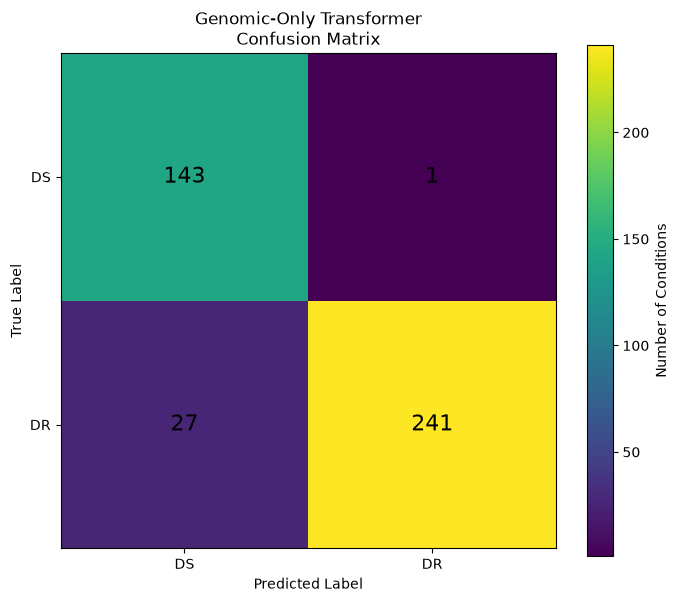

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_01_Genomic_Confusion_Matrix.png

FIGURE 2 — NORMALIZED CONFUSION MATRIX


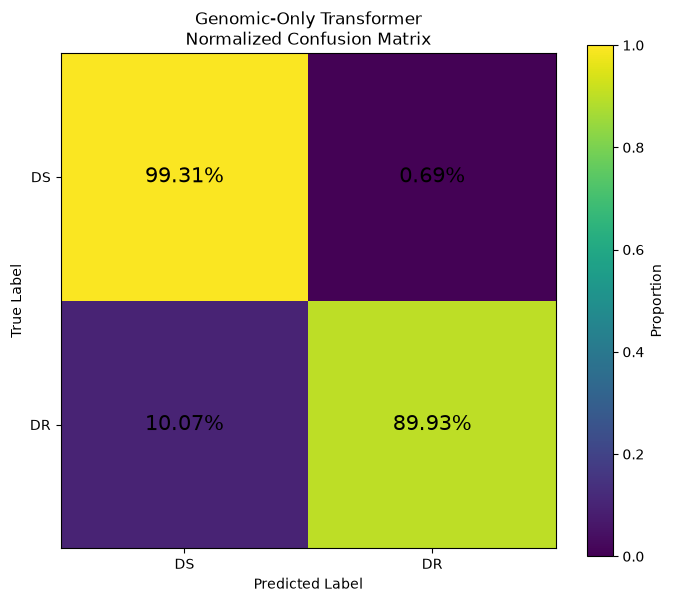

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_02_Genomic_Normalized_Confusion_Matrix.png

FIGURE 3 — ROC CURVE


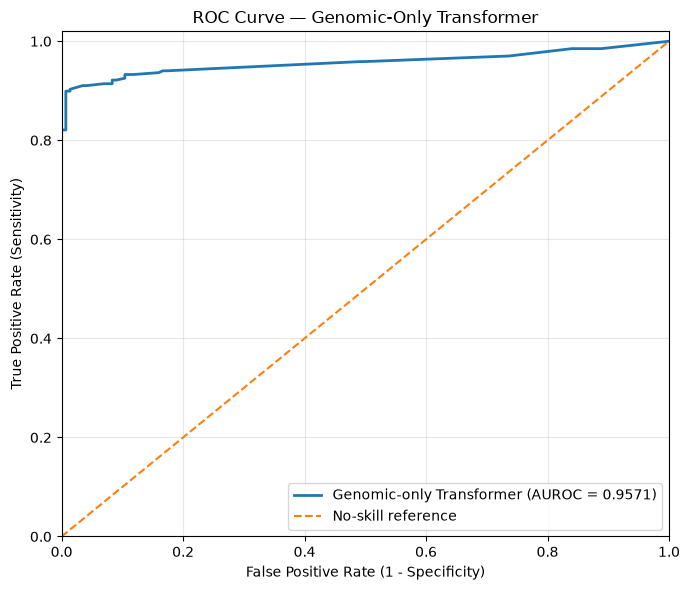

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_03_Genomic_ROC_Curve.png

FIGURE 4 — PRECISION-RECALL CURVE


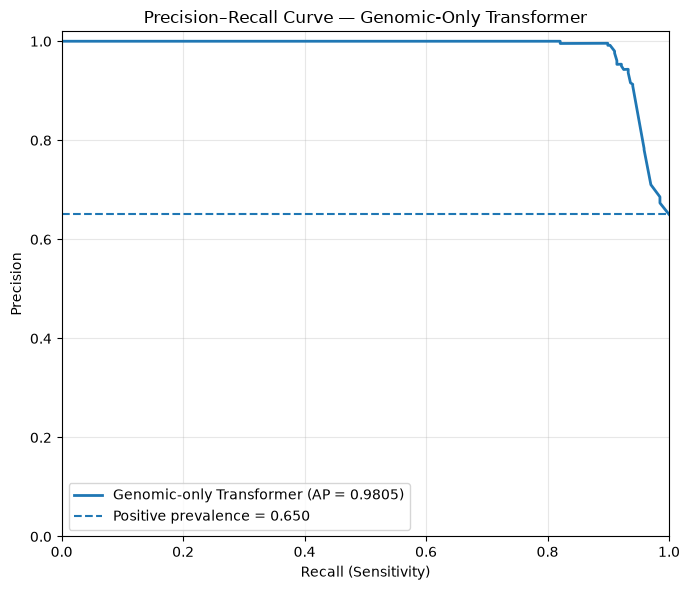

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_04_Genomic_Precision_Recall_Curve.png

FIGURE 5 — TRAINING VS VALIDATION ROC-AUC


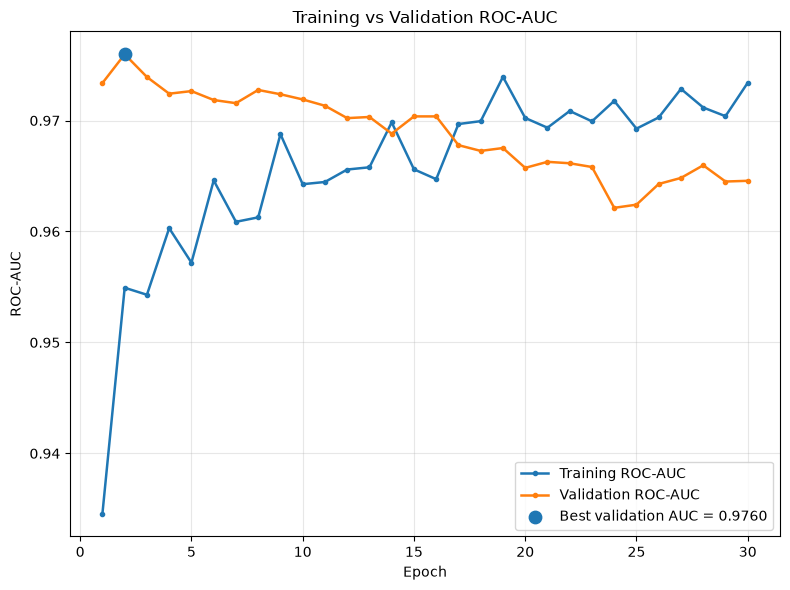

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_05_Genomic_Training_Validation_ROC_AUC.png

FIGURE 6 — TRAINING VS VALIDATION LOSS


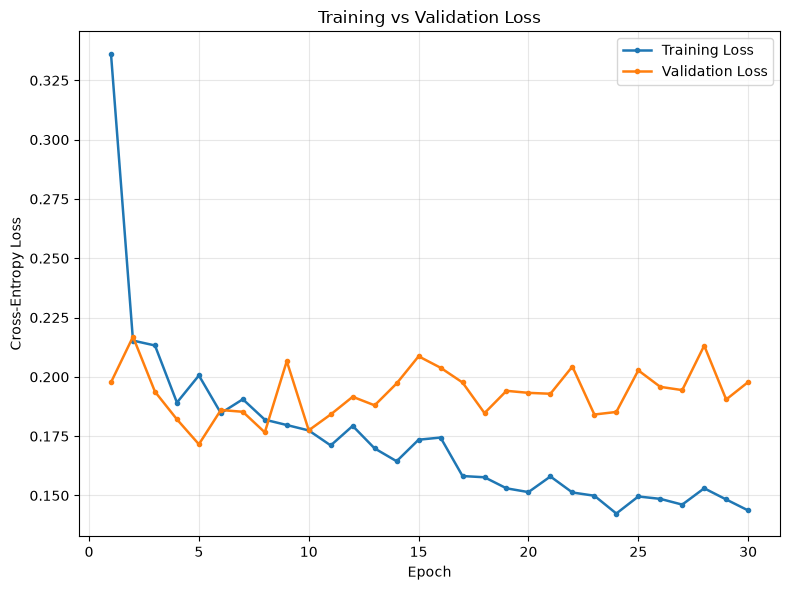

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_06_Genomic_Training_Validation_Loss.png

FIGURE 7 — TRAINING VS VALIDATION F1


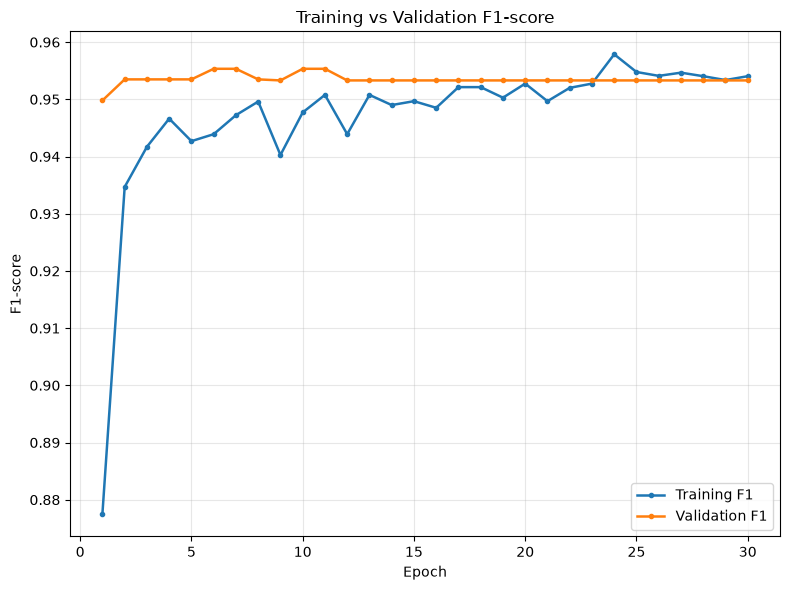

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_07_Genomic_Training_Validation_F1.png

FIGURE 8 — TRAINING VS VALIDATION ACCURACY


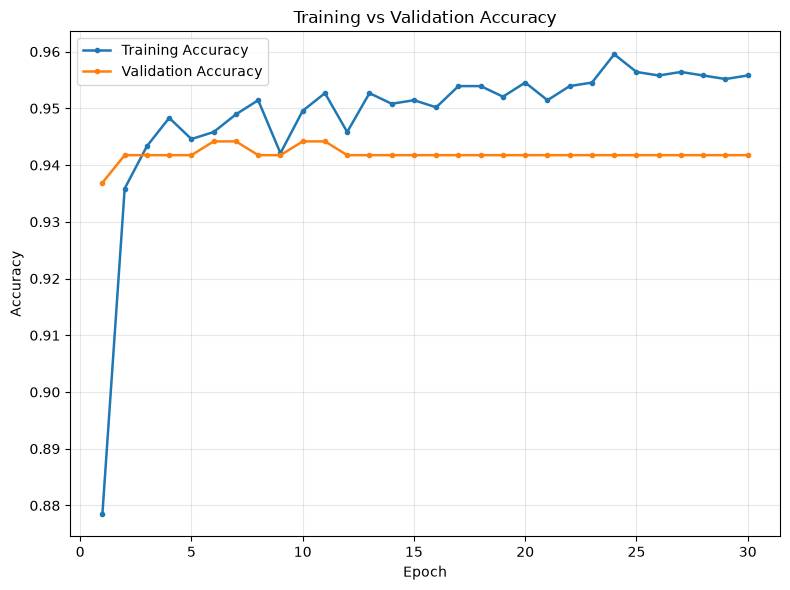

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_08_Genomic_Training_Validation_Accuracy.png

FIGURE 9 — PREDICTION PROBABILITY DISTRIBUTION


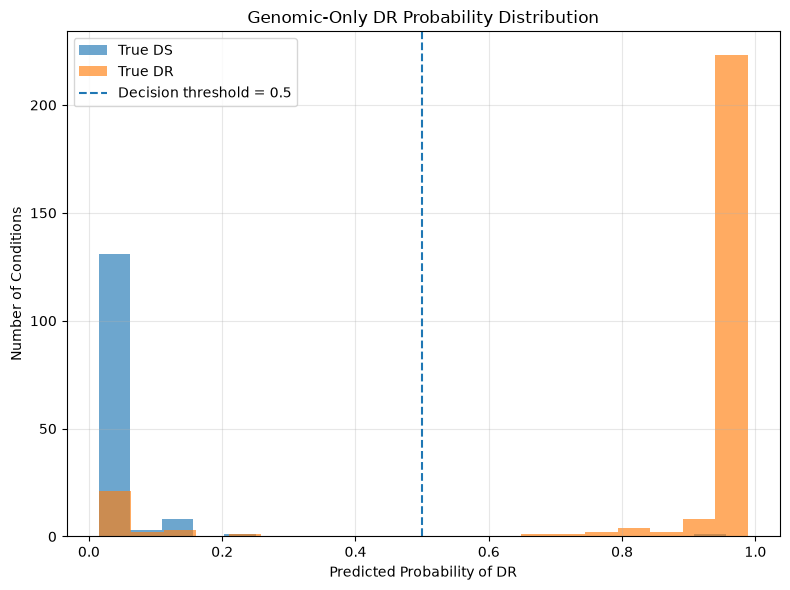

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_09_Genomic_Prediction_Probability_Distribution.png

FIGURE 10 — CALIBRATION CURVE


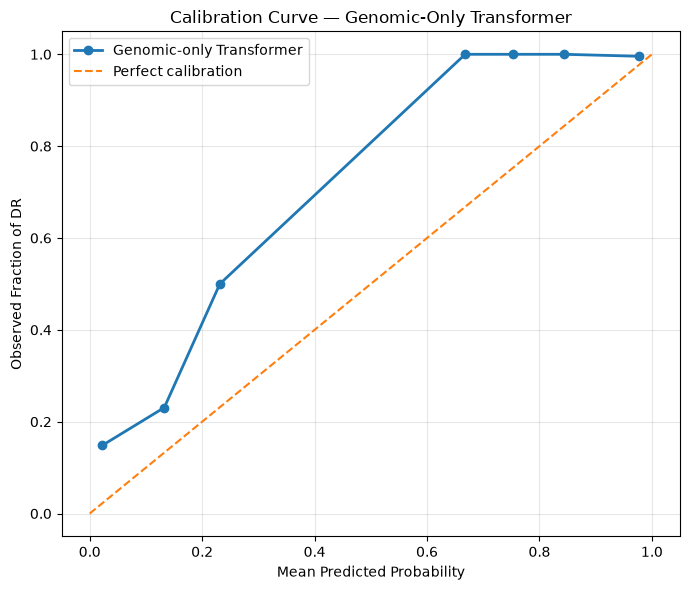

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Genomic_Training\Run1_GenomicTransformer\figures\Figure_10_Genomic_Calibration_Curve.png

GENOMIC-ONLY FINAL TEST SUMMARY


,Metric,Value
0,Accuracy,0.932039
1,Balanced Accuracy,0.946155
2,Precision,0.995868
3,Sensitivity / Recall,0.899254
4,Specificity,0.993056
5,F1-score,0.945098
6,ROC-AUC,0.957128
7,PR-AUC,0.980528
8,Brier Score,0.063914
9,TN,143.000000



FIGURE INVENTORY
Figure_01_Genomic_Confusion_Matrix.png
Figure_02_Genomic_Normalized_Confusion_Matrix.png
Figure_03_Genomic_ROC_Curve.png
Figure_04_Genomic_Precision_Recall_Curve.png
Figure_05_Genomic_Training_Validation_ROC_AUC.png
Figure_06_Genomic_Training_Validation_Loss.png
Figure_07_Genomic_Training_Validation_F1.png
Figure_08_Genomic_Training_Validation_Accuracy.png
Figure_09_Genomic_Prediction_Probability_Distribution.png
Figure_10_Genomic_Calibration_Curve.png

Total figures generated: 10

CELL 24A FINAL HARD SAFETY GATE
test_predictions_412          : PASS
test_DS_144                   : PASS
test_DR_268                   : PASS
unique_conditions_412         : PASS
finite_probabilities          : PASS
history_present               : PASS
bootstrap_present             : PASS
all_figures_saved             : PASS
summary_saved                 : PASS
no_training                   : PASS
no_target_modification        : PASS
no_split_modification         : PASS

CELL 24A FINAL STA

In [32]:
# ================================================================
# NOTEBOOK 12 — CELL 24A
# GENOMIC-ONLY COMPLETE EVALUATION + PUBLICATION FIGURES
# ================================================================
#
# PURPOSE
# -------
# Generate complete visual evaluation of the already-trained
# genomic-only Transformer.
#
# THIS CELL DOES NOT:
#   - train the model
#   - modify the model
#   - modify the test predictions
#   - modify the target
#   - modify the split
#
# INPUTS:
#   Cell 22 training history
#   Cell 23 test predictions
#   Cell 23 bootstrap results
#
# OUTPUT:
#   - Figures displayed directly in Jupyter output
#   - PNG copies saved to disk
#   - Numerical summary CSV files
#
# FIGURES:
#   1. Confusion Matrix
#   2. Normalized Confusion Matrix
#   3. ROC Curve
#   4. Precision-Recall Curve
#   5. Training vs Validation ROC-AUC
#   6. Training vs Validation Loss
#   7. Training vs Validation F1
#   8. Training vs Validation Accuracy
#   9. Prediction Probability Distribution
#  10. Calibration Curve
#
# ================================================================


# ================================================================
# 1. IMPORTS
# ================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

from sklearn.calibration import (
    calibration_curve
)

from IPython.display import (
    display
)


print("=" * 80)
print("NOTEBOOK 12 — CELL 24A")
print("GENOMIC-ONLY COMPLETE EVALUATION + VISUALIZATION")
print("=" * 80)


# ================================================================
# 2. PATHS
# ================================================================

PROJECT_ROOT = Path(
    r"C:\TBP"
)


TRAINING_ROOT = (
    PROJECT_ROOT
    / "Metadata"
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Genomic_Training"
    / "Run1_GenomicTransformer"
)


RESULTS_DIR = (
    TRAINING_ROOT
    / "results"
)


FIGURES_DIR = (
    TRAINING_ROOT
    / "figures"
)


FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ================================================================
# 3. REQUIRED INPUT FILES
# ================================================================

PREDICTIONS_PATH = (
    RESULTS_DIR
    / "Notebook12_Cell23_GenomicTransformer_Test_Predictions.csv"
)


HISTORY_PATH = (
    RESULTS_DIR
    / "Notebook12_Cell22_GenomicTransformer_Training_History.csv"
)


BOOTSTRAP_PATH = (
    RESULTS_DIR
    / "Notebook12_Cell23_GenomicTransformer_Test_Bootstrap_CI.csv"
)


METRICS_PATH = (
    RESULTS_DIR
    / "Notebook12_Cell23_GenomicTransformer_Test_Metrics.csv"
)


required_files = {

    "Test predictions":
        PREDICTIONS_PATH,

    "Training history":
        HISTORY_PATH,

    "Bootstrap CI":
        BOOTSTRAP_PATH,

    "Test metrics":
        METRICS_PATH
}


print()
print("=" * 80)
print("INPUT VERIFICATION")
print("=" * 80)


for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:25s}: FOUND"
    )


print(
    "Input verification: PASS"
)


# ================================================================
# 4. LOAD RESULTS
# ================================================================

prediction_df = pd.read_csv(
    PREDICTIONS_PATH
)


history_df = pd.read_csv(
    HISTORY_PATH
)


bootstrap_df = pd.read_csv(
    BOOTSTRAP_PATH
)


metrics_df = pd.read_csv(
    METRICS_PATH
)


print()
print("=" * 80)
print("LOADED RESULTS")
print("=" * 80)

print(
    "Test predictions:",
    len(prediction_df)
)

print(
    "Training history rows:",
    len(history_df)
)

print(
    "Bootstrap rows:",
    len(bootstrap_df)
)

print(
    "Metric rows:",
    len(metrics_df)
)


# ================================================================
# 5. REQUIRED COLUMN VERIFICATION
# ================================================================

required_prediction_columns = [

    "condition_id",
    "true_target",
    "true_label",
    "predicted_target",
    "predicted_label",
    "probability_DR",
    "probability_DS",
    "correct"
]


required_history_columns = [

    "epoch",

    "train_loss",
    "val_loss",

    "train_accuracy",
    "val_accuracy",

    "train_f1",
    "val_f1",

    "train_roc_auc",
    "val_roc_auc"
]


for column in required_prediction_columns:

    if column not in prediction_df.columns:

        raise RuntimeError(
            f"Missing prediction column: {column}"
        )


for column in required_history_columns:

    if column not in history_df.columns:

        raise RuntimeError(
            f"Missing history column: {column}"
        )


print(
    "Required columns: PASS"
)


# ================================================================
# 6. TEST DATA INTEGRITY
# ================================================================

if len(prediction_df) != 412:

    raise RuntimeError(
        "Expected exactly 412 test predictions."
    )


if (
    prediction_df[
        "condition_id"
    ].nunique()
    !=
    412
):

    raise RuntimeError(
        "Test condition IDs are not unique."
    )


true_targets = (
    prediction_df[
        "true_target"
    ]
    .astype(int)
    .to_numpy()
)


predicted_targets = (
    prediction_df[
        "predicted_target"
    ]
    .astype(int)
    .to_numpy()
)


probabilities = (
    prediction_df[
        "probability_DR"
    ]
    .astype(float)
    .to_numpy()
)


if (
    int(
        (true_targets == 0).sum()
    )
    !=
    144
):

    raise RuntimeError(
        "Unexpected DS test count."
    )


if (
    int(
        (true_targets == 1).sum()
    )
    !=
    268
):

    raise RuntimeError(
        "Unexpected DR test count."
    )


if not np.isfinite(
    probabilities
).all():

    raise RuntimeError(
        "Non-finite prediction probabilities."
    )


if not (
    (
        probabilities >= 0
    )
    &
    (
        probabilities <= 1
    )
).all():

    raise RuntimeError(
        "Invalid probability values."
    )


print()
print("=" * 80)
print("TEST DATA INTEGRITY")
print("=" * 80)

print(
    "Test conditions:",
    len(prediction_df)
)

print(
    "DS:",
    int(
        (true_targets == 0).sum()
    )
)

print(
    "DR:",
    int(
        (true_targets == 1).sum()
    )
)

print(
    "Unique conditions:",
    prediction_df[
        "condition_id"
    ].nunique()
)

print(
    "Probability integrity: PASS"
)

print(
    "Test data integrity: PASS"
)


# ================================================================
# 7. CALCULATE METRICS AGAIN
# ================================================================
#
# Recalculated independently from the saved prediction file.
# ================================================================

accuracy = accuracy_score(
    true_targets,
    predicted_targets
)


balanced_accuracy = (
    balanced_accuracy_score(
        true_targets,
        predicted_targets
    )
)


precision = precision_score(
    true_targets,
    predicted_targets,
    zero_division=0
)


sensitivity = recall_score(
    true_targets,
    predicted_targets,
    zero_division=0
)


f1 = f1_score(
    true_targets,
    predicted_targets,
    zero_division=0
)


roc_auc = roc_auc_score(
    true_targets,
    probabilities
)


pr_auc = average_precision_score(
    true_targets,
    probabilities
)


cm = confusion_matrix(
    true_targets,
    predicted_targets,
    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


specificity = (
    tn / (tn + fp)
)


brier_score = brier_score_loss(
    true_targets,
    probabilities
)


print()
print("=" * 80)
print("INDEPENDENT METRIC RECOMPUTATION")
print("=" * 80)

print(
    f"Accuracy           : {accuracy:.6f}"
)

print(
    f"Balanced Accuracy  : {balanced_accuracy:.6f}"
)

print(
    f"Precision          : {precision:.6f}"
)

print(
    f"Sensitivity        : {sensitivity:.6f}"
)

print(
    f"Specificity        : {specificity:.6f}"
)

print(
    f"F1-score           : {f1:.6f}"
)

print(
    f"ROC-AUC            : {roc_auc:.6f}"
)

print(
    f"PR-AUC             : {pr_auc:.6f}"
)

print(
    f"Brier Score        : {brier_score:.6f}"
)


# ================================================================
# 8. CREATE FIGURE HELPER
# ================================================================

def save_and_show(
    filename
):

    path = (
        FIGURES_DIR
        /
        filename
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        path
    )


# ================================================================
# 9. FIGURE 1 — CONFUSION MATRIX
# ================================================================

print()
print("=" * 80)
print("FIGURE 1 — CONFUSION MATRIX")
print("=" * 80)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


image = ax.imshow(
    cm
)


ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)


ax.set_xticklabels(
    ["DS", "DR"]
)

ax.set_yticklabels(
    ["DS", "DR"]
)


ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)


ax.set_title(
    "Genomic-Only Transformer\nConfusion Matrix"
)


threshold = (
    image.get_clim()[1] / 2
)


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center",
            fontsize=16
        )


plt.colorbar(
    image,
    ax=ax,
    label="Number of Conditions"
)


plt.tight_layout()


save_and_show(
    "Figure_01_Genomic_Confusion_Matrix.png"
)


# ================================================================
# 10. FIGURE 2 — NORMALIZED CONFUSION MATRIX
# ================================================================

print()
print("=" * 80)
print("FIGURE 2 — NORMALIZED CONFUSION MATRIX")
print("=" * 80)


cm_normalized = (
    cm.astype(float)
    /
    cm.sum(
        axis=1,
        keepdims=True
    )
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


image = ax.imshow(
    cm_normalized,
    vmin=0,
    vmax=1
)


ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)


ax.set_xticklabels(
    ["DS", "DR"]
)

ax.set_yticklabels(
    ["DS", "DR"]
)


ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)


ax.set_title(
    "Genomic-Only Transformer\nNormalized Confusion Matrix"
)


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2%}",
            ha="center",
            va="center",
            fontsize=15
        )


plt.colorbar(
    image,
    ax=ax,
    label="Proportion"
)


plt.tight_layout()


save_and_show(
    "Figure_02_Genomic_Normalized_Confusion_Matrix.png"
)


# ================================================================
# 11. FIGURE 3 — ROC CURVE
# ================================================================

print()
print("=" * 80)
print("FIGURE 3 — ROC CURVE")
print("=" * 80)


fpr, tpr, roc_thresholds = (
    roc_curve(
        true_targets,
        probabilities
    )
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Genomic-only Transformer (AUROC = {roc_auc:.4f})"
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="No-skill reference"
)


ax.set_xlabel(
    "False Positive Rate (1 - Specificity)"
)

ax.set_ylabel(
    "True Positive Rate (Sensitivity)"
)


ax.set_title(
    "ROC Curve — Genomic-Only Transformer"
)


ax.legend(
    loc="lower right"
)


ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.02
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_03_Genomic_ROC_Curve.png"
)


# ================================================================
# 12. FIGURE 4 — PRECISION-RECALL CURVE
# ================================================================

print()
print("=" * 80)
print("FIGURE 4 — PRECISION-RECALL CURVE")
print("=" * 80)


precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        true_targets,
        probabilities
    )
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ax.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Genomic-only Transformer (AP = {pr_auc:.4f})"
)


positive_prevalence = (
    true_targets.mean()
)


ax.axhline(
    positive_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=f"Positive prevalence = {positive_prevalence:.3f}"
)


ax.set_xlabel(
    "Recall (Sensitivity)"
)

ax.set_ylabel(
    "Precision"
)


ax.set_title(
    "Precision–Recall Curve — Genomic-Only Transformer"
)


ax.legend(
    loc="lower left"
)


ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.02
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_04_Genomic_Precision_Recall_Curve.png"
)


# ================================================================
# 13. FIGURE 5 — TRAINING VS VALIDATION ROC-AUC
# ================================================================

print()
print("=" * 80)
print("FIGURE 5 — TRAINING VS VALIDATION ROC-AUC")
print("=" * 80)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_roc_auc"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Training ROC-AUC"
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_roc_auc"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Validation ROC-AUC"
)


best_epoch = int(
    history_df.loc[
        history_df[
            "val_roc_auc"
        ].idxmax(),
        "epoch"
    ]
)


best_auc = float(
    history_df[
        "val_roc_auc"
    ].max()
)


ax.scatter(
    [best_epoch],
    [best_auc],
    s=80,
    zorder=5,
    label=f"Best validation AUC = {best_auc:.4f}"
)


ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "ROC-AUC"
)


ax.set_title(
    "Training vs Validation ROC-AUC"
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_05_Genomic_Training_Validation_ROC_AUC.png"
)


# ================================================================
# 14. FIGURE 6 — TRAINING VS VALIDATION LOSS
# ================================================================

print()
print("=" * 80)
print("FIGURE 6 — TRAINING VS VALIDATION LOSS")
print("=" * 80)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_loss"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Training Loss"
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_loss"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Validation Loss"
)


ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Cross-Entropy Loss"
)


ax.set_title(
    "Training vs Validation Loss"
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_06_Genomic_Training_Validation_Loss.png"
)


# ================================================================
# 15. FIGURE 7 — TRAINING VS VALIDATION F1
# ================================================================

print()
print("=" * 80)
print("FIGURE 7 — TRAINING VS VALIDATION F1")
print("=" * 80)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_f1"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Training F1"
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_f1"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Validation F1"
)


ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "F1-score"
)


ax.set_title(
    "Training vs Validation F1-score"
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_07_Genomic_Training_Validation_F1.png"
)


# ================================================================
# 16. FIGURE 8 — TRAINING VS VALIDATION ACCURACY
# ================================================================

print()
print("=" * 80)
print("FIGURE 8 — TRAINING VS VALIDATION ACCURACY")
print("=" * 80)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_accuracy"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Training Accuracy"
)


ax.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_accuracy"
    ],
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Validation Accuracy"
)


ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Accuracy"
)


ax.set_title(
    "Training vs Validation Accuracy"
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_08_Genomic_Training_Validation_Accuracy.png"
)


# ================================================================
# 17. FIGURE 9 — PREDICTION PROBABILITY DISTRIBUTION
# ================================================================

print()
print("=" * 80)
print("FIGURE 9 — PREDICTION PROBABILITY DISTRIBUTION")
print("=" * 80)


ds_probabilities = probabilities[
    true_targets == 0
]


dr_probabilities = probabilities[
    true_targets == 1
]


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.hist(
    ds_probabilities,
    bins=20,
    alpha=0.65,
    label="True DS"
)


ax.hist(
    dr_probabilities,
    bins=20,
    alpha=0.65,
    label="True DR"
)


ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Decision threshold = 0.5"
)


ax.set_xlabel(
    "Predicted Probability of DR"
)

ax.set_ylabel(
    "Number of Conditions"
)


ax.set_title(
    "Genomic-Only DR Probability Distribution"
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_09_Genomic_Prediction_Probability_Distribution.png"
)


# ================================================================
# 18. FIGURE 10 — CALIBRATION CURVE
# ================================================================

print()
print("=" * 80)
print("FIGURE 10 — CALIBRATION CURVE")
print("=" * 80)


fraction_of_positives, mean_predicted_value = (
    calibration_curve(
        true_targets,
        probabilities,
        n_bins=10,
        strategy="uniform"
    )
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ax.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    linewidth=2,
    label="Genomic-only Transformer"
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)


ax.set_xlabel(
    "Mean Predicted Probability"
)

ax.set_ylabel(
    "Observed Fraction of DR"
)


ax.set_title(
    "Calibration Curve — Genomic-Only Transformer"
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


save_and_show(
    "Figure_10_Genomic_Calibration_Curve.png"
)


# ================================================================
# 19. COMPLETE VISUAL SUMMARY
# ================================================================

print()
print("=" * 80)
print("GENOMIC-ONLY FINAL TEST SUMMARY")
print("=" * 80)


summary_table = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Balanced Accuracy",

        "Precision",

        "Sensitivity / Recall",

        "Specificity",

        "F1-score",

        "ROC-AUC",

        "PR-AUC",

        "Brier Score",

        "TN",

        "FP",

        "FN",

        "TP"
    ],

    "Value": [

        accuracy,

        balanced_accuracy,

        precision,

        sensitivity,

        specificity,

        f1,

        roc_auc,

        pr_auc,

        brier_score,

        tn,

        fp,

        fn,

        tp
    ]
})


display(
    summary_table
)


# ================================================================
# 20. SAVE SUMMARY
# ================================================================

SUMMARY_PATH = (
    RESULTS_DIR
    /
    "Notebook12_Cell24A_Genomic_Complete_Test_Summary.csv"
)


summary_table.to_csv(
    SUMMARY_PATH,
    index=False
)


# ================================================================
# 21. FIGURE INVENTORY
# ================================================================

print()
print("=" * 80)
print("FIGURE INVENTORY")
print("=" * 80)


figure_files = sorted(
    FIGURES_DIR.glob(
        "Figure_*.png"
    )
)


for figure_path in figure_files:

    print(
        figure_path.name
    )


print()
print(
    "Total figures generated:",
    len(figure_files)
)


# ================================================================
# 22. FINAL HARD SAFETY GATE
# ================================================================

print()
print("=" * 80)
print("CELL 24A FINAL HARD SAFETY GATE")
print("=" * 80)


final_checks = {

    "test_predictions_412":
        len(prediction_df) == 412,

    "test_DS_144":
        int(
            (true_targets == 0).sum()
        ) == 144,

    "test_DR_268":
        int(
            (true_targets == 1).sum()
        ) == 268,

    "unique_conditions_412":
        prediction_df[
            "condition_id"
        ].nunique() == 412,

    "finite_probabilities":
        bool(
            np.isfinite(
                probabilities
            ).all()
        ),

    "history_present":
        len(history_df) == 30,

    "bootstrap_present":
        len(bootstrap_df) >= 1,

    "all_figures_saved":
        len(figure_files) == 10,

    "summary_saved":
        SUMMARY_PATH.exists(),

    "no_training":
        True,

    "no_target_modification":
        True,

    "no_split_modification":
        True
}


for name, status in final_checks.items():

    print(
        f"{name:30s}: "
        f"{'PASS' if status else 'FAIL'}"
    )


overall_pass = all(
    final_checks.values()
)


print()
print(
    "CELL 24A FINAL STATUS:",
    "PASS"
    if overall_pass
    else "FAIL"
)


if not overall_pass:

    raise RuntimeError(
        "Cell 24A visualization/evaluation gate failed."
    )


# ================================================================
# 23. COMPLETE
# ================================================================

print()
print("=" * 80)
print("CELL 24A — COMPLETE")
print("=" * 80)

print()
print(
    "CONFUSION MATRIX: GENERATED + DISPLAYED"
)

print(
    "NORMALIZED CONFUSION MATRIX: GENERATED + DISPLAYED"
)

print(
    "ROC CURVE: GENERATED + DISPLAYED"
)

print(
    "PRECISION-RECALL CURVE: GENERATED + DISPLAYED"
)

print(
    "TRAINING/VALIDATION ROC-AUC: GENERATED + DISPLAYED"
)

print(
    "TRAINING/VALIDATION LOSS: GENERATED + DISPLAYED"
)

print(
    "TRAINING/VALIDATION F1: GENERATED + DISPLAYED"
)

print(
    "TRAINING/VALIDATION ACCURACY: GENERATED + DISPLAYED"
)

print(
    "PREDICTION PROBABILITY DISTRIBUTION: GENERATED + DISPLAYED"
)

print(
    "CALIBRATION CURVE: GENERATED + DISPLAYED"
)

print()
print(
    "All figures saved under:"
)

print(
    FIGURES_DIR
)

print()
print(
    "No training performed."
)

print(
    "No test predictions modified."
)

print(
    "No target modified."
)

print(
    "No split modified."
)